In [1]:
library(ggplot2)

library(gridExtra)
library(plotly)

library(reshape2)


Warning message:
"le package 'ggplot2' a été compilé avec la version R 4.5.3"
Warning message:
"le package 'gridExtra' a été compilé avec la version R 4.5.3"

Attachement du package : 'plotly'


L'objet suivant est masqué depuis 'package:ggplot2':

    last_plot


L'objet suivant est masqué depuis 'package:stats':

    filter


L'objet suivant est masqué depuis 'package:graphics':

    layout




In [2]:
data<-read.csv("new_games.csv",header = TRUE)

In [3]:
summary(data)

     AppID             Name           Release.date       Estimated.owners  
 Min.   :     10   Length:122611      Length:122611      Length:122611     
 1st Qu.:1063175   Class :character   Class :character   Class :character  
 Median :1907380   Mode  :character   Mode  :character   Mode  :character  
 Mean   :1985386                                                           
 3rd Qu.:2869560                                                           
 Max.   :4264350                                                           
                                                                           
    Peak.CCU          Required.age         Price             Discount     
 Min.   :0.000e+00   Min.   : 0.0000   Min.   :   0.000   Min.   :  0.00  
 1st Qu.:0.000e+00   1st Qu.: 0.0000   1st Qu.:   0.550   1st Qu.:  0.00  
 Median :0.000e+00   Median : 0.0000   Median :   2.240   Median :  0.00  
 Mean   :5.459e+01   Mean   : 0.1676   Mean   :   4.765   Mean   : 18.35  
 3rd Qu.:0.000e+0

# Conversion des variables lues en tant que quantitatives en qualitatives

Il me semble que les variables ci-dessous sont plutôt des variables qualitatives donc je les ai converti.

In [4]:

data[,"Estimated.owners"]=as.factor(data[,"Estimated.owners"])
data[,"Required.age"]=as.factor(data[,"Required.age"])
data[,"Windows"]=as.factor(data[,"Windows"])
data[,"Mac"]=as.factor(data[,"Mac"])
data[,"Linux"]=as.factor(data[,"Linux"])


summary(data)

       

     AppID             Name           Release.date      
 Min.   :     10   Length:122611      Length:122611     
 1st Qu.:1063175   Class :character   Class :character  
 Median :1907380   Mode  :character   Mode  :character  
 Mean   :1985386                                        
 3rd Qu.:2869560                                        
 Max.   :4264350                                        
                                                        
        Estimated.owners    Peak.CCU          Required.age   
 0 - 20000      :75404   Min.   :0.000e+00   0      :121339  
 0 - 0          :21641   1st Qu.:0.000e+00   17     :   828  
 20000 - 50000  :11396   Median :0.000e+00   13     :   175  
 50000 - 100000 : 5355   Mean   :5.459e+01   18     :   164  
 100000 - 200000: 3454   3rd Qu.:0.000e+00   16     :    32  
 200000 - 500000: 2853   Max.   :1.014e+06   10     :    26  
 (Other)        : 2508                       (Other):    47  
     Price             Discount        DLC.count

#  Suppresion de variables inutiles à l'exploration des données

J'ai choisi de supprimer plusieurs variable qui à mon avis ne seraient pas pertinente lors de l'analyse de certaine donnée. J'ai aussi supprimé la variable Movies car elle ne contennait que des NA. score rank ne contient que 40 valeurs.

In [5]:
library(tidyverse)
data1 <- data %>% select(-c(AppID, About.the.game, Reviews,Movies,Header.image,Support.email,Support.url,Notes,Metacritic.url,Screenshots,Score.rank,Website))

Warning message:
"le package 'tibble' a été compilé avec la version R 4.5.3"
Warning message:
"le package 'tidyr' a été compilé avec la version R 4.5.3"
Warning message:
"le package 'purrr' a été compilé avec la version R 4.5.3"
Warning message:
"le package 'dplyr' a été compilé avec la version R 4.5.3"
Warning message:
"le package 'stringr' a été compilé avec la version R 4.5.3"
── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ purrr     1.2.2     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::combine() masks gridExtra::combine()
✖ dplyr::filter()  masks plotly::filter(), stats::filter()
✖ dplyr::lag()     masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force a

In [6]:
head(data1)

,Name,Release.date,Estimated.owners,Peak.CCU,Required.age,Price,Discount,DLC.count,Supported.languages,Full.audio.languages,⋯,Recommendations,Average.playtime.forever,Average.playtime.two.weeks,Median.playtime.forever,Median.playtime.two.weeks,Developers,Publishers,Categories,Genres,Tags
,<chr>,<chr>,<fct>,<int>,<fct>,<dbl>,<int>,<int>,<chr>,<chr>,⋯,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
1,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,[],[],⋯,0,0,0,0,0,,,,,
2,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,['English'],[],⋯,231,8,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,Family Sharing",Adventure,"Adventure,Visual Novel,Anime,Cute"
3,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"['English', 'French', 'German', 'Russian']",[],⋯,0,0,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Object,2D,Colorful,Stylized,Logic,Mystery,Atmospheric,Family Friendly,PvE,Tutorial,Singleplayer,Tabletop"
4,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,['Korean'],['Korean'],⋯,0,0,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",
5,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,['English'],['English'],⋯,0,0,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Family Sharing","Action,Early Access",
6,Agony VR,"Apr 5, 2023",0 - 20000,0,0,13.99,0,0,"['English', 'French', 'Italian', 'German', 'Spanish - Spain', 'Polish', 'Portuguese - Portugal', 'Russian', 'Turkish']","['English', 'Turkish']",⋯,0,0,0,0,0,Ignibit,"Ignibit,Madmind Studio","Single-player,Tracked Controller Support,VR Only,Family Sharing","Action,Adventure",


# Analyse de la qualités des individus (les jeux vidéos): filtrage

Avant de commencer notre analyse, nous allons faire un premier filtrage sur les individus. En effet, nous cherchons à supprimer pour les variables suivantes les cases vides, les cases contenant des NAN et pour Supported.language les cases ne contenant pas de valeurs soit $[]$:Publishers,Developers,Name,Supported.languages,Genres. Nous avons effectué ce filtage car nous avons jugé inutilisable les individus(les jeux) qui au minimun n'avaient aucunes données pour ces variables là.

In [7]:

for (col in colnames(data1))
{

    print((paste(col,sum(is.na(data1[,col]) | data1[,col] == "" |data1[,col] == "[]" ))))
    
}

[1] "Name 1"
[1] "Release.date 0"
[1] "Estimated.owners 0"
[1] "Peak.CCU 0"
[1] "Required.age 0"
[1] "Price 0"
[1] "Discount 0"
[1] "DLC.count 0"
[1] "Supported.languages 8380"
[1] "Full.audio.languages 72730"
[1] "Windows 0"
[1] "Mac 0"
[1] "Linux 0"
[1] "Metacritic.score 0"
[1] "User.score 0"
[1] "Positive 0"
[1] "Negative 0"
[1] "Achievements 0"
[1] "Recommendations 0"
[1] "Average.playtime.forever 0"
[1] "Average.playtime.two.weeks 0"
[1] "Median.playtime.forever 0"
[1] "Median.playtime.two.weeks 0"
[1] "Developers 8432"
[1] "Publishers 8838"
[1] "Categories 8953"
[1] "Genres 8413"
[1] "Tags 39265"


In [8]:

dat_filtered <- data1 %>%
  mutate(
    # 1. Fusion des LANGUES (Supported + Audio)
    temp_langs = paste(Supported.languages, Full.audio.languages, sep = ","),
    Language= temp_langs %>%
      str_remove_all("[\\[\\]'\" ]") %>%
      str_replace_all("(?i)na|nan|null", "") %>%
      str_replace_all(",+", ",") %>%
      str_remove("^,") %>%
      str_remove(",$"),

    # 2. Fusion des GENRES et Tags
    temp_genres_cat = paste(Genres, Tags, sep = ","),
    TagGenre = temp_genres_cat %>%
      str_remove_all("[\\[\\]'\" ]") %>%
      str_replace_all("(?i)na|nan|null", "") %>%
      str_replace_all(",+", ",") %>%
      str_remove("^,") %>%
      str_remove(",$")
  ) %>%
  # 3. Étape finale : On retire les doublons internes (ex: si "Action" est dans les deux)
  mutate(
    Language = sapply(str_split(Language, ","), function(x) paste(unique(x[x != ""]), collapse = ", ")),
    TagGenre = sapply(str_split(TagGenre, ","), function(x) paste(unique(x[x != ""]), collapse = ", "))
  ) %>%
  # 4. On nettoie les colonnes temporaires
  select(-temp_langs, -temp_genres_cat)

In [9]:

data2 <- dat_filtered %>% select(-c(Supported.languages,Full.audio.languages))
summary(data2)

     Name           Release.date              Estimated.owners
 Length:122611      Length:122611      0 - 20000      :75404  
 Class :character   Class :character   0 - 0          :21641  
 Mode  :character   Mode  :character   20000 - 50000  :11396  
                                       50000 - 100000 : 5355  
                                       100000 - 200000: 3454  
                                       200000 - 500000: 2853  
                                       (Other)        : 2508  
    Peak.CCU          Required.age        Price             Discount     
 Min.   :0.000e+00   0      :121339   Min.   :   0.000   Min.   :  0.00  
 1st Qu.:0.000e+00   17     :   828   1st Qu.:   0.550   1st Qu.:  0.00  
 Median :0.000e+00   13     :   175   Median :   2.240   Median :  0.00  
 Mean   :5.459e+01   18     :   164   Mean   :   4.765   Mean   : 18.35  
 3rd Qu.:0.000e+00   16     :    32   3rd Qu.:   5.240   3rd Qu.: 40.00  
 Max.   :1.014e+06   10     :    26   Max.   : 999.9

In [10]:
head(data2)

,Name,Release.date,Estimated.owners,Peak.CCU,Required.age,Price,Discount,DLC.count,Windows,Mac,⋯,Average.playtime.two.weeks,Median.playtime.forever,Median.playtime.two.weeks,Developers,Publishers,Categories,Genres,Tags,Language,TagGenre
,<chr>,<chr>,<fct>,<int>,<fct>,<dbl>,<int>,<int>,<fct>,<fct>,⋯,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,True,False,⋯,0,0,0,,,,,,,
2,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,True,False,⋯,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,Family Sharing",Adventure,"Adventure,Visual Novel,Anime,Cute",English,"Adventure, VisualNovel, Anime, Cute"
3,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,True,True,⋯,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Object,2D,Colorful,Stylized,Logic,Mystery,Atmospheric,Family Friendly,PvE,Tutorial,Singleplayer,Tabletop","English, French, German, Russian","Casual, CardGame, Solitaire, Puzzle, HiddenObject, 2D, Colorful, Stylized, Logic, Mystery, Atmospheric, FamilyFriendly, PvE, Tutorial, Singleplayer, Tabletop"
4,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,True,False,⋯,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",,Korean,"Casual, Indie, Simulation"
5,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,True,False,⋯,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Family Sharing","Action,Early Access",,English,"Action, EarlyAccess"
6,Agony VR,"Apr 5, 2023",0 - 20000,0,0,13.99,0,0,True,False,⋯,0,0,0,Ignibit,"Ignibit,Madmind Studio","Single-player,Tracked Controller Support,VR Only,Family Sharing","Action,Adventure",,"English, French, Italian, German, Spanish-Spain, Polish, Portuguese-Portugal, Russian, Turkish","Action, Adventure"


In [11]:
data_filtered <- data2 %>%
  filter(
    (TagGenre != "" ) |
    (Categories != "" ) |
    ( Language != "" )
  )


In [12]:
summary(data_filtered)

     Name           Release.date              Estimated.owners
 Length:114629      Length:114629      0 - 20000      :75404  
 Class :character   Class :character   0 - 0          :13659  
 Mode  :character   Mode  :character   20000 - 50000  :11396  
                                       50000 - 100000 : 5355  
                                       100000 - 200000: 3454  
                                       200000 - 500000: 2853  
                                       (Other)        : 2508  
    Peak.CCU          Required.age        Price             Discount     
 Min.   :0.000e+00   0      :113357   Min.   :   0.000   Min.   :  0.00  
 1st Qu.:0.000e+00   17     :   828   1st Qu.:   0.890   1st Qu.:  0.00  
 Median :0.000e+00   13     :   175   Median :   2.690   Median :  0.00  
 Mean   :5.839e+01   18     :   164   Mean   :   5.097   Mean   : 19.63  
 3rd Qu.:0.000e+00   16     :    32   3rd Qu.:   5.990   3rd Qu.: 45.00  
 Max.   :1.014e+06   10     :    26   Max.   : 999.9

In [13]:
for (col in colnames(data_filtered)) {
    # On calcule le nombre de vides/NA/[]
    nb_vides <- sum(is.na(data_filtered[[col]]) | 
                    data_filtered[[col]] == "" | 
                    data_filtered[[col]] == "[]", 
                    na.rm = TRUE)
    
    # On affiche le résultat de manière lisible
    print(paste(col, ":", nb_vides))
}

[1] "Name : 0"
[1] "Release.date : 0"
[1] "Estimated.owners : 0"
[1] "Peak.CCU : 0"
[1] "Required.age : 0"
[1] "Price : 0"
[1] "Discount : 0"
[1] "DLC.count : 0"
[1] "Windows : 0"
[1] "Mac : 0"
[1] "Linux : 0"
[1] "Metacritic.score : 0"
[1] "User.score : 0"
[1] "Positive : 0"
[1] "Negative : 0"
[1] "Achievements : 0"
[1] "Recommendations : 0"
[1] "Average.playtime.forever : 0"
[1] "Average.playtime.two.weeks : 0"
[1] "Median.playtime.forever : 0"
[1] "Median.playtime.two.weeks : 0"
[1] "Developers : 450"
[1] "Publishers : 856"
[1] "Categories : 971"
[1] "Genres : 431"
[1] "Tags : 31283"
[1] "Language : 398"
[1] "TagGenre : 320"


In [14]:
nbr_suppr <- nrow(data1) - nrow(data_filtered)

print(paste("Nous avons supprimé", nbr_suppr, "individus."))

[1] "Nous avons supprimé 7982 individus."


## Traitement des doublons (jeux qui ont le même nom)

In [15]:
doublons <- data_filtered %>%
  group_by(Name) %>%
  filter(n() > 1) %>%
  arrange(Name)
head(doublons,20)

total_doublons <- nrow(doublons)

noms_problematiques <- n_distinct(doublons$Name)

print(paste("Il y a", total_doublons, "lignes qui concernent", noms_problematiques, "noms de jeux en double."))

Name,Release.date,Estimated.owners,Peak.CCU,Required.age,Price,Discount,DLC.count,Windows,Mac,⋯,Average.playtime.two.weeks,Median.playtime.forever,Median.playtime.two.weeks,Developers,Publishers,Categories,Genres,Tags,Language,TagGenre
<chr>,<chr>,<fct>,<int>,<fct>,<dbl>,<int>,<int>,<fct>,<fct>,⋯,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
A Better Tomorrow,"Jul 31, 2024",0 - 20000,0,0,0.00,0,0,True,False,⋯,0,0,0,GoragarX,GoragarX,Single-player,"Casual,Strategy,Free To Play",,"English, Spanish-Spain","Casual, Strategy, FreeToPlay"
A Better Tomorrow,"Sep 30, 2025",0 - 0,0,0,0.00,0,0,True,False,⋯,0,0,0,WoofWoofStudio,WoofWoofStudio,"Single-player,Steam Achievements,Custom Volume Controls,Playable without Timed Input","Indie,Free To Play,Early Access",,SimplifiedChinese,"Indie, FreeToPlay, EarlyAccess"
A Walk in the Woods,"Apr 21, 2020",0 - 20000,0,0,0.00,0,0,True,False,⋯,0,0,0,Brightdawn Entertainment,Brightdawn Entertainment,"Single-player,Full controller support,Tracked Controller Support,VR Only","Indie,Simulation","Indie,Simulation,VR,Singleplayer,Family Friendly",English,"Indie, Simulation, VR, Singleplayer, FamilyFriendly"
A Walk in the Woods,"May 1, 2018",100000 - 200000,0,0,0.00,0,0,True,False,⋯,0,13,0,Something Dark Studios,Something Dark Studios,"Multi-player,PvP,Online PvP,Co-op,Online Co-op,Partial Controller Support","Adventure,Free To Play,Indie","Free to Play,Horror,Multiplayer,Indie,Adventure,Co-op,Survival Horror,Survival",English,"Adventure, FreeToPlay, Indie, FreetoPlay, Horror, Multiplayer, Co-op, SurvivalHorror, Survival"
ALONE,"May 31, 2021",50000 - 100000,0,0,0.74,0,0,True,False,⋯,0,0,0,DakeCraft,PsychoFlux Entertainment,"Single-player,Steam Achievements,Steam Cloud,Family Sharing","Adventure,Casual,Indie","Puzzle,Female Protagonist,RPG,2D,Top-Down,Horror,Psychological Horror,Choices Matter,Multiple Endings,Casual,Pixel Graphics,Investigation,Adventure,Survival Horror,Multiplayer,Singleplayer,RPGMaker,Indie,Free to Play,Sexual Content","English, Korean, Thai","Adventure, Casual, Indie, Puzzle, FemaleProtagonist, RPG, 2D, Top-Down, Horror, PsychologicalHorror, ChoicesMatter, MultipleEndings, PixelGraphics, Investigation, SurvivalHorror, Multiplayer, Singleplayer, RPGMaker, FreetoPlay, SexualContent"
ALONE,"Dec 23, 2021",0 - 20000,0,0,8.99,0,0,True,False,⋯,0,0,0,True Nuke,True Nuke,"Single-player,Family Sharing","Action,Adventure,Indie","Psychological Horror,Exploration,Action,Hero Shooter,FPS,Shooter,Adventure,Action-Adventure,3D,Horror,Stealth,Indie,Artificial Intelligence,Physics,Inventory Management,Singleplayer,Survival Horror",English,"Action, Adventure, Indie, PsychologicalHorror, Exploration, HeroShooter, FPS, Shooter, Action-Adventure, 3D, Horror, Stealth, ArtificialIntelligence, Physics, InventoryMagement, Singleplayer, SurvivalHorror"
ASTRA,"Oct 12, 2021",0 - 20000,0,0,0.89,91,0,True,False,⋯,0,0,0,Piece Of Voxel,Piece Of Voxel,"Single-player,Family Sharing","Action,Adventure,Casual,Indie","Stylized,Typing,2D Platformer,Choose Your Own Adventure,Space Sim,Programming,Old School,2D,Abstract,Runner,Dinosaurs,Side Scroller,Adventure,Puzzle,Action,Point & Click,Arcade,Platformer,Casual,Text-Based","English, Russian","Action, Adventure, Casual, Indie, Stylized, Typing, 2DPlatformer, ChooseYourOwdventure, SpaceSim, Programming, OldSchool, 2D, Abstract, Runner, Dinosaurs, SideScroller, Puzzle, Point&Click, Arcade, Platformer, Text-Based"
ASTRA,"Jan 5, 2024",20000 - 50000,0,0,2.99,0,0,True,False,⋯,0,0,0,NewOrderFantasySimulations,NewOrderFantasySimulations,"Single-player,Steam Achievements,Family Sharing",Action,"Action,Adventure,Dark Fantasy,Open World,Exploration,Capitalism,Medieval,Abstract,Action RPG,Hack and Slash,Dungeon Crawler,3D,Stylized,Retro,Character Customization,Combat,Singleplayer",English,"Action, Adventure, DarkFantasy, OpenWorld, Exploration, Capitalism, Medieval, Abstract, ActionRPG, HackandSlash, DungeonCrawler, 3D, Stylized, Retro, CharacterCustomization, Combat, Single

[1] "Il y a 2049 lignes qui concernent 926 noms de jeux en double."


In [16]:
data3 <- data_filtered %>%
  # 1. On trie par nom, puis par Peak.CCU du plus grand au plus petit
  # Comme ça, la ligne avec le plus gros score arrive en premier pour chaque jeu
  arrange(Name, Developers, Publishers, desc(Peak.CCU)) %>%
  
  # 2. On ne garde que la première occurrence pour chaque combinaison identique
  # R va garder la 1ère ligne rencontrée (donc celle avec le CCU max grâce au tri)
  distinct(Name, Developers, Publishers, .keep_all = TRUE)

In [17]:
nbr_suppr <- nrow(data_filtered) - nrow(data3)

print(paste("Nous avons supprimé", nbr_suppr, "individus."))

[1] "Nous avons supprimé 116 individus."


# Etude sur variables

# Variables quantitatives

In [18]:
data3$Positive=data3$Positive+1
data3$Negative=data3$Negative+1
data3$Recommendations=data3$Recommendations+1

data3[, "LPositive"] <- log(data3[, "Positive"])

data3[, "LNegative"] <- log(data3[, "Negative"])
data3[, "LRecommendations"] <- log(data3[, "Recommendations"])

In [19]:
data4 <- data3 %>% select(-c(Positive,Negative,Recommendations))
summary(data4)

     Name           Release.date              Estimated.owners
 Length:114513      Length:114513      0 - 20000      :75337  
 Class :character   Class :character   0 - 0          :13649  
 Mode  :character   Mode  :character   20000 - 50000  :11395  
                                       50000 - 100000 : 5349  
                                       100000 - 200000: 3450  
                                       200000 - 500000: 2845  
                                       (Other)        : 2488  
    Peak.CCU          Required.age        Price             Discount     
 Min.   :0.000e+00   0      :113288   Min.   :   0.000   Min.   :  0.00  
 1st Qu.:0.000e+00   17     :   782   1st Qu.:   0.890   1st Qu.:  0.00  
 Median :0.000e+00   13     :   175   Median :   2.690   Median :  0.00  
 Mean   :5.844e+01   18     :   164   Mean   :   5.093   Mean   : 19.62  
 3rd Qu.:0.000e+00   16     :    31   3rd Qu.:   5.990   3rd Qu.: 45.00  
 Max.   :1.014e+06   10     :    26   Max.   : 999.9

language count variable

In [20]:
data5 <- data4 %>%
  mutate(LanguageCount = case_when(
      Language == "" ~ 0, # Cas où c'est vide
    TRUE ~ str_count(Language, ",") + 1              
  ))

In [21]:
data5$Average.playtime.forever=data5$Average.playtime.forever+1
data5$Median.playtime.forever=data5$Median.playtime.forever+1
data5$Price=data5$Price+1
data5$LanguageCount=data5$LanguageCount+1

data5[, "LAverage.playtime.forever"] <- log(data5[, "Average.playtime.forever"])
data5[, "LMedian.playtime.forever"] <- log(data5[, "Median.playtime.forever"])
data5[, "LPrice"] <- log(data5[, "Price"])
data5[, "LLanguageCount"] <- log(data5[, "LanguageCount"])

In [22]:
data5$Peak.CCU=data5$Peak.CCU+1
data5$DLC.count=data5$DLC.count+1

data5[, "LPeak.CCU"] <- log(data5[, "Peak.CCU"])

data5[, "LDLC.count"] <- log(data5[, "DLC.count"])

In [23]:
data5 <- data5 %>% select(-c(Average.playtime.forever,Median.playtime.forever,DLC.count,Peak.CCU,Price,LanguageCount))
summary(data5)

     Name           Release.date              Estimated.owners  Required.age   
 Length:114513      Length:114513      0 - 20000      :75337   0      :113288  
 Class :character   Class :character   0 - 0          :13649   17     :   782  
 Mode  :character   Mode  :character   20000 - 50000  :11395   13     :   175  
                                       50000 - 100000 : 5349   18     :   164  
                                       100000 - 200000: 3450   16     :    31  
                                       200000 - 500000: 2845   10     :    26  
                                       (Other)        : 2488   (Other):    47  
    Discount       Windows          Mac          Linux       Metacritic.score
 Min.   :  0.00   False:    44   False:93260   False:98841   Min.   : 0.000  
 1st Qu.:  0.00   True :114469   True :21253   True :15672   1st Qu.: 0.000  
 Median :  0.00                                              Median : 0.000  
 Mean   : 19.62                                 

In [24]:
data_rename <- data5 %>%
  mutate(Estimated.owners = fct_recode(Estimated.owners,
    "0"           = "0 - 0",
    "0-20K"       = "0 - 20000",
    "20K-50K"     = "20000 - 50000",
    "50K-100K"    = "50000 - 100000",
    "100K-200K"   = "100000 - 200000",
    "200K-500K"   = "200000 - 500000",
    "500K-1M"     = "500000 - 1000000",
    "1M-2M"       = "1000000 - 2000000",
    "2M-5M"       = "2000000 - 5000000",
    "5M-10M"      = "5000000 - 10000000",
    "10M-20M"     = "10000000 - 20000000",
    "20M-50M"     = "20000000 - 50000000",
    "50M-100M"    = "50000000 - 100000000",
    "100M-200M"   = "100000000 - 200000000"
  ))

ordre_logique <- c(
  "0", "0-20K", "20K-50K", "50K-100K", "100K-200K", 
  "200K-500K", "500K-1M", "1M-2M", "2M-5M", "5M-10M", 
  "10M-20M", "20M-50M", "50M-100M", "100M-200M"
)

data_ready <- data_rename %>%
  mutate(Estimated.owners = fct_relevel(Estimated.owners, ordre_logique))

In [25]:
summary(data_ready)

     Name           Release.date        Estimated.owners  Required.age   
 Length:114513      Length:114513      0-20K    :75337   0      :113288  
 Class :character   Class :character   0        :13649   17     :   782  
 Mode  :character   Mode  :character   20K-50K  :11395   13     :   175  
                                       50K-100K : 5349   18     :   164  
                                       100K-200K: 3450   16     :    31  
                                       200K-500K: 2845   10     :    26  
                                       (Other)  : 2488   (Other):    47  
    Discount       Windows          Mac          Linux       Metacritic.score
 Min.   :  0.00   False:    44   False:93260   False:98841   Min.   : 0.000  
 1st Qu.:  0.00   True :114469   True :21253   True :15672   1st Qu.: 0.000  
 Median :  0.00                                              Median : 0.000  
 Mean   : 19.62                                              Mean   : 2.703  
 3rd Qu.: 45.00   

In [26]:
colnames(data_ready)

[1] "Name"                       "Release.date"              
 [3] "Estimated.owners"           "Required.age"              
 [5] "Discount"                   "Windows"                   
 [7] "Mac"                        "Linux"                     
 [9] "Metacritic.score"           "User.score"                
[11] "Achievements"               "Average.playtime.two.weeks"
[13] "Median.playtime.two.weeks"  "Developers"                
[15] "Publishers"                 "Categories"                
[17] "Genres"                     "Tags"                      
[19] "Language"                   "TagGenre"                  
[21] "LPositive"                  "LNegative"                 
[23] "LRecommendations"           "LAverage.playtime.forever" 
[25] "LMedian.playtime.forever"   "LPrice"                    
[27] "LLanguageCount"             "LPeak.CCU"                 
[29] "LDLC.count"

# Release date

In [27]:
head(data_ready$Release.date)

[1] "Oct 13, 2023" "Mar 3, 2016"  "Apr 28, 2020" "Jun 6, 2018"  "Jun 13, 2018"
[6] "May 27, 2024"

In [28]:
data_ready$Release.date <- sub(".*, ", "", data_ready$Release.date)
head(data_ready$Release.date)

[1] "2023" "2016" "2020" "2018" "2018" "2024"

In [29]:
data_ready$Release.date = as.factor(data_ready$Release.date)

In [30]:
summary(data_ready$Release.date)

1997  1998  1999  2000  2001  2002  2003  2004  2005  2006  2007  2008  2009 
    2     1     2     2     4     1     3     5     7    63    85   153   308 
 2010  2011  2012  2013  2014  2015  2016  2017  2018  2019  2020  2021  2022 
  242   252   319   464  1517  2501  4139  5917  7441  7242  8746 10441 11403 
 2023  2024  2025  2026 
13337 18104 21728    84

In [31]:
col=as.character(1997:2013)
sum(as.numeric(data_ready$Release.date) < 17, na.rm = TRUE) #nb d'individus qui ont une release date inferieure ou égale à 2013

[1] 1449

In [32]:
#On regroupe aussi les jeux qui sont sortis en 2025 et 2026

data_ready <- data_ready %>%
  mutate(Release.date = fct_collapse(as.factor(Release.date),
    "1997-2013" =col,
    "2025-2026"= as.character(2025:2026)                                 
  ))

head(data_ready$Release.date)

[1] 2023 2016 2020 2018 2018 2024
13 Levels: 1997-2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 ... 2025-2026

In [33]:
summary(data_ready)

     Name              Release.date    Estimated.owners  Required.age   
 Length:114513      2025-2026:21812   0-20K    :75337   0      :113288  
 Class :character   2024     :18104   0        :13649   17     :   782  
 Mode  :character   2023     :13337   20K-50K  :11395   13     :   175  
                    2022     :11403   50K-100K : 5349   18     :   164  
                    2021     :10441   100K-200K: 3450   16     :    31  
                    2020     : 8746   200K-500K: 2845   10     :    26  
                    (Other)  :30670   (Other)  : 2488   (Other):    47  
    Discount       Windows          Mac          Linux       Metacritic.score
 Min.   :  0.00   False:    44   False:93260   False:98841   Min.   : 0.000  
 1st Qu.:  0.00   True :114469   True :21253   True :15672   1st Qu.: 0.000  
 Median :  0.00                                              Median : 0.000  
 Mean   : 19.62                                              Mean   : 2.703  
 3rd Qu.: 45.00           

# Préparation données  pour pca

In [33]:
data_quanti<- data_ready %>%
  select(where(is.numeric)) 

In [34]:
summary(data_quanti)

    Discount      Metacritic.score   User.score         Achievements    
 Min.   :  0.00   Min.   : 0.000   Min.   :  0.00000   Min.   :   0.00  
 1st Qu.:  0.00   1st Qu.: 0.000   1st Qu.:  0.00000   1st Qu.:   0.00  
 Median :  0.00   Median : 0.000   Median :  0.00000   Median :   5.00  
 Mean   : 19.62   Mean   : 2.703   Mean   :  0.02628   Mean   :  19.19  
 3rd Qu.: 45.00   3rd Qu.: 0.000   3rd Qu.:  0.00000   3rd Qu.:  20.00  
 Max.   :100.00   Max.   :97.000   Max.   :100.00000   Max.   :9821.00  
 Average.playtime.two.weeks Median.playtime.two.weeks   LPositive     
 Min.   :    0.00           Min.   :    0.00          Min.   : 0.000  
 1st Qu.:    0.00           1st Qu.:    0.00          1st Qu.: 0.000  
 Median :    0.00           Median :    0.00          Median : 1.946  
 Mean   :   14.74           Mean   :   15.74          Mean   : 2.419  
 3rd Qu.:    0.00           3rd Qu.:    0.00          3rd Qu.: 3.784  
 Max.   :20088.00           Max.   :20088.00          Max.   :1

Warning message:
"le package 'corrplot' a été compilé avec la version R 4.5.3"
corrplot 0.95 loaded



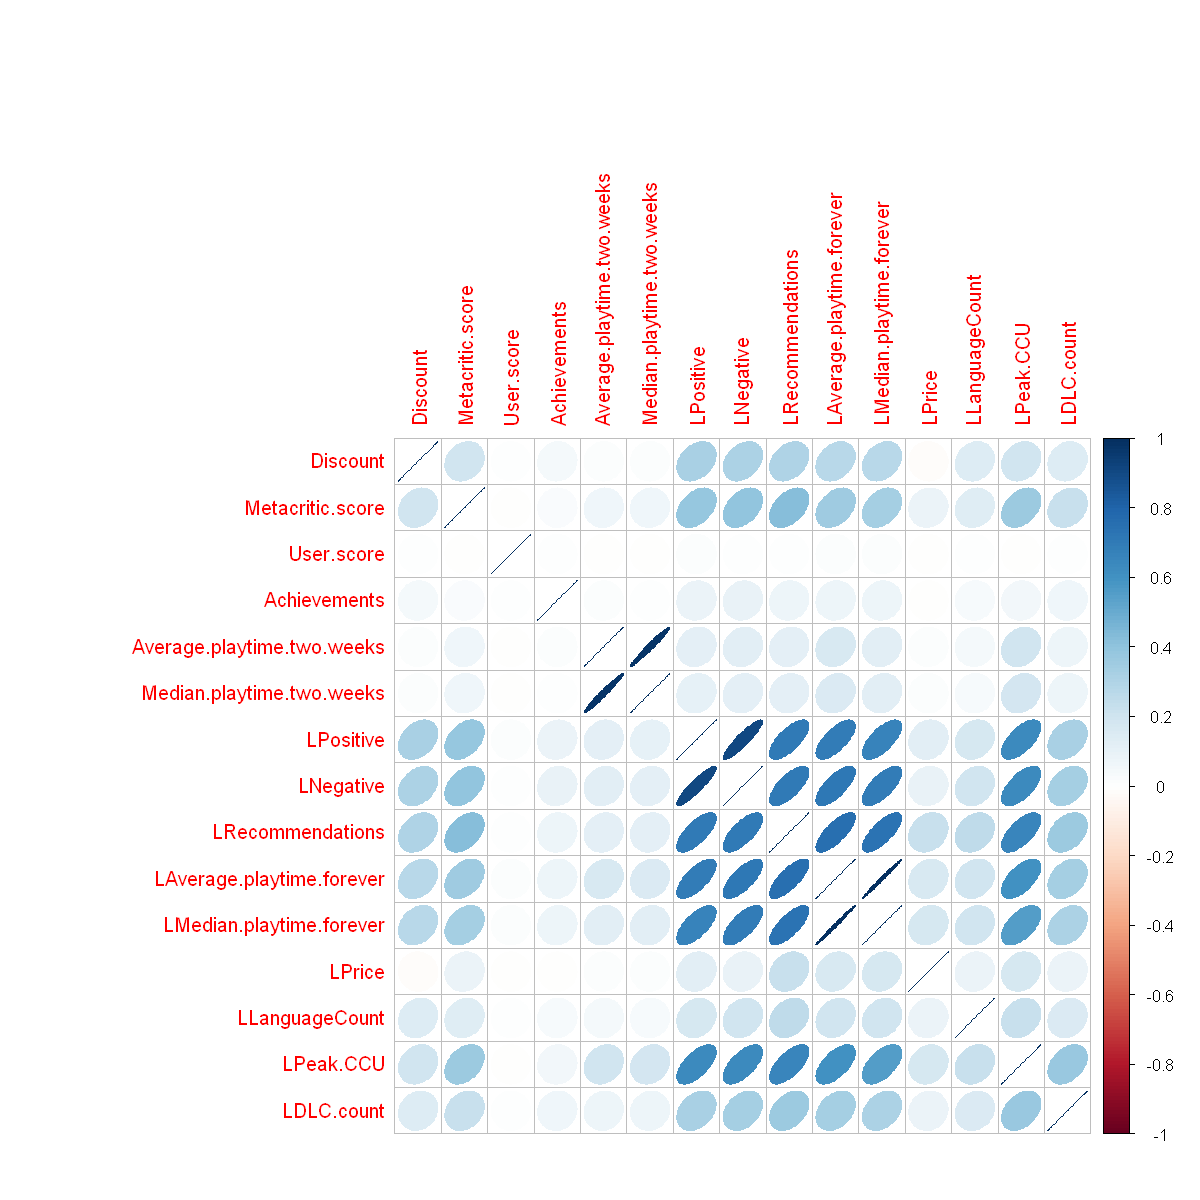

In [35]:
library(corrplot)
options(repr.plot.width = 10, repr.plot.height =10)
corrplot(cor(data_quanti),method="ellipse")

# PCA

In [47]:
library(FactoMineR) 
library(factoextra)


Warning message:
"le package 'FactoMineR' a été compilé avec la version R 4.5.3"
Warning message:
"le package 'factoextra' a été compilé avec la version R 4.5.3"
Welcome to factoextra!

Want to learn more? See two factoextra-related books at https://www.datanovia.com/en/product/practical-guide-to-principal-component-methods-in-r/



,eigenvalue,percentage of variance,cumulative percentage of variance
comp 1,5.29850005,35.32333368,35.32333
comp 2,1.91527062,12.76847078,48.09180
comp 3,1.05434667,7.02897781,55.12078
comp 4,1.00045417,6.66969450,61.79048
comp 5,0.99842311,6.65615404,68.44663
comp 6,0.96346454,6.42309696,74.86973
comp 7,0.84749101,5.64994006,80.51967
comp 8,0.79511150,5.30074336,85.82041
comp 9,0.74986375,4.99909168,90.81950
comp 10,0.57535886,3.83572571,94.65523


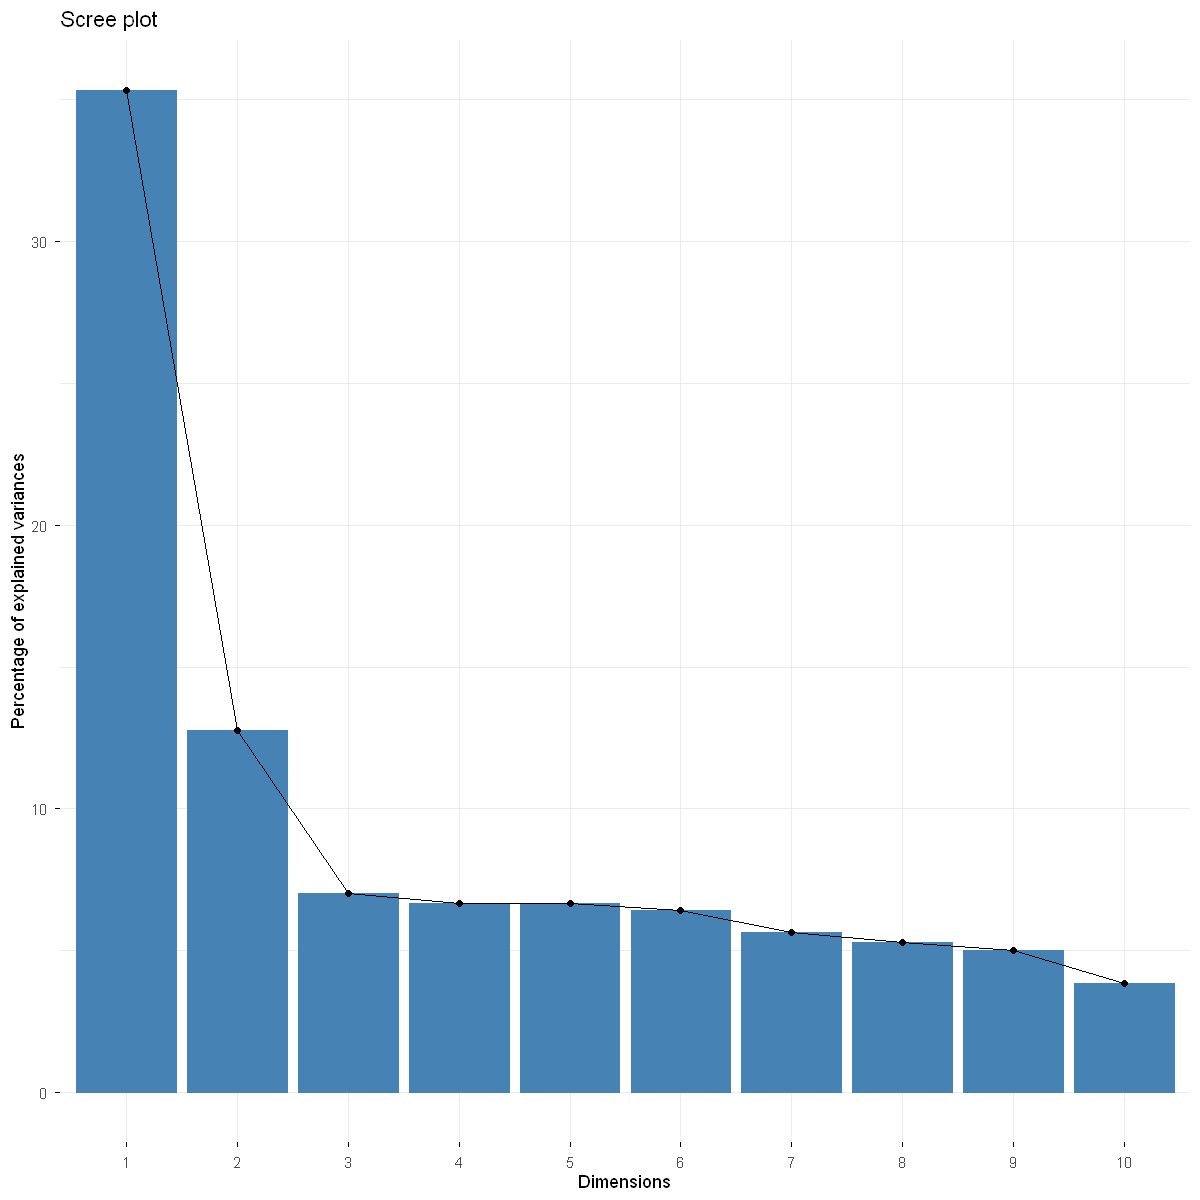

In [37]:
res.pca <- PCA(data_quanti,ncp = ncol(data_quanti), scale.unit = TRUE, graph = FALSE)
fviz_eig(res.pca)
res.pca$eig

**Commentaires**: on va décider d'expliquer au moins 80% de la variance donc on va garder 7 dimensions

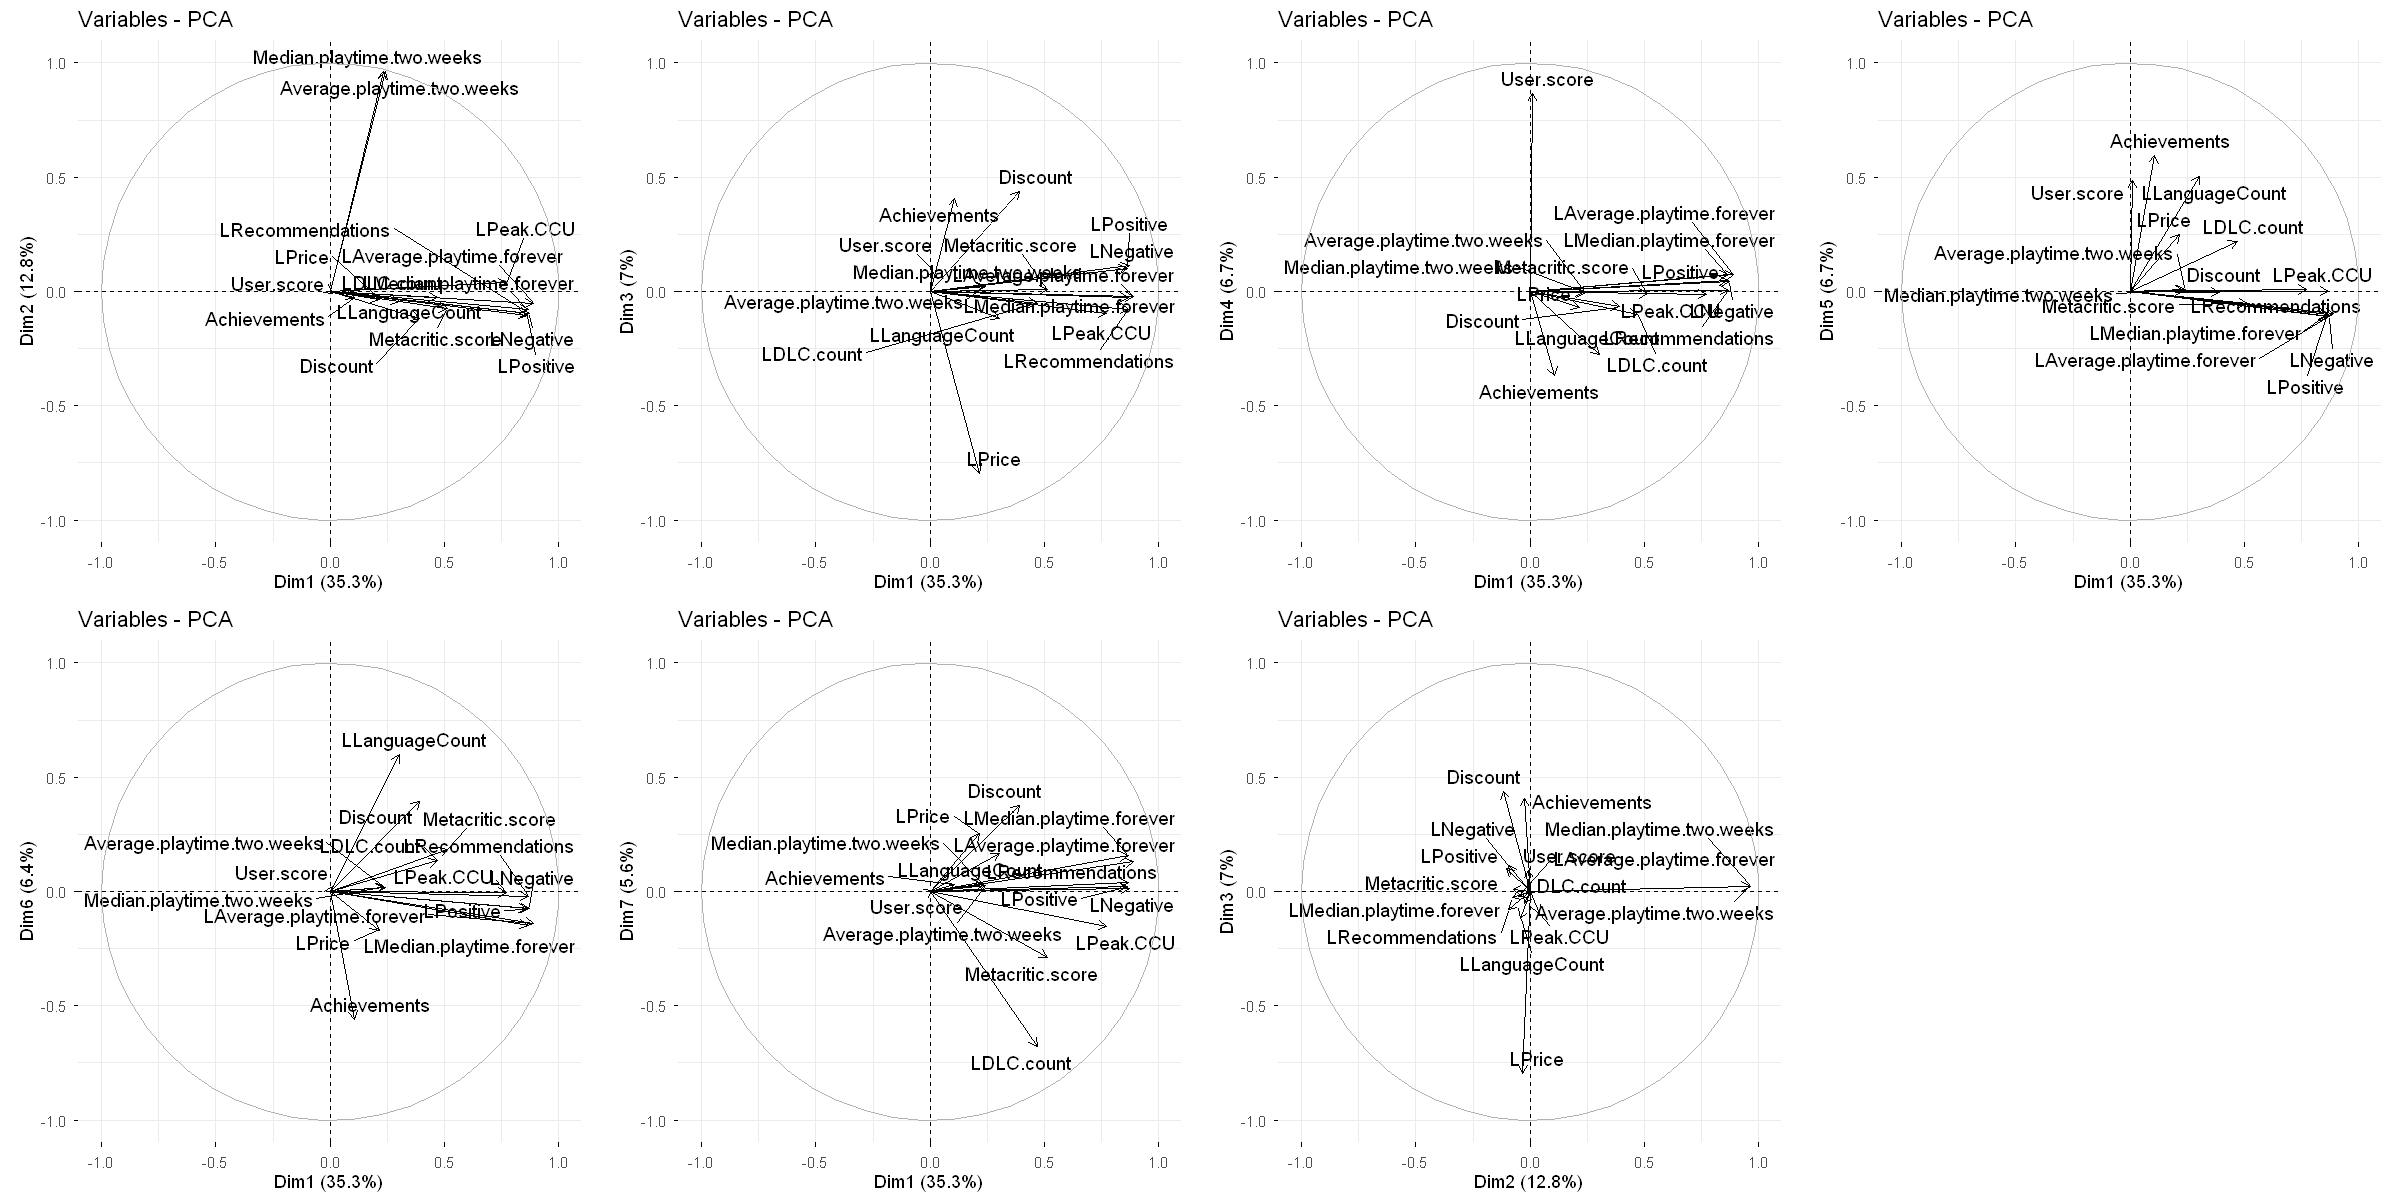

In [39]:
options(repr.plot.width = 20, repr.plot.height = 10)
g1=fviz_pca_var(res.pca,axes = c(1,2),repel=TRUE)
g2=fviz_pca_var(res.pca,axes = c(1,3),repel=TRUE)
g3=fviz_pca_var(res.pca,axes = c(1,4),repel=TRUE)
g4=fviz_pca_var(res.pca,axes = c(1,5),repel=TRUE)
g5=fviz_pca_var(res.pca,axes = c(1,6),repel=TRUE)
g6=fviz_pca_var(res.pca,axes = c(1,7),repel=TRUE)
g7=fviz_pca_var(res.pca,axes = c(2,3),repel=TRUE)
grid.arrange(g1,g2,g3,g4,g5,g6,g7,ncol=4)

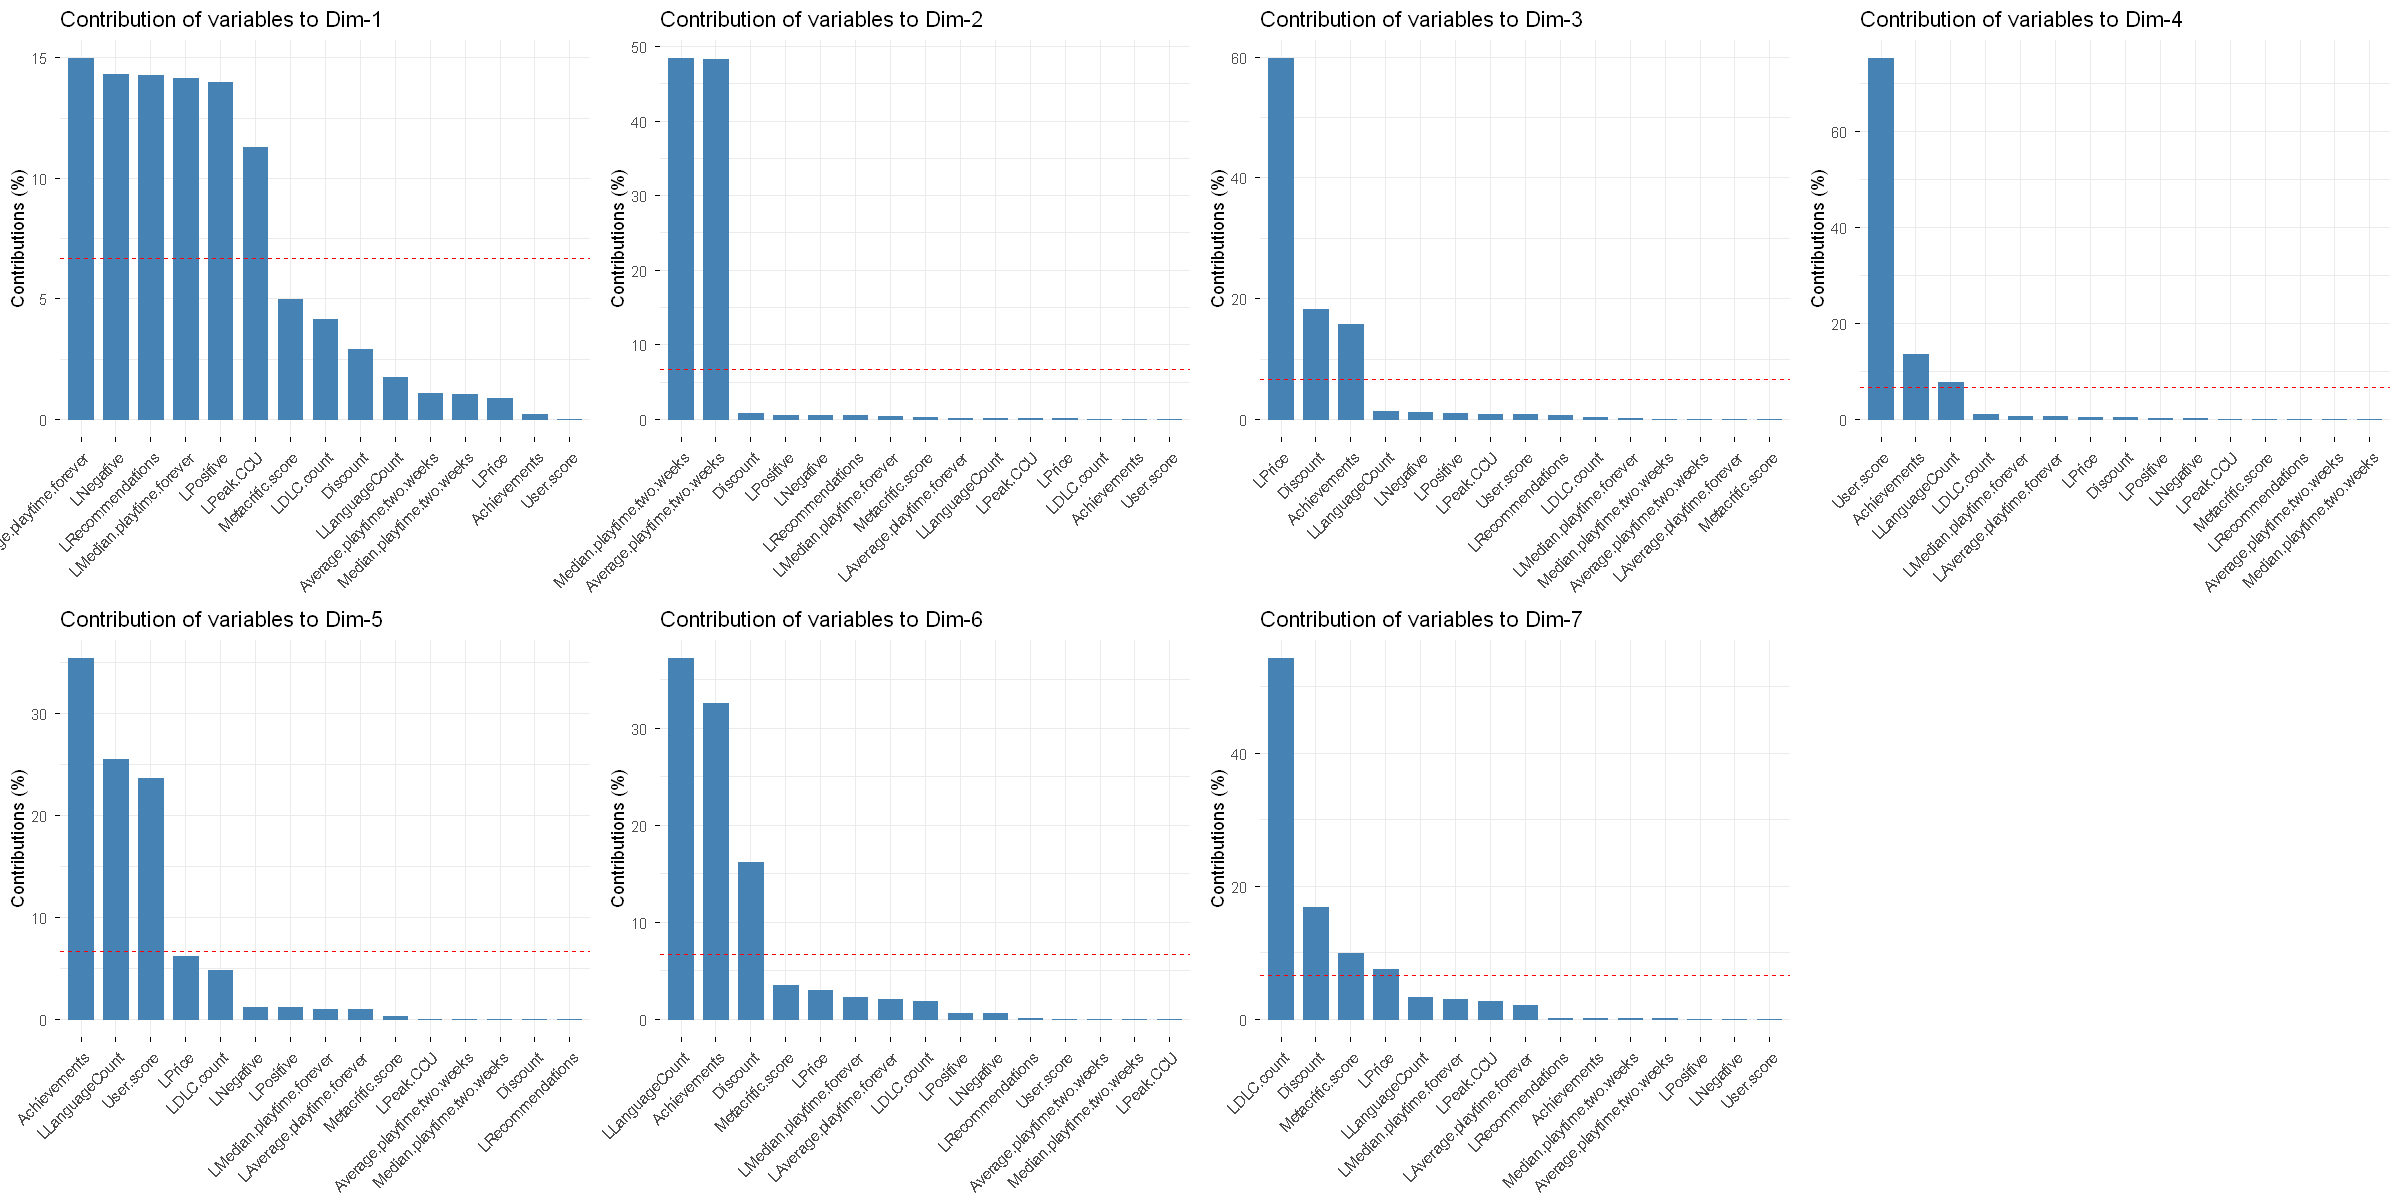

In [42]:
c1<-fviz_contrib(res.pca, choice = "var", axes = 1)
c2<-fviz_contrib(res.pca, choice = "var", axes = 2) 
c3<-fviz_contrib(res.pca, choice = "var", axes = 3)
c4<-fviz_contrib(res.pca, choice = "var", axes = 4) 
c5<-fviz_contrib(res.pca, choice = "var", axes = 5) 
c6<-fviz_contrib(res.pca, choice = "var", axes = 6)
c7<-fviz_contrib(res.pca, choice = "var", axes = 7)  
grid.arrange(c1,c2,c3,c4,c5,c6,c7,ncol=4)

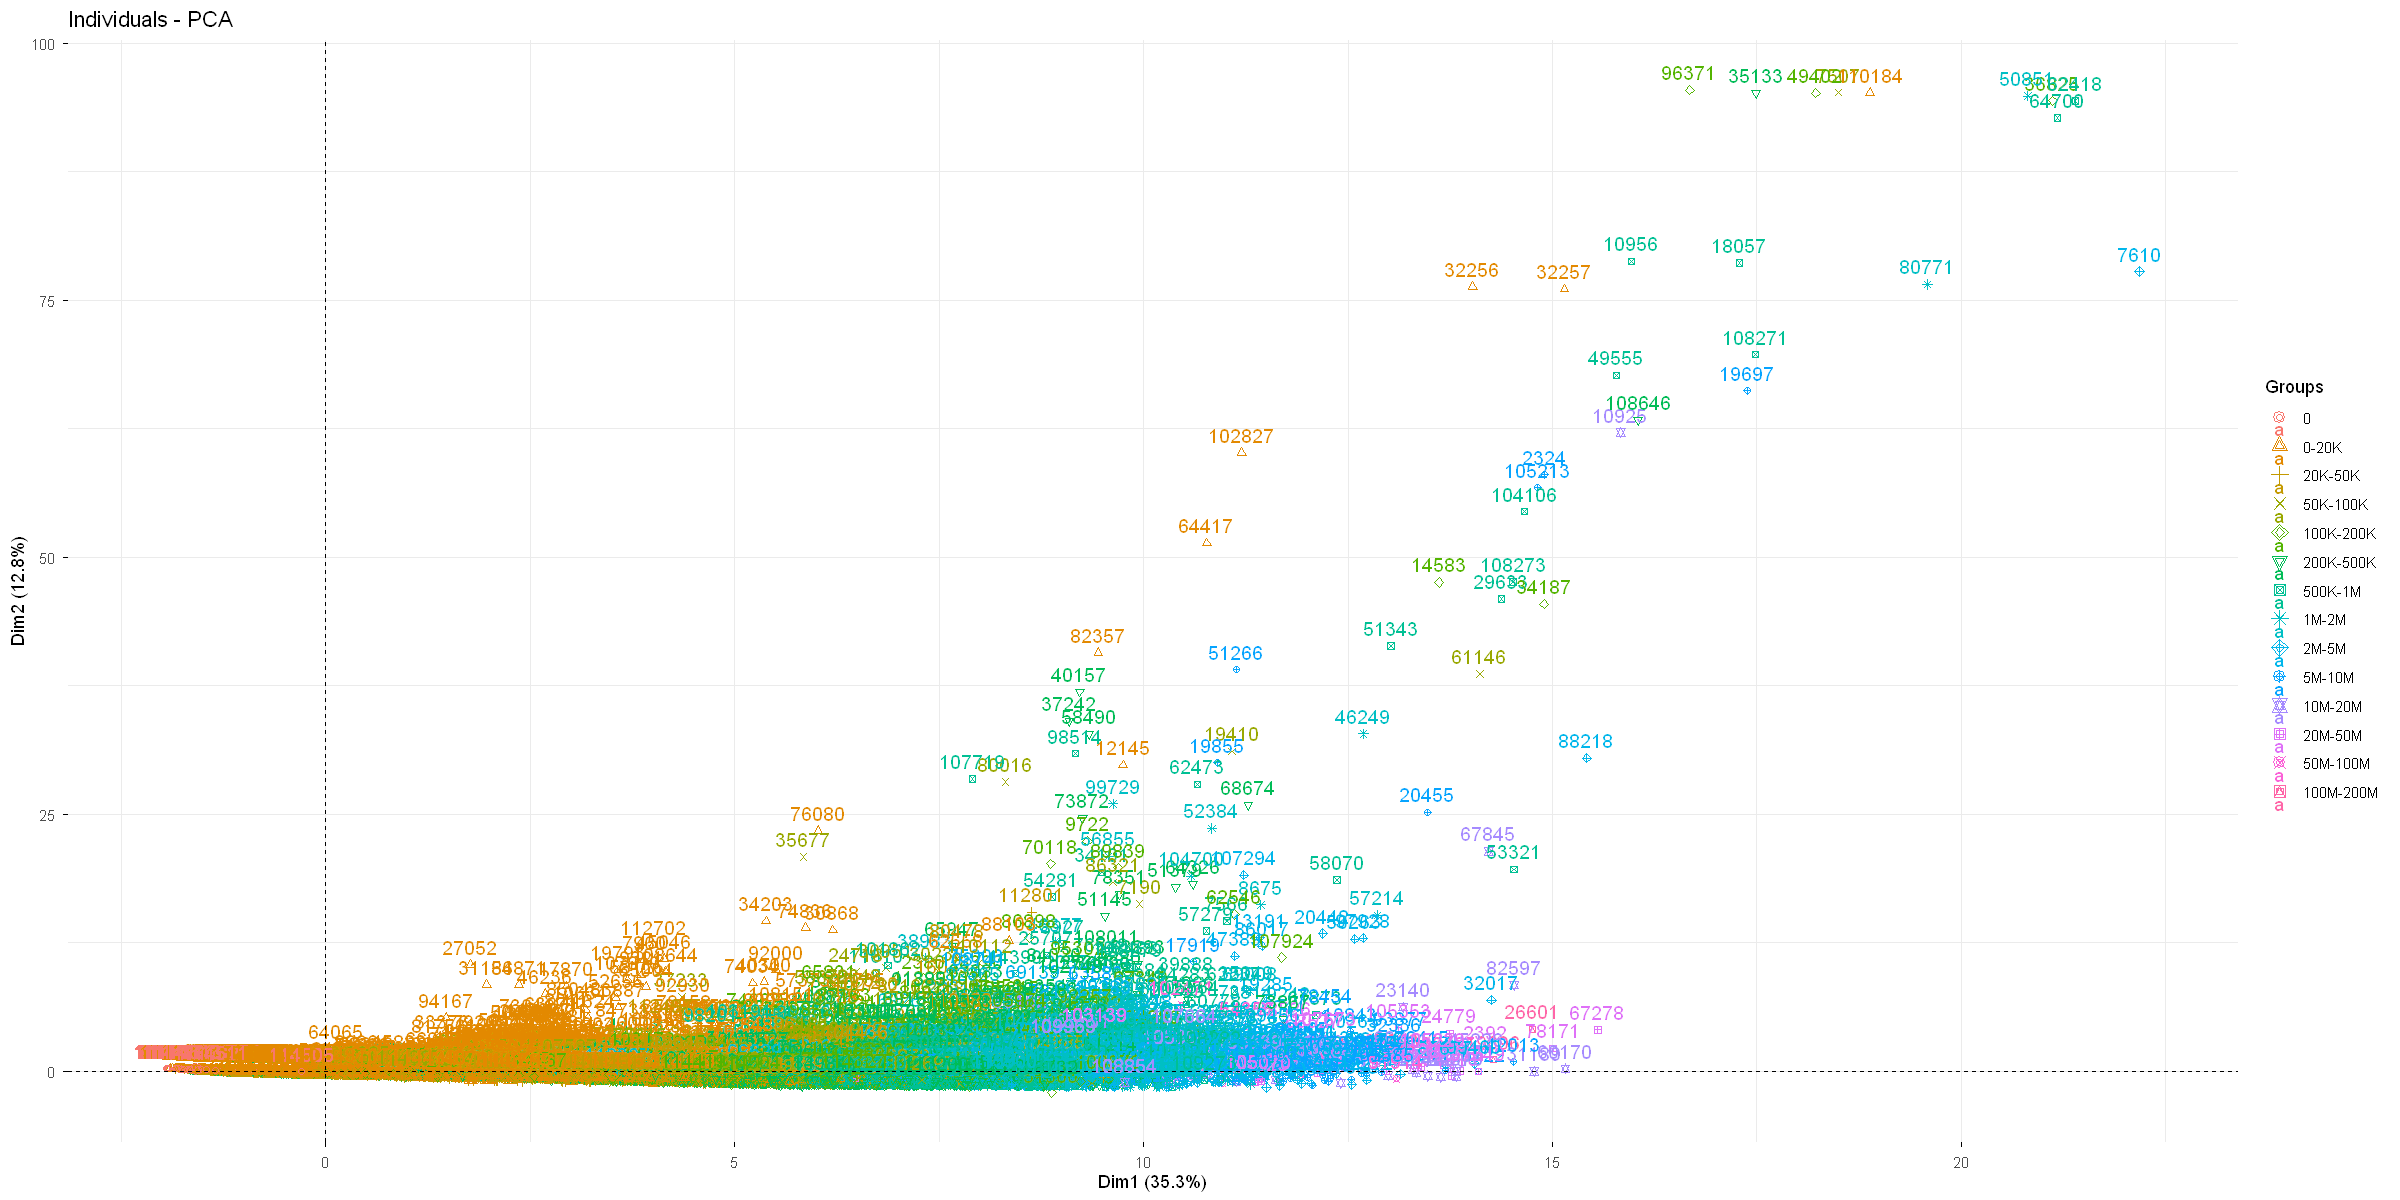

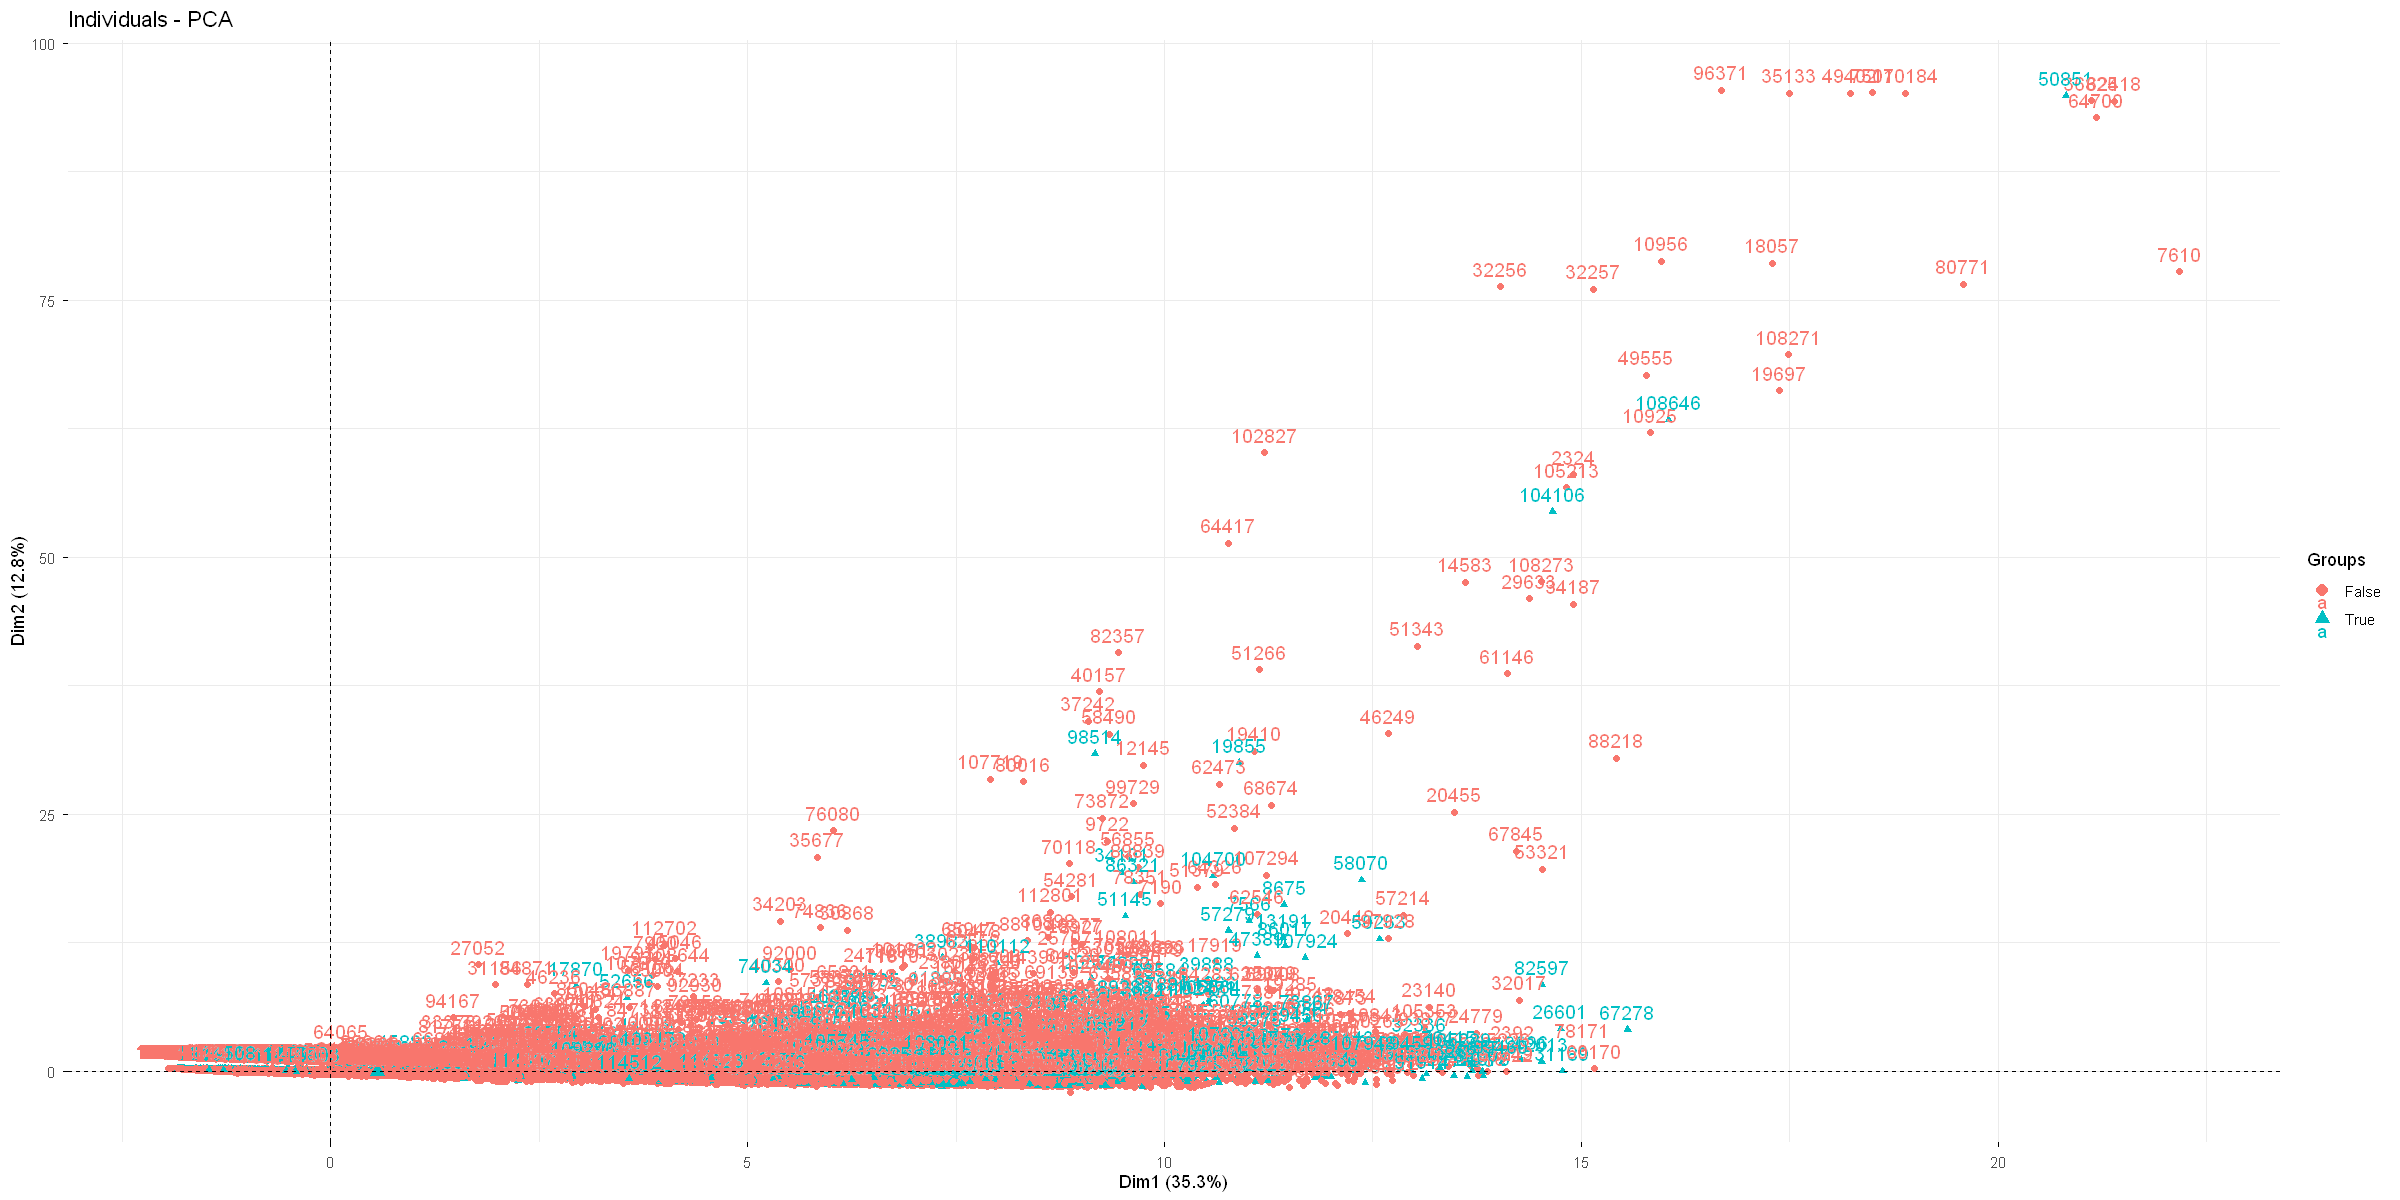

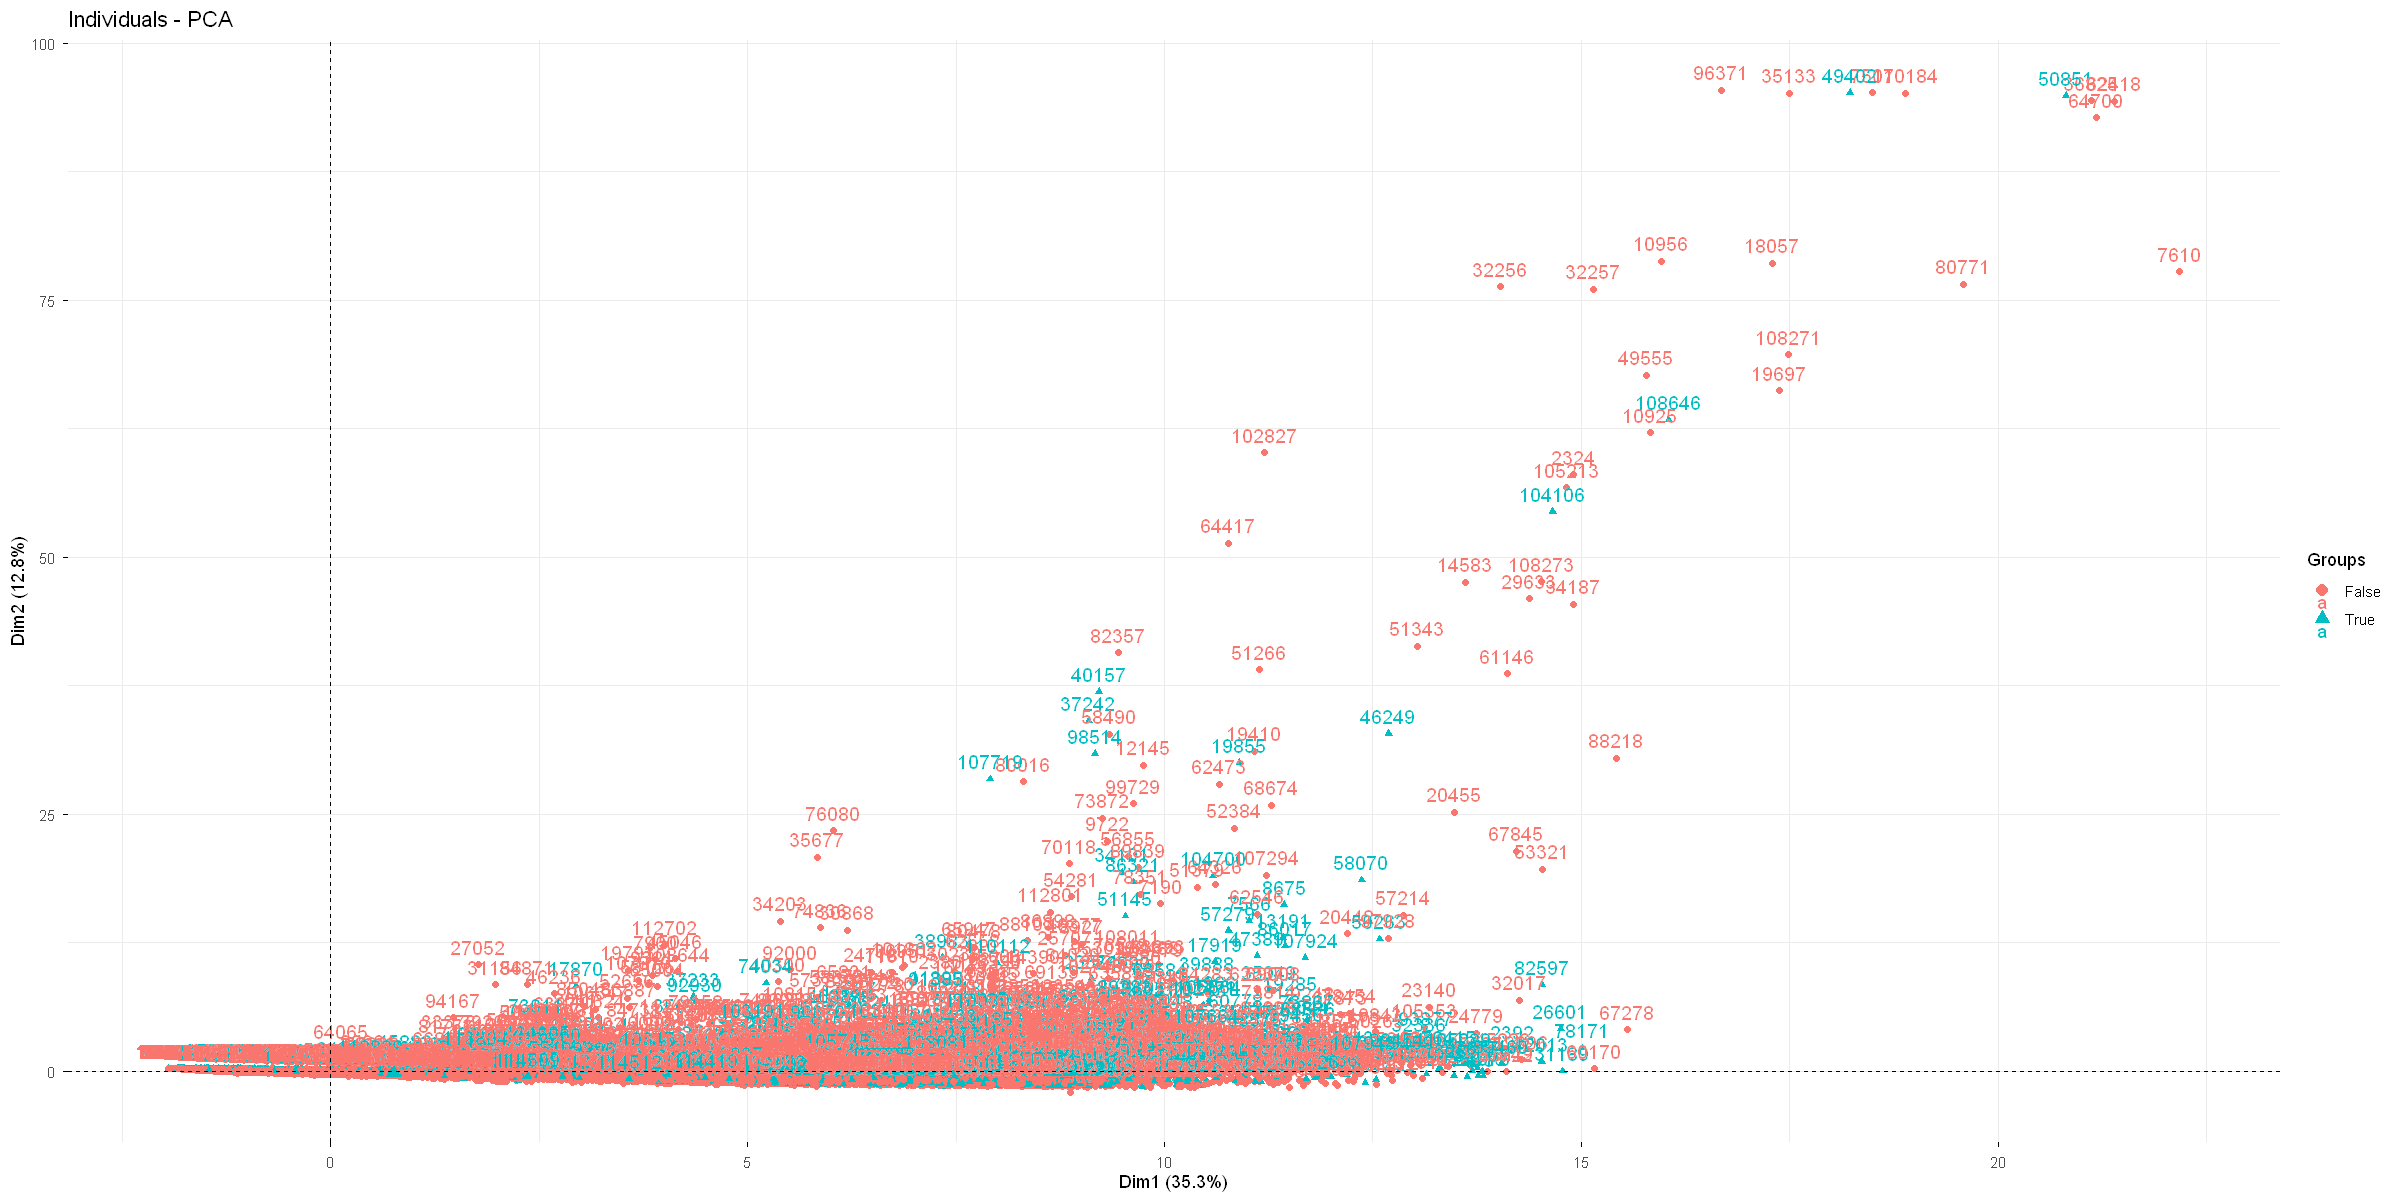

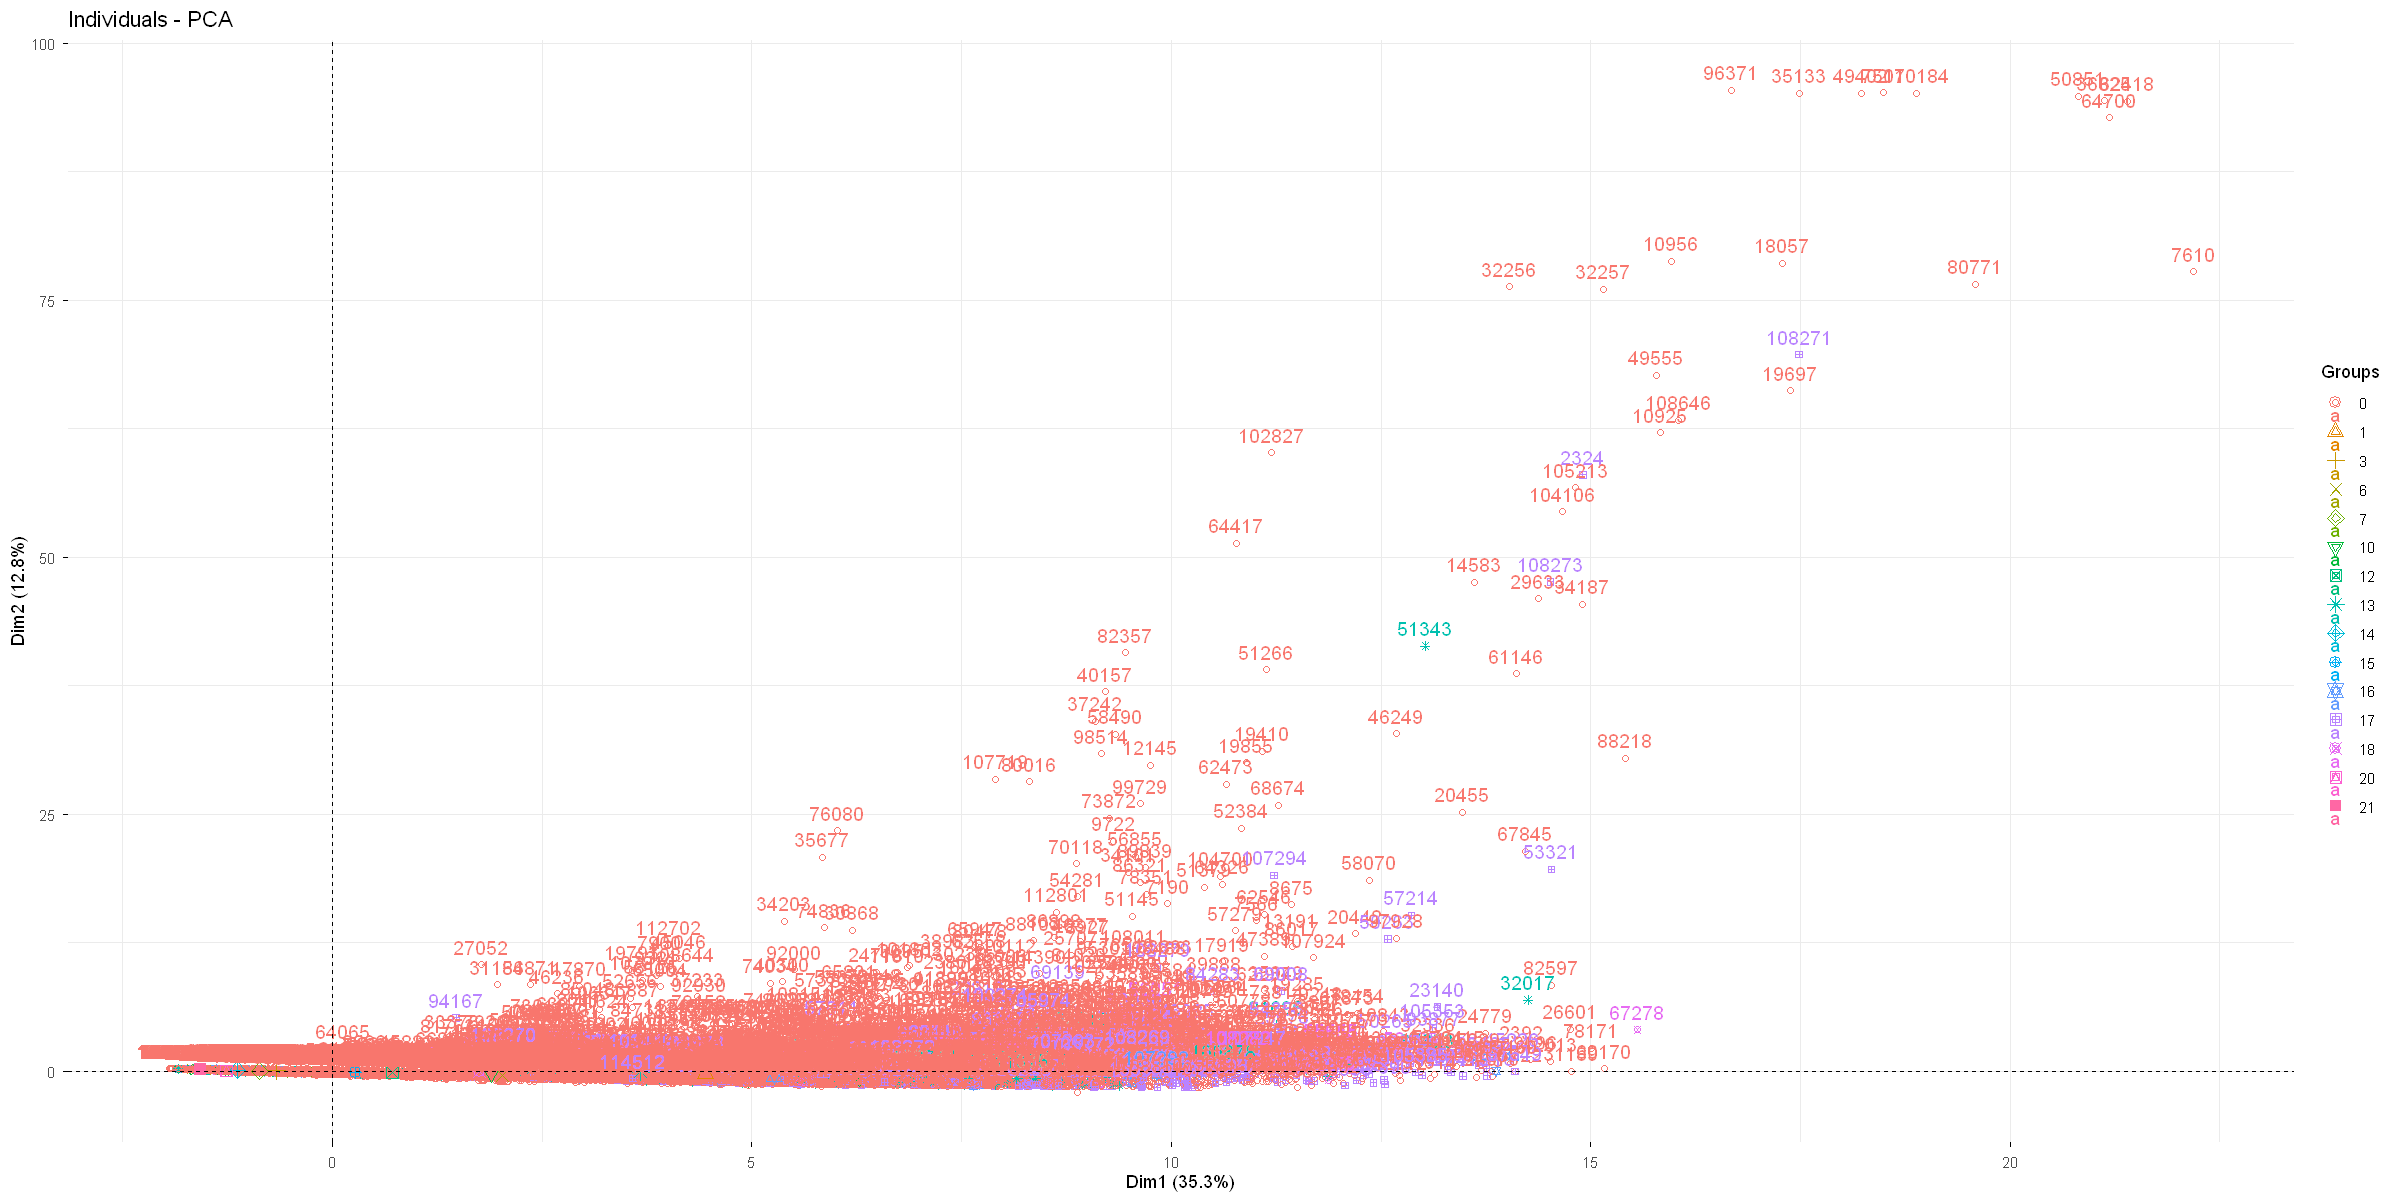

In [41]:
fviz_pca_ind(res.pca,axes = c(1,2),repel=FALSE,habillage=data_ready$Estimated.owners)
fviz_pca_ind(res.pca,axes = c(1,2),repel=FALSE,habillage=data_ready$Linux)
fviz_pca_ind(res.pca,axes = c(1,2),repel=FALSE,habillage=data_ready$Mac)
fviz_pca_ind(res.pca,axes = c(1,2),repel=FALSE,habillage=data_ready$Required.age)

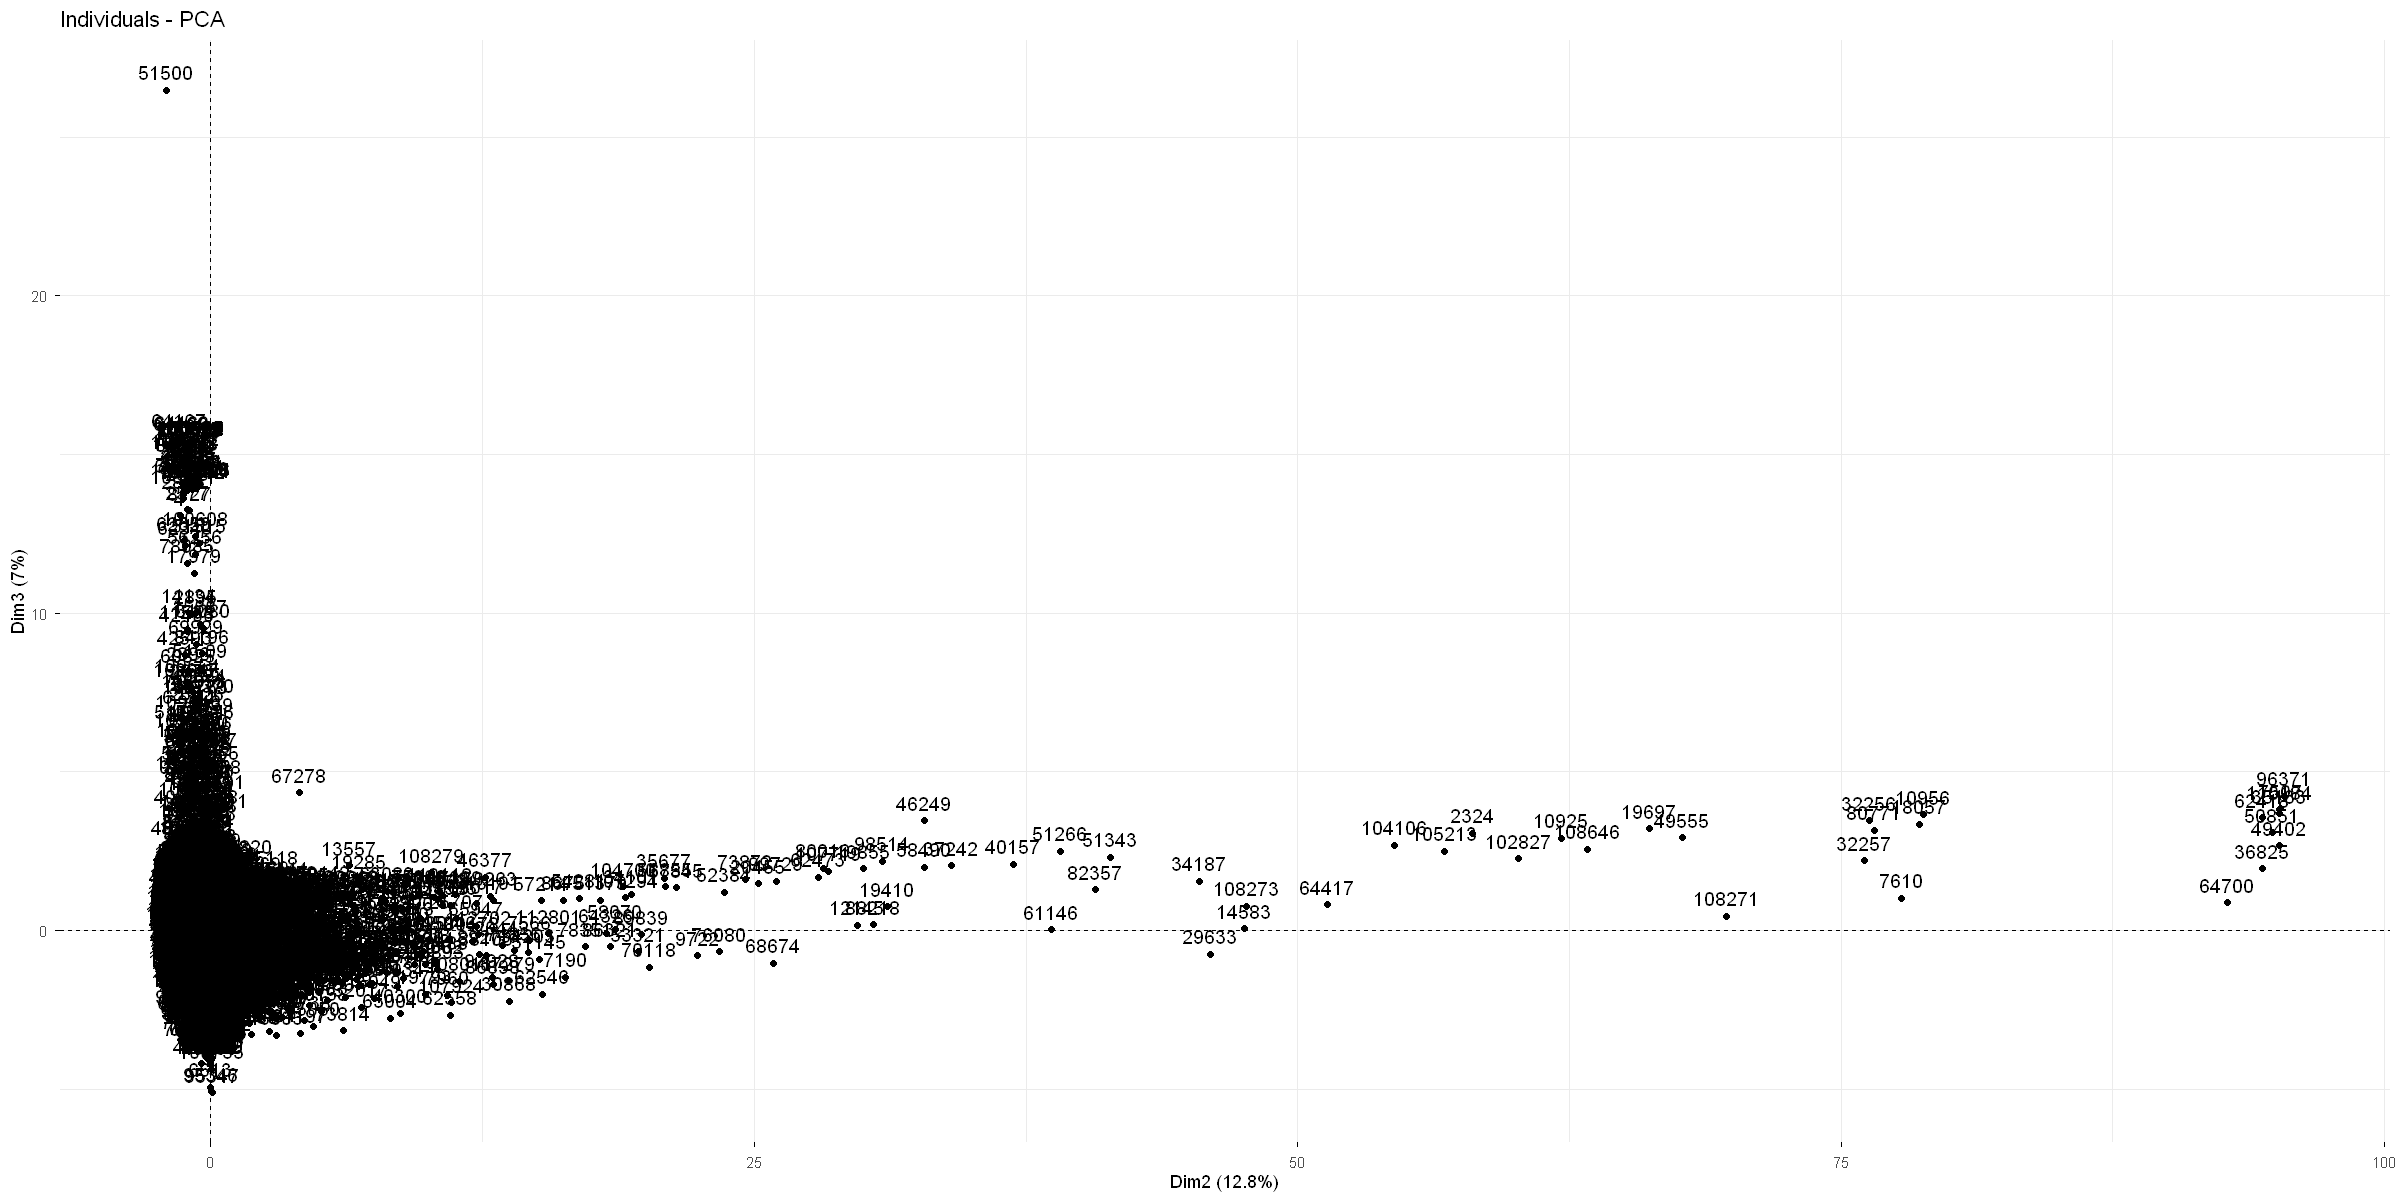

In [43]:
i3=fviz_pca_ind(res.pca,axes = c(2,3),repel=FALSE,)
i3

On remarque un outlier l'individu: 19696, 67623, 26601, 12145, 39485

In [45]:
data_ready[c('19696',"67623","26601","12145","39485","51500"),]


,Name,Release.date,Estimated.owners,Required.age,Discount,Windows,Mac,Linux,Metacritic.score,User.score,⋯,TagGenre,LPositive,LNegative,LRecommendations,LAverage.playtime.forever,LMedian.playtime.forever,LPrice,LLanguageCount,LPeak.CCU,LDLC.count
,<chr>,<fct>,<fct>,<fct>,<int>,<fct>,<fct>,<fct>,<int>,<int>,⋯,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
19696,Counter-Strike 2,1997-2013,100M-200M,0,0,True,False,True,0,0,⋯,"Action, FreeToPlay, FPS, Shooter, Multiplayer, Competitive, Team-Based, e-sports, Tactical, First-Person, PvP, OnlineCo-Op, Co-op, Strategy, Military, War, Difficult, Trading, Realistic, Fast-Paced, Moddable",15.84918,13.975079,15.390451,10.431377,8.738415,0.000000,3.401197,13.829351,0.6931472
67623,PUBG: BATTLEGROUNDS,2017,100M-200M,13,0,True,False,False,0,0,⋯,"Action, Adventure, MassivelyMultiplayer, FreeToPlay, Survival, Shooter, BattleRoyale, Multiplayer, FPS, PvP, Third-PersonShooter, OnlineCo-Op, Tactical, Co-op, First-Person, Strategy, EarlyAccess, Competitive, ThirdPerson, Team-Based, Difficult, Simulation, Stealth",14.23452,13.852313,14.376989,10.076937,8.713253,0.000000,2.890372,12.659321,0.0000000
26601,Dota 2,1997-2013,100M-200M,0,0,True,True,True,90,0,⋯,"Action, Strategy, FreeToPlay, FreetoPlay, MOBA, Multiplayer, e-sports, Team-Based, Competitive, OnlineCo-Op, PvP, Difficult, Co-op, RTS, RPG, TowerDefense, Fantasy, CharacterCustomization, ReplayValue, ActionRPG, Simulation",14.52706,13.042946,9.572898,10.897942,7.052721,0.000000,3.367296,13.343813,1.0986123
12145,Bongo Cat,2025-2026,0-20K,0,0,True,False,False,0,0,⋯,"Casual, Indie, MassivelyMultiplayer, Simulation, FreeToPlay",0.00000,0.000000,0.000000,10.416611,7.707962,0.000000,3.218876,12.008652,0.0000000
39485,Grand Theft Auto V Legacy,2015,50M-100M,17,0,True,False,False,96,0,⋯,"Action, Adventure, OpenWorld, Multiplayer, Crime, AutomobileSim, ThirdPerson, First-Person, Mature, Shooter, Singleplayer, Third-PersonShooter, Racing, Co-op, Sandbox, Atmospheric, Funny, GreatSoundtrack, Comedy, Moddable",14.36938,12.431522,14.432998,9.592742,8.673684,0.000000,2.639057,11.125084,0.0000000
51500,LOGistICAL,2017,100K-200K,0,60,True,False,False,0,0,⋯,"Casual, Indie, Strategy, Puzzle, ResourceMagement, Transportation, Education, Economy",5.27300,3.713572,5.459586,9.153664,9.153664,1.607436,1.945910,1.609438,2.0794415


# Variables qualitatives

In [34]:
library(fastDummies)


data_ready$Genres <- gsub(", ", ",", data_ready$Genres)


df_one_hot <- dummy_cols(data_ready, 
                         select_columns = "Genres", # La colonne à transformer
                         split = ",",               # Le séparateur
                         remove_selected_columns = TRUE) # Supprime l'ancienne colonne texte
head(df_one_hot)

Warning message:
"le package 'fastDummies' a été compilé avec la version R 4.5.3"


,Name,Release.date,Estimated.owners,Required.age,Discount,Windows,Mac,Linux,Metacritic.score,User.score,⋯,Genres_Movie,Genres_Documentary,Genres_Episodic,Genres_Short,Genres_Tutorial,Genres_360 Video,Genres_Gore,Genres_Nudity,Genres_Violent,Genres_Sexual Content
,<chr>,<fct>,<fct>,<fct>,<int>,<fct>,<fct>,<fct>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,! Shakabula *,2023,0-20K,0,0,True,False,False,0,0,⋯,0,0,0,0,0,0,0,0,0,0
2,! That Bastard Is Trying To Steal Our Gold !,2016,50K-100K,0,0,True,False,True,0,0,⋯,0,0,0,0,0,0,0,0,0,0
3,! Wild Russia !,2020,0-20K,0,0,True,False,False,0,0,⋯,0,0,0,0,0,0,0,0,0,0
4,!AnyWay!,2018,100K-200K,0,10,True,False,False,0,0,⋯,0,0,0,0,0,0,0,0,0,0
5,!LABrpgUP!,2018,20K-50K,0,0,True,False,False,0,0,⋯,0,0,0,0,0,0,0,0,0,0
6,#!/bin/bash,2024,0-20K,0,0,True,False,False,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [36]:
df_mca_all <- df_one_hot
df_mca_all[,-c(1:28)] <- lapply(df_one_hot[,-c(1:28)], as.factor)
summary(df_mca_all)

     Name              Release.date    Estimated.owners  Required.age   
 Length:114513      2025-2026:21812   0-20K    :75337   0      :113288  
 Class :character   2024     :18104   0        :13649   17     :   782  
 Mode  :character   2023     :13337   20K-50K  :11395   13     :   175  
                    2022     :11403   50K-100K : 5349   18     :   164  
                    2021     :10441   100K-200K: 3450   16     :    31  
                    2020     : 8746   200K-500K: 2845   10     :    26  
                    (Other)  :30670   (Other)  : 2488   (Other):    47  
    Discount       Windows          Mac          Linux       Metacritic.score
 Min.   :  0.00   False:    44   False:93260   False:98841   Min.   : 0.000  
 1st Qu.:  0.00   True :114469   True :21253   True :15672   1st Qu.: 0.000  
 Median :  0.00                                              Median : 0.000  
 Mean   : 19.62                                              Mean   : 2.703  
 3rd Qu.: 45.00           

In [37]:
data_quali_all=df_mca_all %>%
  select(where(is.factor)) 

In [38]:
summary(data_quali_all)

    Release.date    Estimated.owners  Required.age     Windows      
 2025-2026:21812   0-20K    :75337   0      :113288   False:    44  
 2024     :18104   0        :13649   17     :   782   True :114469  
 2023     :13337   20K-50K  :11395   13     :   175                 
 2022     :11403   50K-100K : 5349   18     :   164                 
 2021     :10441   100K-200K: 3450   16     :    31                 
 2020     : 8746   200K-500K: 2845   10     :    26                 
 (Other)  :30670   (Other)  : 2488   (Other):    47                 
    Mac          Linux       Genres_Accounting Genres_Animation & Modeling
 False:93260   False:98841   0:114483          0:114036                   
 True :21253   True :15672   1:    30          1:   477                   
                                                                          
                                                                          
                                                                         

## MCA

In [80]:
res.mca_all=MCA(data_quali_all, quali.sup = 7:39, graph = FALSE)
print(res.mca_all)

**Results of the Multiple Correspondence Analysis (MCA)**
The analysis was performed on 114513 individuals, described by 39 variables
*The results are available in the following objects:

   name                description                                          
1  "$eig"              "eigenvalues"                                        
2  "$var"              "results for the variables"                          
3  "$var$coord"        "coord. of the categories"                           
4  "$var$cos2"         "cos2 for the categories"                            
5  "$var$contrib"      "contributions of the categories"                    
6  "$var$v.test"       "v-test for the categories"                          
7  "$var$eta2"         "coord. of variables"                                
8  "$ind"              "results for the individuals"                        
9  "$ind$coord"        "coord. for the individuals"                         
10 "$ind$cos2"         "cos2 for the indiv

,eigenvalue,percentage of variance,cumulative percentage of variance
dim 1,0.2944532,4.206474,4.206474
dim 2,0.2396430,3.423472,7.629946
dim 3,0.2206434,3.152049,10.781994
dim 4,0.1868985,2.669978,13.451972
dim 5,0.1769492,2.527846,15.979818
dim 6,0.1757704,2.511006,18.490824


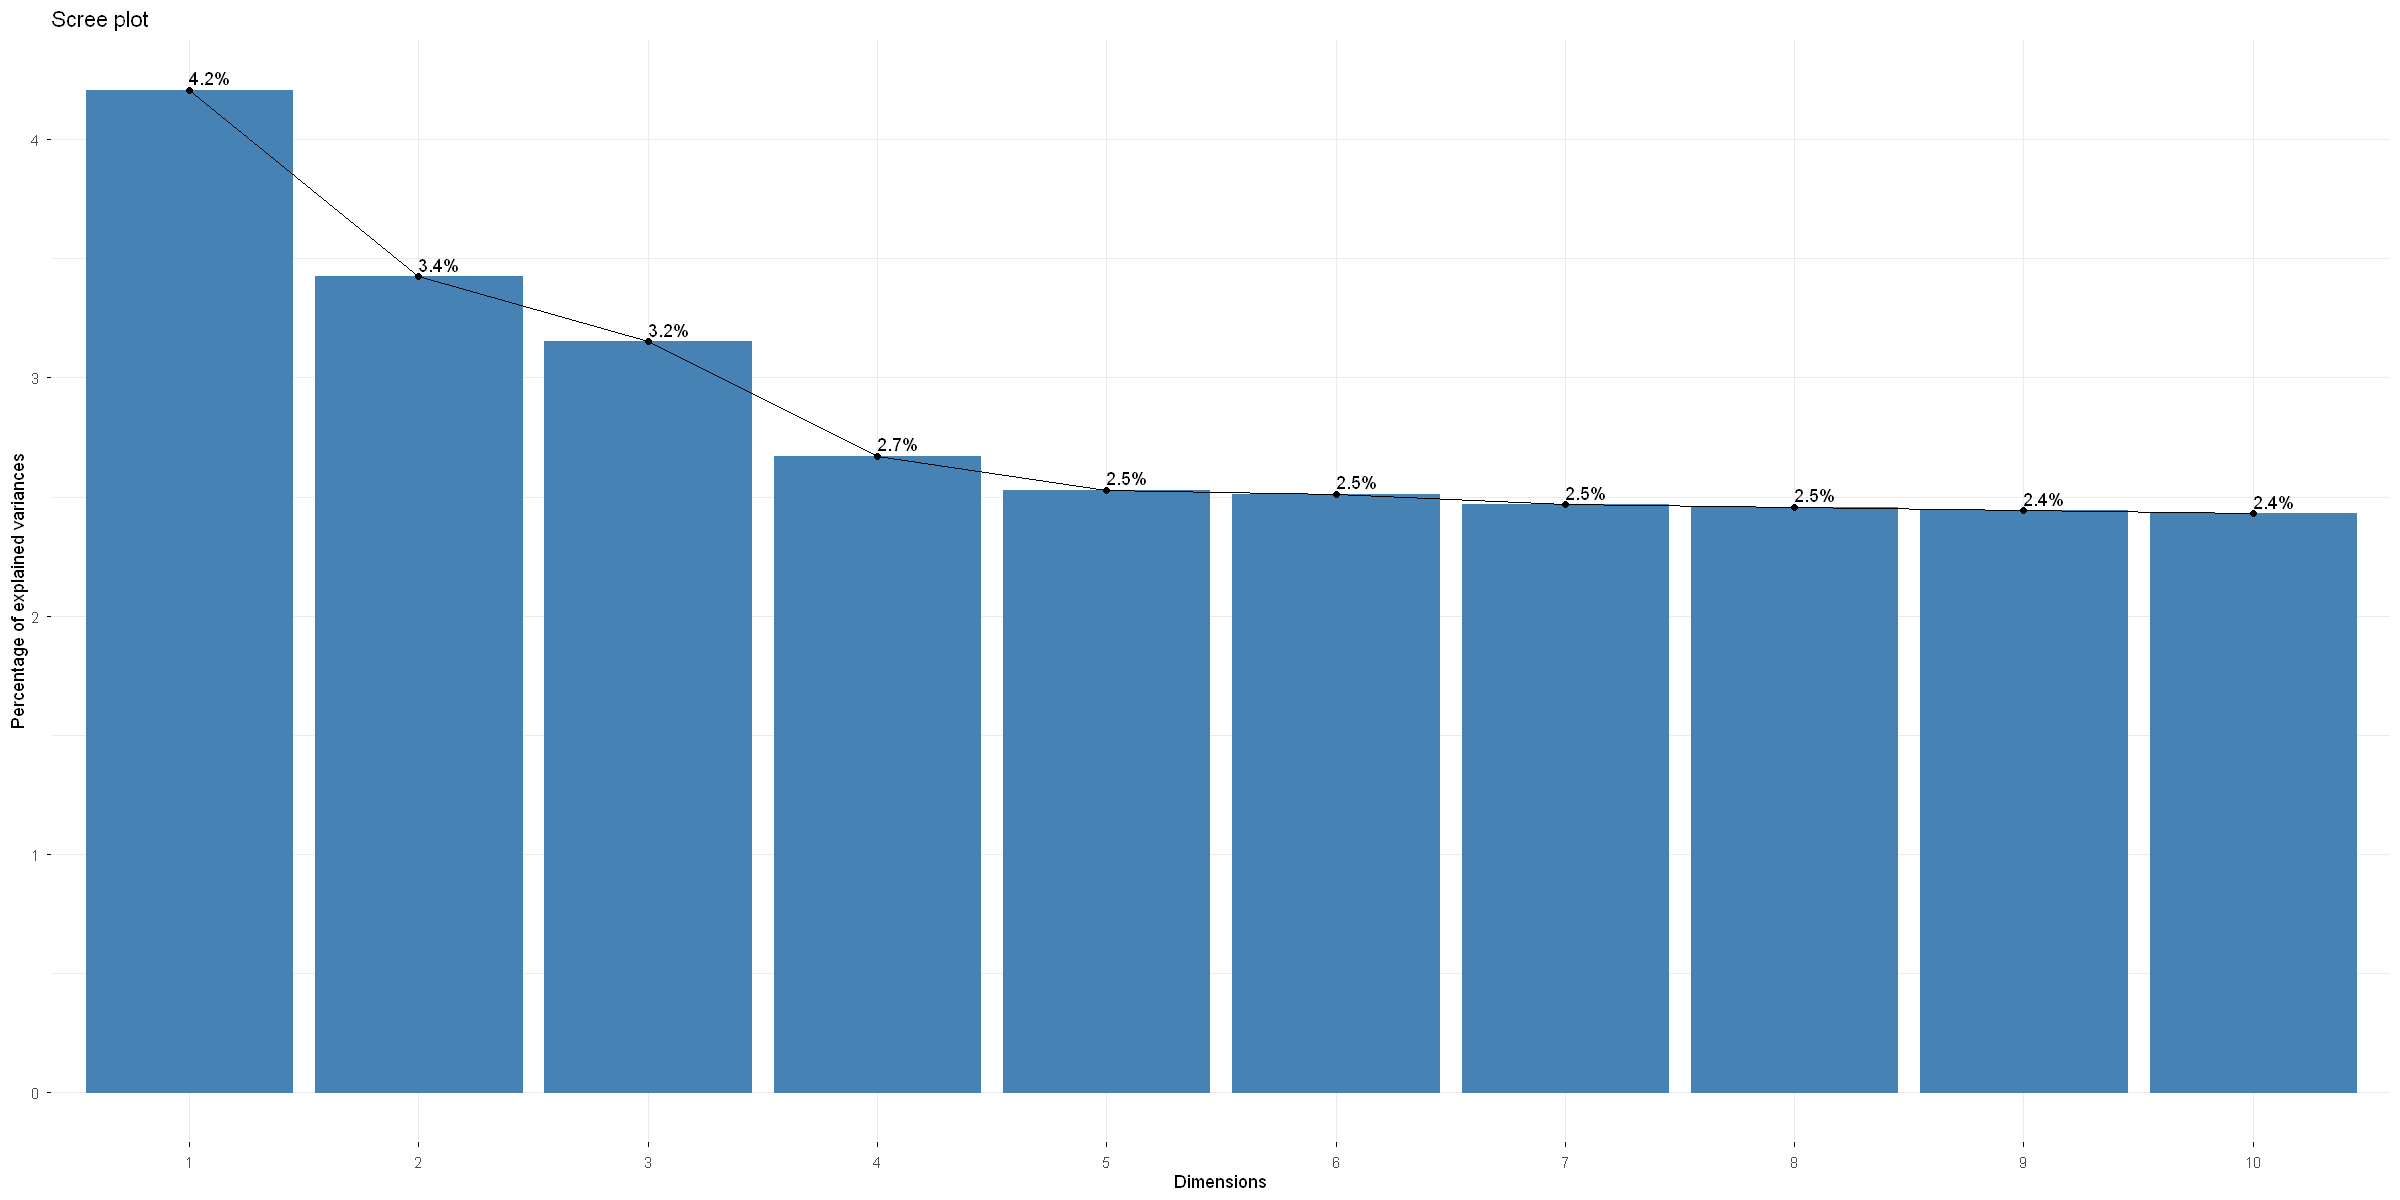

In [81]:
head(res.mca_all$eig)

fviz_screeplot(res.mca_all, addlabels=TRUE)



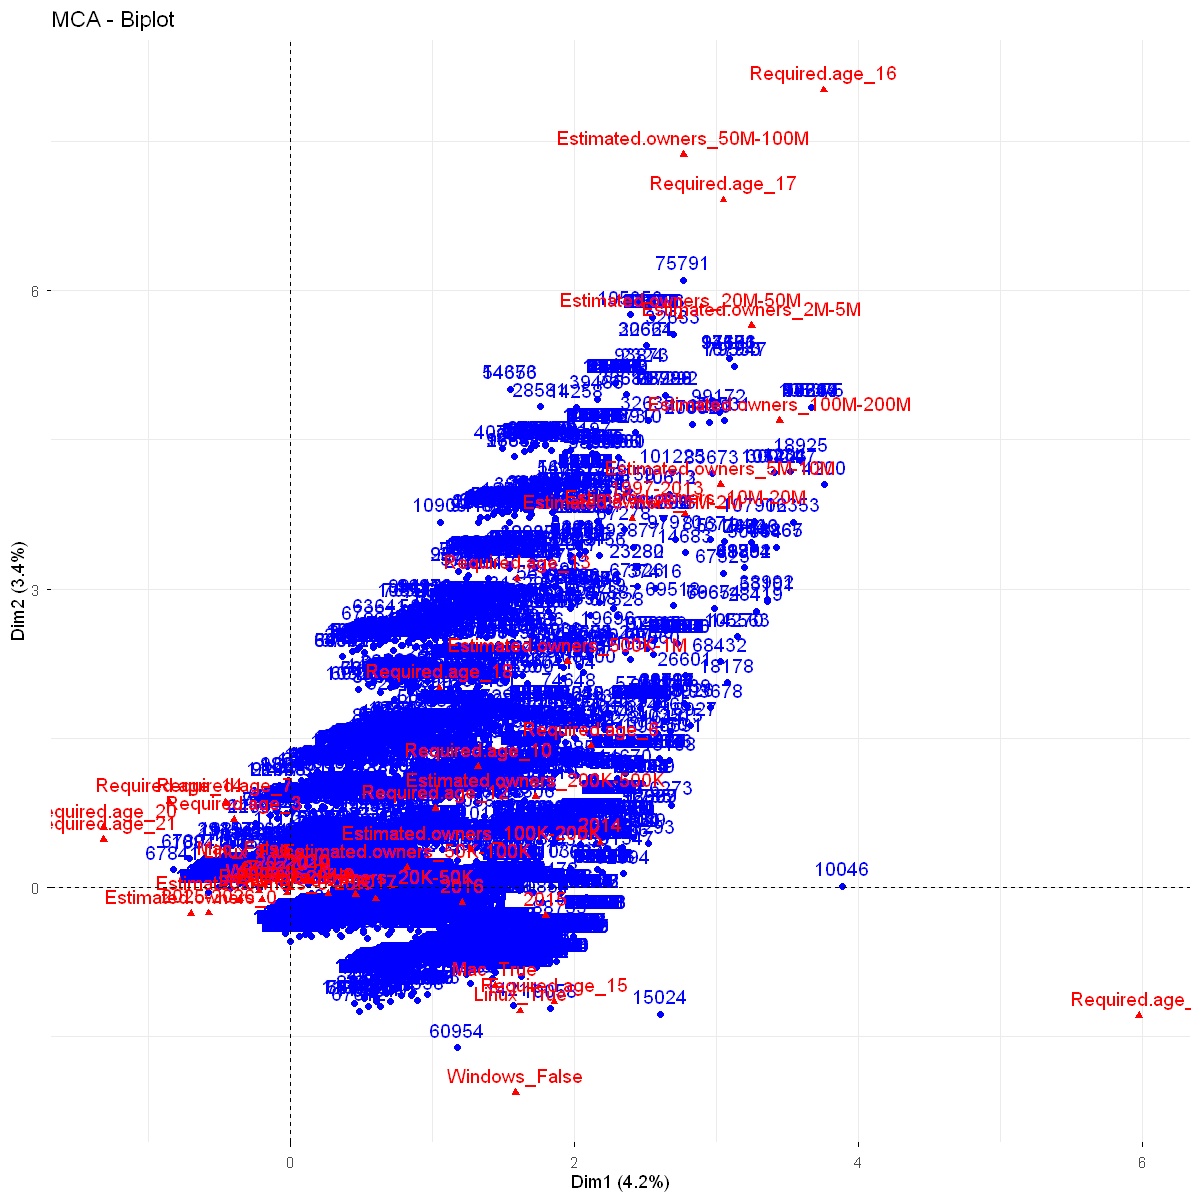

In [155]:
fviz_mca_biplot(res.mca)

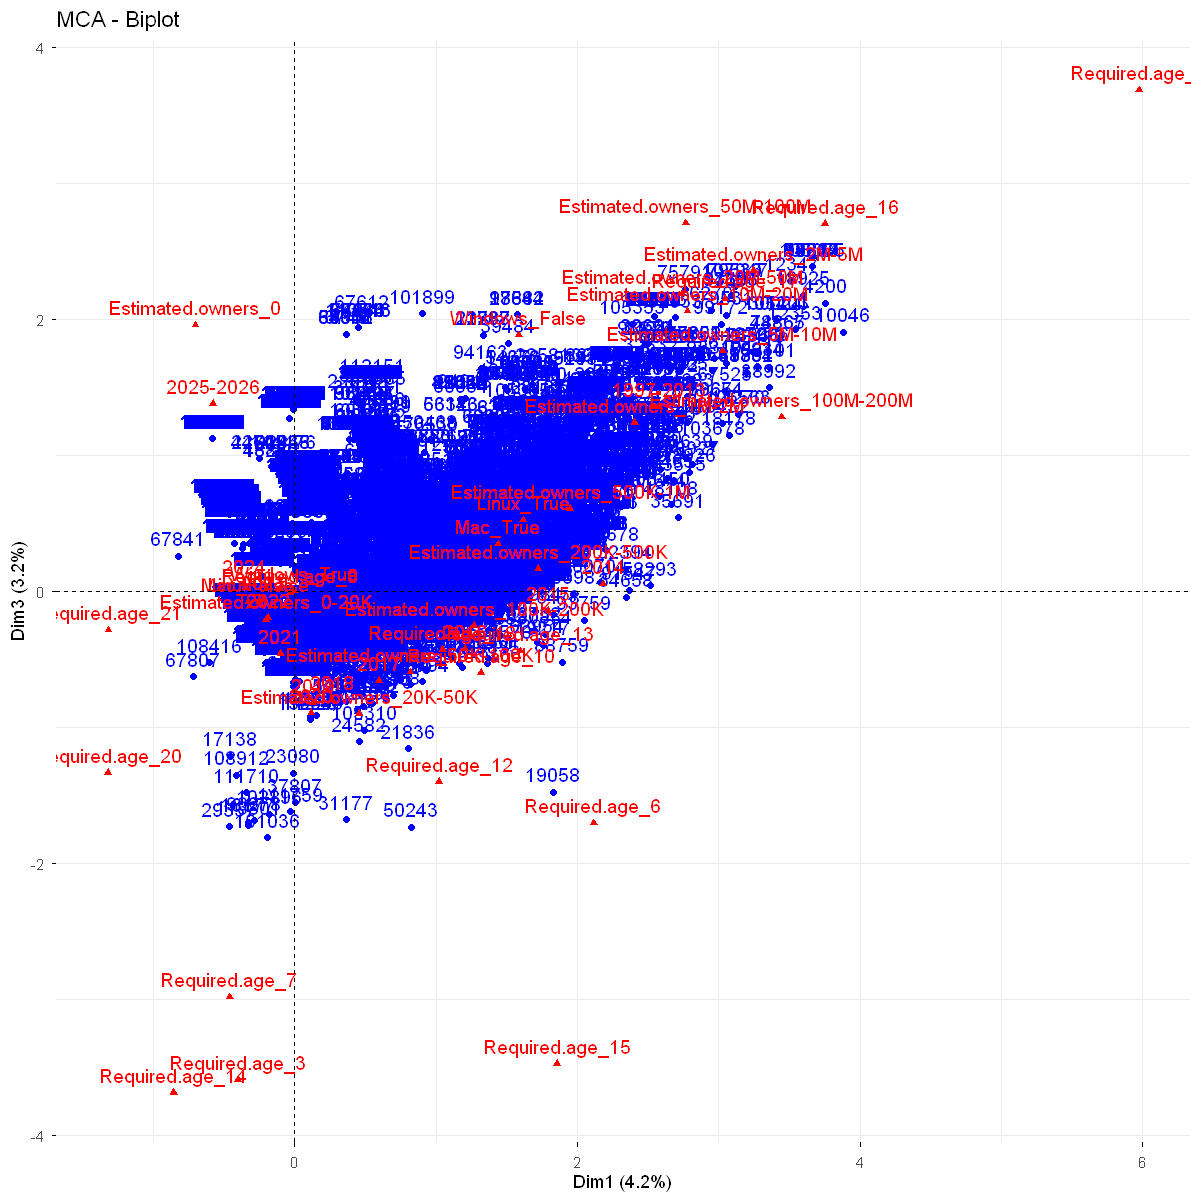

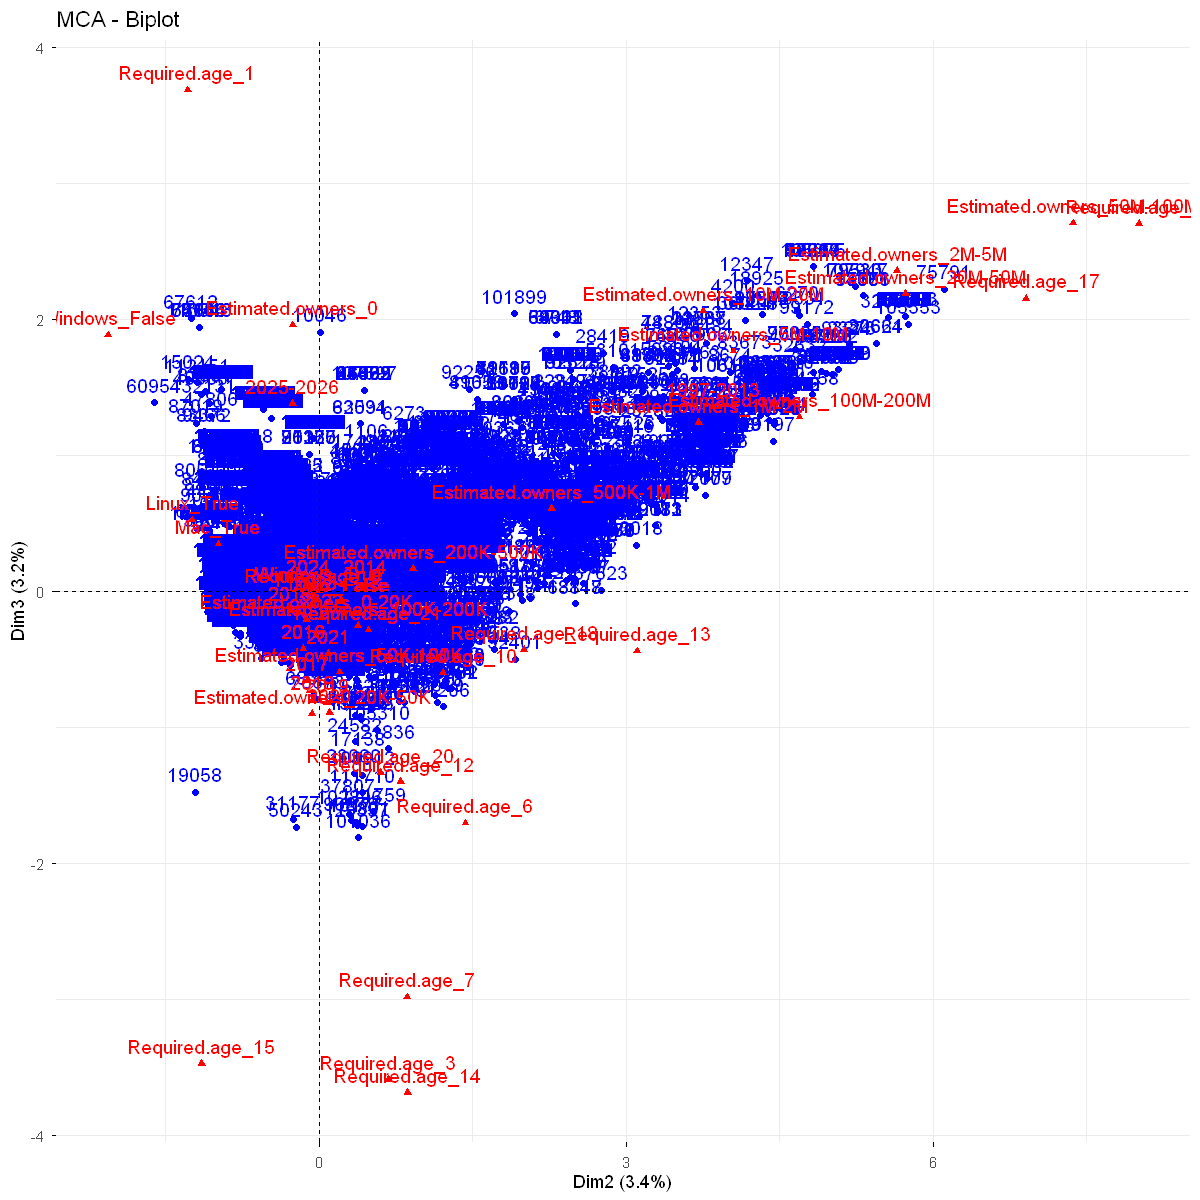

In [157]:
fviz_mca_biplot(res.mca,axes=c(1,3))
fviz_mca_biplot(res.mca,axes=c(2,3))

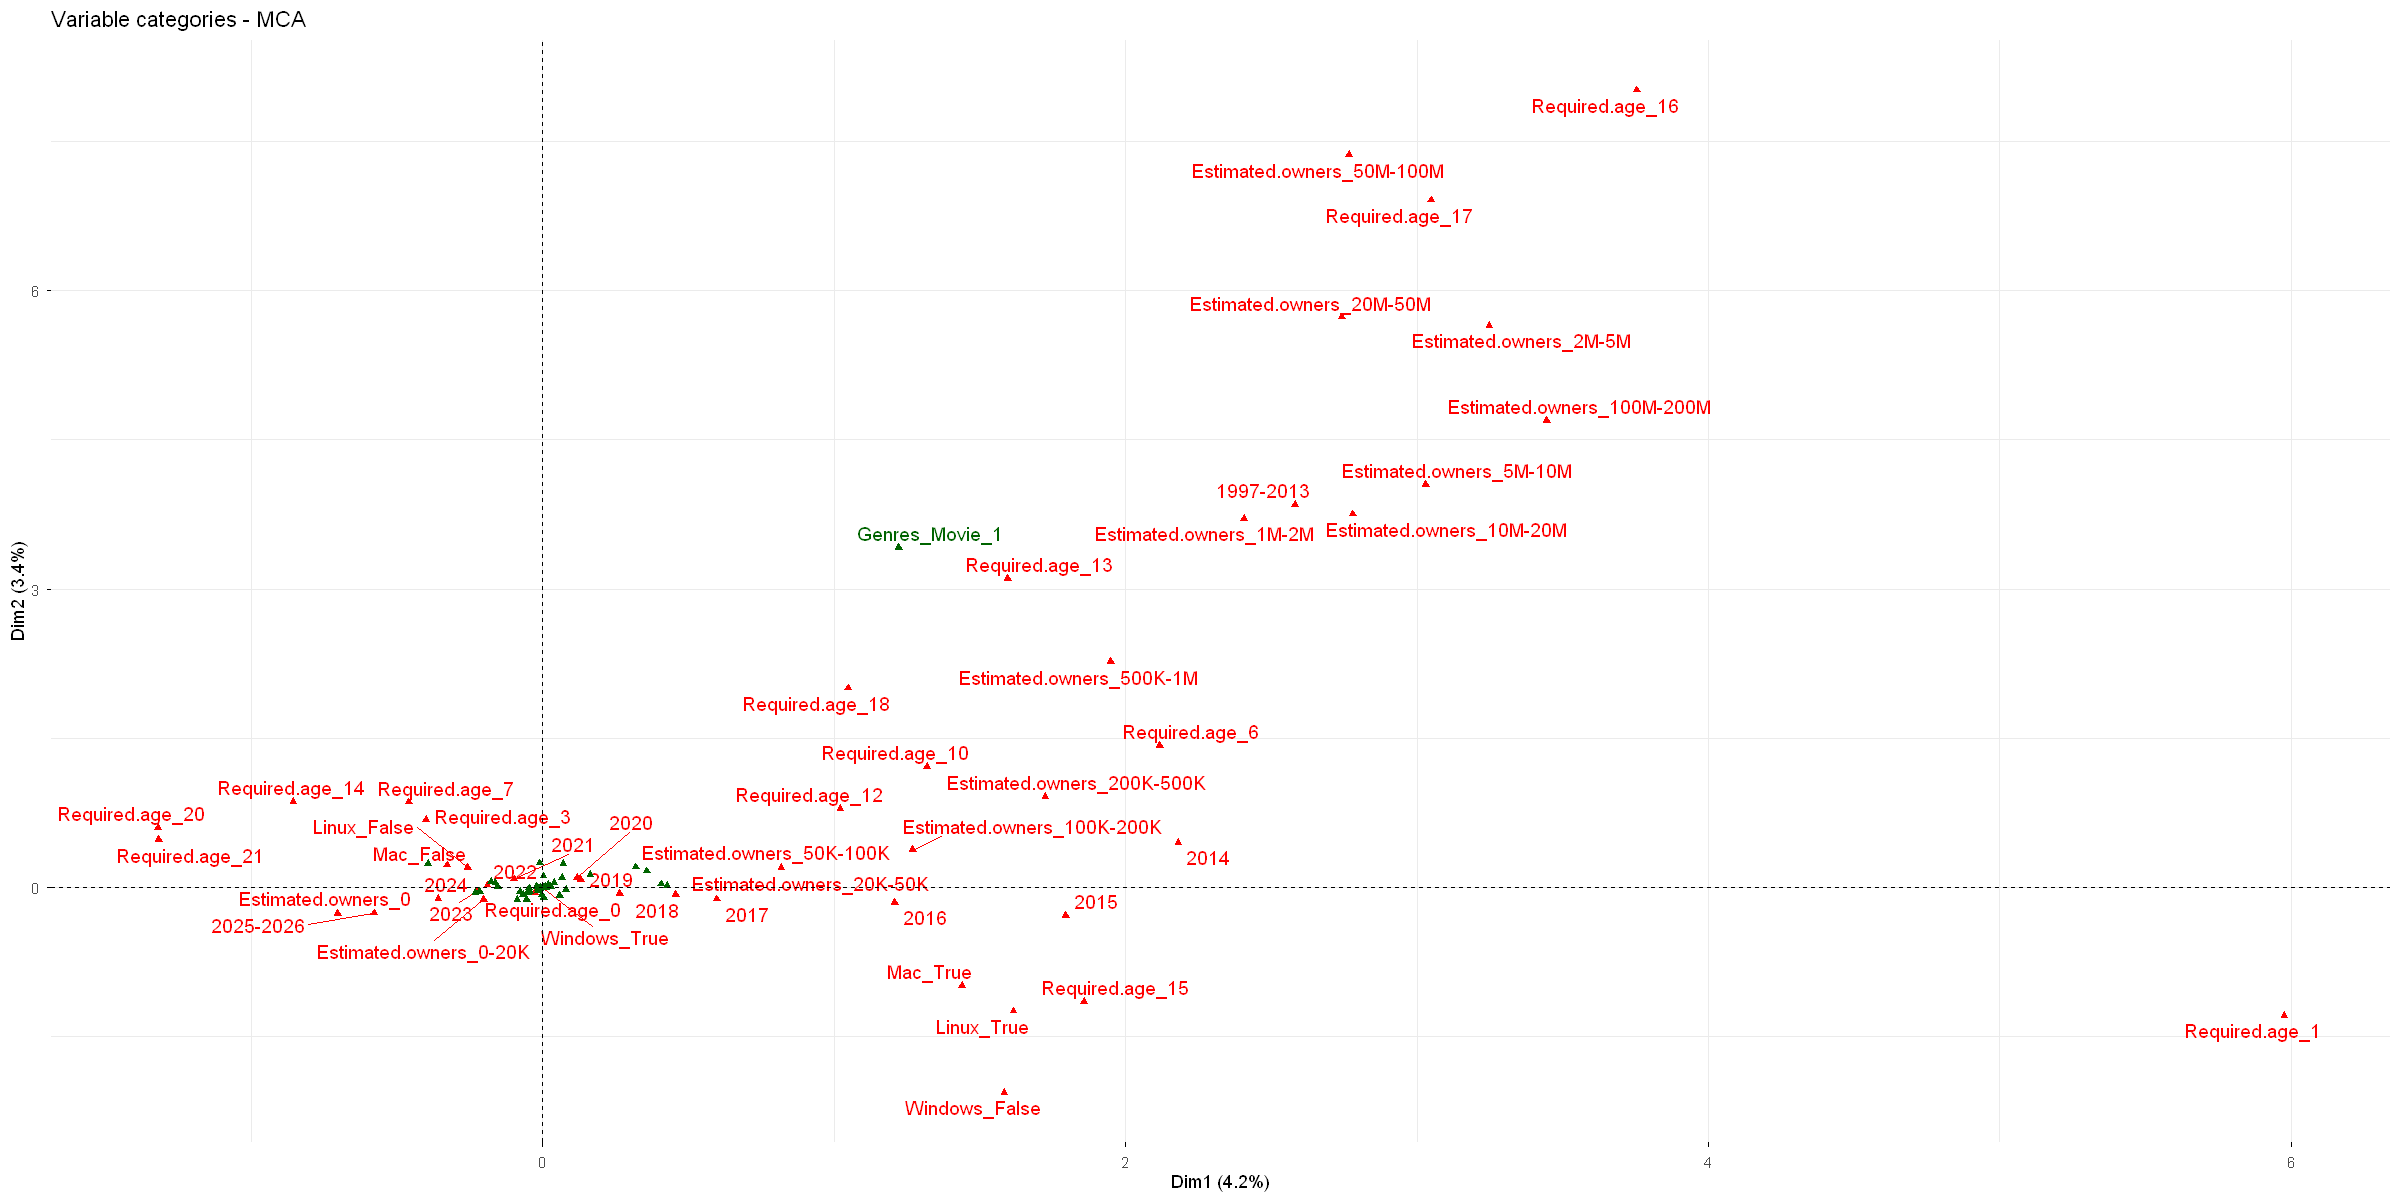

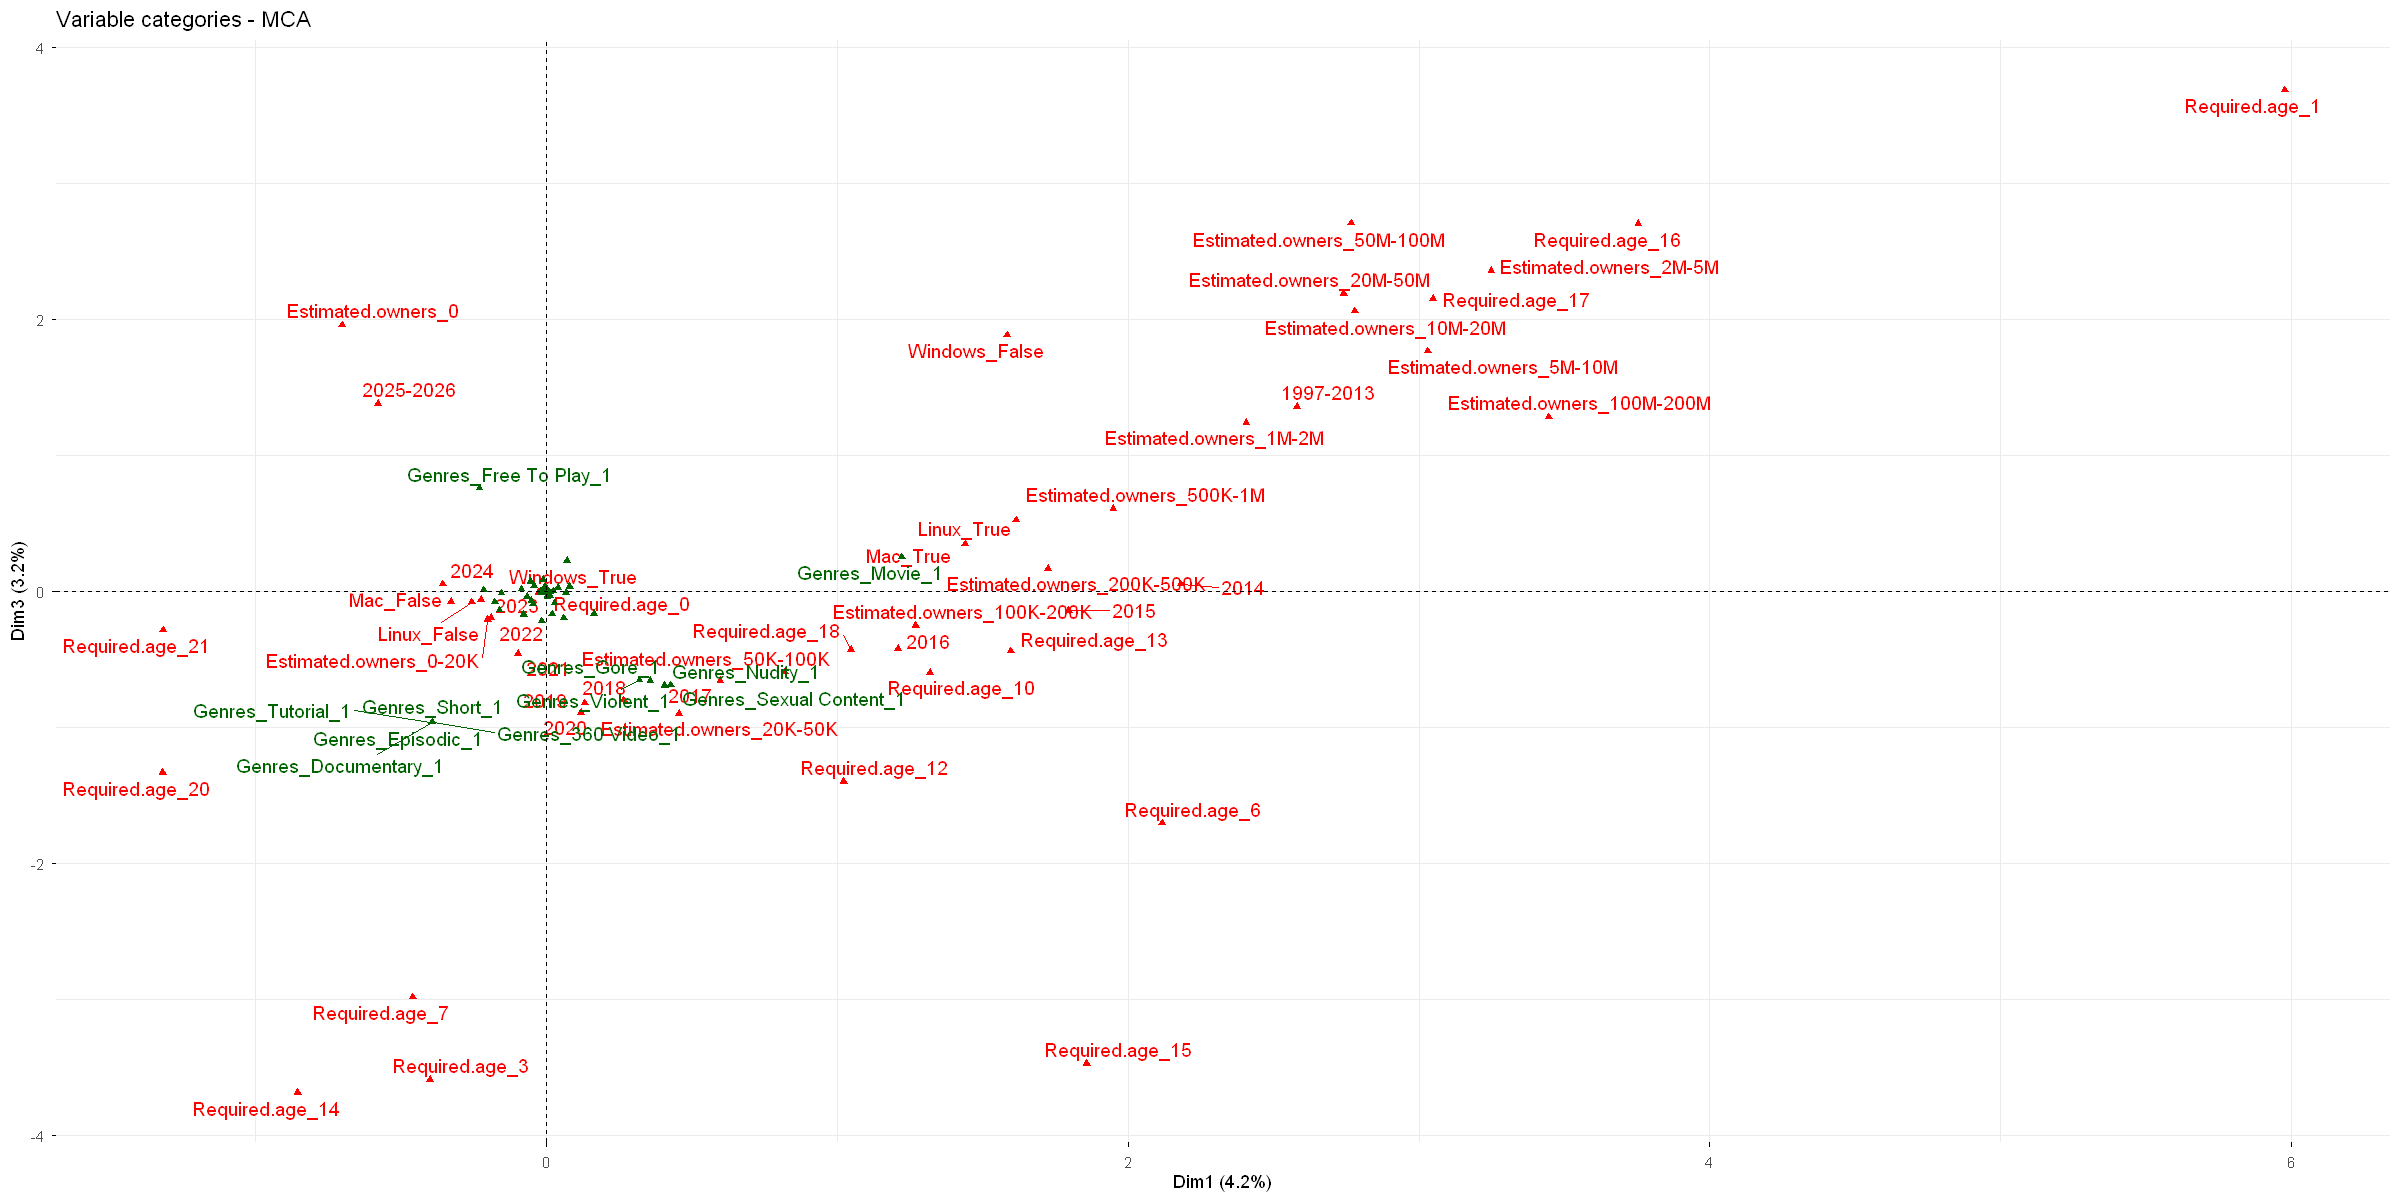

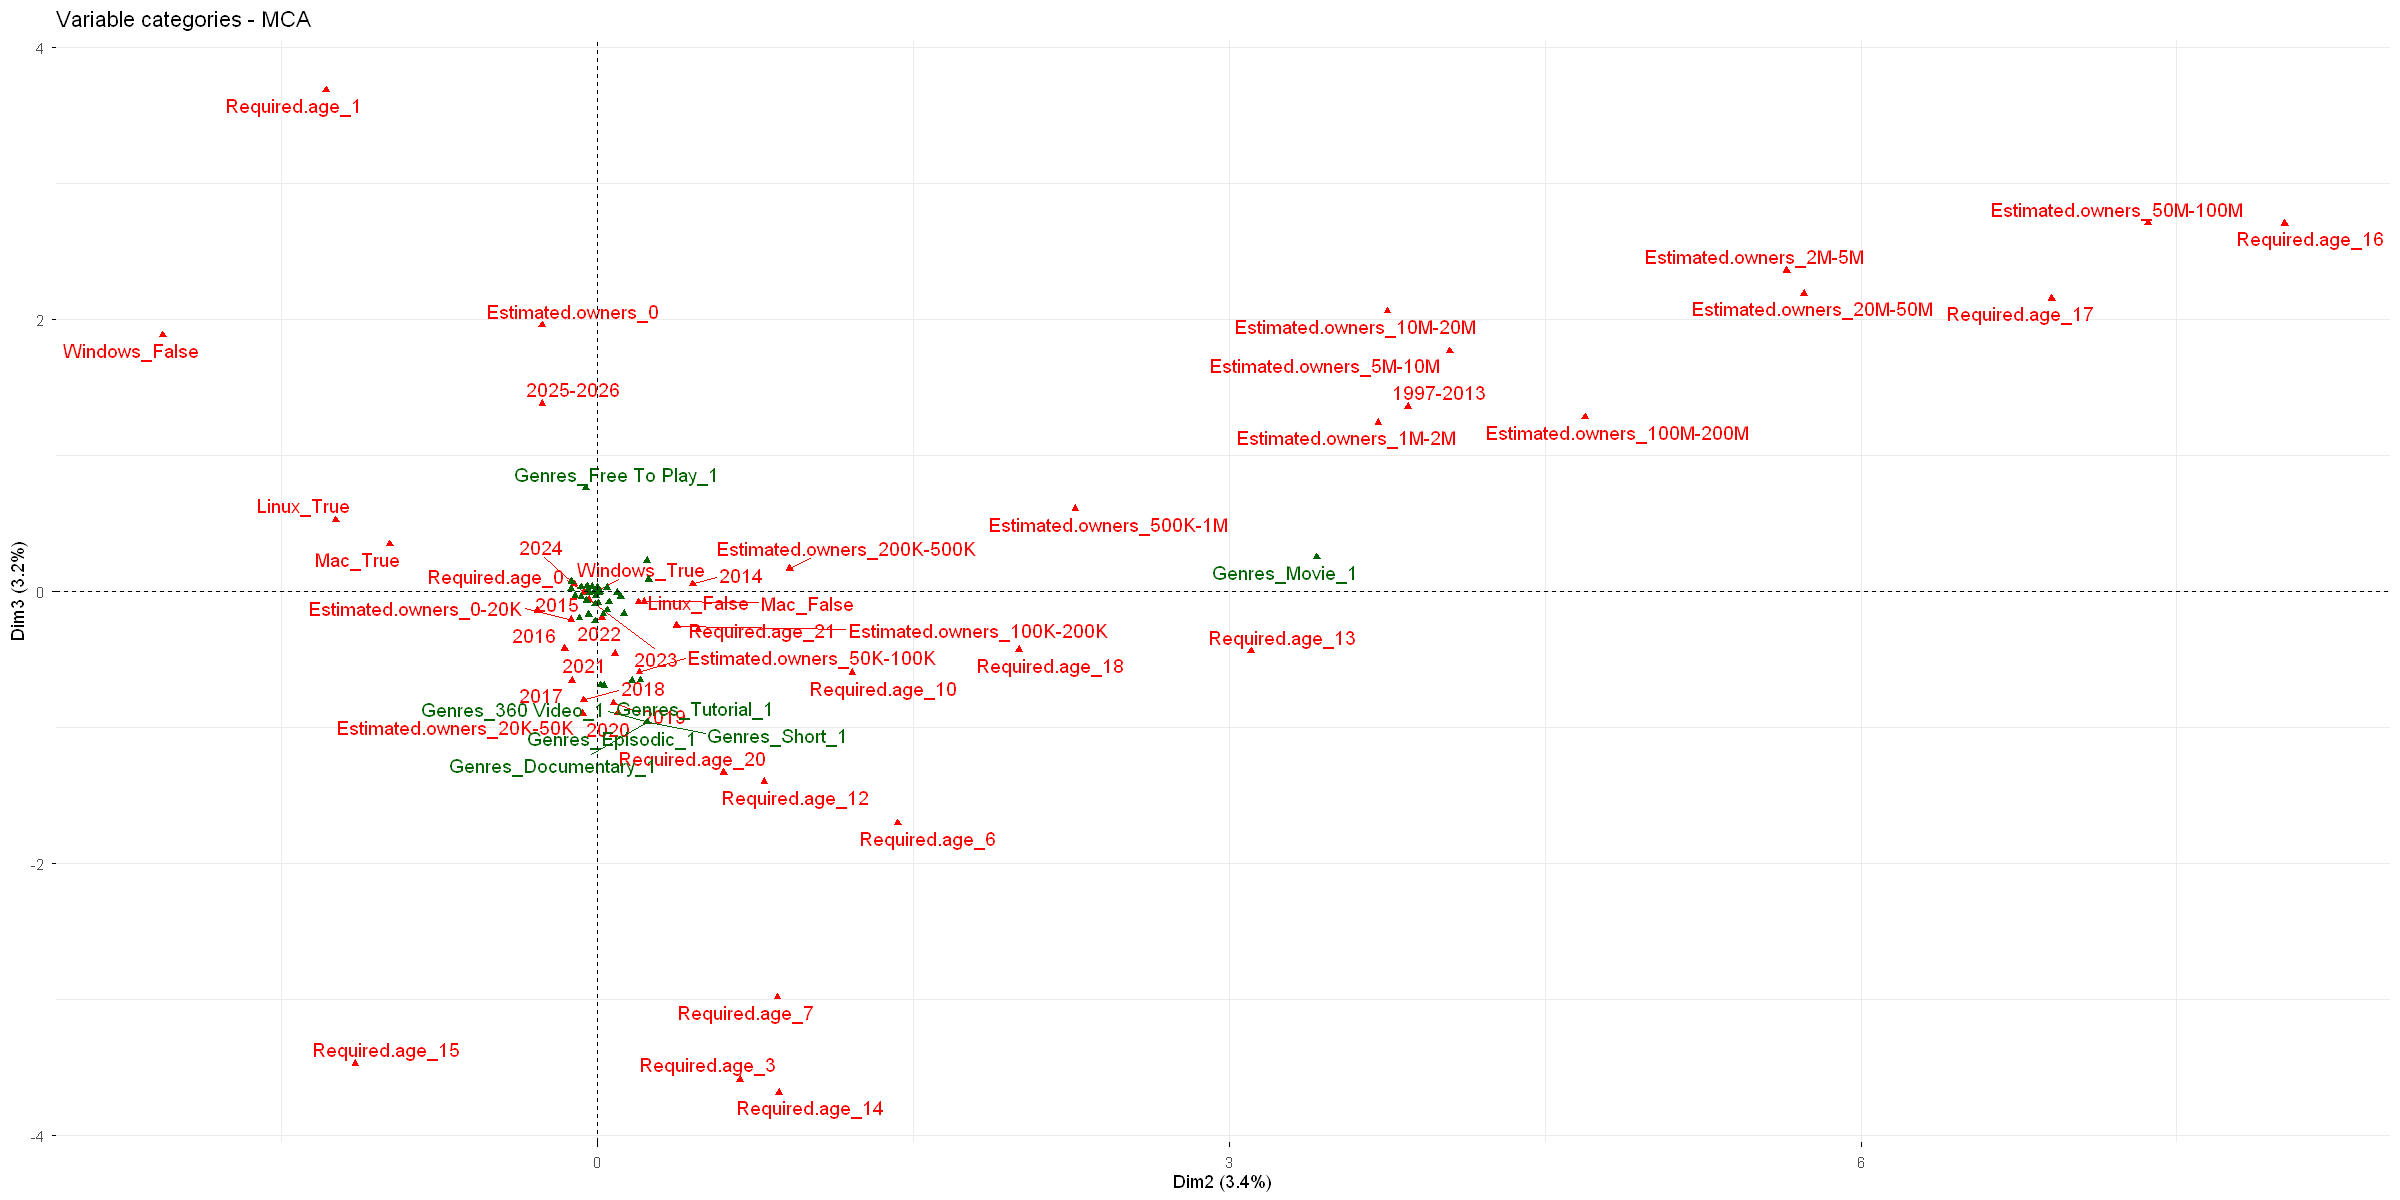

In [82]:
fviz_mca_var(res.mca_all, repel=TRUE)
fviz_mca_var(res.mca_all, repel=TRUE,axes = c(1,3))
fviz_mca_var(res.mca_all, repel=TRUE,axes = c(2,3))

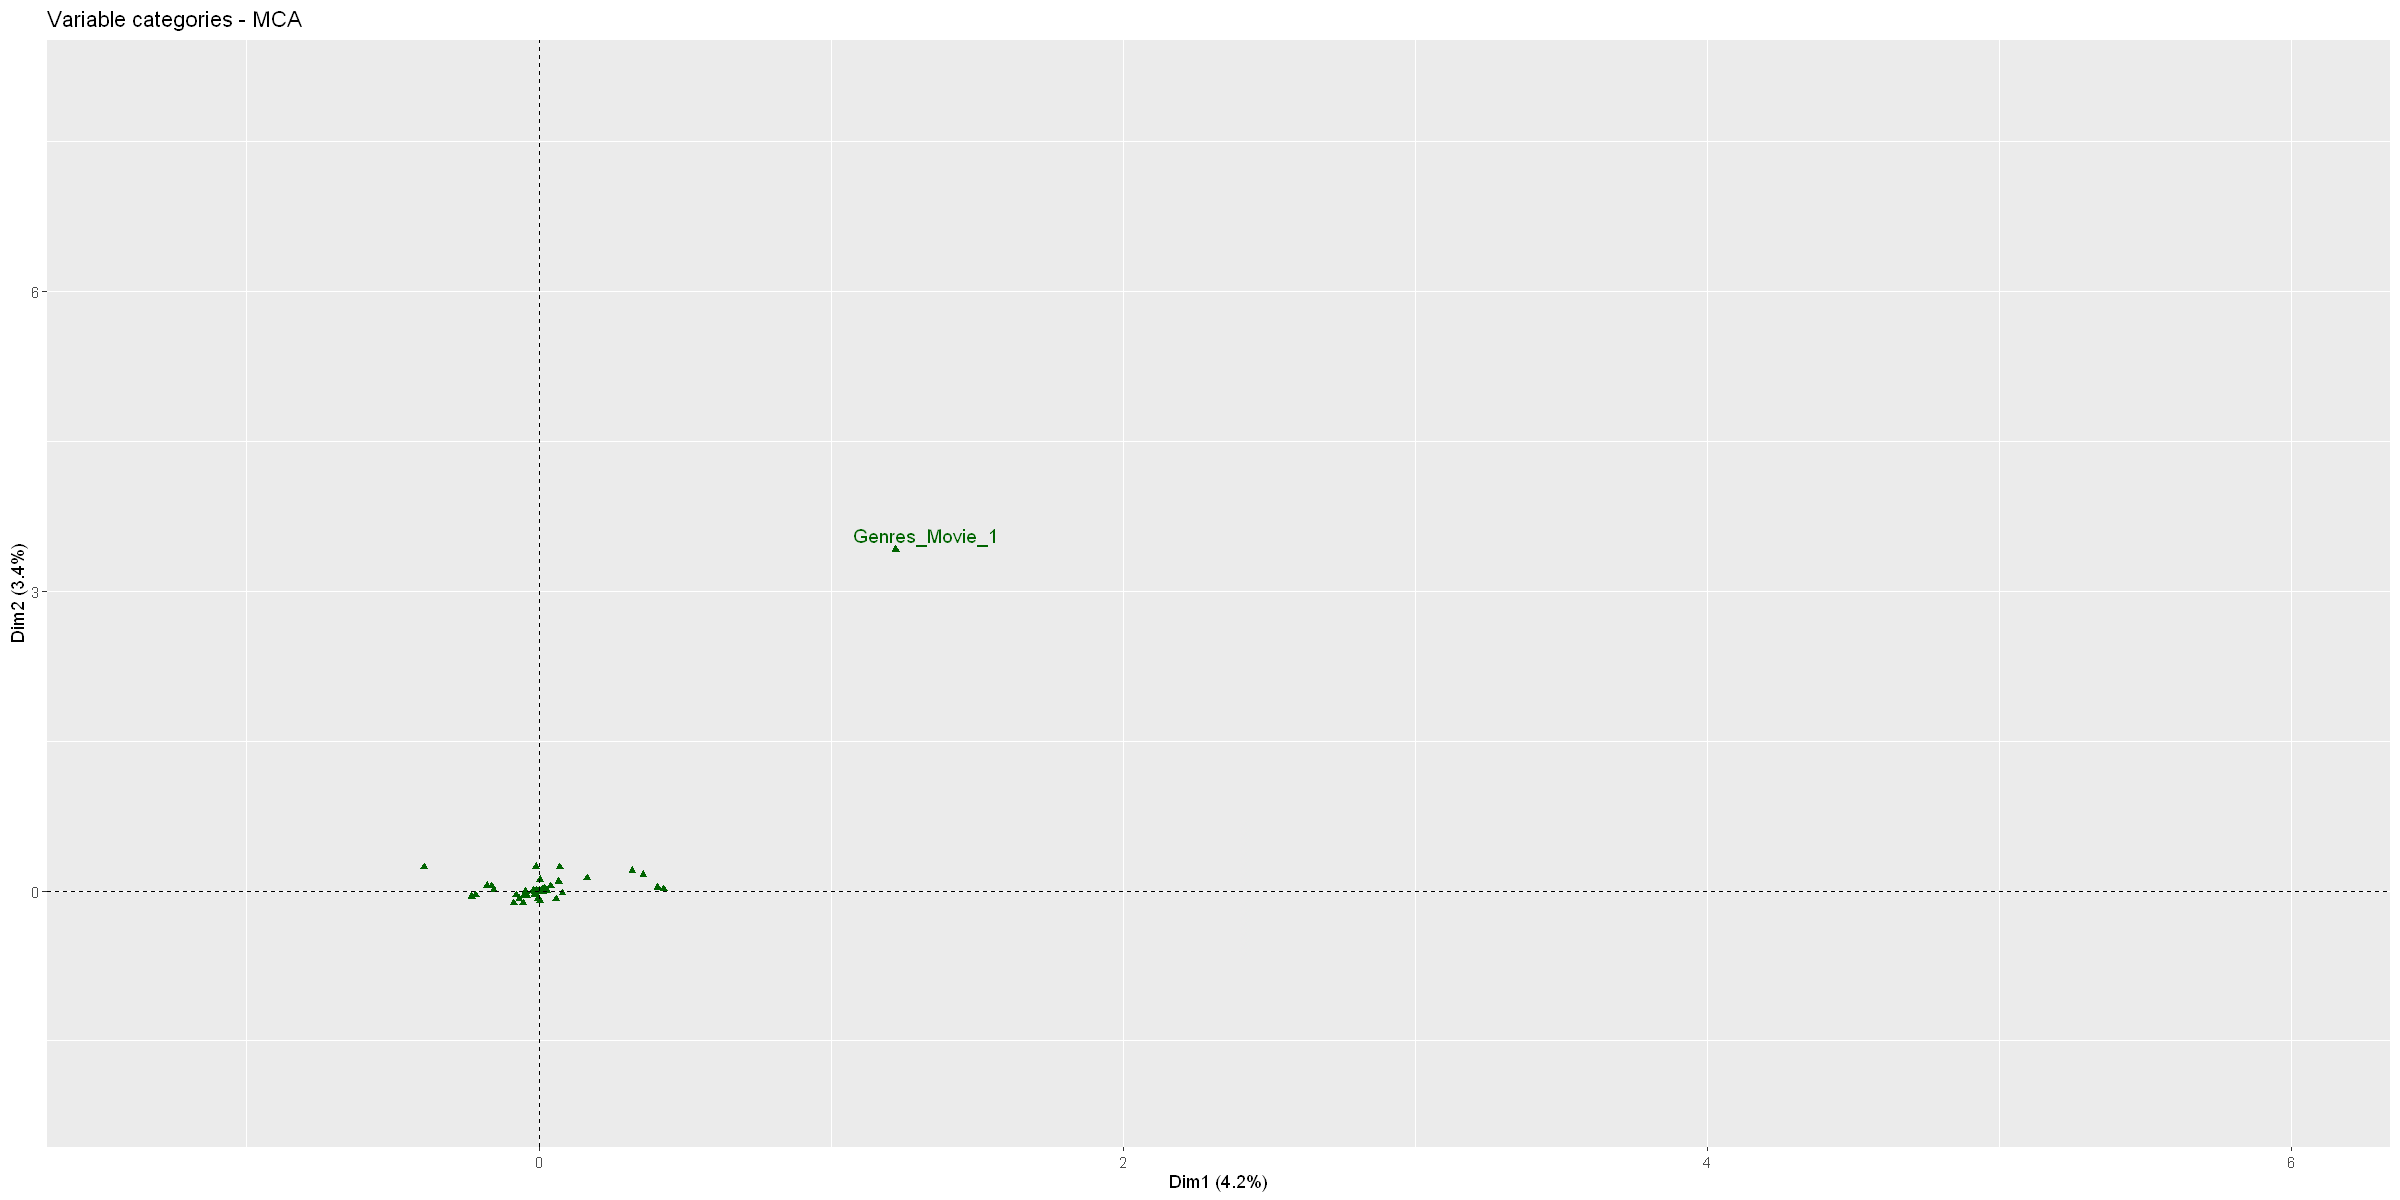

In [85]:
fviz_mca_var(res.mca_all, 
             invisible = "var",        # On cache les variables actives
             col.var = "indianred",    # Couleur pour tes variables supplémentaires
             repel = TRUE)

## quality of representation

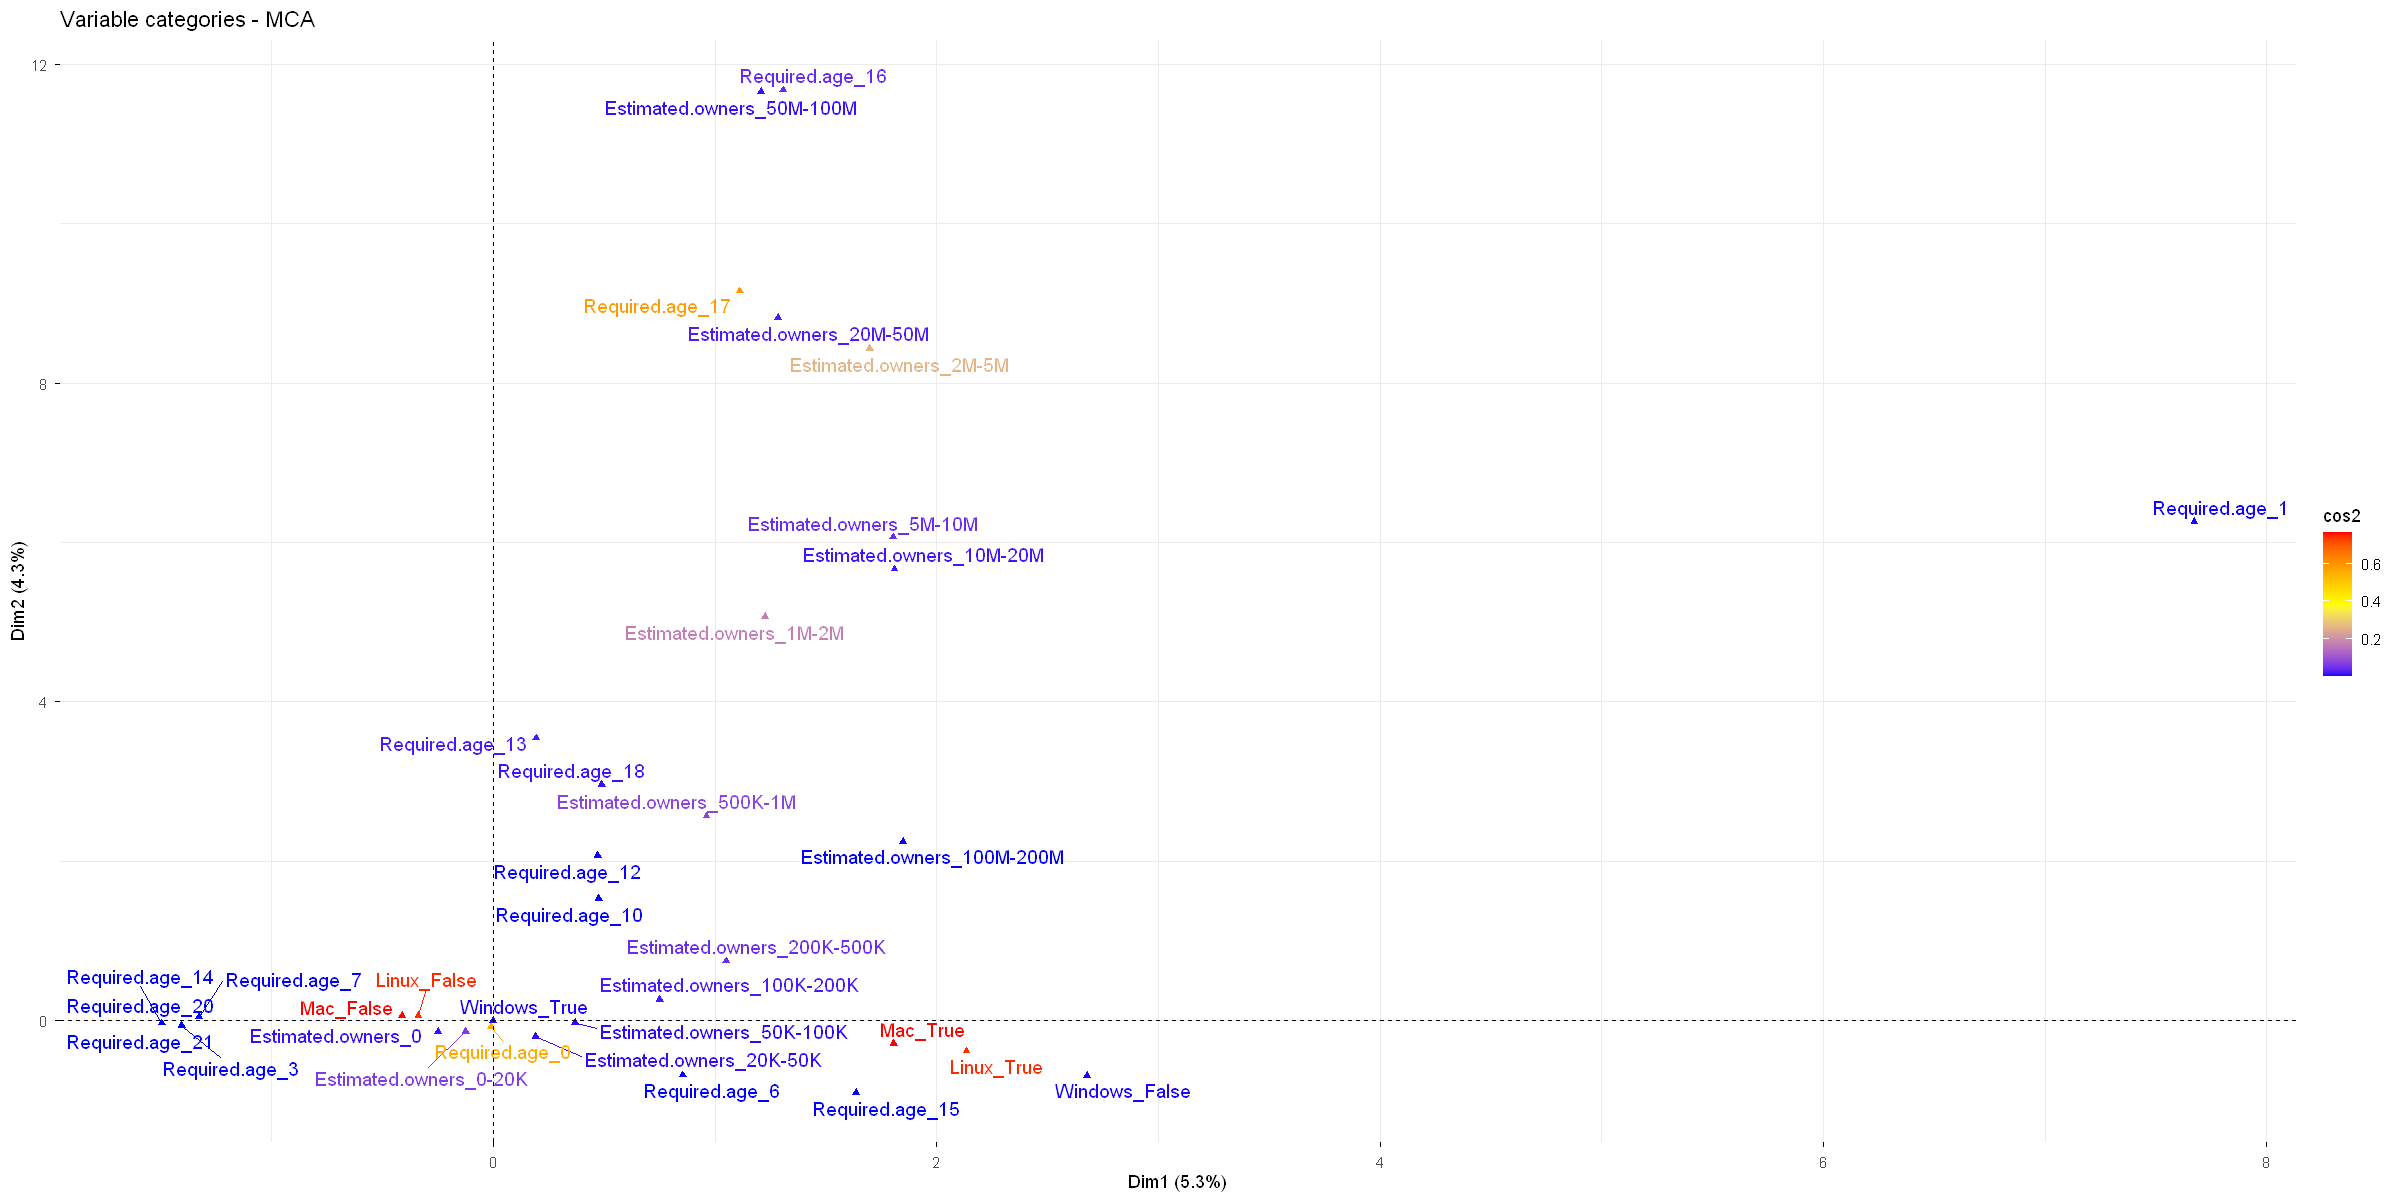

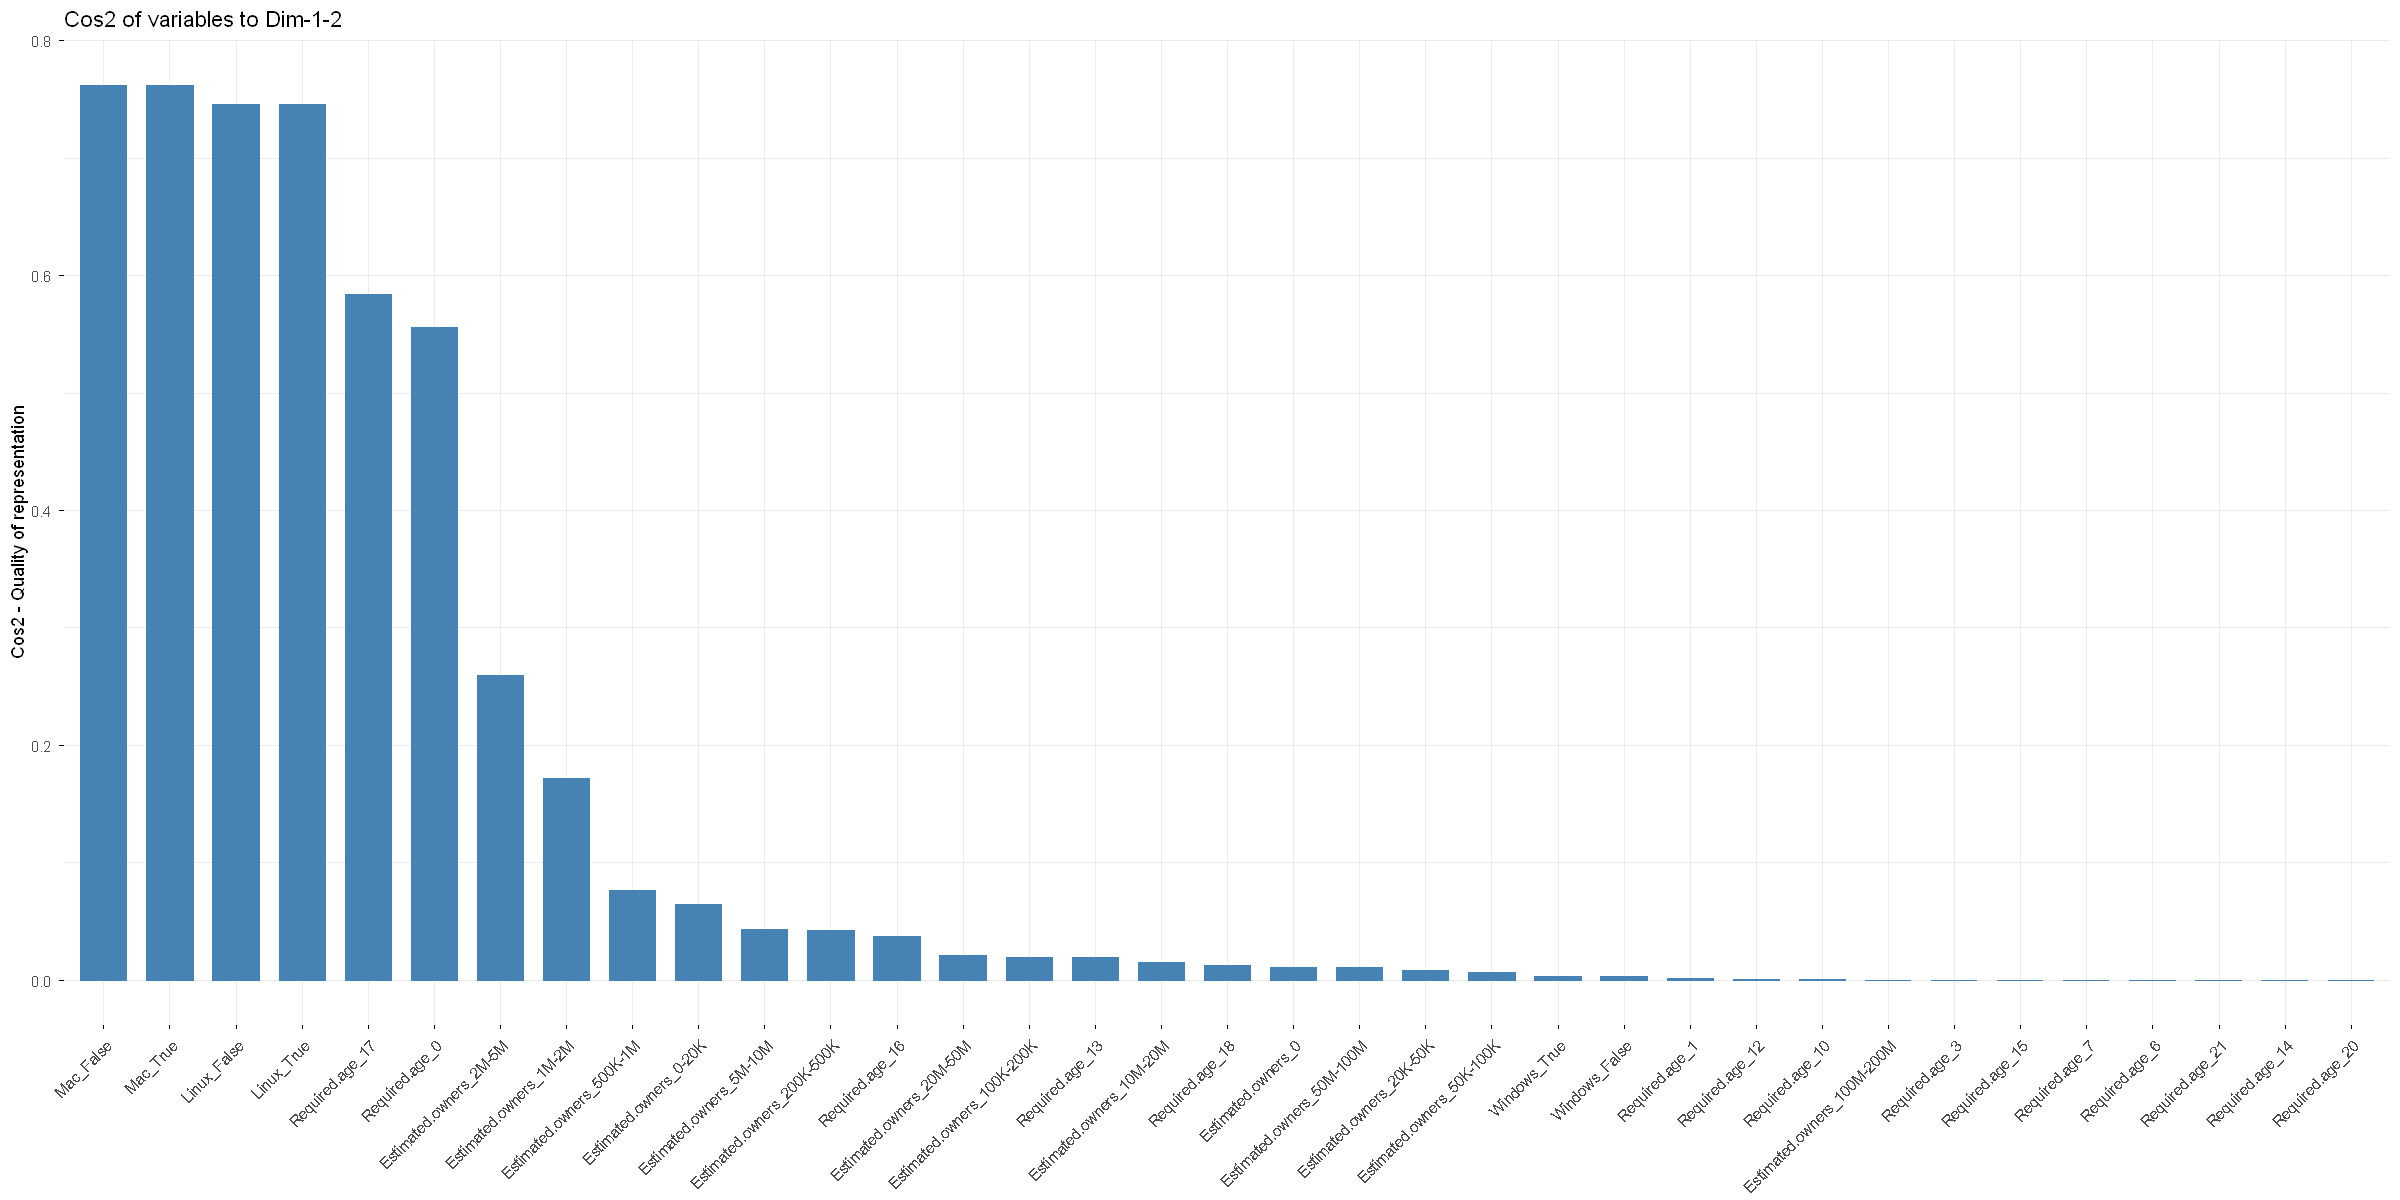

In [55]:
# Color by cos2 values: quality on the factor map
fviz_mca_var(res.mca, col.var = "cos2",
             gradient.cols = c("blue", "yellow", "red"), 
             repel = TRUE )


# Cos2 of variable categories on Dim.1 and Dim.2
fviz_cos2(res.mca, choice = "var", axes = 1:2)


## Contribution

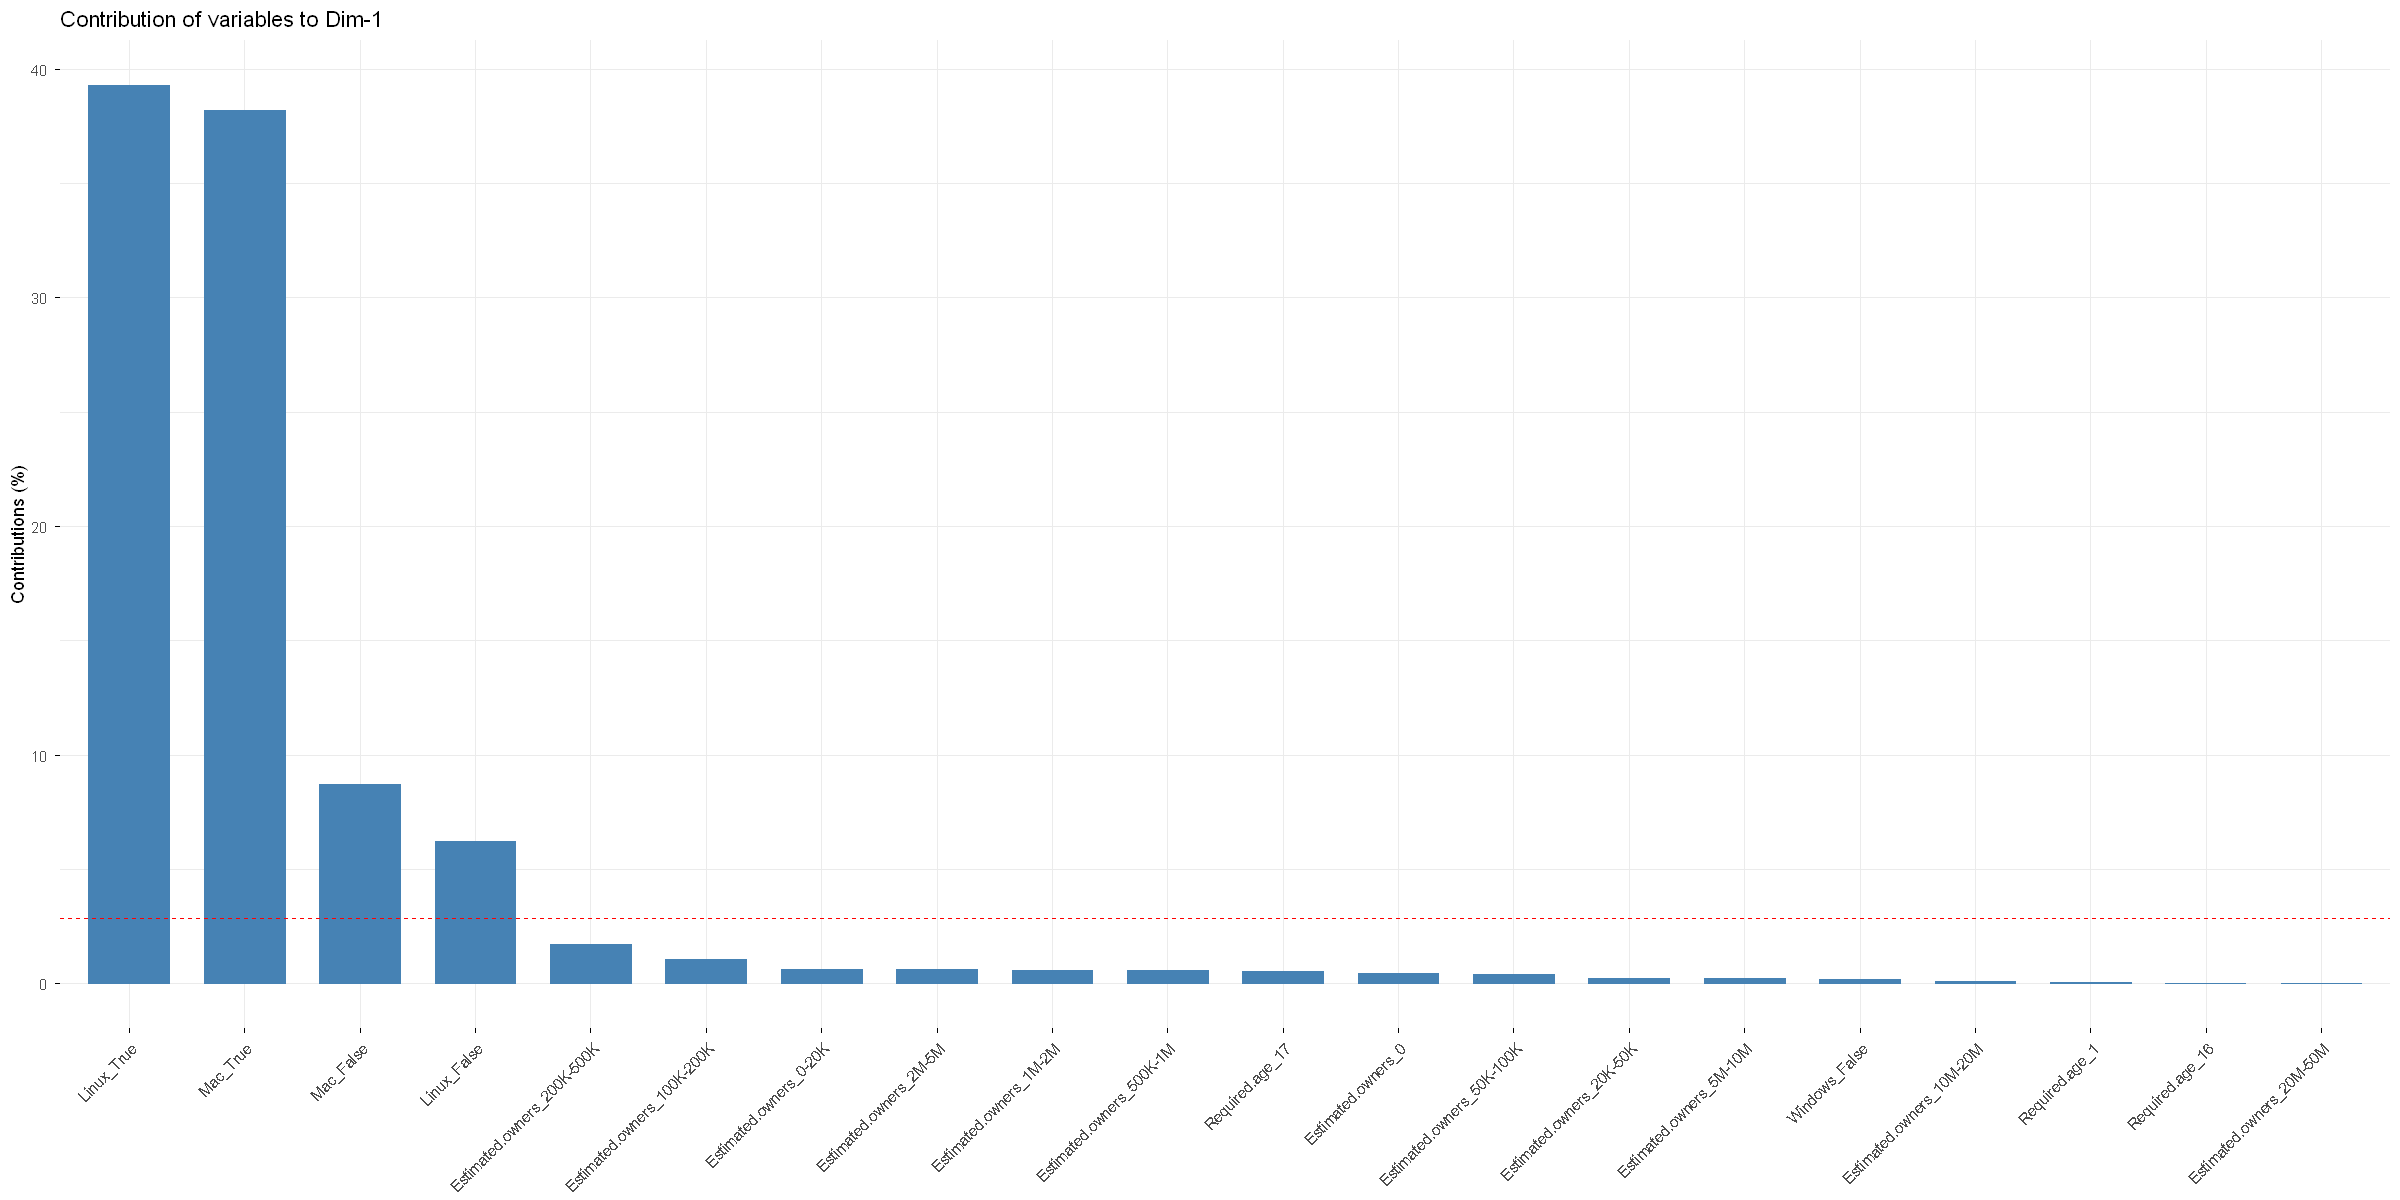

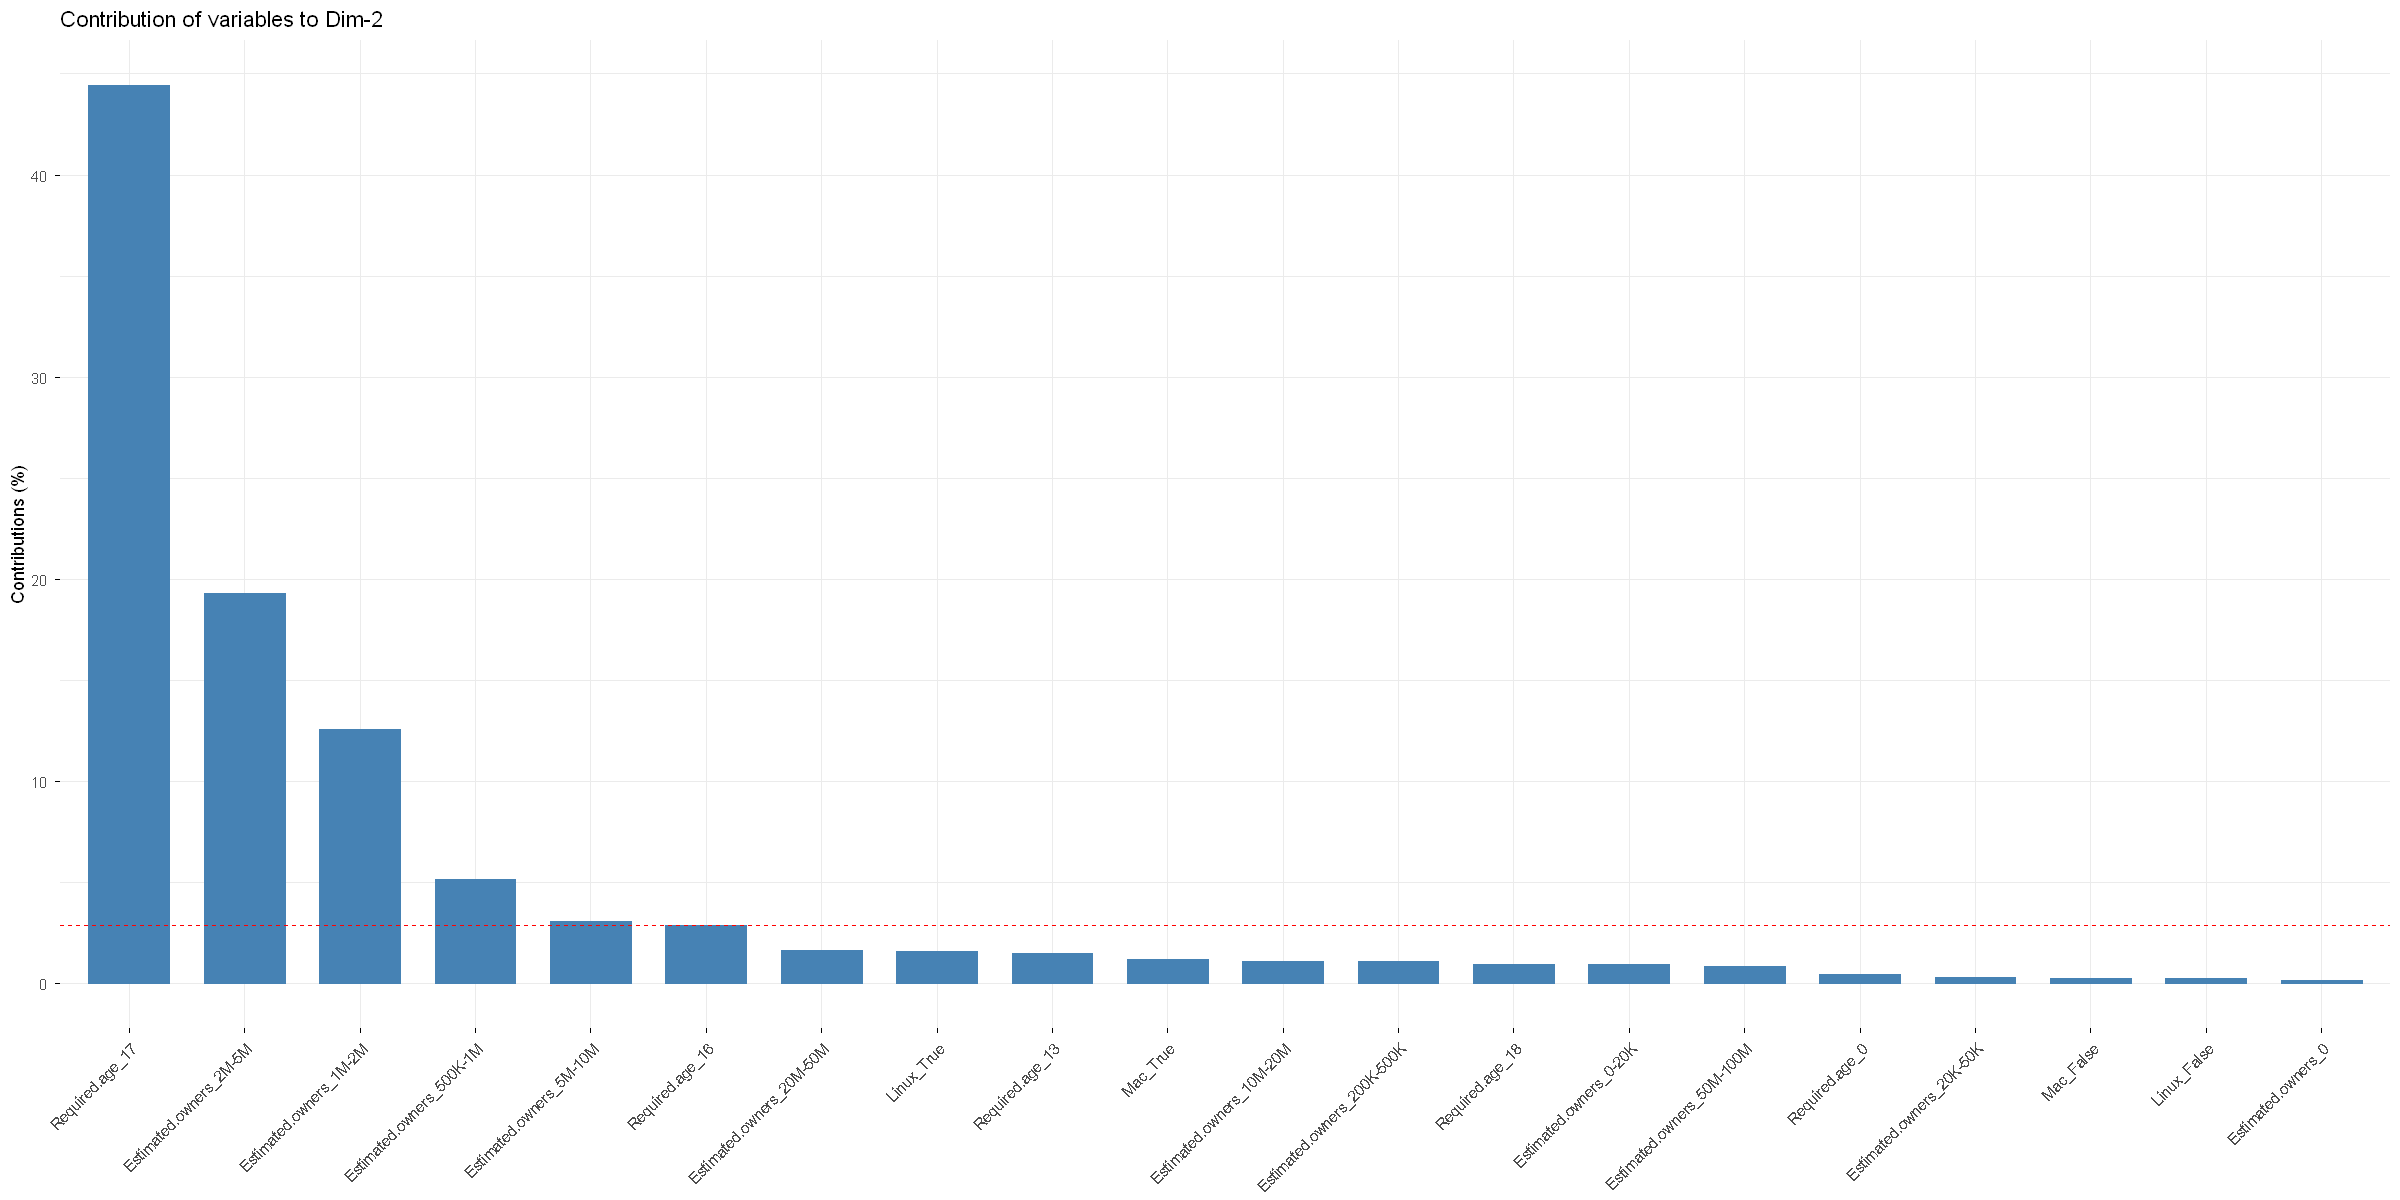

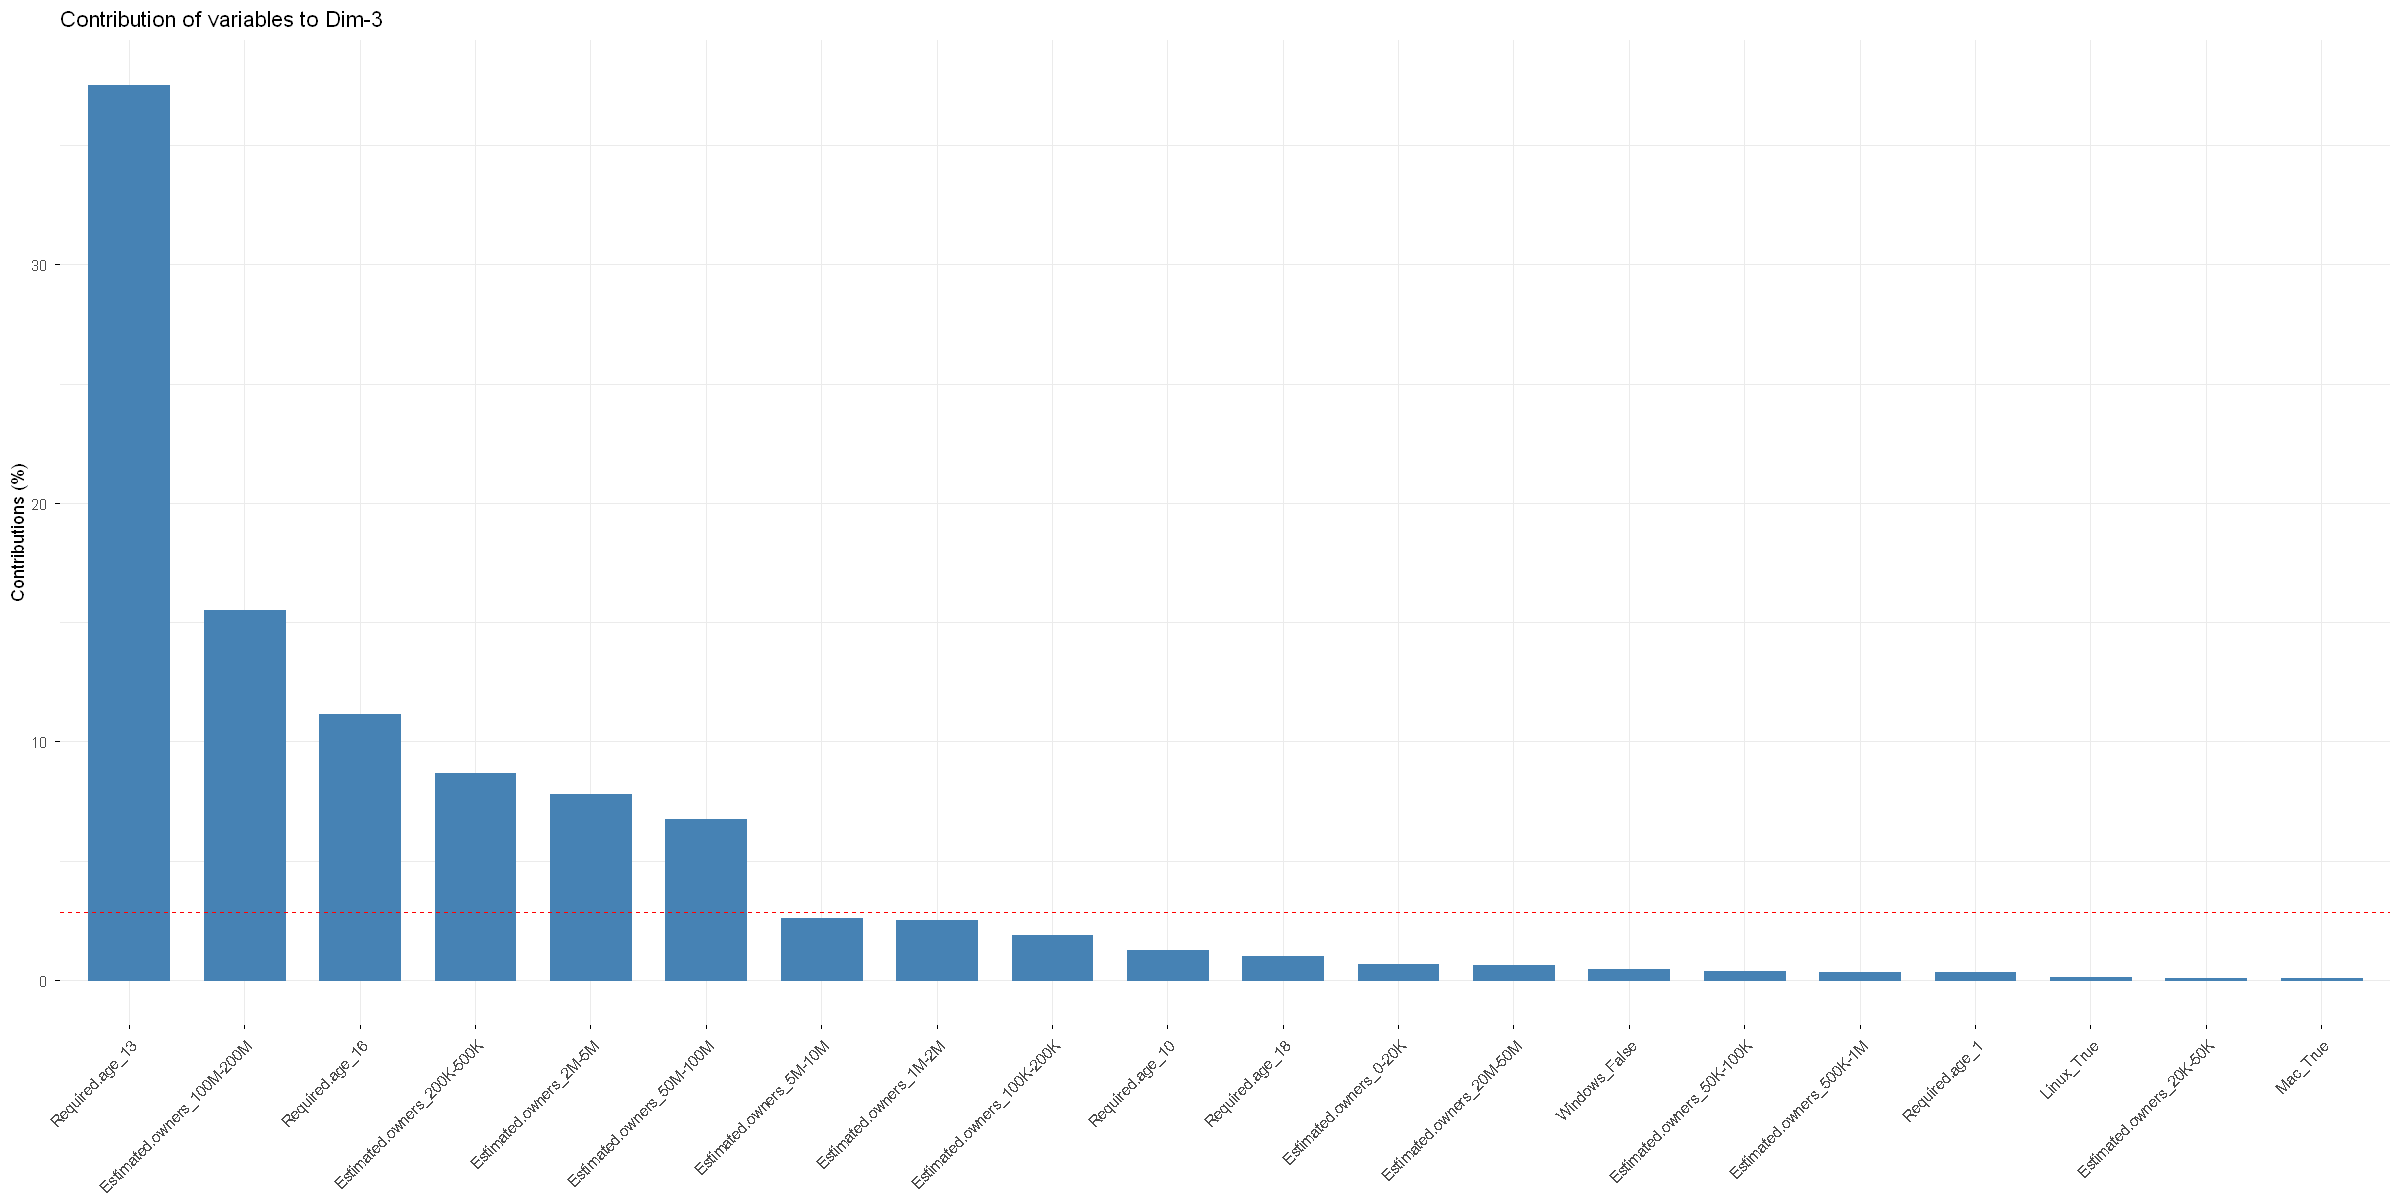

In [60]:
# Contributions of hobbies to dimension 1
fviz_contrib(res.mca, choice="var", axes=1, top=20)

# Contributions of hobbies to dimension 2
fviz_contrib(res.mca, choice="var", axes=2, top=20)
fviz_contrib(res.mca, choice="var", axes=3, top=20)


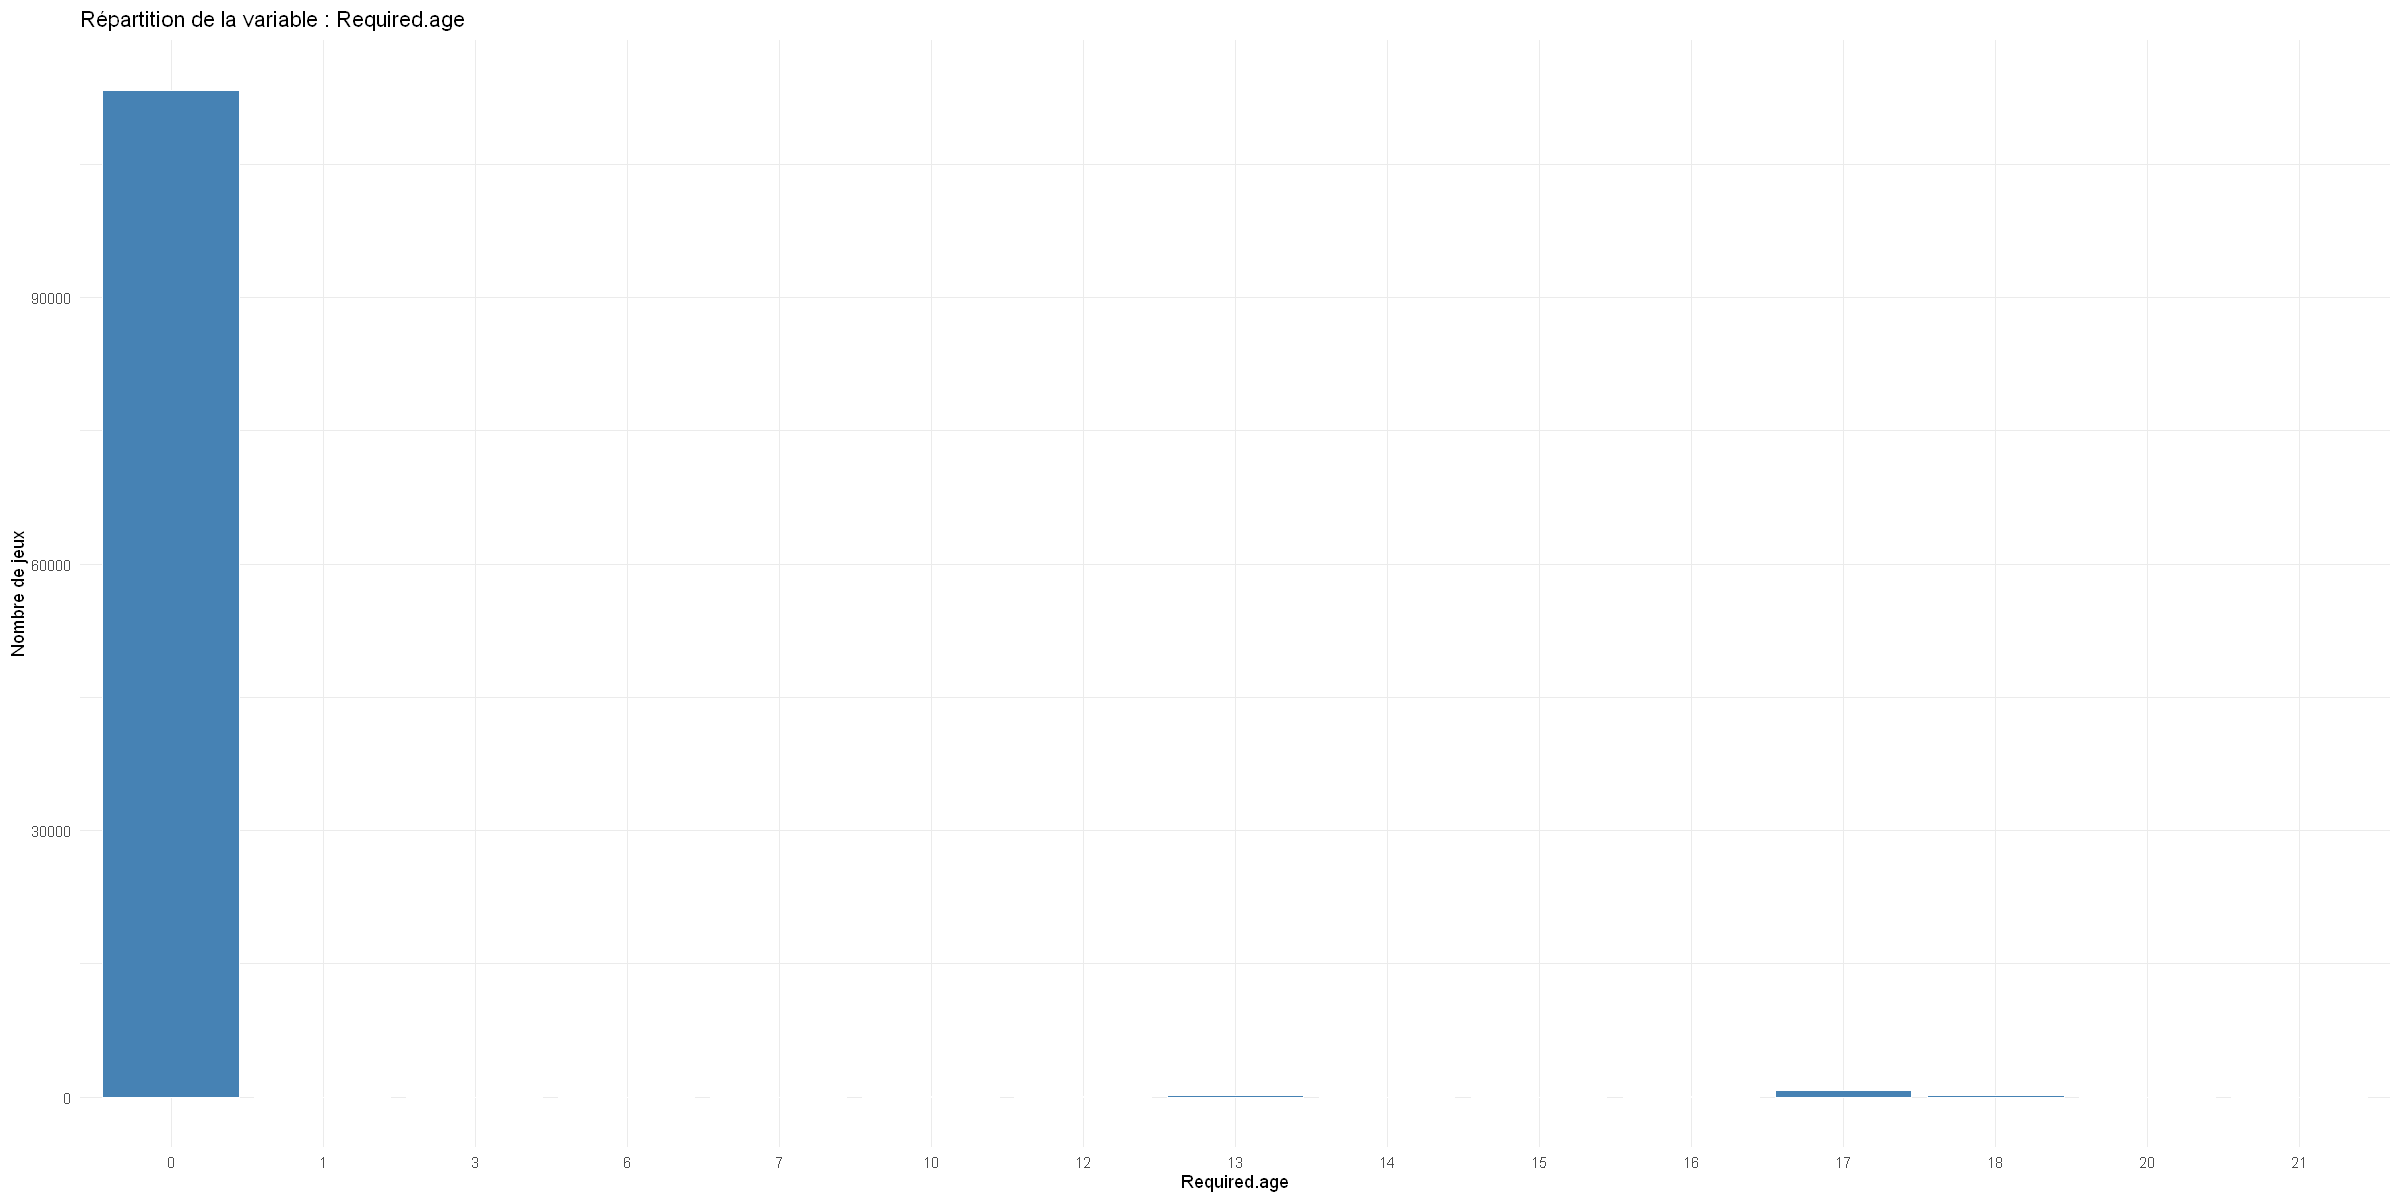

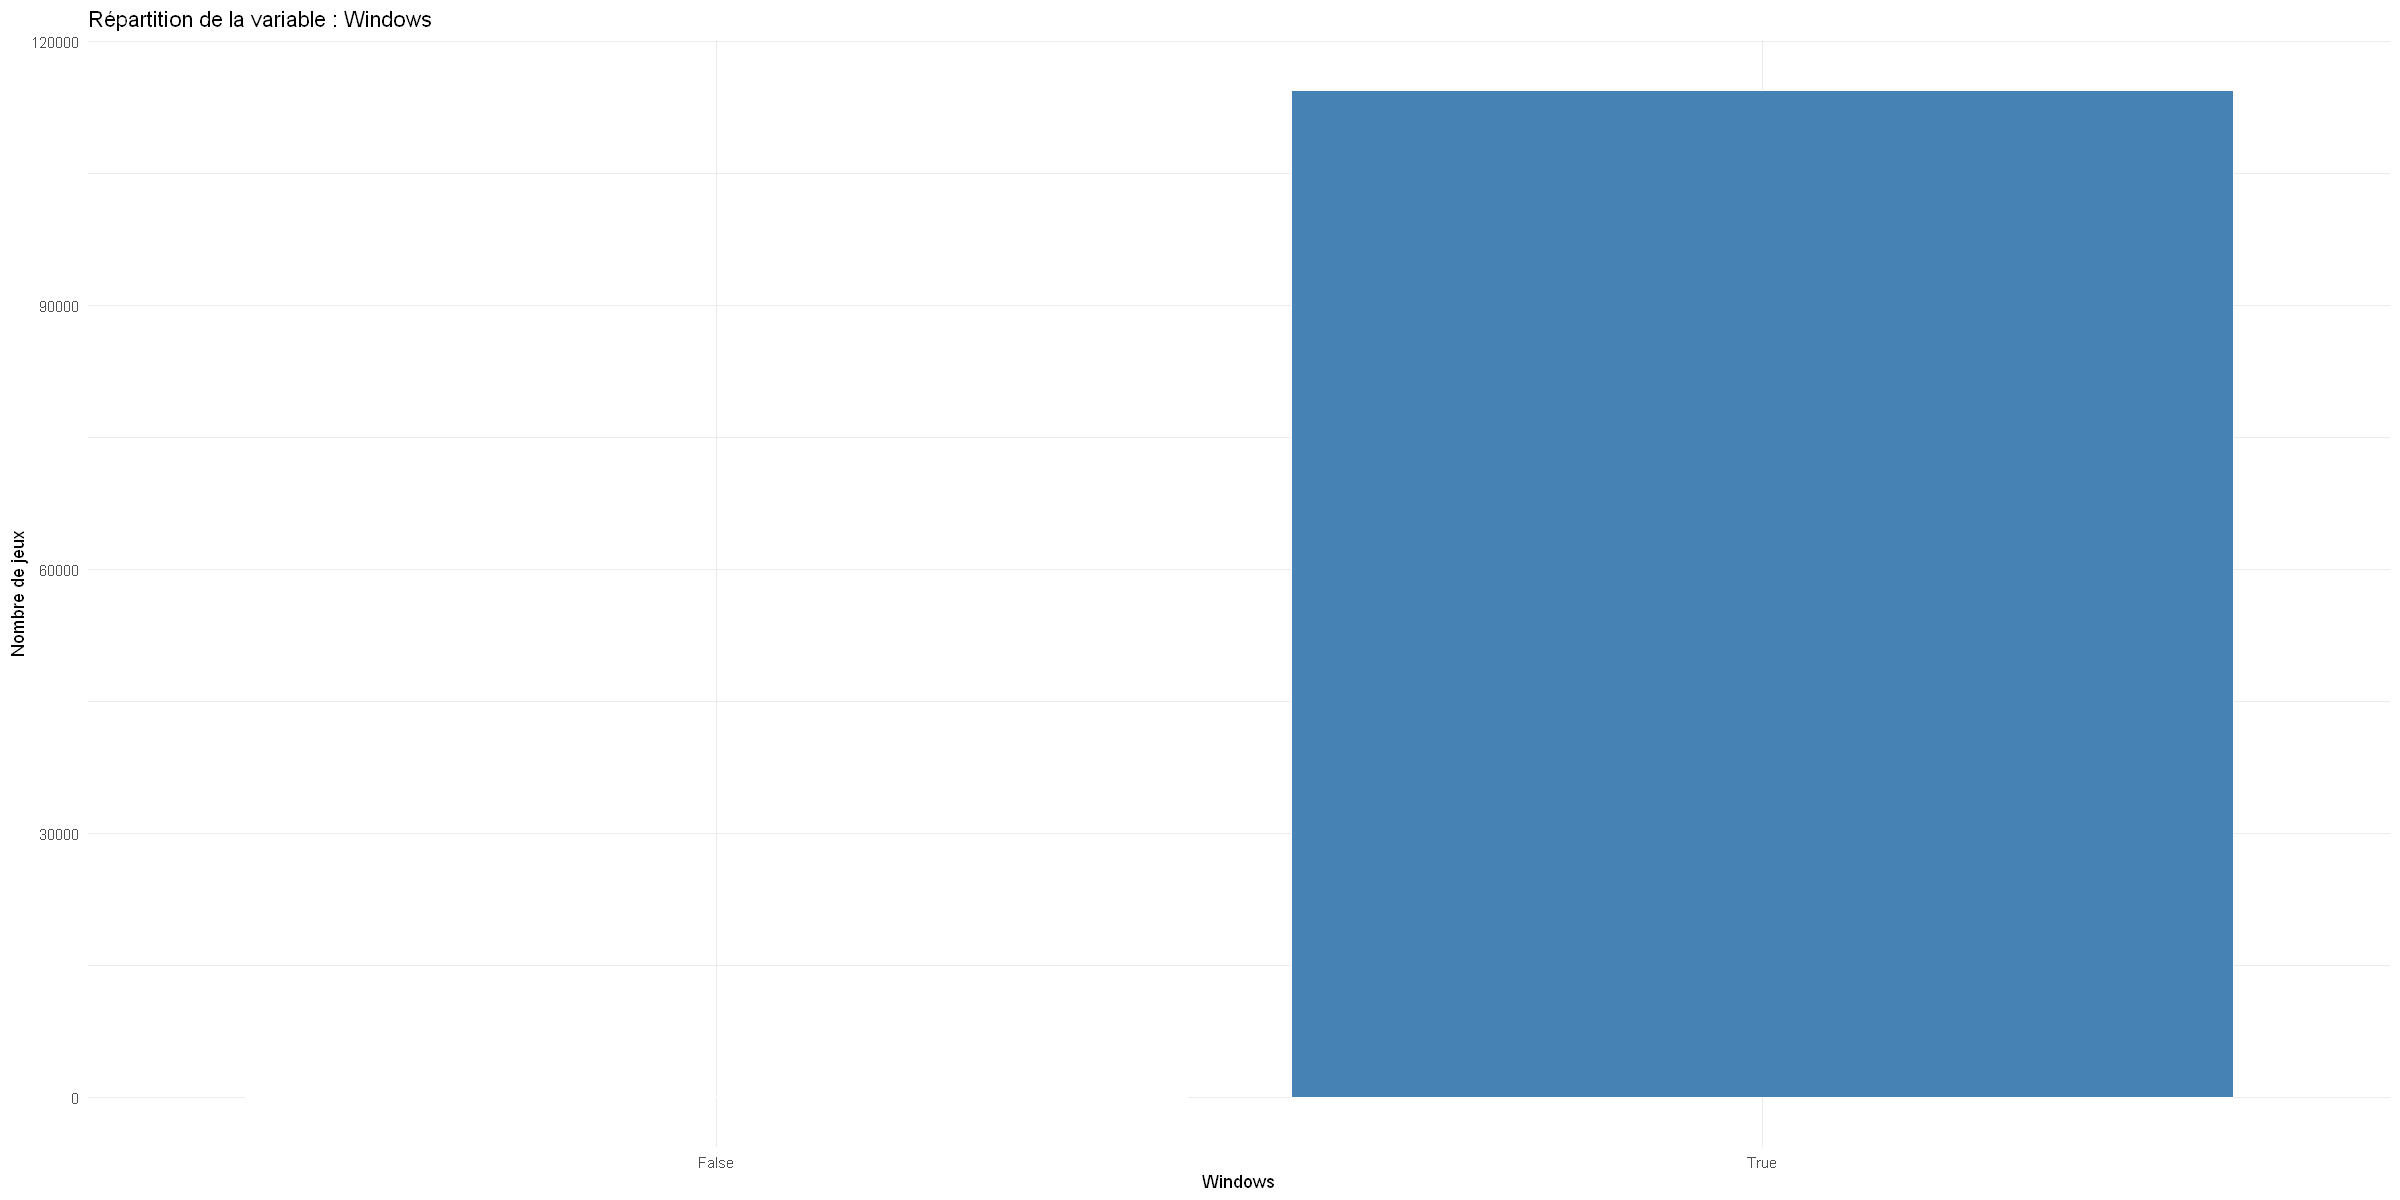

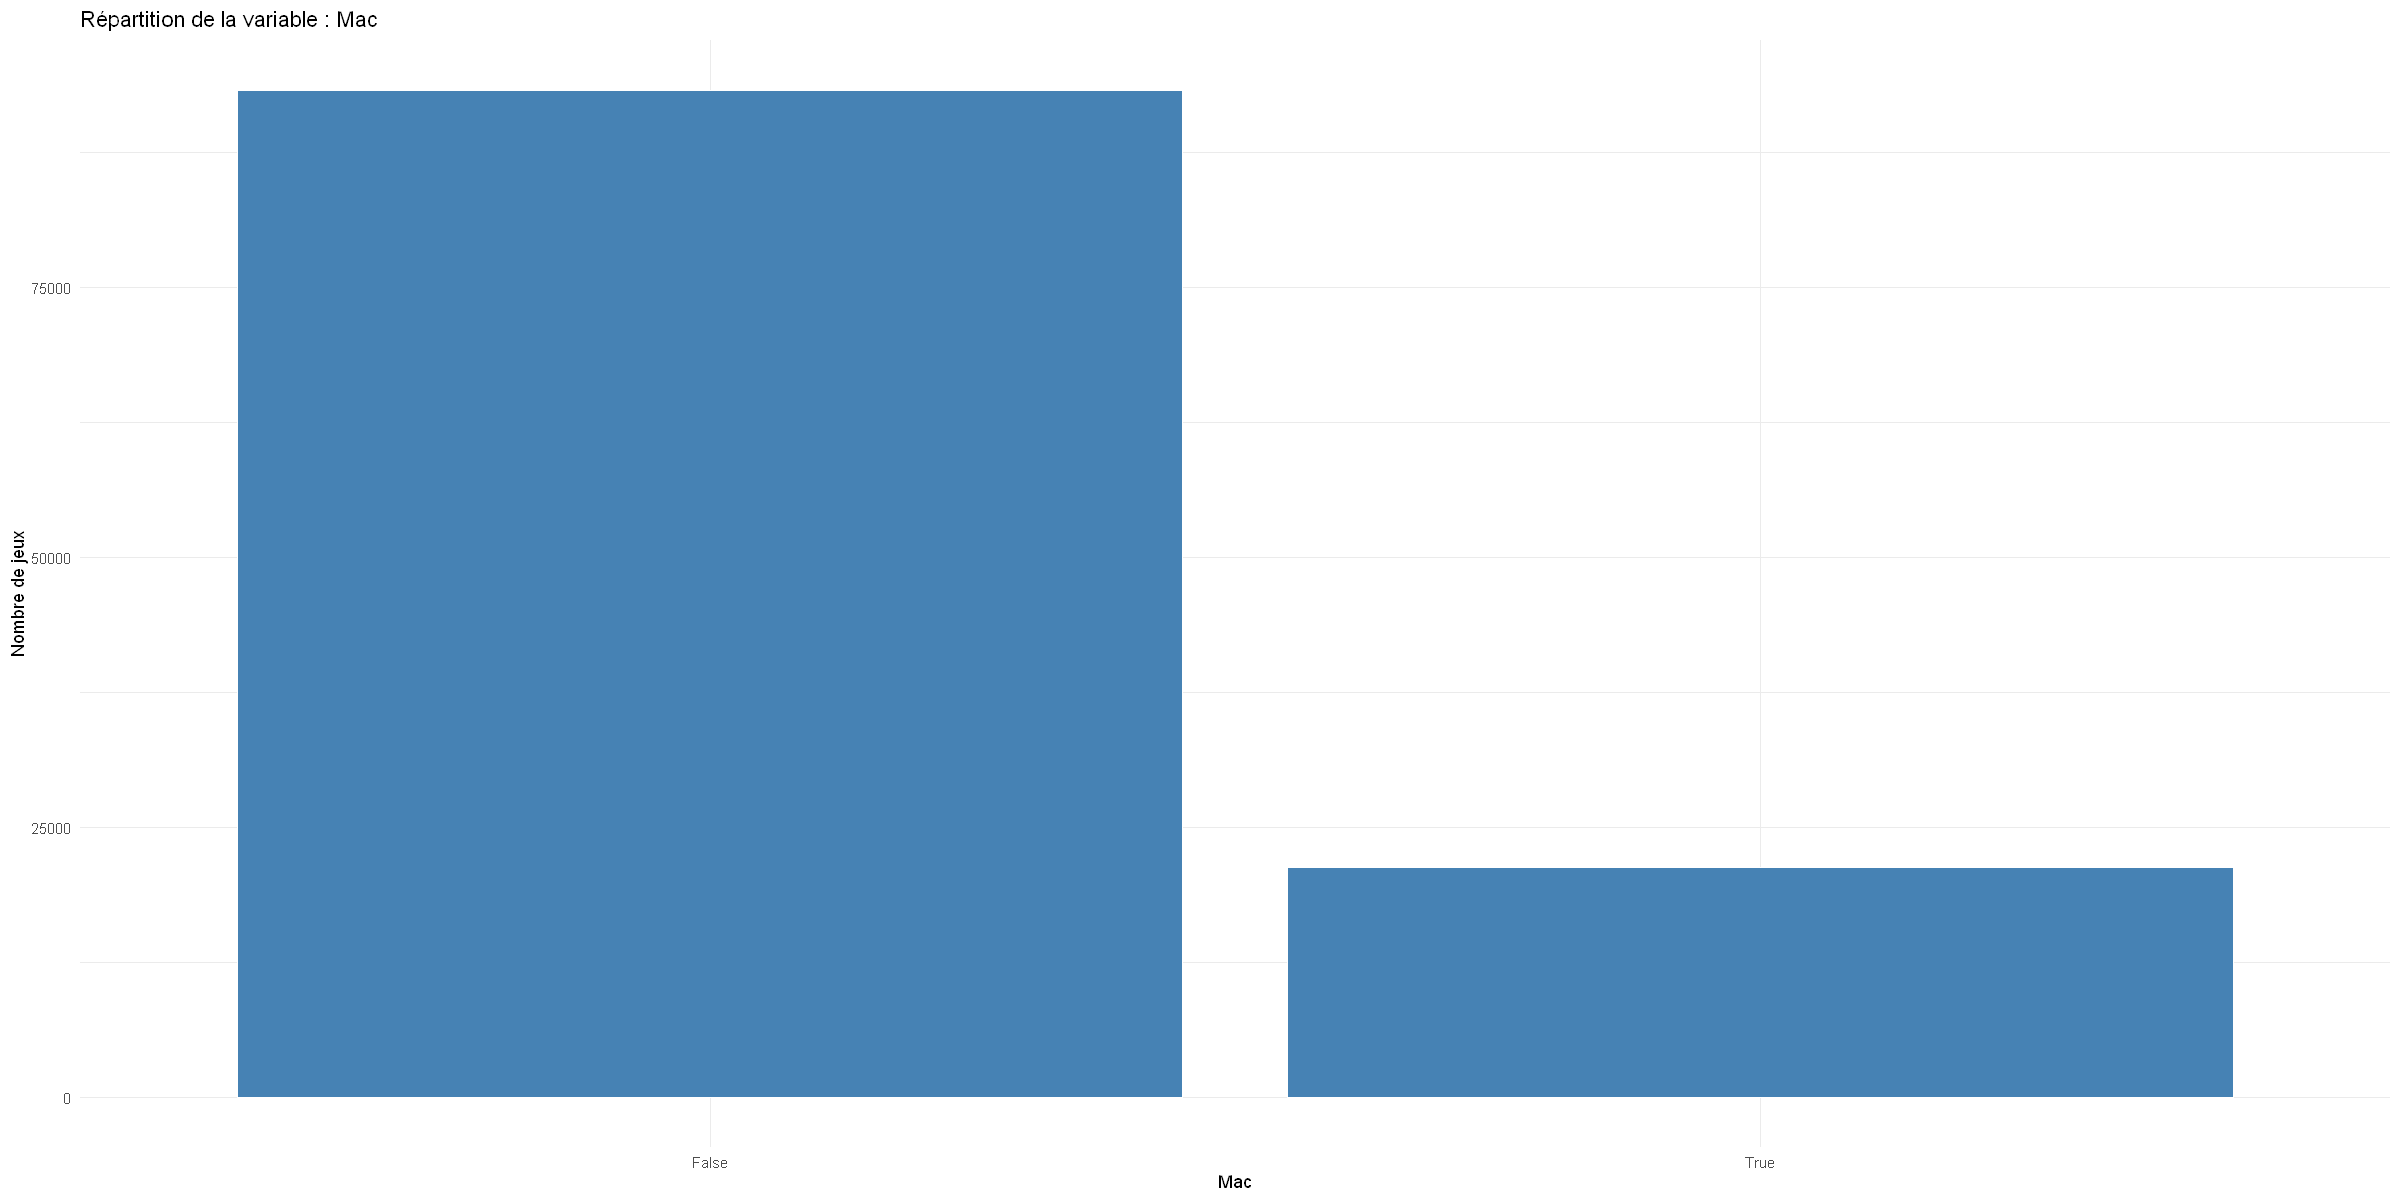

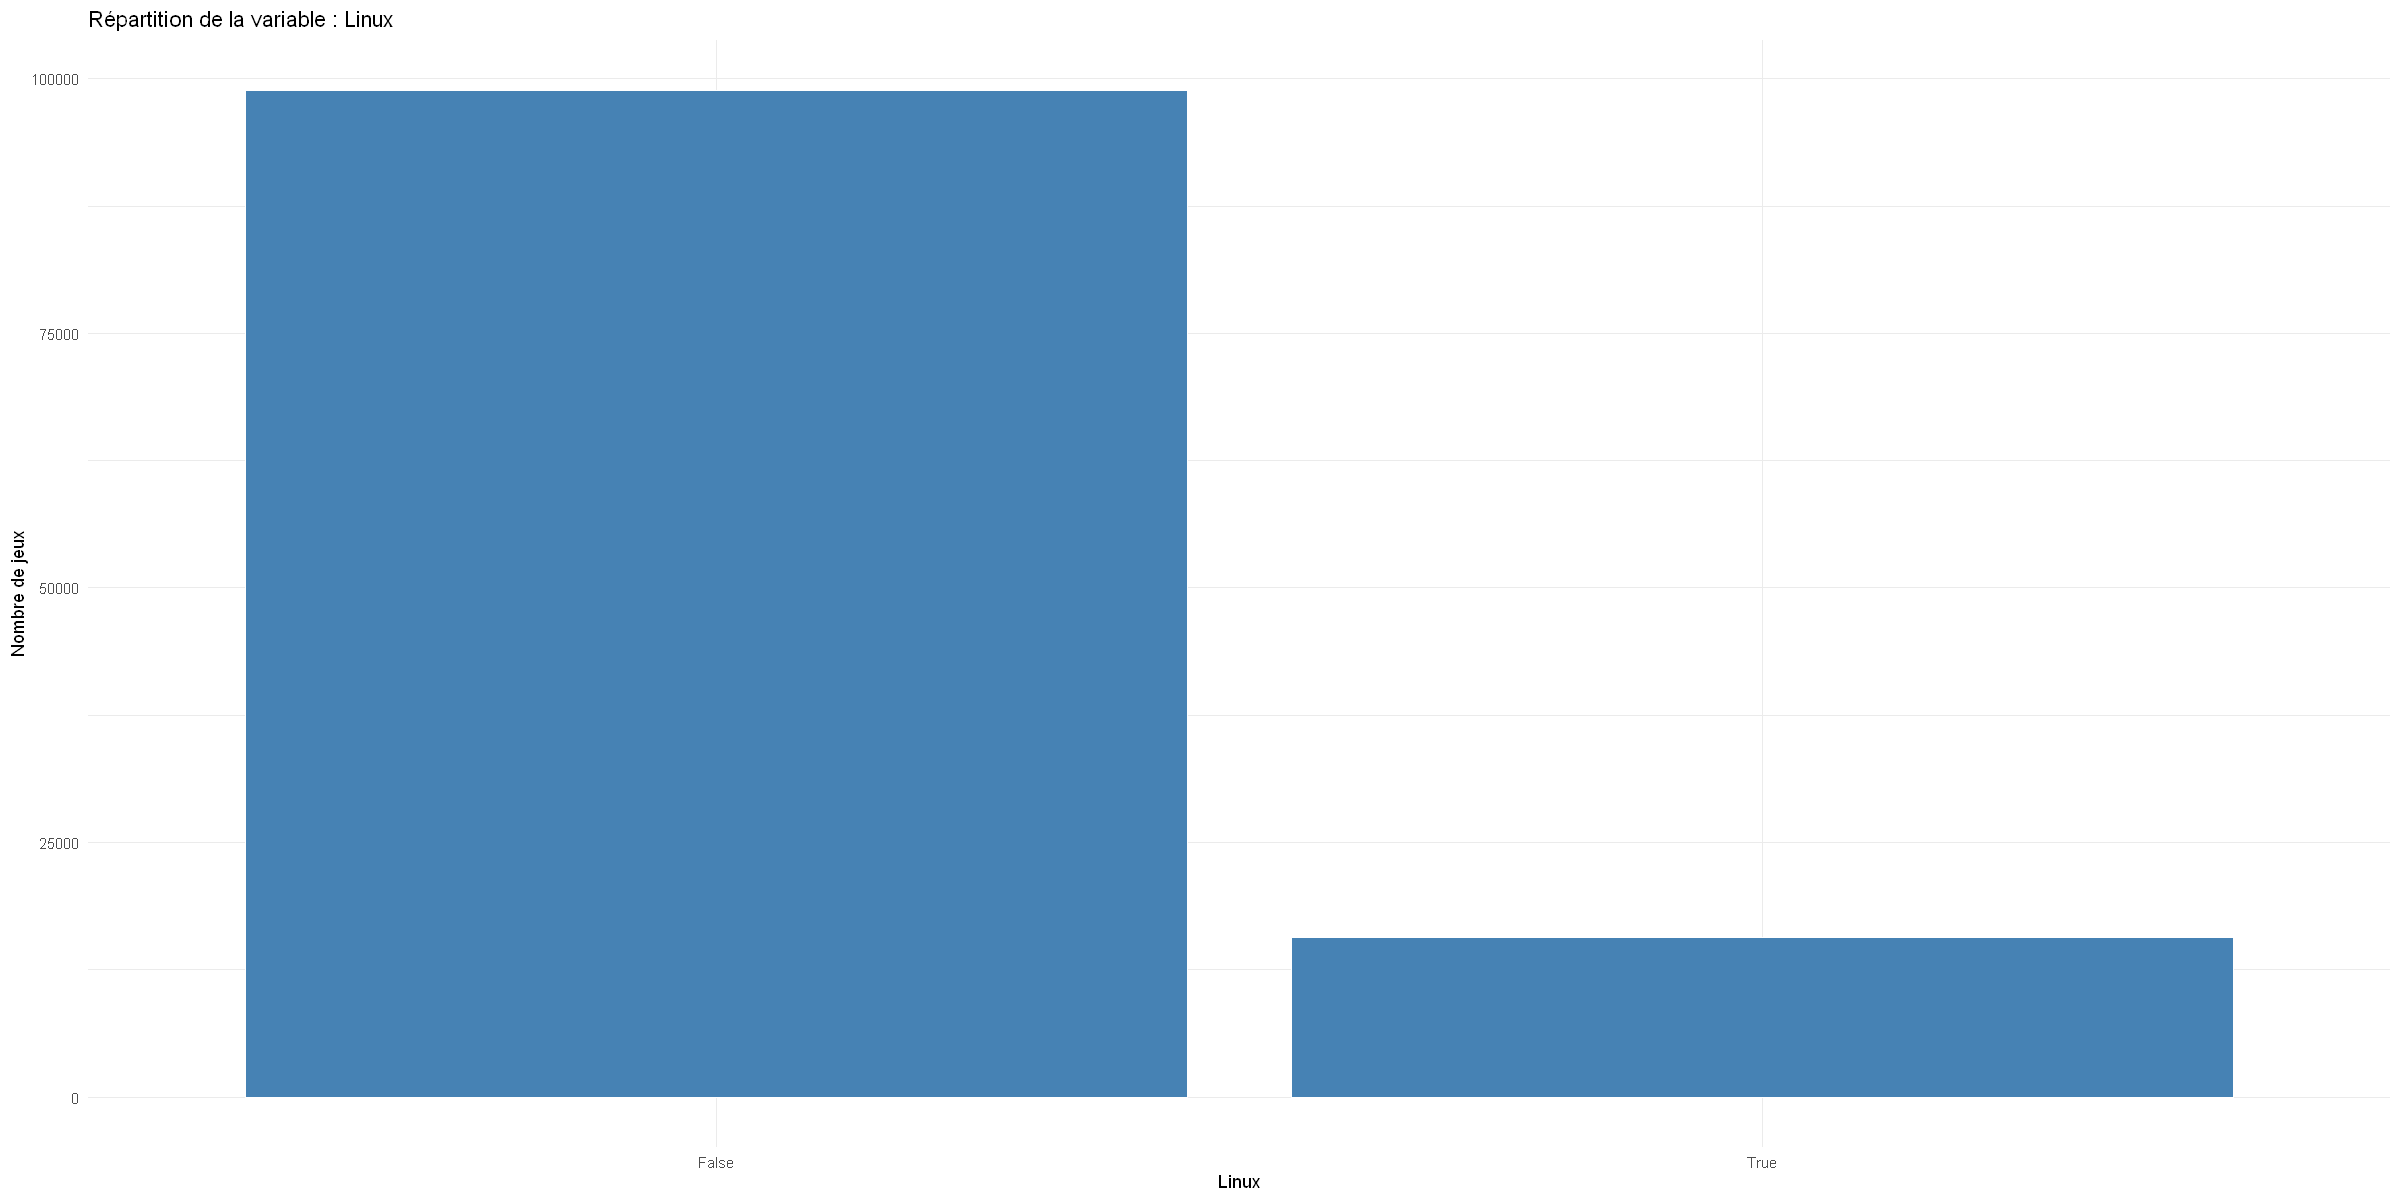

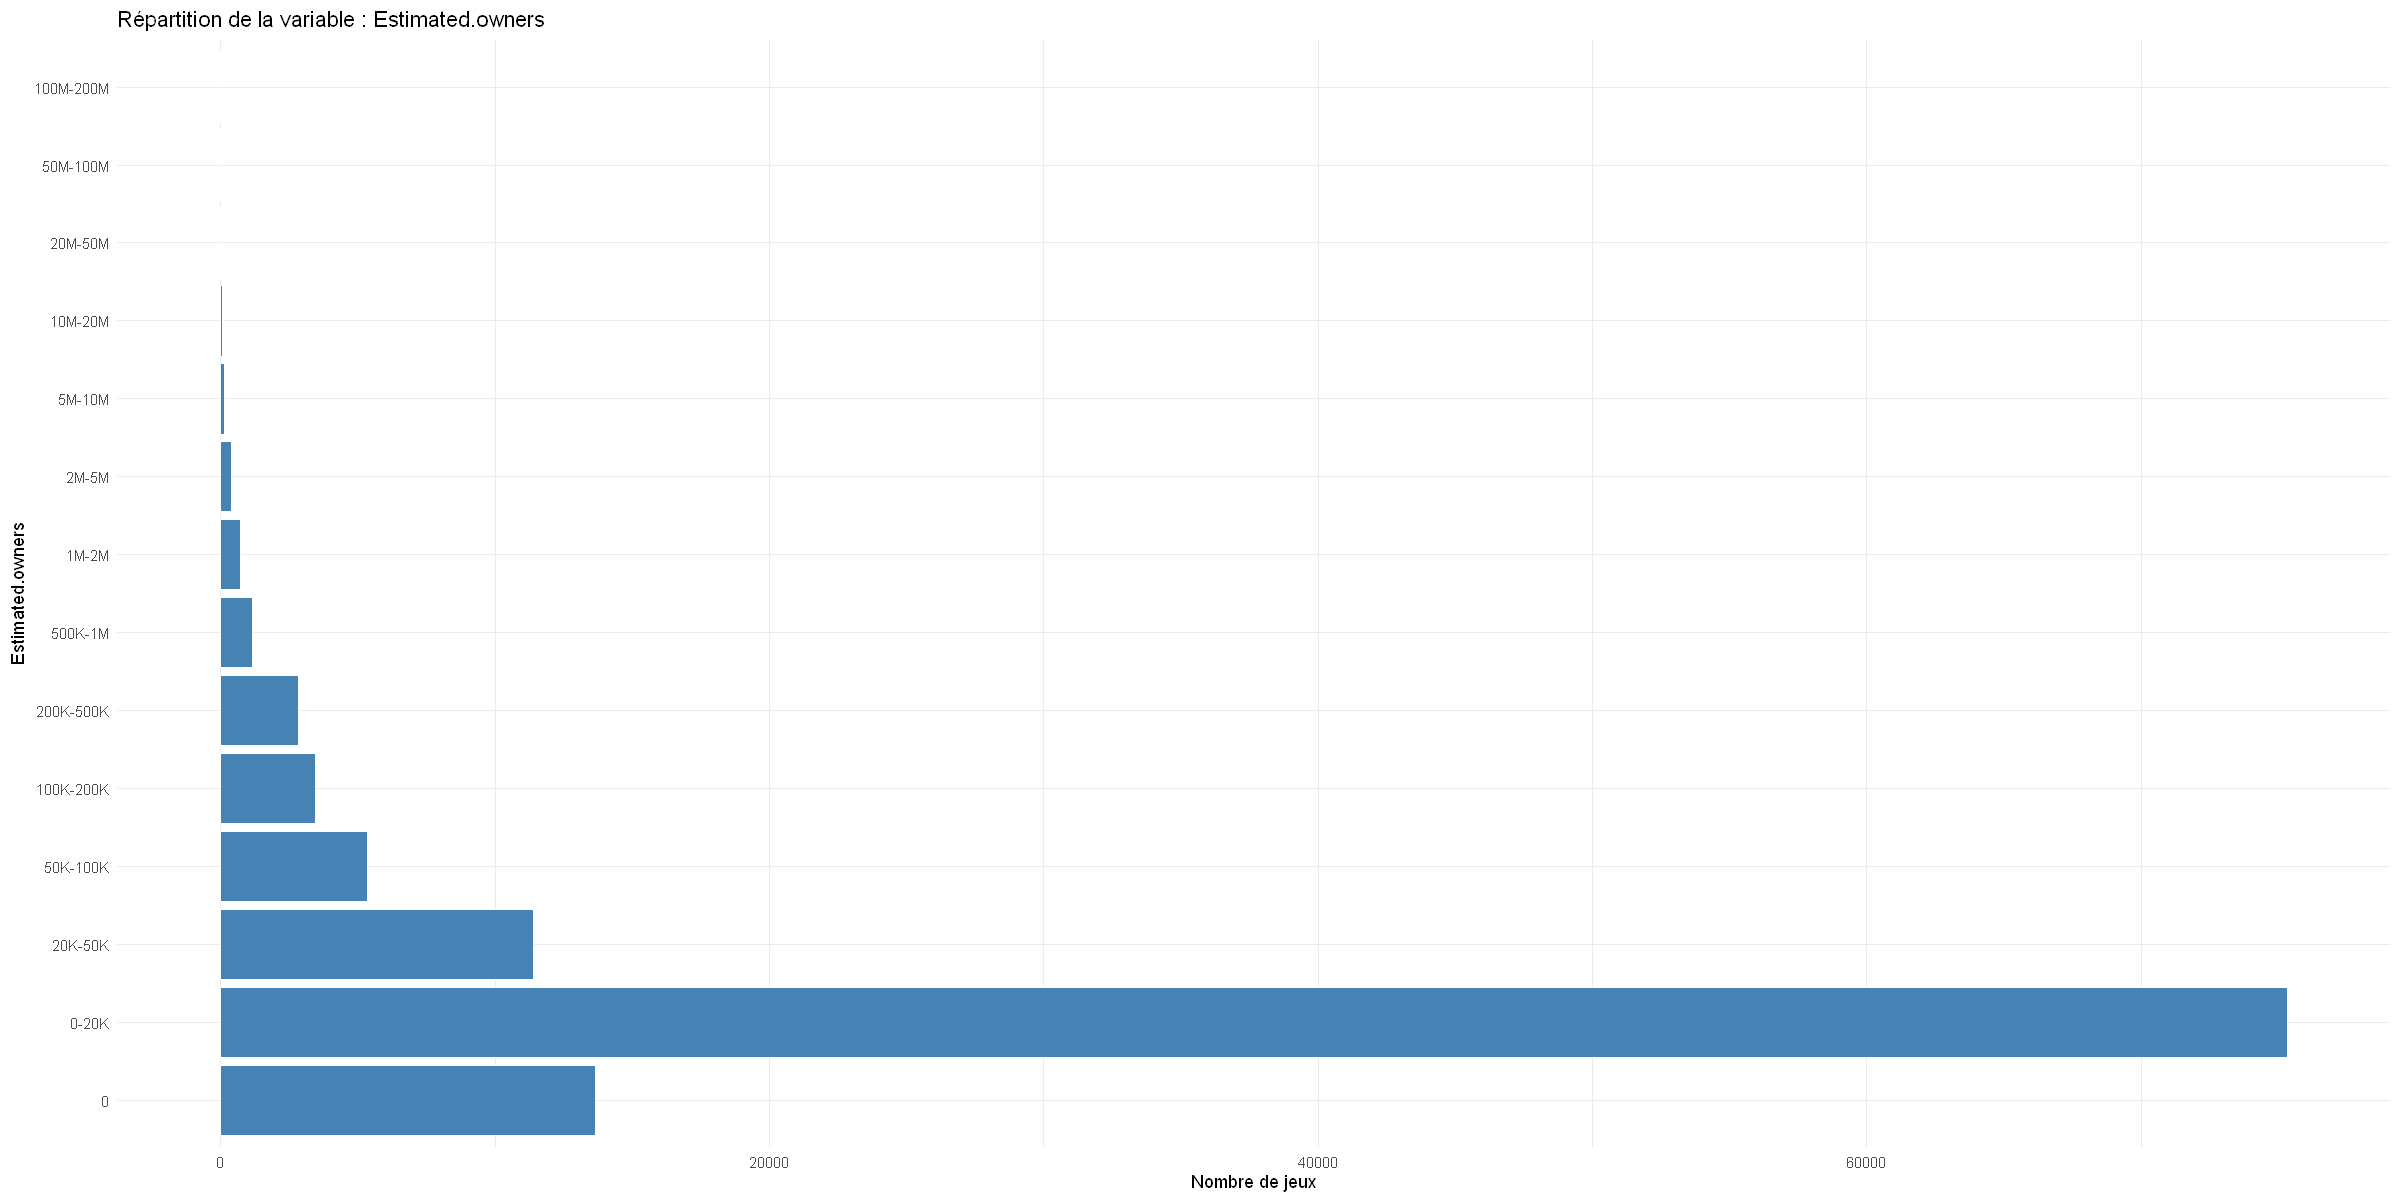

In [44]:

# On définit la liste de TES variables (car is.factor risque de rater le coche)
colonnes_qualitatives <- c("Required.age", "Windows", "Mac", "Linux", "Estimated.owners")

for (col in colonnes_qualitatives) {
    # On utilise geom_bar() car il compte les lignes automatiquement
    p <- ggplot(data_ready, aes(x = .data[[col]])) +
      geom_bar(fill = "steelblue", color = "white") +
      theme_minimal() +
      labs(
        title = paste("Répartition de la variable :", col),
        x = col,
        y = "Nombre de jeux"
      )
    
    # Gestion spécifique pour la lisibilité des owners
    if (col == "Estimated.owners") {
      p <- p + coord_flip()
    }
    
    print(p)

}

Pour les variables qualitatives, nous pouvons conclure que la quasi-totalité des jeux sont disponible sur Windows et seulement qu'une petite partie sur Windows et Linux.
De plus, il n'y a que très peu de jeux qui qui ont beaucoup d'utilisateurs, la plupart ont entre 0 et 20 000 déteneurs du jeu.
Enfin, on remarque que très peu de jeux ont des restriction d'âge

# Etude TagGgenre

In [295]:
head(data_ready$Genres)

[1] "Action,Indie,RPG,Early Access" "Action,Adventure,Casual,Indie"
[3] "Action,Adventure,Casual"       "Adventure,Casual,Indie"       
[5] "Adventure,Casual,Indie,RPG"    "Adventure,Casual,Indie"

In [321]:
#install.packages("fastDummies")

Installation du package dans 'C:/Users/fauli/AppData/Local/R/win-library/4.5'
(car 'lib' n'est pas spécifié)



le package 'fastDummies' a été décompressé et les sommes MD5 ont été vérifiées avec succés

Les packages binaires téléchargés sont dans
	C:\Users\fauli\AppData\Local\Temp\RtmpWqzxy9\downloaded_packages


In [94]:
df_genres<-df_one_hot %>% select(-c(1:28)) 
head(df_genres)

,Genres_Accounting,Genres_Animation & Modeling,Genres_Audio Production,Genres_Design & Illustration,Genres_Education,Genres_Photo Editing,Genres_Software Training,Genres_Utilities,Genres_Video Production,Genres_Web Publishing,⋯,Genres_Movie,Genres_Documentary,Genres_Episodic,Genres_Short,Genres_Tutorial,Genres_360 Video,Genres_Gore,Genres_Nudity,Genres_Violent,Genres_Sexual Content
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


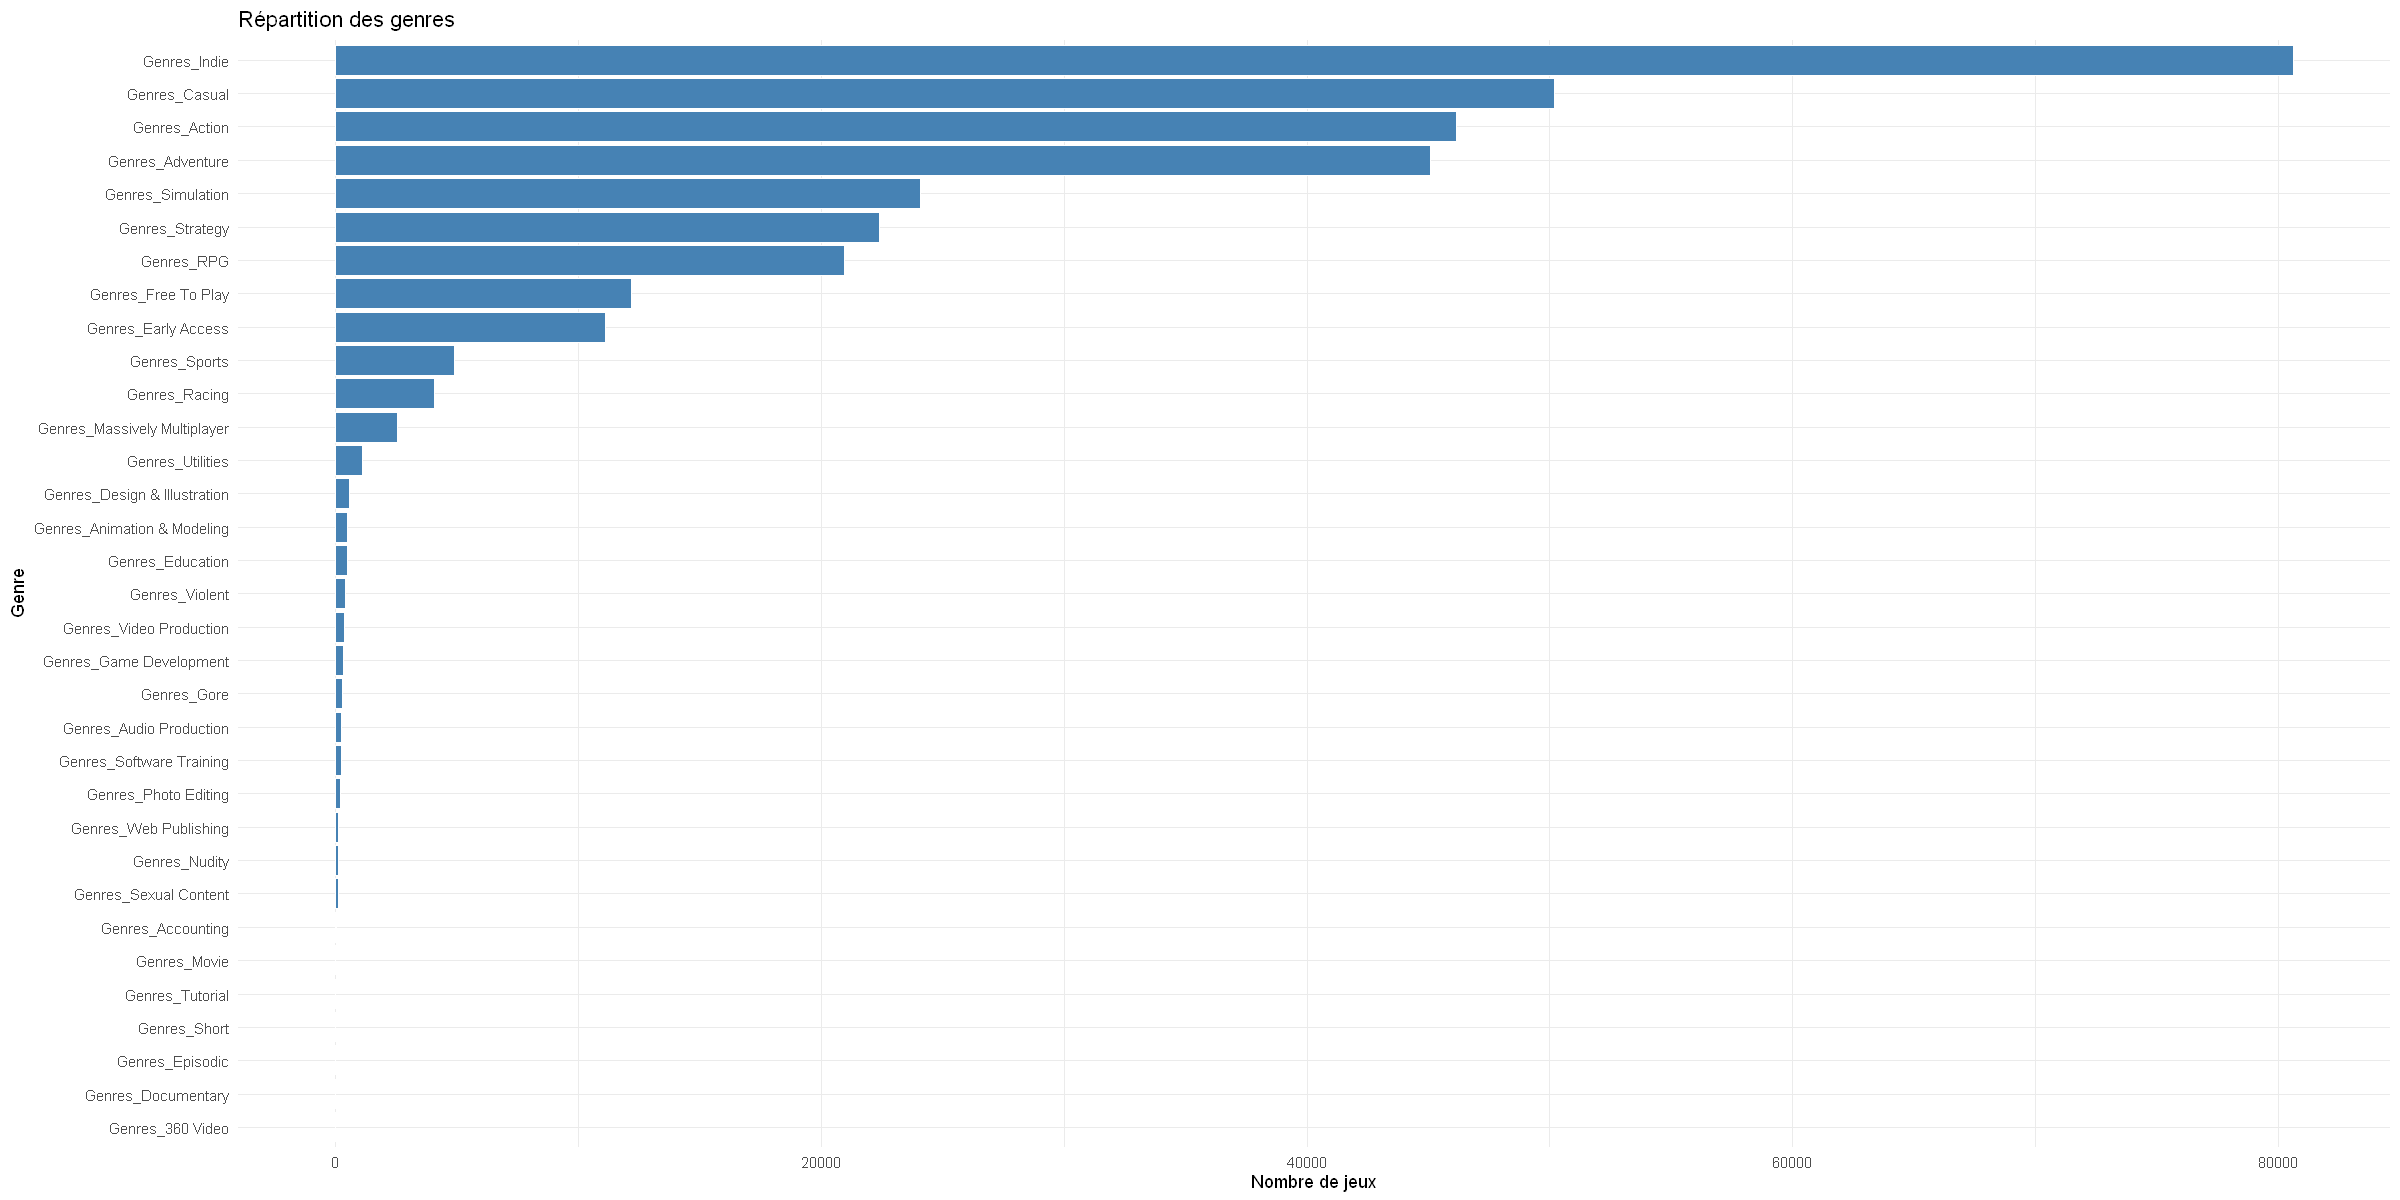

In [153]:
nbr_genre=df_genres %>%
  summarise(across(everything(), sum)) %>%
  pivot_longer(everything(), names_to = "Genre", values_to = "Nombre")

ggplot(nbr_genre,aes(x =reorder(Genre, Nombre) , y = Nombre)) +
  geom_col(fill = "steelblue", color = "white") +
  coord_flip() +
  theme_minimal() +
  labs(
    title = "Répartition des genres",
    x = "Genre",
    y = "Nombre de jeux"
  )

# relation année de sortie-genre

In [154]:
df_genres_mca <- df_genres %>%
  select(any_of(nbr_genre$Genre))


In [155]:
summary(df_genres_mca) 

 Genres_Accounting  Genres_Animation & Modeling Genres_Audio Production
 Min.   :0.000000   Min.   :0.000000            Min.   :0.000000       
 1st Qu.:0.000000   1st Qu.:0.000000            1st Qu.:0.000000       
 Median :0.000000   Median :0.000000            Median :0.000000       
 Mean   :0.000262   Mean   :0.004165            Mean   :0.001965       
 3rd Qu.:0.000000   3rd Qu.:0.000000            3rd Qu.:0.000000       
 Max.   :1.000000   Max.   :1.000000            Max.   :1.000000       
 Genres_Design & Illustration Genres_Education   Genres_Photo Editing
 Min.   :0.000000             Min.   :0.000000   Min.   :0.000000    
 1st Qu.:0.000000             1st Qu.:0.000000   1st Qu.:0.000000    
 Median :0.000000             Median :0.000000   Median :0.000000    
 Mean   :0.005065             Mean   :0.004026   Mean   :0.001572    
 3rd Qu.:0.000000             3rd Qu.:0.000000   3rd Qu.:0.000000    
 Max.   :1.000000             Max.   :1.000000   Max.   :1.000000    
 Genre

In [156]:

df_mca_genres <- as.data.frame(lapply(df_genres_mca, as.factor))
summary(df_mca_genres)

 Genres_Accounting Genres_Animation...Modeling Genres_Audio.Production
 0:114483          0:114036                    0:114288               
 1:    30          1:   477                    1:   225               
 Genres_Design...Illustration Genres_Education Genres_Photo.Editing
 0:113933                     0:114052         0:114333            
 1:   580                     1:   461         1:   180            
 Genres_Software.Training Genres_Utilities Genres_Video.Production
 0:114294                 0:113436         0:114175               
 1:   219                 1:  1077         1:   338               
 Genres_Web.Publishing Genres_Game.Development Genres_Early.Access
 0:114401              0:114193                0:103422           
 1:   112              1:   320                1: 11091           
 Genres_Action Genres_Adventure Genres_Casual Genres_Free.To.Play Genres_Indie
 0:68358       0:69409          0:64321       0:102353            0:33903     
 1:46155       1:45104 

In [162]:
nbr_genre_100=df_genres %>%
  summarise(across(everything(), sum)) %>%
  pivot_longer(everything(), names_to = "Genre", values_to = "Nombre")%>%
  filter(Nombre>100)


df_genre_mca_100 <- df_genres %>%
  select(any_of(nbr_genre_100$Genre))

In [163]:
summary(df_genre_mca_100)

 Genres_Animation & Modeling Genres_Audio Production
 Min.   :0.000000            Min.   :0.000000       
 1st Qu.:0.000000            1st Qu.:0.000000       
 Median :0.000000            Median :0.000000       
 Mean   :0.004165            Mean   :0.001965       
 3rd Qu.:0.000000            3rd Qu.:0.000000       
 Max.   :1.000000            Max.   :1.000000       
 Genres_Design & Illustration Genres_Education   Genres_Photo Editing
 Min.   :0.000000             Min.   :0.000000   Min.   :0.000000    
 1st Qu.:0.000000             1st Qu.:0.000000   1st Qu.:0.000000    
 Median :0.000000             Median :0.000000   Median :0.000000    
 Mean   :0.005065             Mean   :0.004026   Mean   :0.001572    
 3rd Qu.:0.000000             3rd Qu.:0.000000   3rd Qu.:0.000000    
 Max.   :1.000000             Max.   :1.000000   Max.   :1.000000    
 Genres_Software Training Genres_Utilities   Genres_Video Production
 Min.   :0.000000         Min.   :0.000000   Min.   :0.000000       
 

In [167]:


# --- ÉTAPE 2 : Combiner l'année avec ton dataset des 20 genres ---
df_analyse_temps <- cbind(df_genre_mca_100, annee = data_ready$Release.date)

# --- ÉTAPE 3 : Calculer le nombre de sorties par année et par genre ---
evolution_genres <- df_analyse_temps %>%
  # On groupe par année
  group_by(annee) %>%
  # On fait la somme des 1 pour chaque genre
  summarise(across(everything(), sum)) %>%
  # On repasse en format long pour ggplot
  pivot_longer(cols = -annee, names_to = "Genre", values_to = "Nombre_de_jeux")

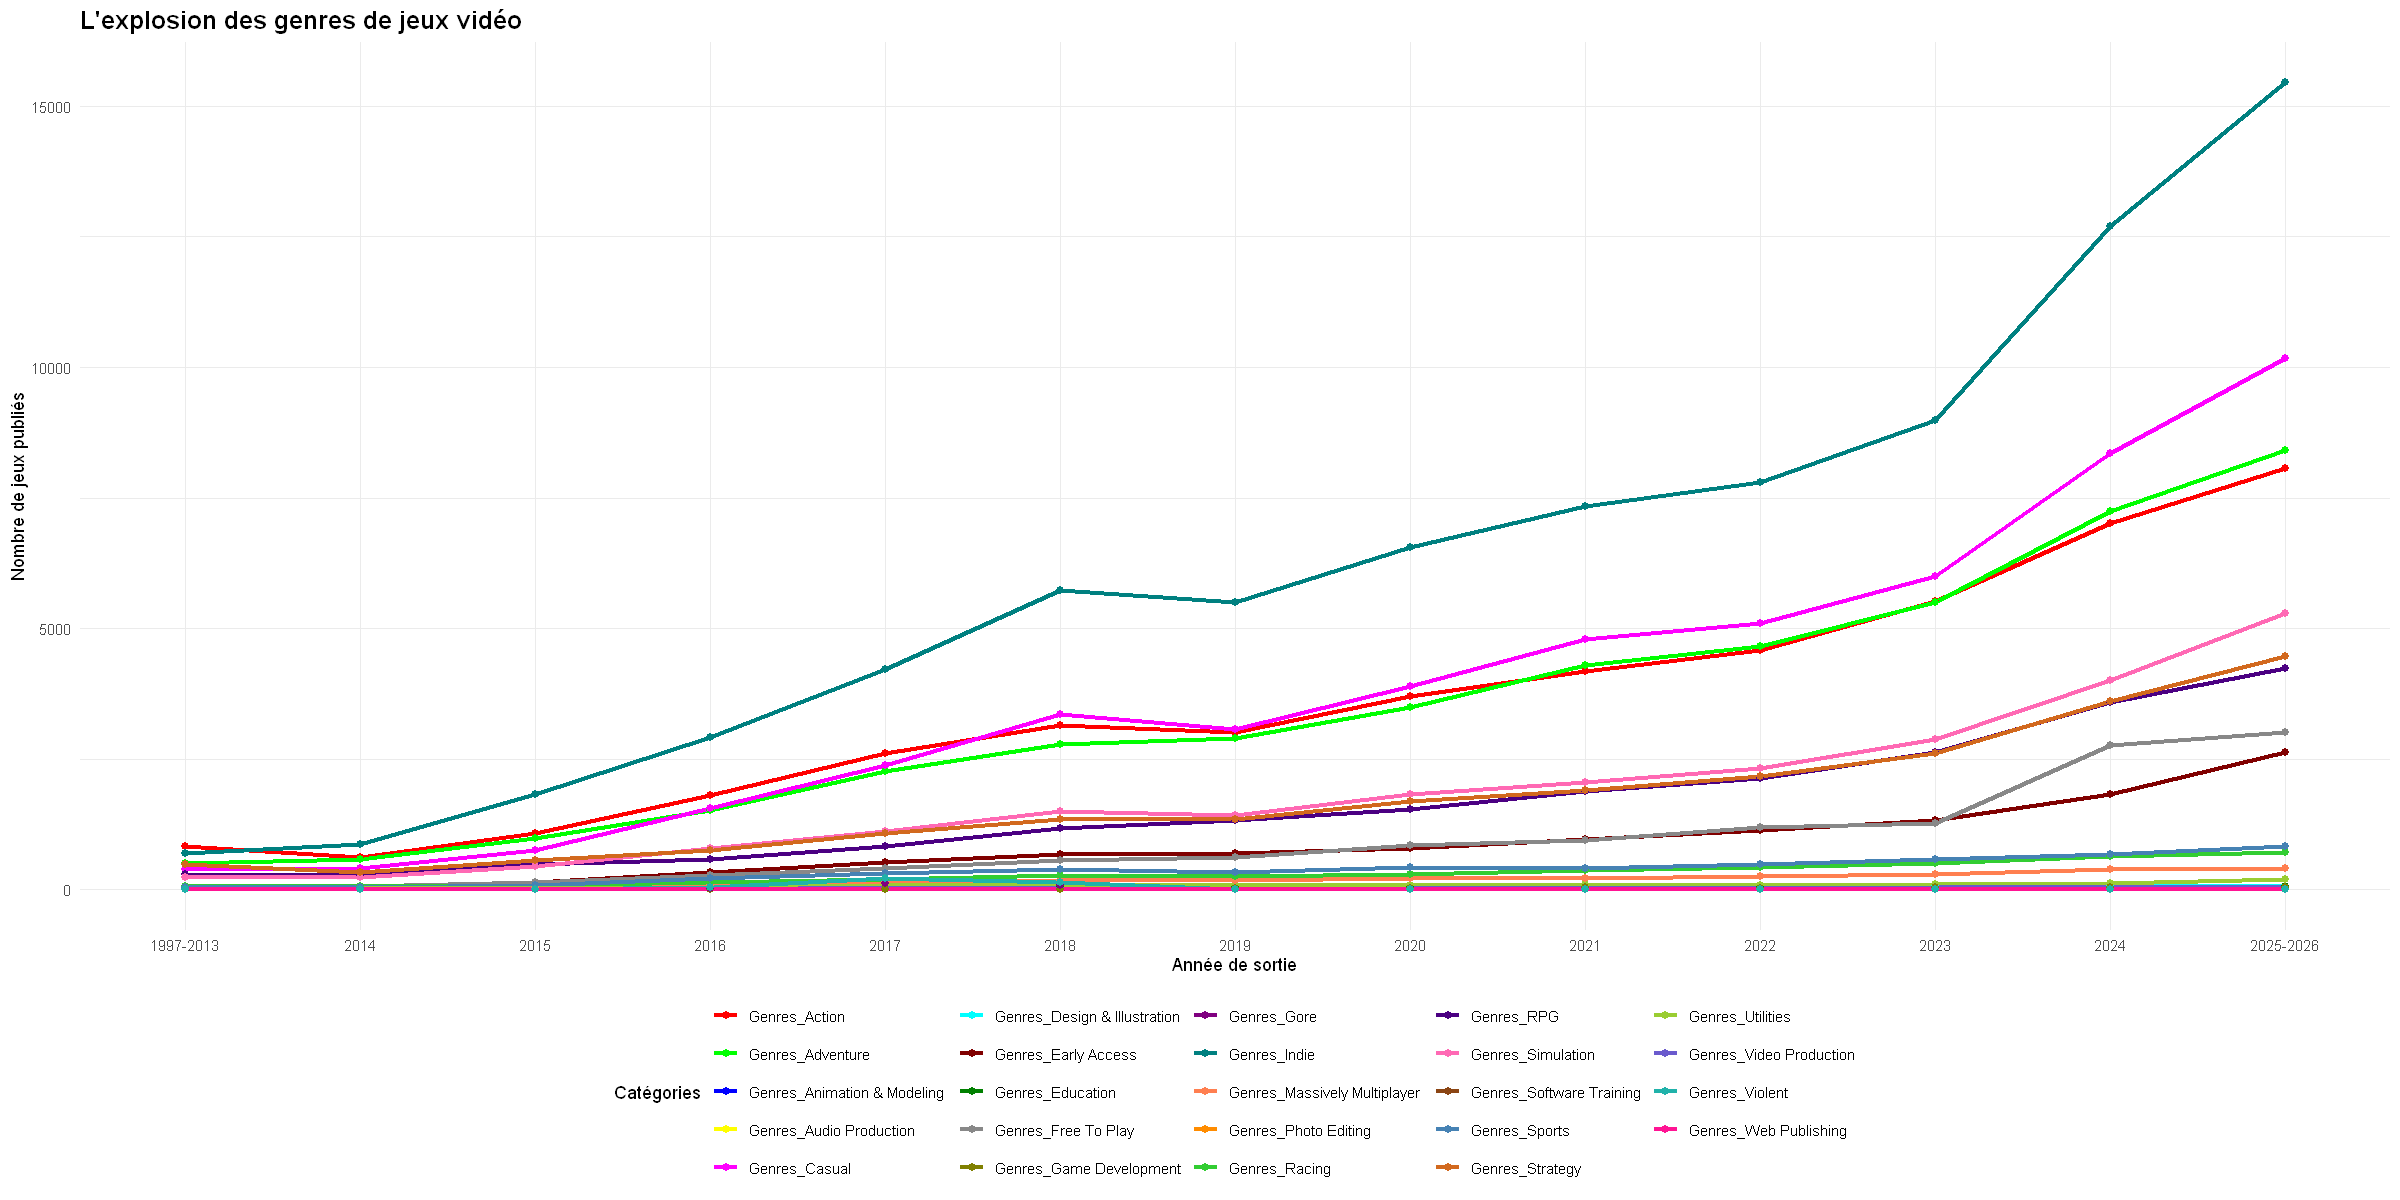

In [168]:
palette_24_couleurs <- c(
  "#FF0000", "#00FF00", "#0000FF", "#FFFF00", "#FF00FF", "#00FFFF", 
  "#800000", "#008000", "#888888", "#808000", "#800080", "#008080", 
  "#FF7F50", "#FF8C00", "#32CD32", "#4B0082", "#FF69B4", "#8B4513", 
  "#4682B4", "#D2691E", "#9ACD32", "#6A5ACD", "#20B2AA", "#FF1493"
)

# 2. Ton graphique
ggplot(evolution_genres, aes(x = annee, y = Nombre_de_jeux, color = Genre, group = Genre)) +
  geom_line(linewidth = 1.2) + 
  geom_point(size = 2) +       
  scale_color_manual(values = palette_24_couleurs) + 
  theme_minimal() +
  labs(
    title = "L'explosion des genres de jeux vidéo ",
    x = "Année de sortie",
    y = "Nombre de jeux publiés",
    color = "Catégories"
  ) +
  theme(
    legend.position = "bottom",
    plot.title = element_text(face = "bold", size = 15)
  )

On remarque une croissance qui débute clairement lors de l'année 2015 pour les genres les plus mainstreams comme Action, Casual, Adventure etc..

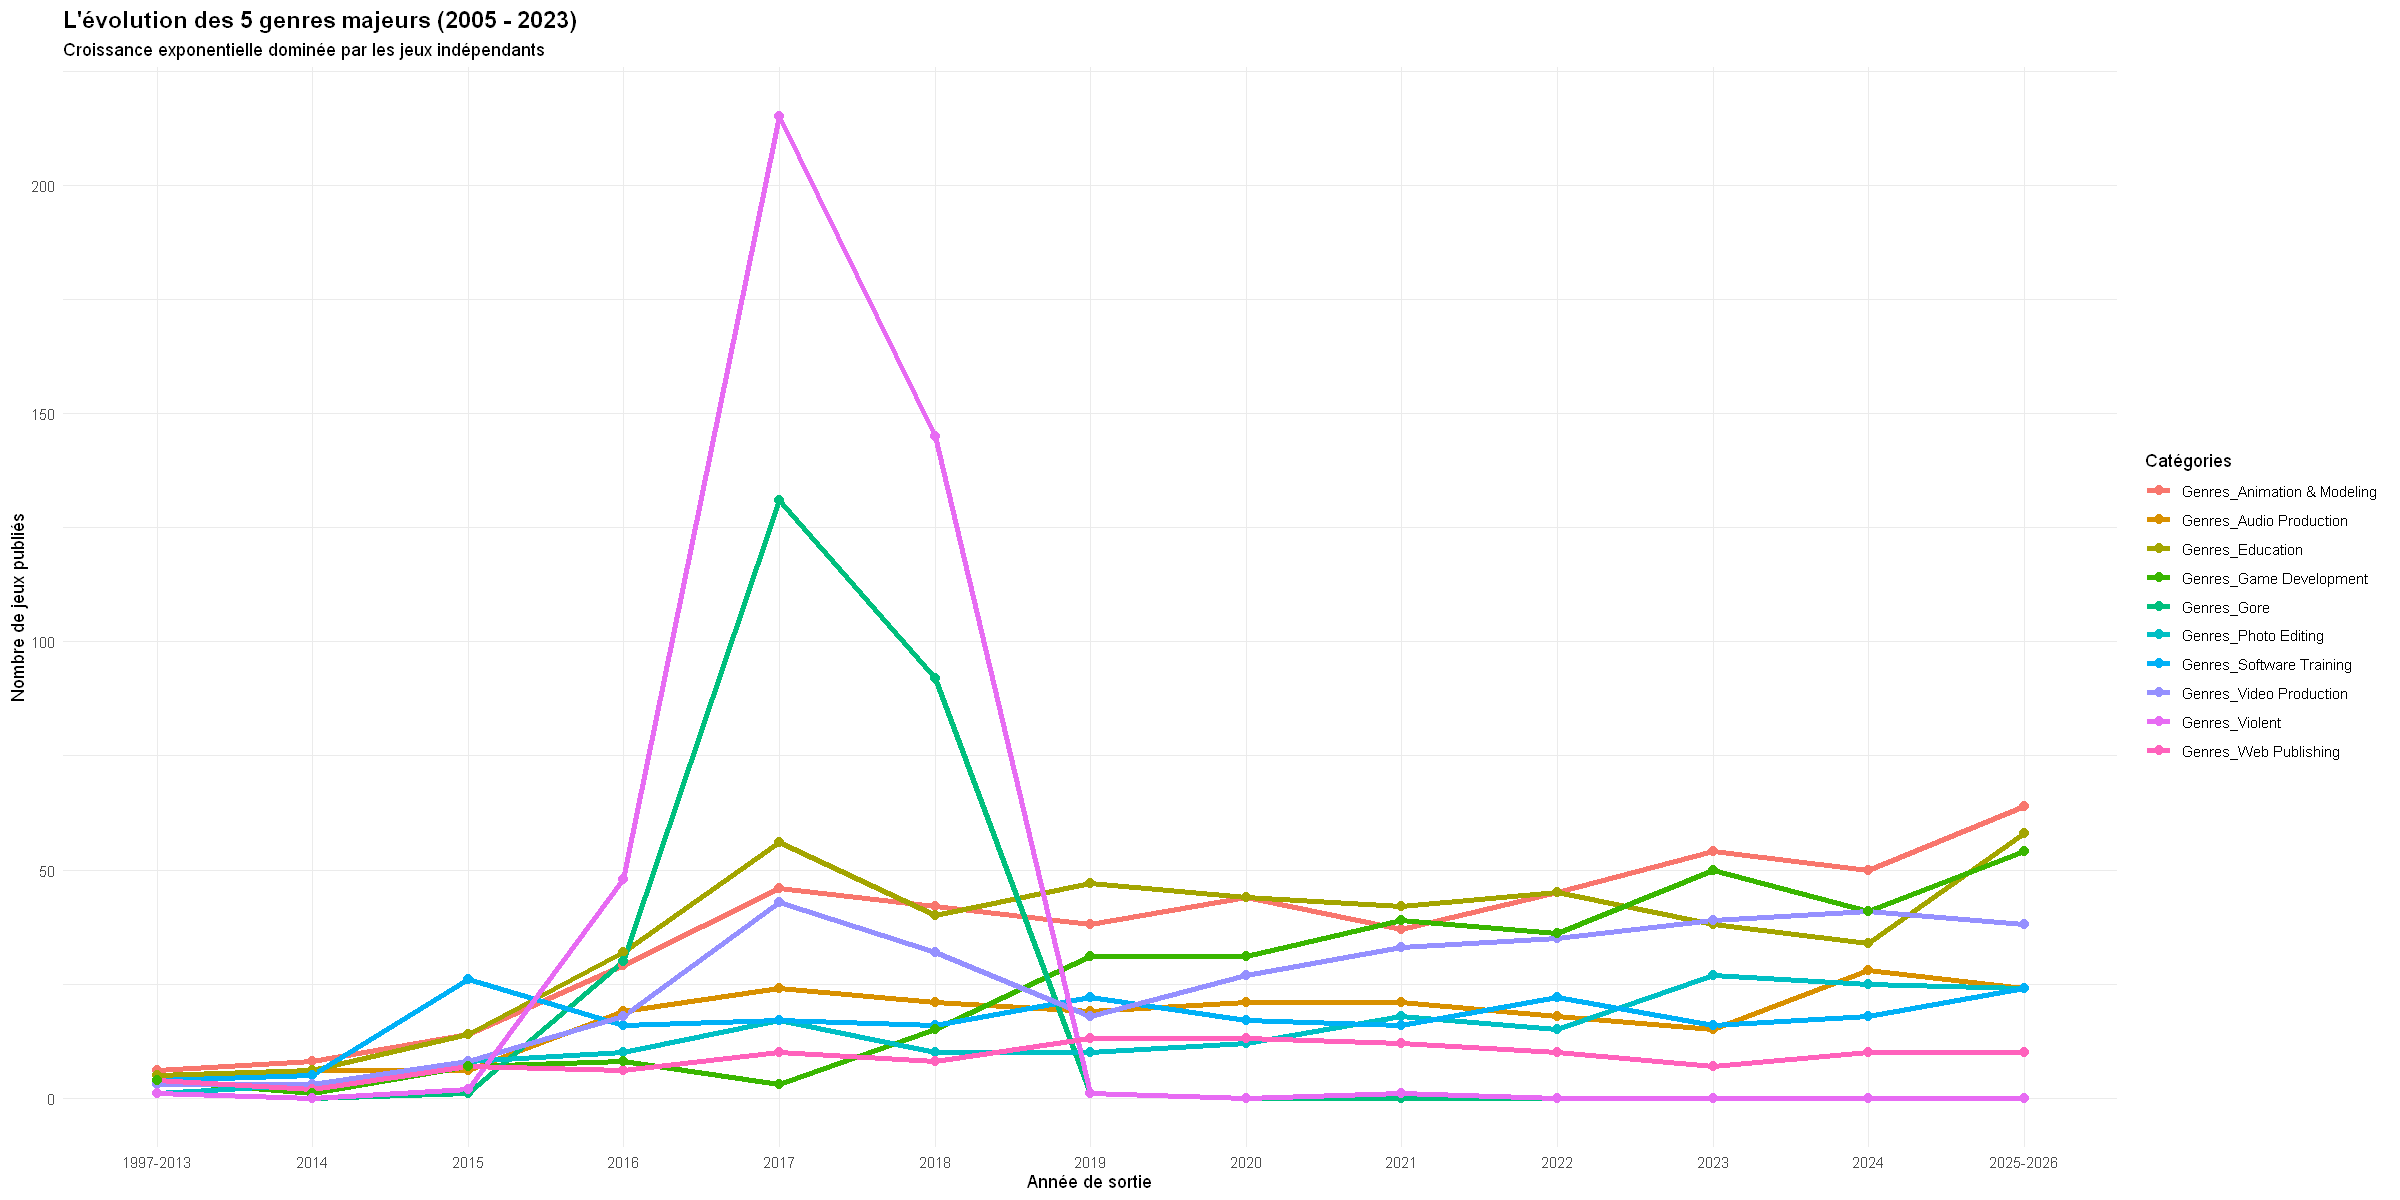

In [175]:

# 1. Trouver les noms des 5 plus petit genres
top_10_noms <- df_genre_mca_100 %>%
  summarise(across(everything(), sum)) %>%
  pivot_longer(everything(), names_to = "Genre", values_to = "Total") %>%
  slice_max(order_by = -Total, n = 10) %>%
  pull(Genre)

# 2. Filtrer les données d'évolution pour ce Top 10
evolution_top10 <- evolution_genres %>%
  filter(Genre %in% top_10_noms) 

# 3. Le graphique épuré
ggplot(evolution_top10, aes(x = annee, y = Nombre_de_jeux, color = Genre, group = Genre)) +
  geom_line(linewidth = 1.5) + # Ligne un peu plus épaisse
  geom_point(size = 2.5) +
  theme_minimal() +
  labs(
    title = "L'évolution des 5 genres majeurs (2005 - 2023)",
    subtitle = "Croissance exponentielle dominée par les jeux indépendants",
    x = "Année de sortie",
    y = "Nombre de jeux publiés",
    color = "Catégories"
  ) +
  theme(
    legend.position = "right",
    plot.title = element_text(face = "bold", size = 14)
  )

on remarque l'esplosion des jeux gore et violent autour des années 2017

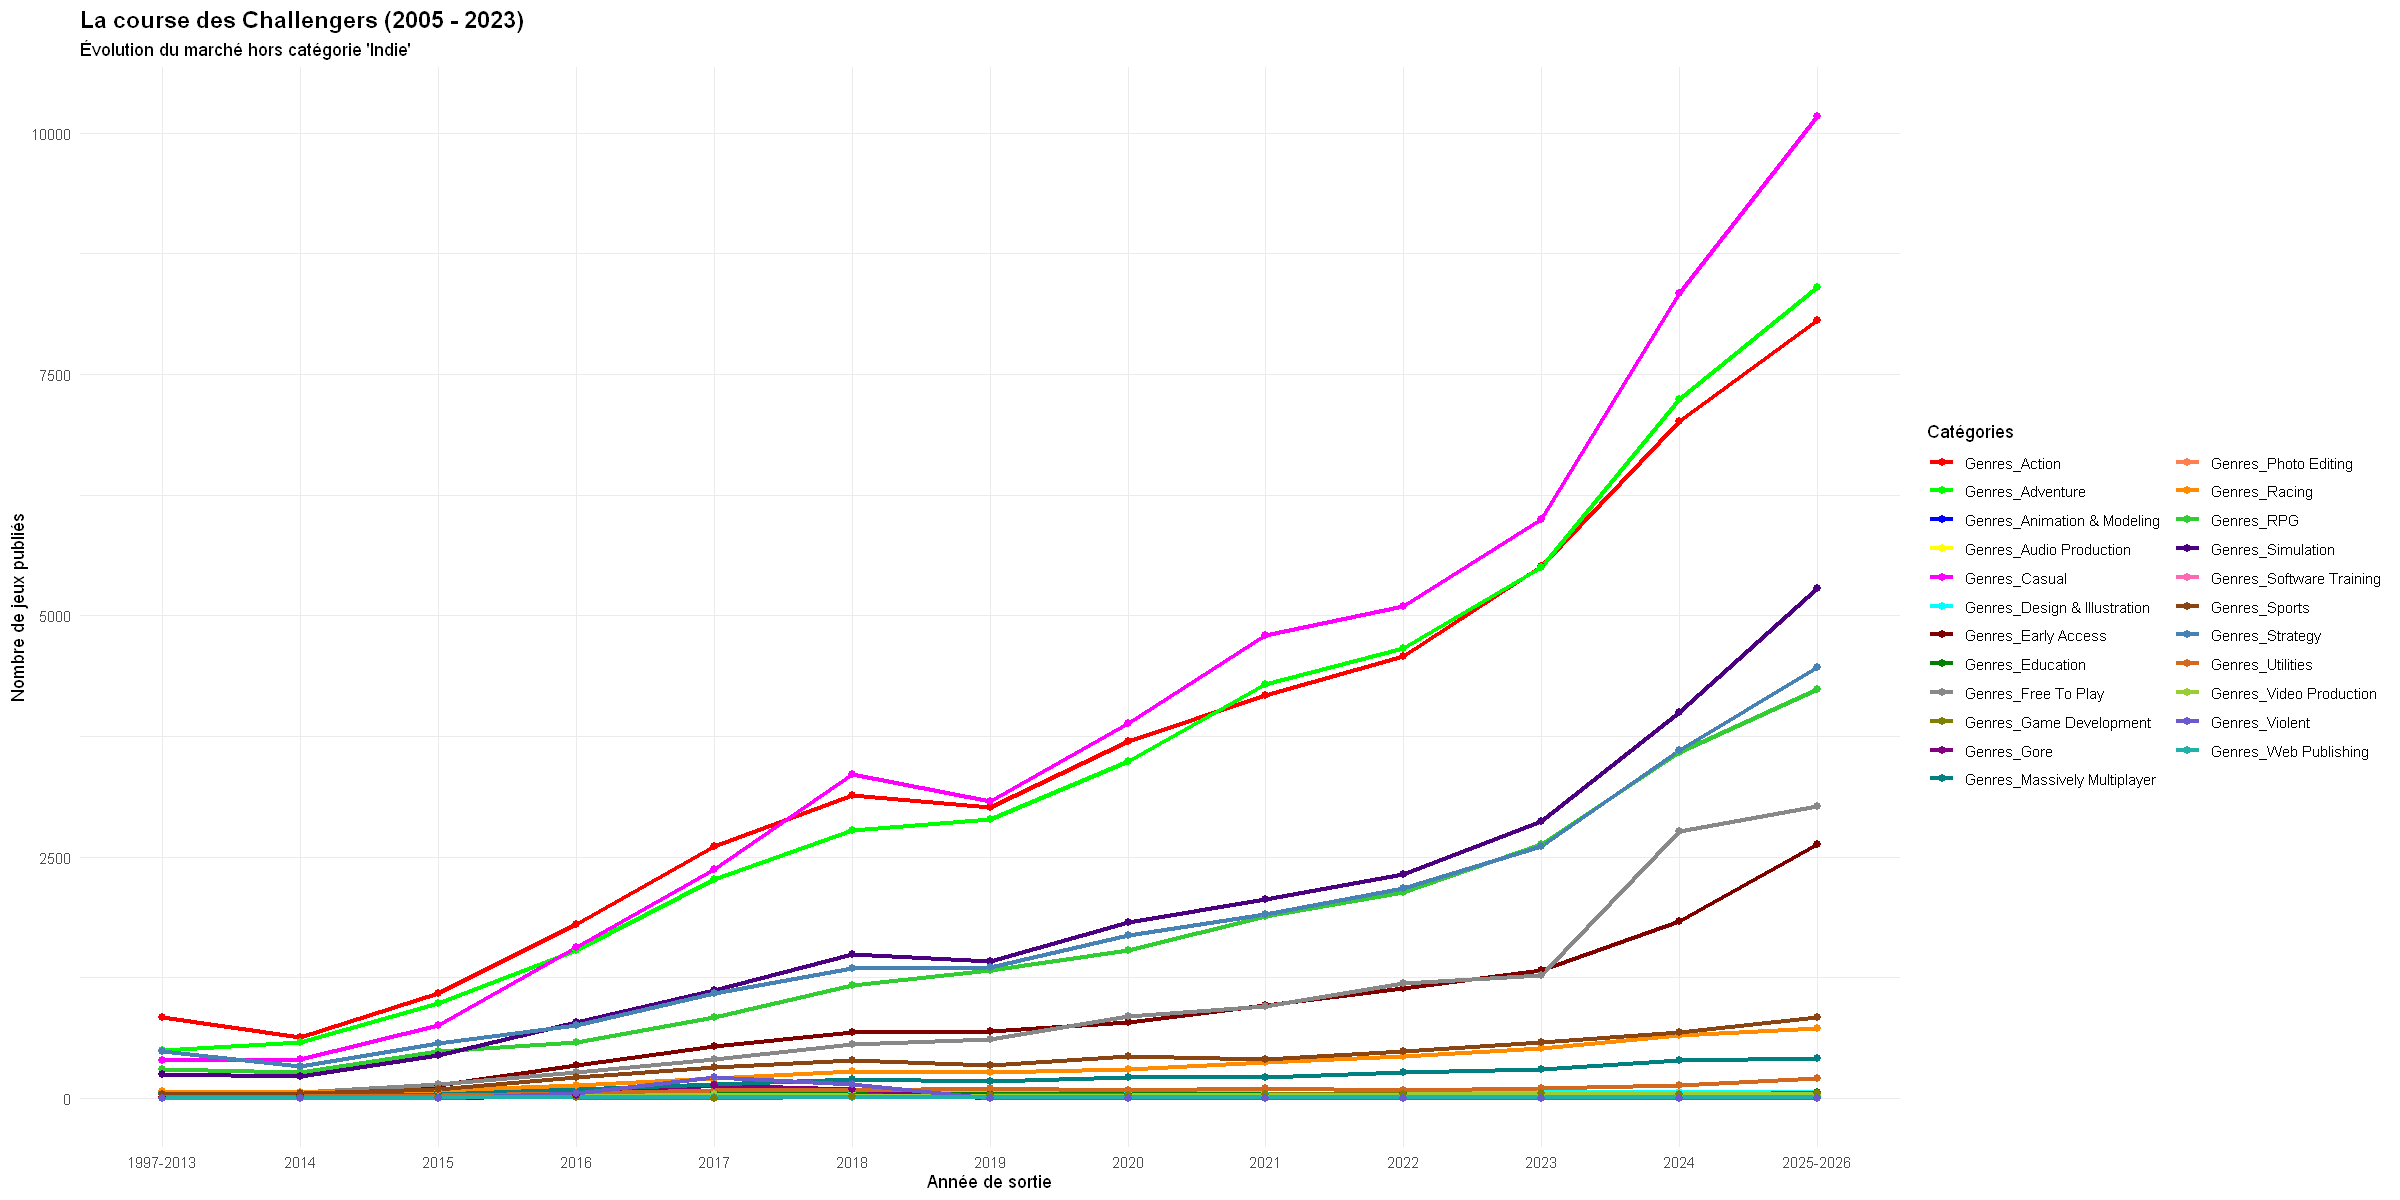

In [176]:

sans_indie <- df_genres_mca%>%
  summarise(across(everything(), sum)) %>%
  pivot_longer(everything(), names_to = "Genre", values_to = "Total") %>%
  filter(Genre != "Genres_Indie") %>%
pull(Genre)


# 2. Filtrer les données
evolution_sans_indie <- evolution_genres %>%
  filter(Genre %in% sans_indie) 


palette_23_couleurs <- c(
  "#FF0000", "#00FF00", "#0000FF", "#FFFF00", "#FF00FF", "#00FFFF", 
  "#800000", "#008000","#808000", "#800080", "#008080", 
  "#FF7F50", "#FF8C00", "#32CD32", "#4B0082", "#FF69B4", "#8B4513", 
  "#4682B4", "#D2691E", "#9ACD32", "#6A5ACD", "#20B2AA", "#FF1493"
)
ggplot(evolution_sans_indie, aes(x = annee, y = Nombre_de_jeux, color = Genre, group = Genre)) +
  geom_line(linewidth = 1.2) +
  geom_point(size = 2) +
  scale_color_manual(values = palette_24_couleurs) +# Une belle palette intégrée pour 8 couleurs
  theme_minimal() +
  labs(
    title = "La course des Challengers (2005 - 2023)",
    subtitle = "Évolution du marché hors catégorie 'Indie'",
    x = "Année de sortie",
    y = "Nombre de jeux publiés",
    color = "Catégories"
  ) +
  theme(
    legend.position = "right",
    plot.title = element_text(face = "bold", size = 14)
  )

A partir de 2023 il y a eu une nette augmentation des nouveaux jeux pour les genres plus communs en revanche pour les jeux plus niches, le nombre de nouveaux jeux restent constantes voire augmentes légèrement

# ACM genre

In [273]:

df_genres_mca <- df_genres_mca %>%
  mutate(across(everything(), as.factor))

In [274]:
summary(df_genres_mca)

 Genres_Accounting Genres_Animation & Modeling Genres_Audio Production
 0:114483          0:114036                    0:114288               
 1:    30          1:   477                    1:   225               
 Genres_Design & Illustration Genres_Education Genres_Photo Editing
 0:113933                     0:114052         0:114333            
 1:   580                     1:   461         1:   180            
 Genres_Software Training Genres_Utilities Genres_Video Production
 0:114294                 0:113436         0:114175               
 1:   219                 1:  1077         1:   338               
 Genres_Web Publishing Genres_Game Development Genres_Early Access
 0:114401              0:114193                0:103422           
 1:   112              1:   320                1: 11091           
 Genres_Action Genres_Adventure Genres_Casual Genres_Free To Play Genres_Indie
 0:68358       0:69409          0:64321       0:102353            0:33903     
 1:46155       1:45104 

In [275]:

df_genres_mca <- df_genres_mca %>%
  mutate(across(everything(), as.factor))

res.mca_genres <- MCA(df_genres_mca, graph = FALSE)



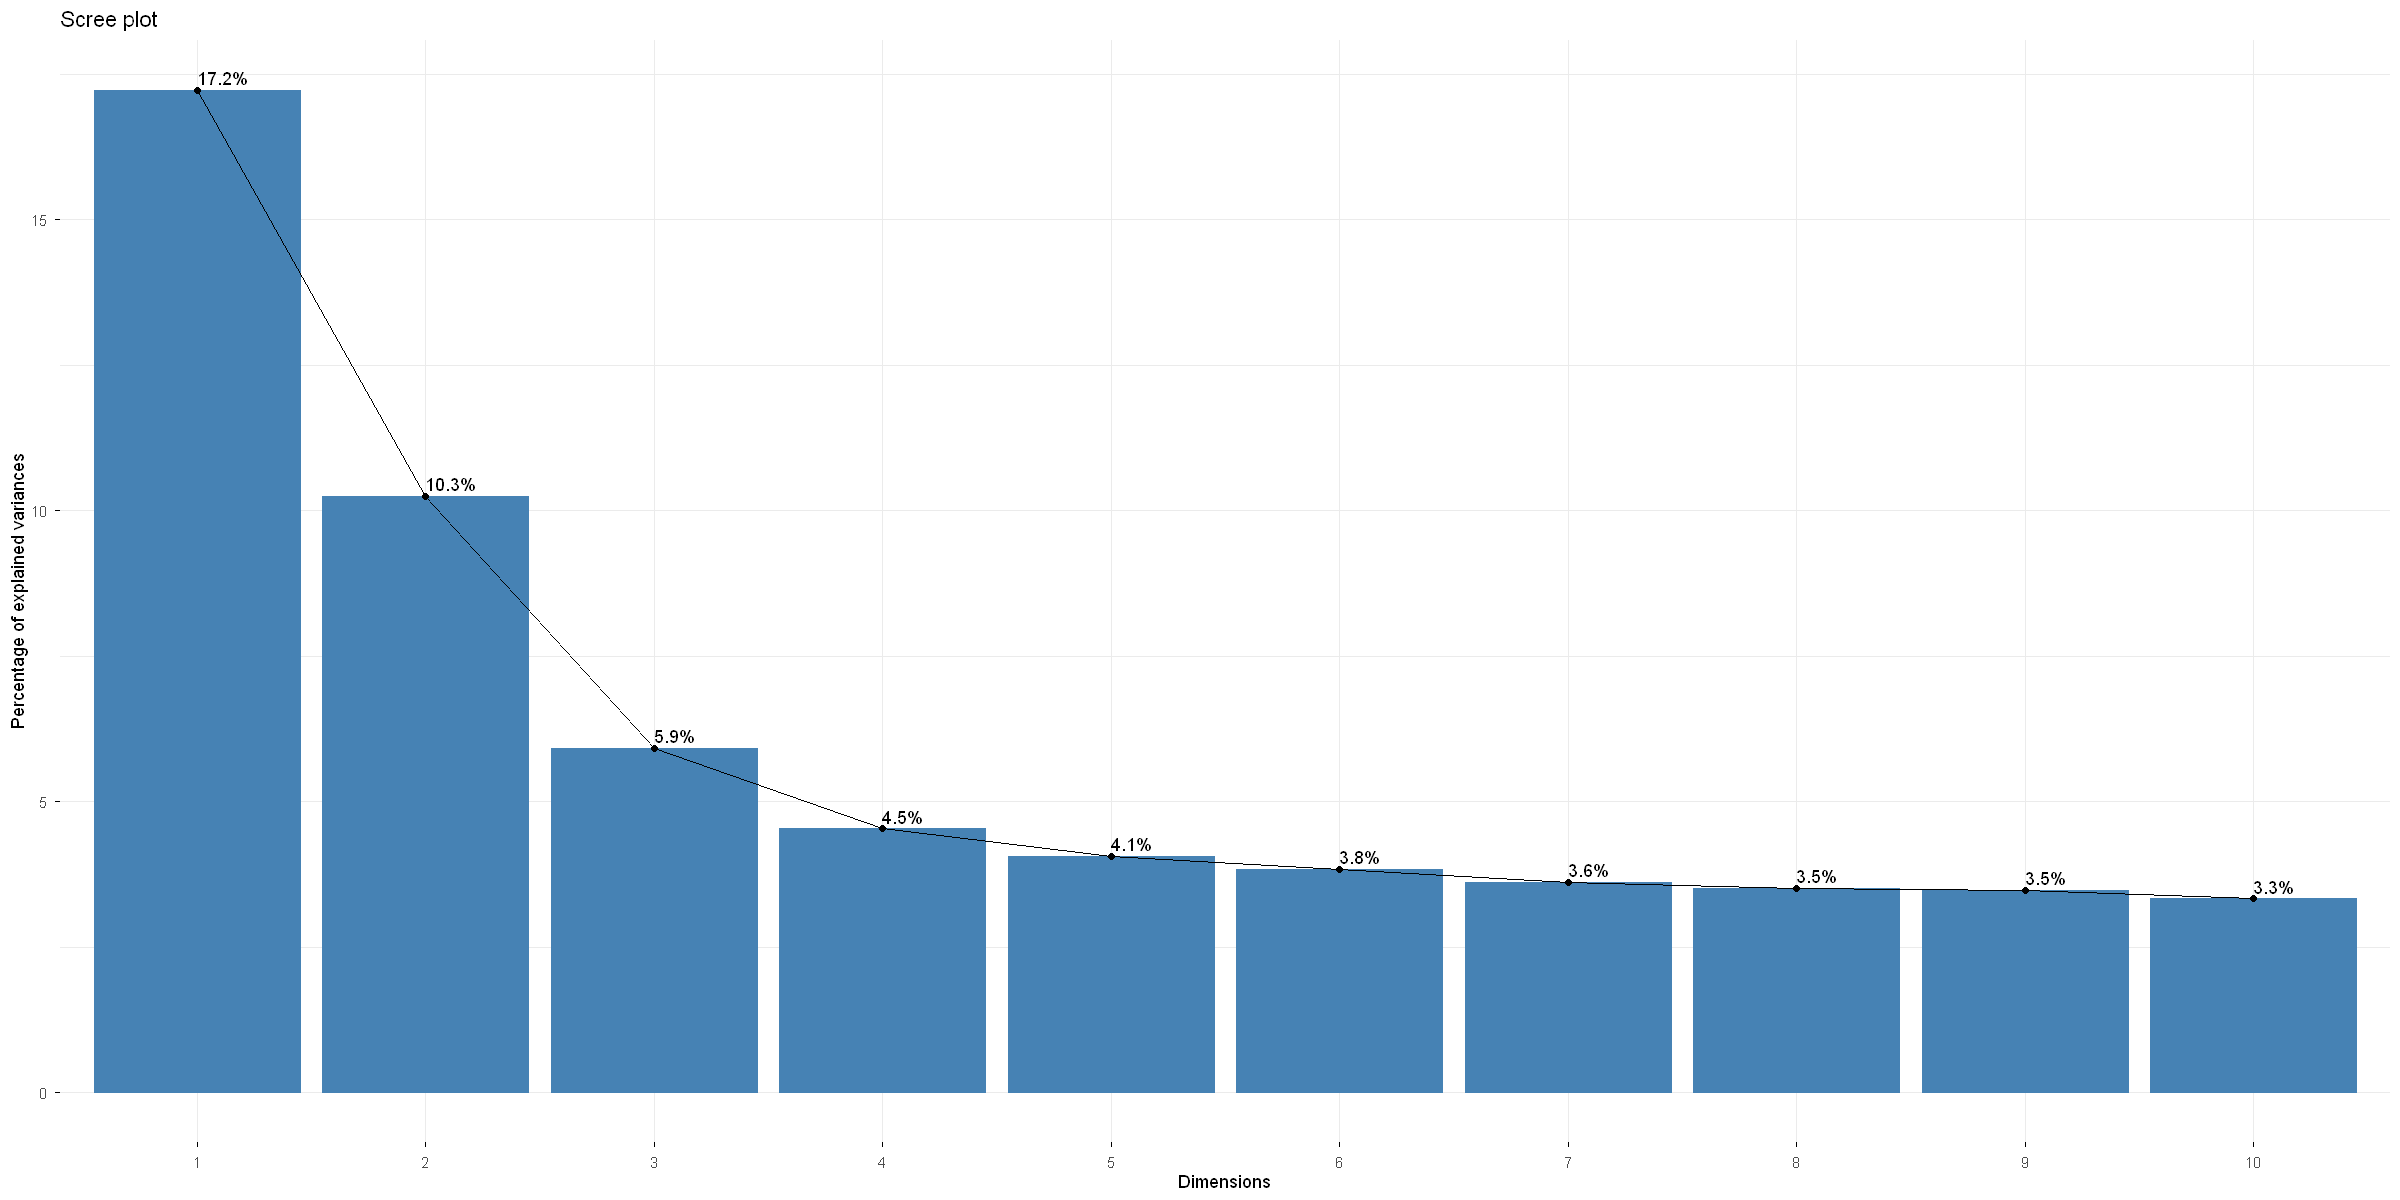

In [276]:
fviz_screeplot(res.mca_genres, addlabels=TRUE)

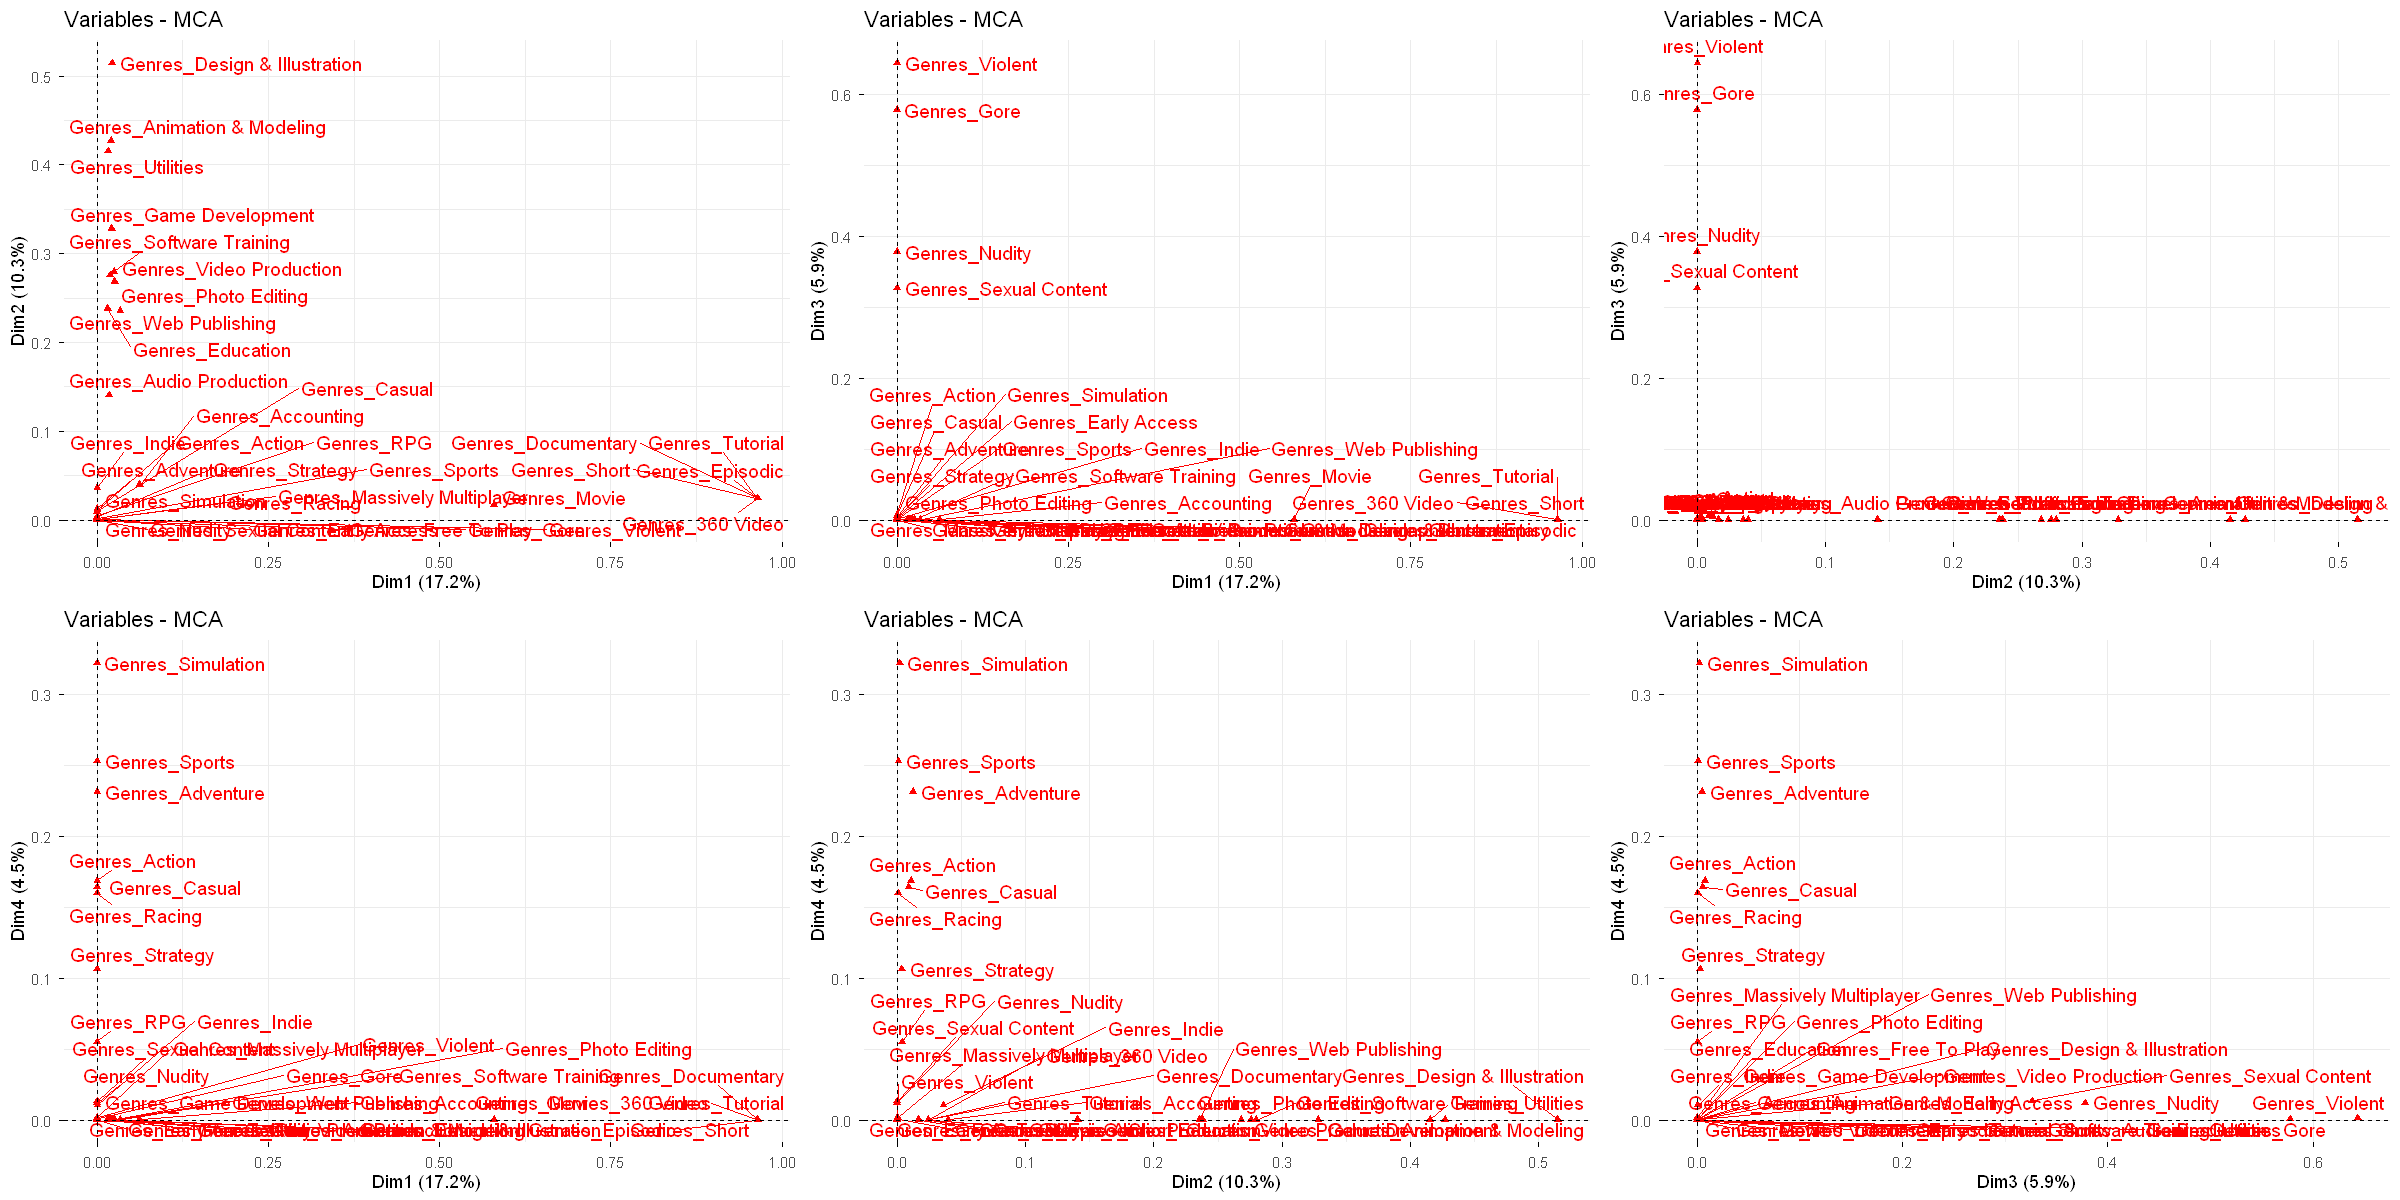

In [182]:
options(repr.plot.width = 20, repr.plot.height = 10)
g1=fviz_mca_var(res.mca_genres,axes = c(1,2),repel=TRUE,choice = "mca.cor")
g2=fviz_mca_var(res.mca_genres,axes = c(1,3),repel=TRUE,choice = "mca.cor")
g3=fviz_mca_var(res.mca_genres,axes = c(2,3),repel=F,choice = "mca.cor")
g4=fviz_mca_var(res.mca_genres,axes = c(1,4),repel=TRUE,choice = "mca.cor")
g5=fviz_mca_var(res.mca_genres,axes = c(2,4),repel=TRUE,choice = "mca.cor")
g6=fviz_mca_var(res.mca_genres,axes = c(3,4),repel=TRUE,choice = "mca.cor")

grid.arrange(g1,g2,g3,g4,g5,g6,ncol=3)

In [183]:
explication_axe1 <- dimdesc(res.mca_genres, axes = 1)
explication_axe2 <- dimdesc(res.mca_genres, axes = 2)
explication_axe3 <- dimdesc(res.mca_genres, axes = 3)
explication_axe4 <- dimdesc(res.mca_genres, axes = 4)

In [203]:
explication_axe1[[1]]$category

,Estimate,p.value
Genres_360 Video=Genres_360 Video_1,68.961312433,0.000000e+00
Genres_Tutorial=Genres_Tutorial_1,68.961312433,0.000000e+00
Genres_Short=Genres_Short_1,68.961312433,0.000000e+00
Genres_Episodic=Genres_Episodic_1,68.961312433,0.000000e+00
Genres_Documentary=Genres_Documentary_1,68.961312433,0.000000e+00
Genres_Movie=Genres_Movie_1,37.803666279,0.000000e+00
Genres_Game Development=Genres_Game Development_1,0.573892943,0.000000e+00
Genres_Web Publishing=Genres_Web Publishing_1,1.222616296,0.000000e+00
Genres_Video Production=Genres_Video Production_1,0.528136939,0.000000e+00
Genres_Utilities=Genres_Utilities_1,0.271622451,0.000000e+00


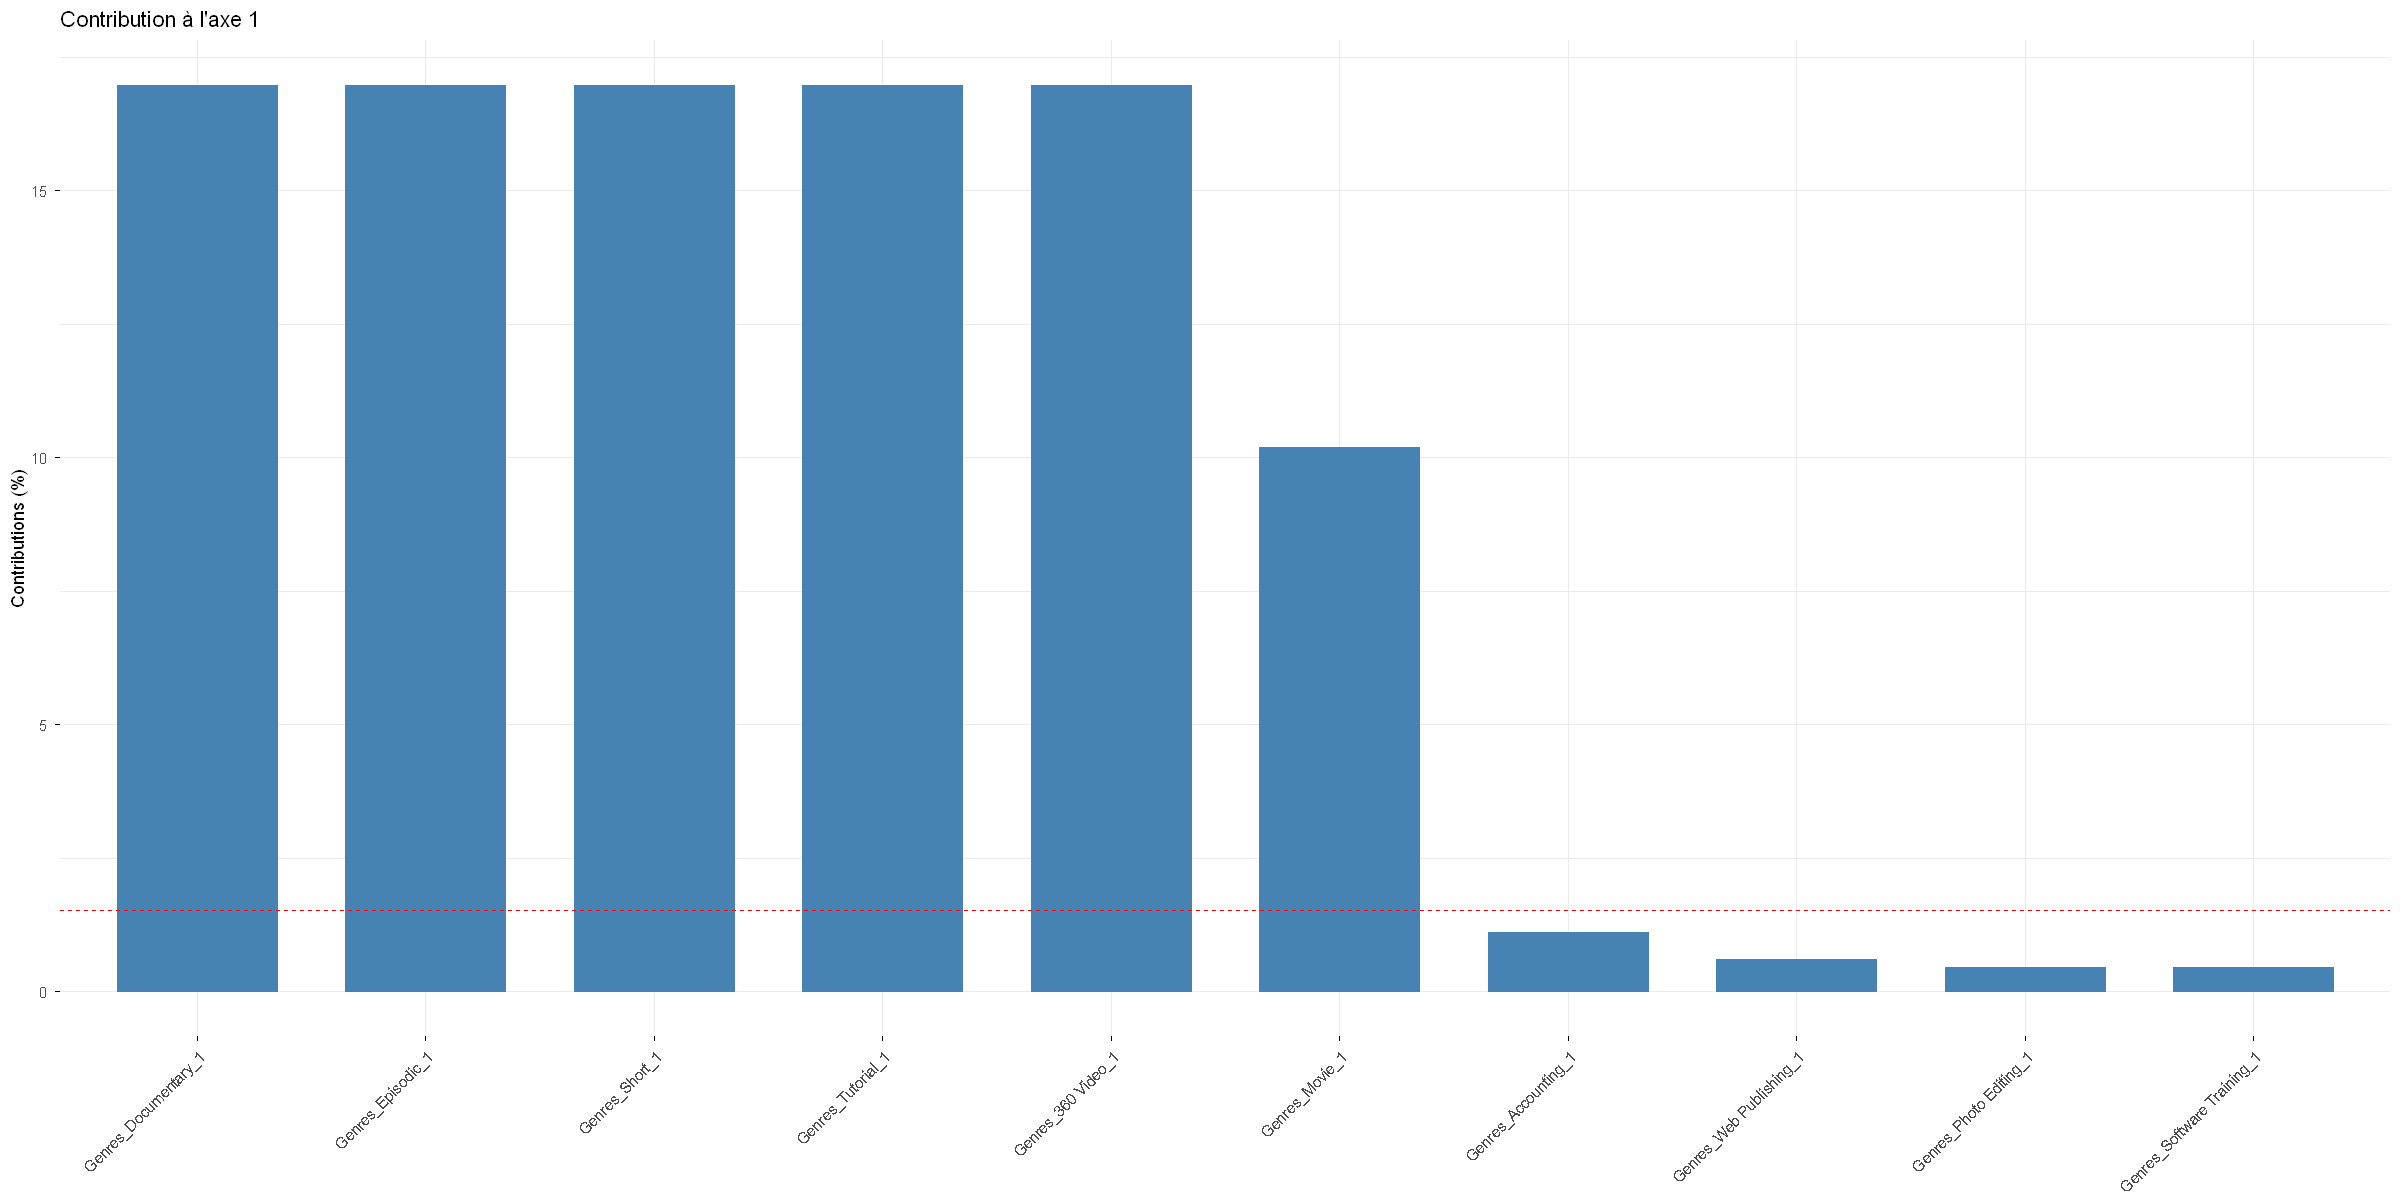

In [201]:

fviz_contrib(res.mca_genres, 
             choice = "var",  
             axes = 1,  
             top=10,
             title ="Contribution à l'axe 1")

In [186]:
explication_axe2[[1]]$category

,Estimate,p.value
Genres_360 Video=Genres_360 Video_0,8.442705926,0.000000e+00
Genres_Tutorial=Genres_Tutorial_0,8.442705926,0.000000e+00
Genres_Short=Genres_Short_0,8.442705926,0.000000e+00
Genres_Episodic=Genres_Episodic_0,8.442705926,0.000000e+00
Genres_Documentary=Genres_Documentary_0,8.442705926,0.000000e+00
Genres_Movie=Genres_Movie_0,4.982914956,0.000000e+00
Genres_Indie=Genres_Indie_0,0.066586686,0.000000e+00
Genres_Adventure=Genres_Adventure_0,0.036528468,1.918214e-313
Genres_Game Development=Genres_Game Development_1,1.737269770,0.000000e+00
Genres_Web Publishing=Genres_Web Publishing_1,2.486289956,0.000000e+00


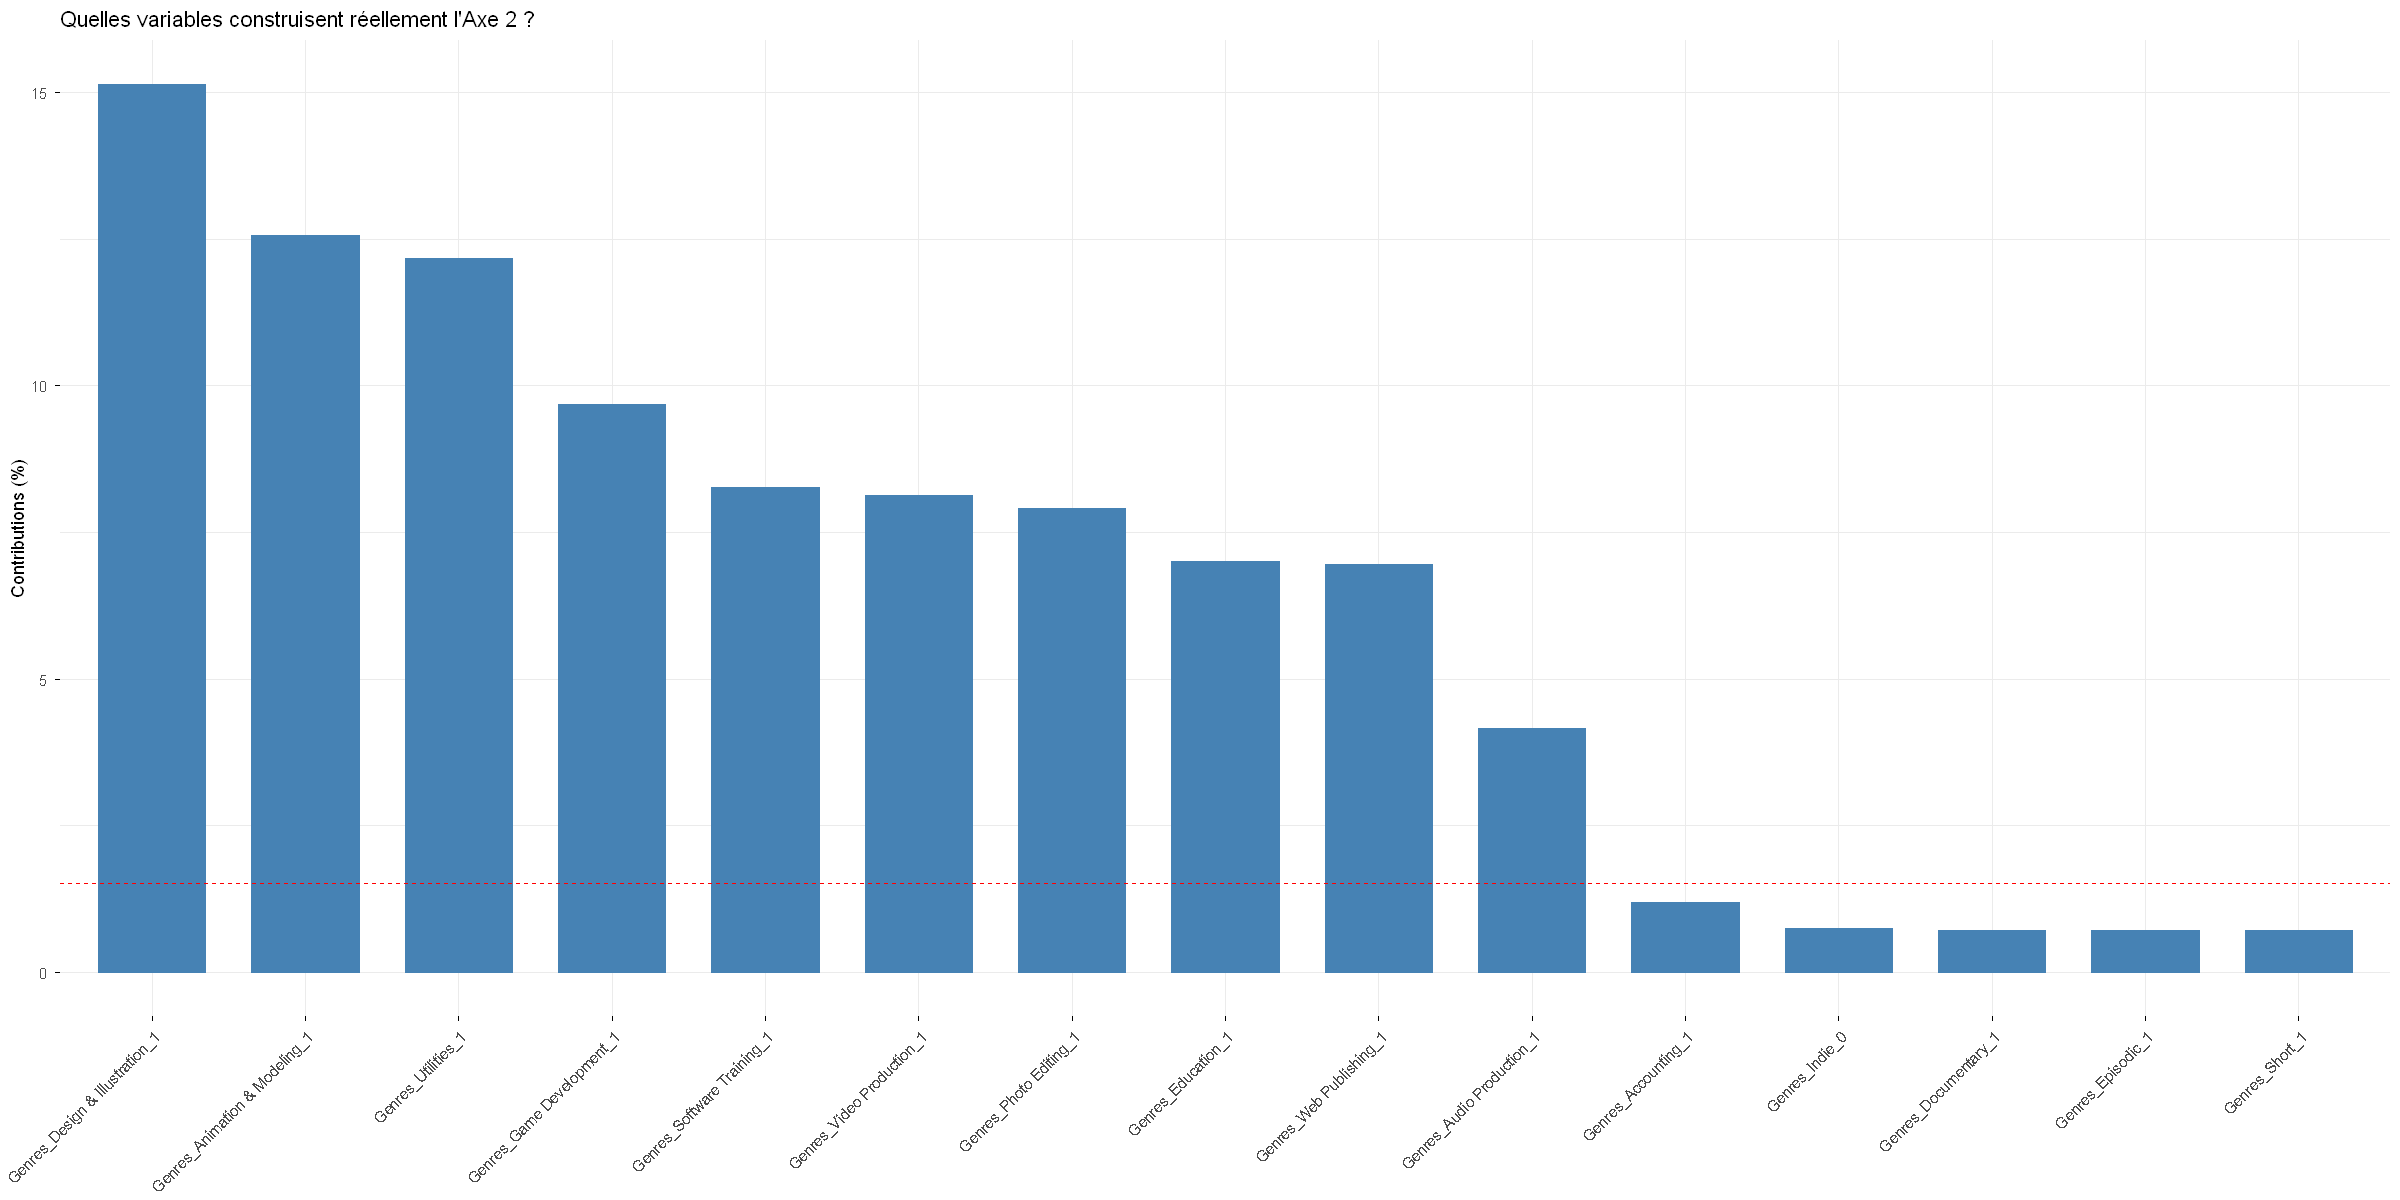

In [199]:

fviz_contrib(res.mca_genres, 
             choice = "var",  
             axes = 2,  
             top=15,
             title = "Quelles variables construisent réellement l'Axe 2 ?")

In [188]:
explication_axe3[[1]]$category

,Estimate,p.value
Genres_Sexual Content=Genres_Sexual Content_1,2.508169985,0.000000e+00
Genres_Violent=Genres_Violent_1,1.627900363,0.000000e+00
Genres_Nudity=Genres_Nudity_1,2.610797126,0.000000e+00
Genres_Gore=Genres_Gore_1,1.957468659,0.000000e+00
Genres_Action=Genres_Action_1,0.021826046,1.223388e-195
Genres_Casual=Genres_Casual_0,0.018130244,1.416138e-138
Genres_Adventure=Genres_Adventure_1,0.017078499,1.793731e-119
Genres_Strategy=Genres_Strategy_0,0.016044624,3.514514e-70
Genres_Simulation=Genres_Simulation_0,0.013814081,2.420879e-55
Genres_Early Access=Genres_Early Access_1,0.015836955,7.817939e-39


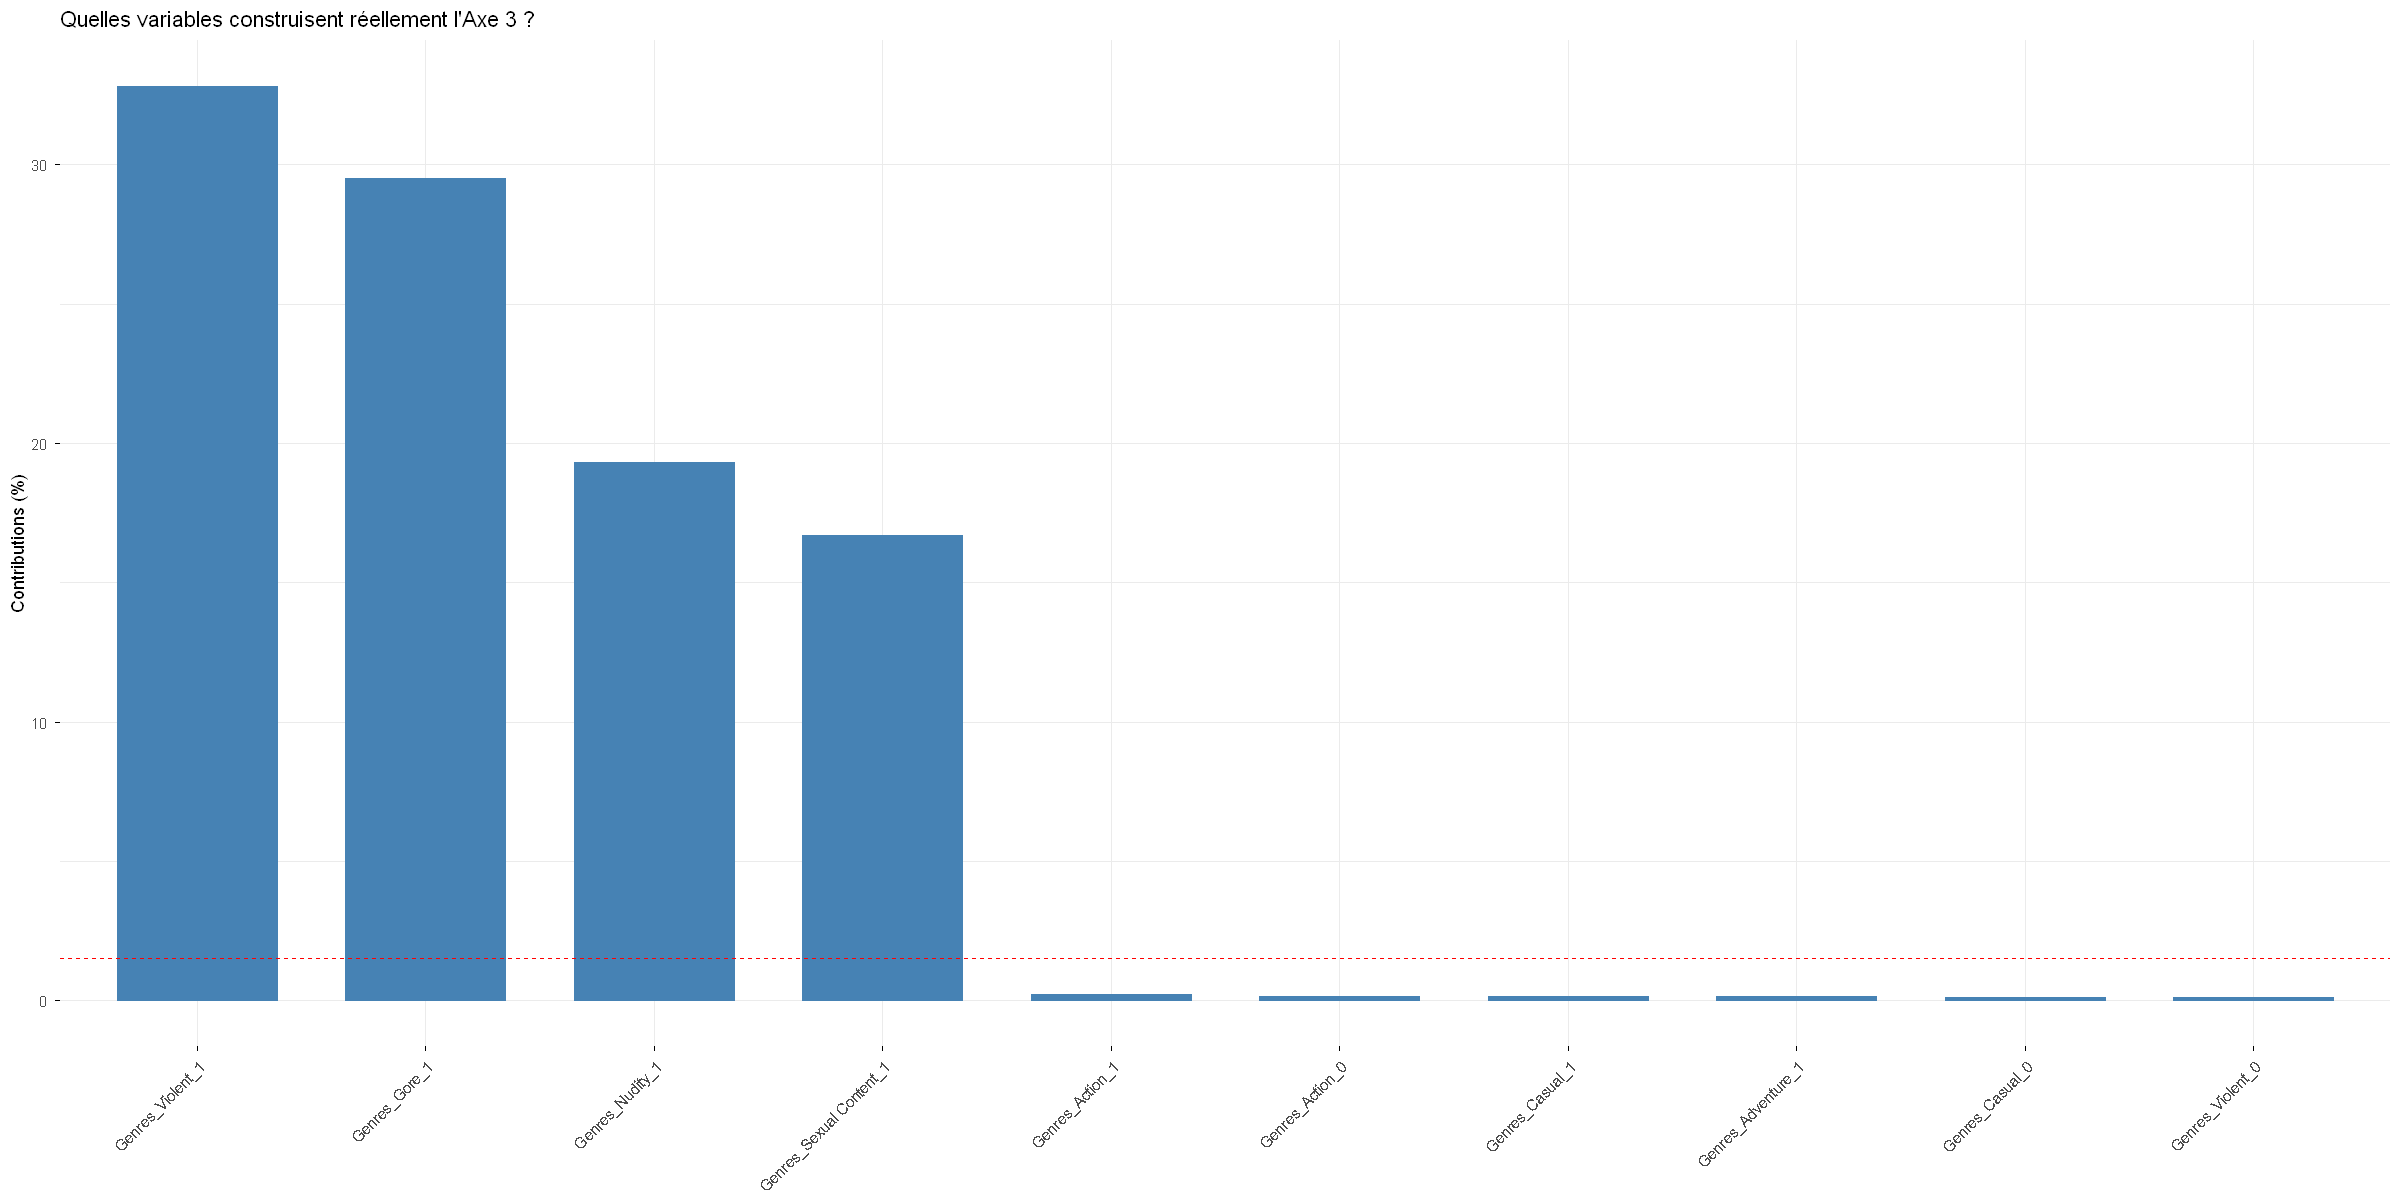

In [200]:

fviz_contrib(res.mca_genres, 
             choice = "var",  
             axes = 3,
             top=10,
             title = "Quelles variables construisent réellement l'Axe 3 ?")

In [190]:
explication_axe4[[1]]$category

,Estimate,p.value
Genres_Sexual Content=Genres_Sexual Content_1,0.440814549,0.000000e+00
Genres_Strategy=Genres_Strategy_1,0.087565987,0.000000e+00
Genres_Sports=Genres_Sports_1,0.265234632,0.000000e+00
Genres_Simulation=Genres_Simulation_1,0.148238279,0.000000e+00
Genres_RPG=Genres_RPG_0,0.064518218,0.000000e+00
Genres_Racing=Genres_Racing_1,0.229681003,0.000000e+00
Genres_Casual=Genres_Casual_1,0.086923308,0.000000e+00
Genres_Adventure=Genres_Adventure_0,0.104805651,0.000000e+00
Genres_Action=Genres_Action_0,0.089074870,0.000000e+00
Genres_Nudity=Genres_Nudity_1,0.403800093,2.902743e-297


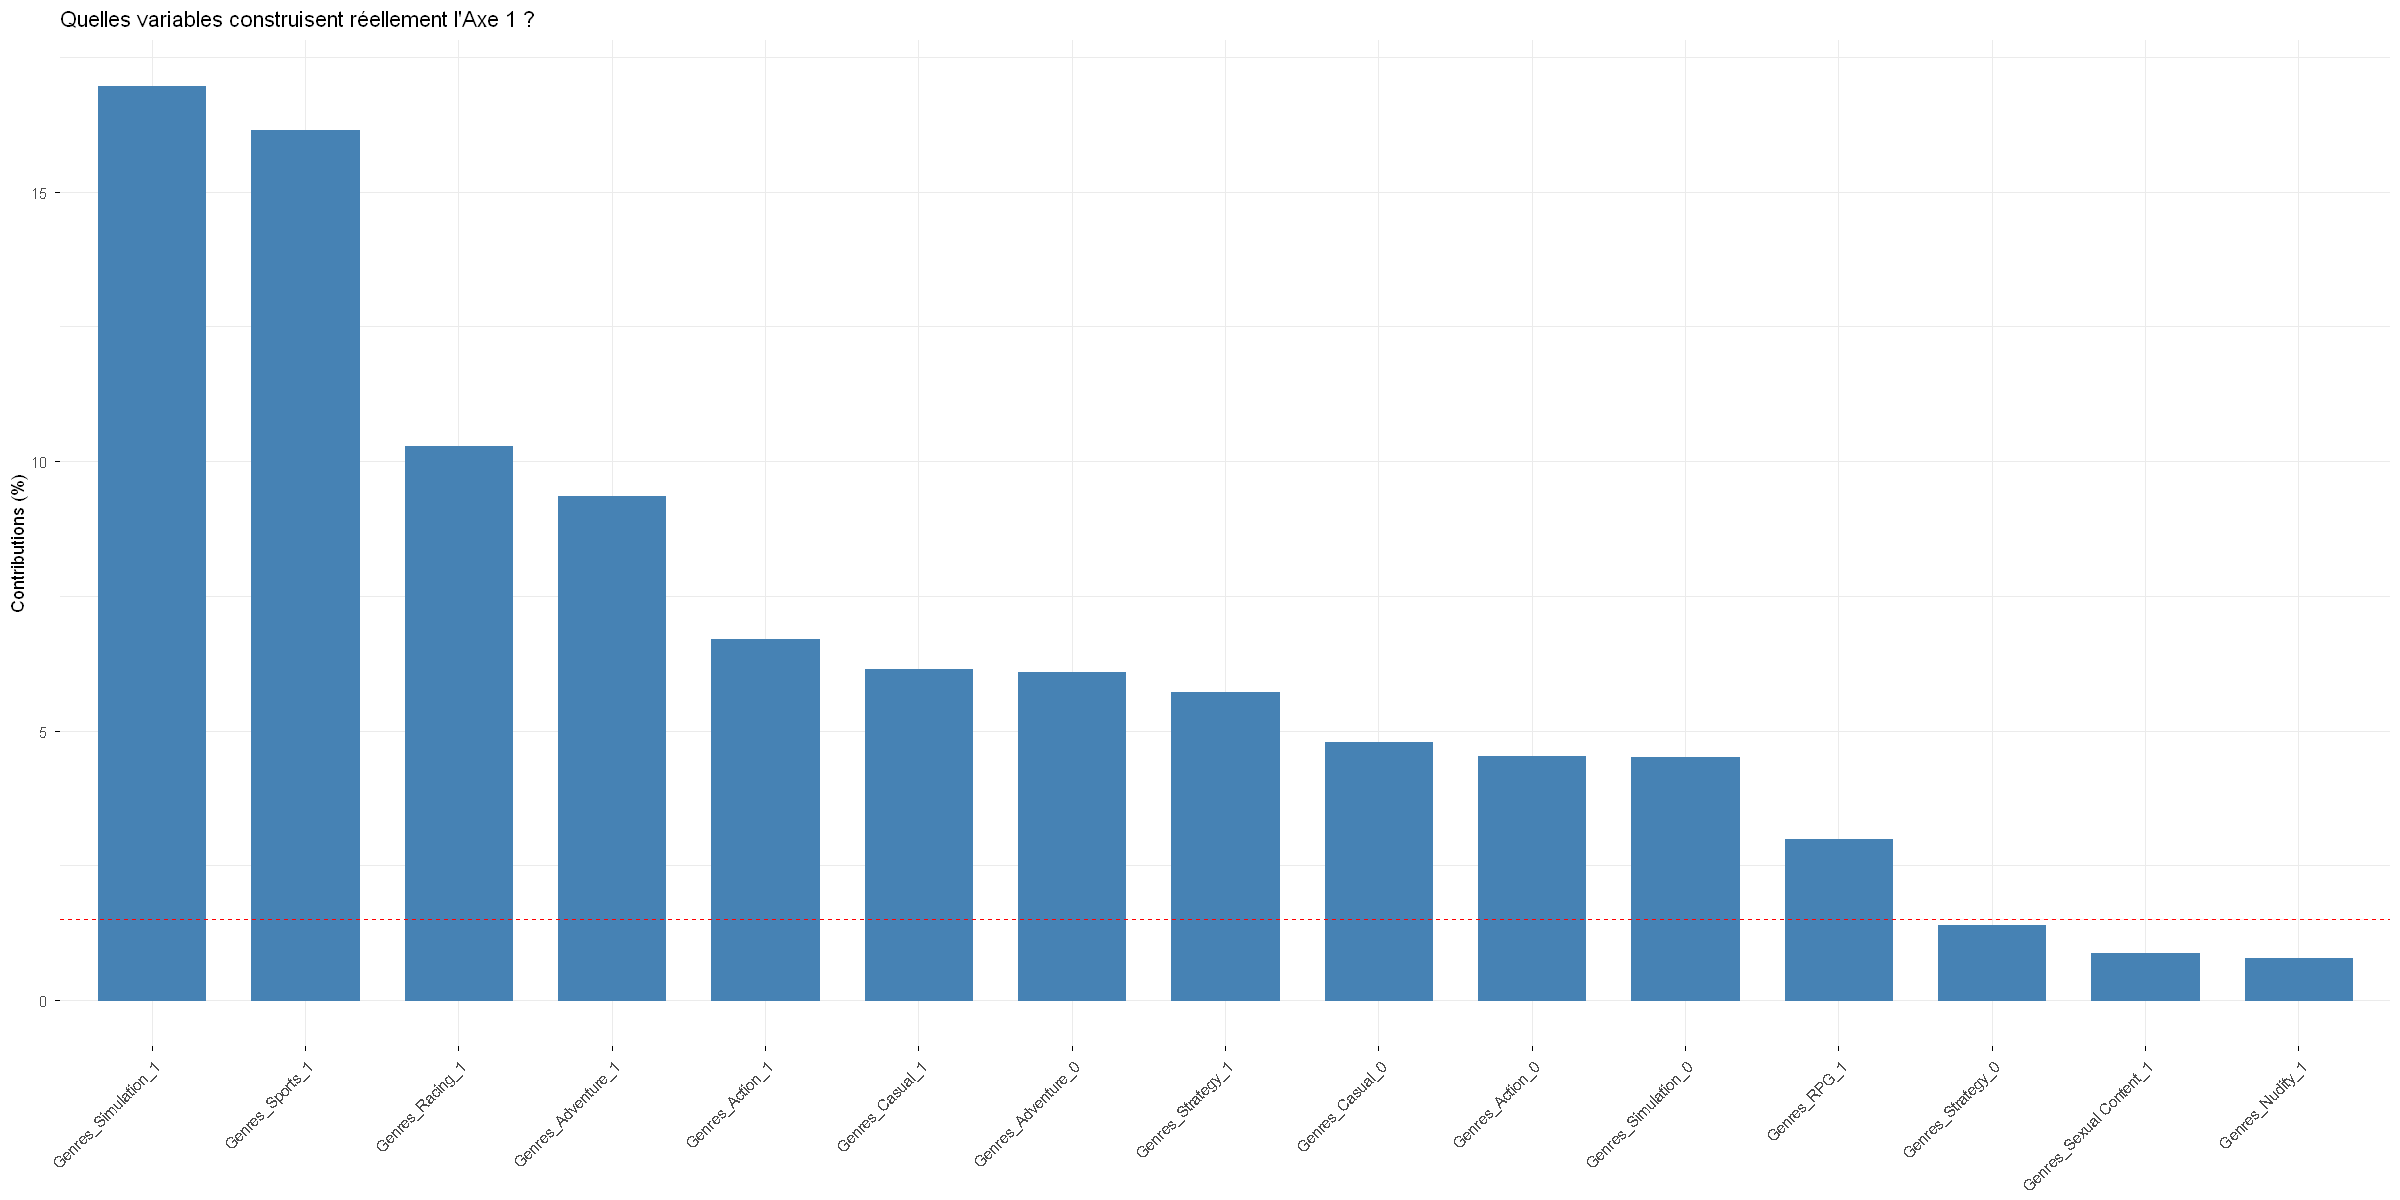

In [202]:

fviz_contrib(res.mca_genres, 
             choice = "var",  
             axes = 4,
             top=15,
             title = "Quelles variables construisent réellement l'Axe 1 ?")

**A refaire!!!!**


**Observations**: 
L'analyse croisée des coordonnées et des contributions statistiques révèle que le genre des jeux vidéo sur Steam sont en parti expliqué par quatre dimensions(d'après nos choix).

**Axe 1** : Utilitaires vs Divertissement
Le premier axe (14,3 % de la variance expliquée) sépare les jeux en deux sur leurs but premier. Il isole les logiciels de création et les utilitaires (Design, Animation, Web Publishing) des véritables jeux vidéo.

**Axe 2**: Contenu violent vs Grand public
Le deuxième axe (7,0 % de la variance expliquée) est presque exclusivement défini par deux genres qui correpondent aux jeux violent. Il sépare le Gore et le Violent du reste des genres. Cet axe met en avant une logique de restriction d'âge plutôt qu'une différence de type de jeux.

**Axe 3** : Simulation vs Narration
Le troisième axe (6,2 % de la variance expliquée) constitue une opposition entre deux styles de genres de jeux qui s'opposent. D'une part, les systèmes fermés (Sports, Course, Simulation) s'appuyant sur la maîtrise et la répétition d'une action ; d'autre part, les jeux de progression (Aventure, Action) centrés sur le développement d'une histoire et de ses personnages

**Axe 4** :
Enfin, le quatrième axe (5,5 %) classe les jeux selon l'investissement du joueur. D'une part, il regroupe les jeux en ligne conçus pour durer et rassembler beaucoup de monde (Multijoueur massif, Free to Play). D'autre part, il isole le genre "Casual", pensé pour de courtes sessions de jeu sans prise de tête.

**Synthèse globale**:
L'ACM nous montre que les jeux sur Steam se divise par étapes logiques : on distingue d'abord l'usage (outil ou jeu), puis le public cible (mature ou non), ensuite la manière de jouer (répétition ou histoire) et enfin le mode de consommation (jeu en ligne intensif ou détente rapide).

# Clustering espace MCA

In [204]:
coord_genres <- res.mca_genres$var$coord

In [205]:
res.hcpc_vars <- HCPC(as.data.frame(coord_genres), nb.clust = -1, graph = FALSE)

In [206]:
res.hcpc_vars$data.clust


,Dim 1,Dim 2,Dim 3,Dim 4,Dim 5,clust
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
Genres_Accounting_0,-4.041373e-03,-0.003238398,-5.340850e-05,5.954117e-05,-2.467346e-04,2
Genres_Accounting_1,1.542228e+01,12.358051670,2.038122e-01,-2.272151e-01,9.415638e-01,3
Genres_Animation & Modeling_0,-9.209820e-03,-0.042260163,-4.516744e-04,9.639800e-05,-1.204604e-03,2
Genres_Animation & Modeling_1,2.201784e+00,10.103102639,1.079814e-01,-2.304579e-02,2.879836e-01,3
Genres_Audio Production_0,-5.899484e-03,-0.016640502,-1.206198e-04,3.716039e-05,8.049520e-04,2
Genres_Audio Production_1,2.996623e+00,8.452487448,6.126844e-02,-1.887550e-02,-4.088727e-01,3
Genres_Design & Illustration_0,-1.060669e-02,-0.051187052,-6.615468e-04,3.343119e-04,-1.520836e-03,2
Genres_Design & Illustration_1,2.083538e+00,10.054990241,1.299517e-01,-6.567096e-02,2.987472e-01,3
Genres_Education_0,-7.948175e-03,-0.031017863,-9.824033e-05,-6.074336e-04,4.771653e-05,2


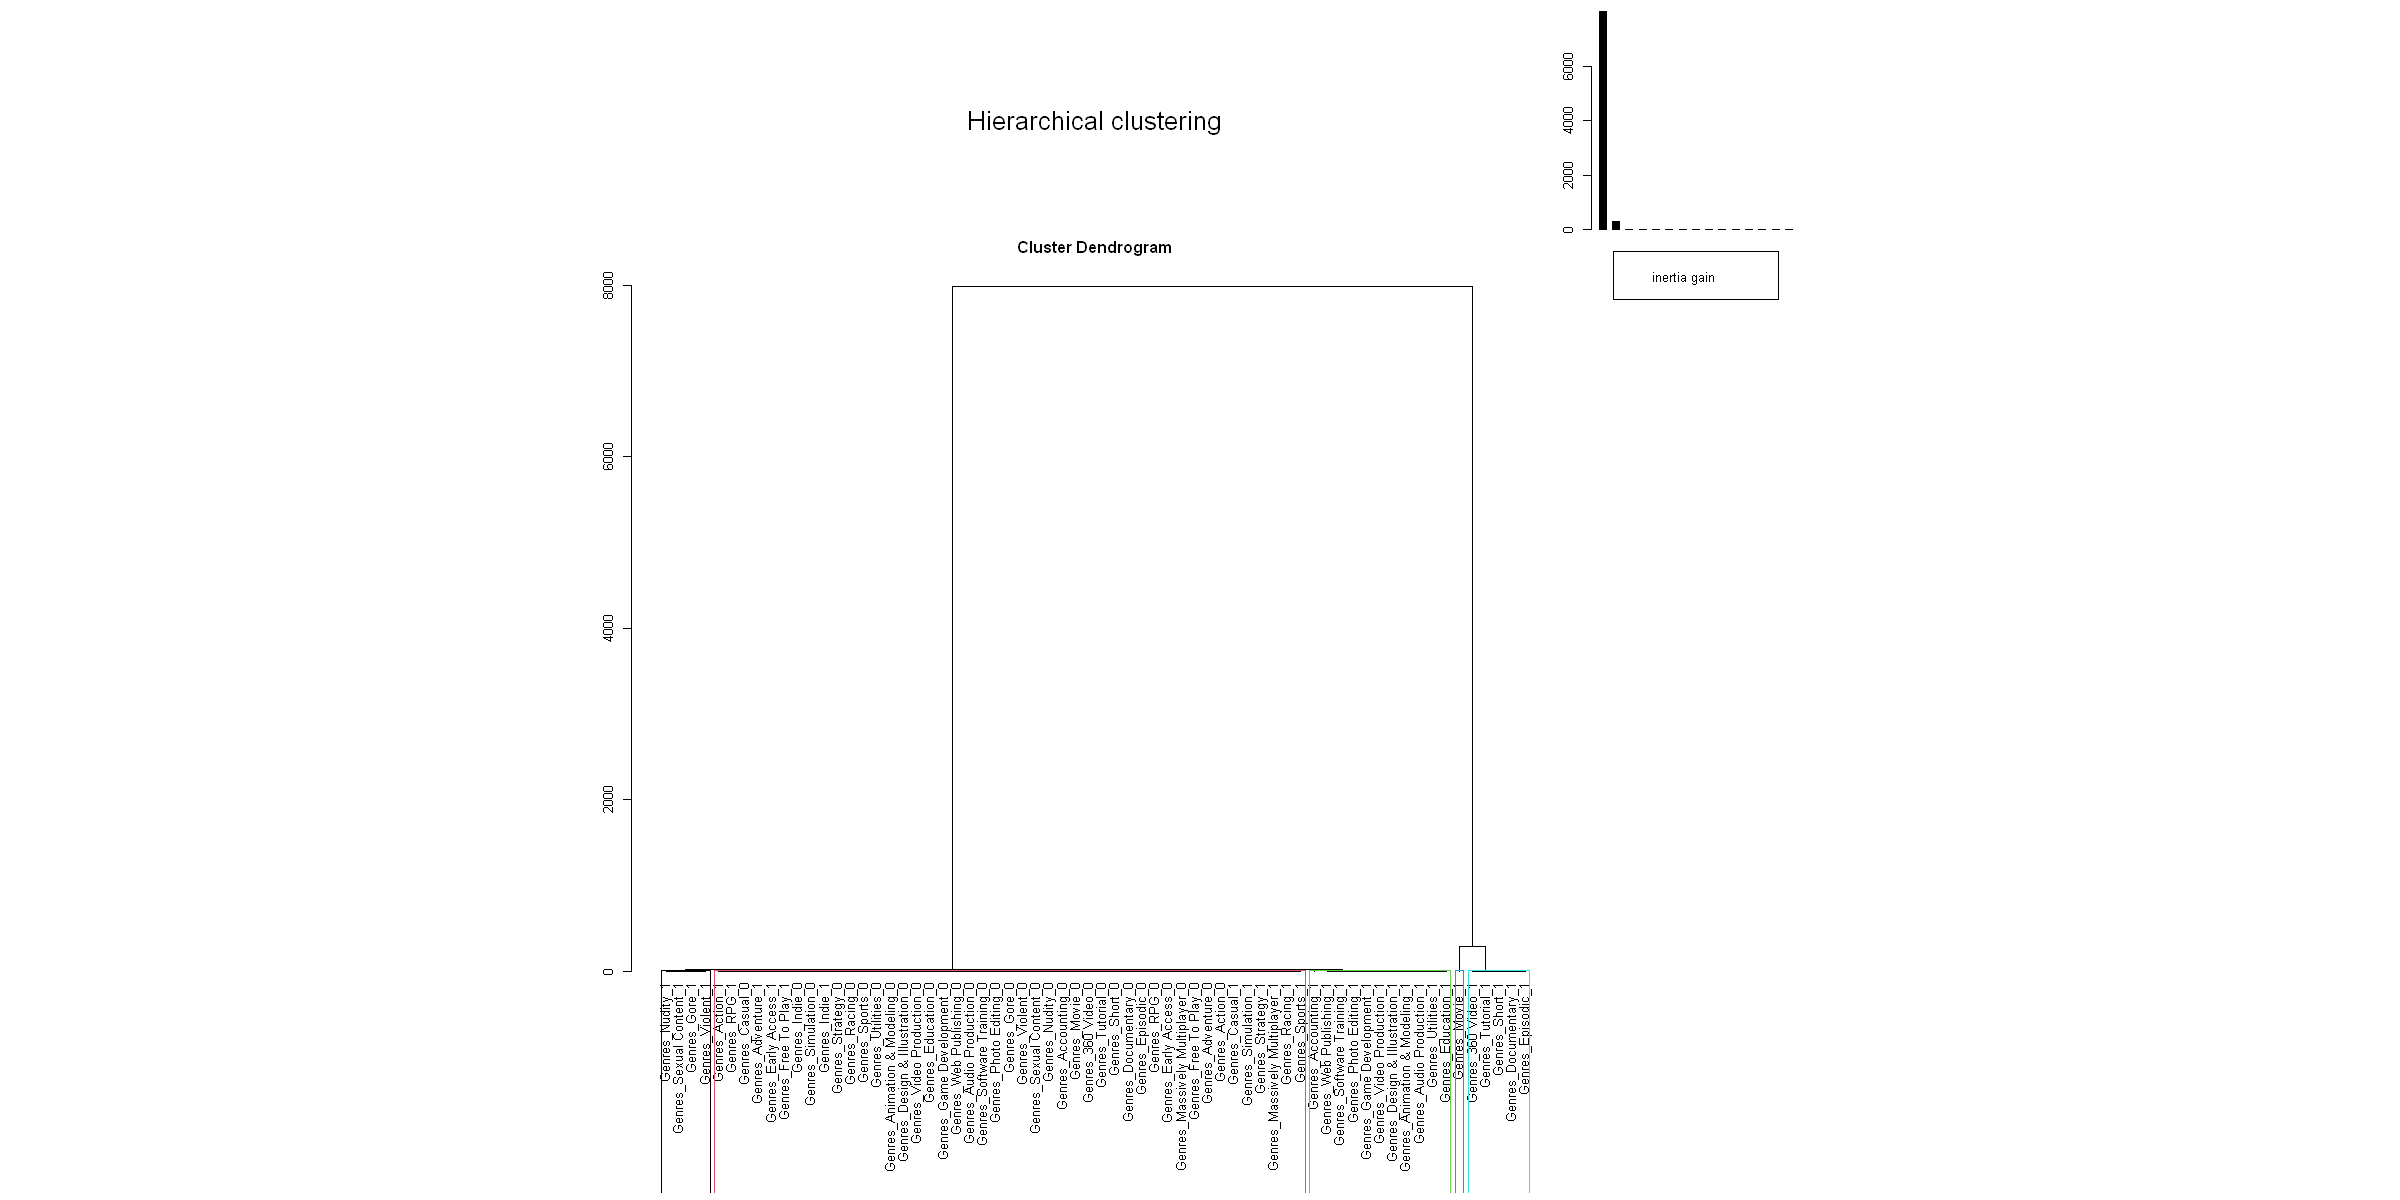

In [207]:
# Affiche l'arbre de classification
plot(res.hcpc_vars, choice = "tree")

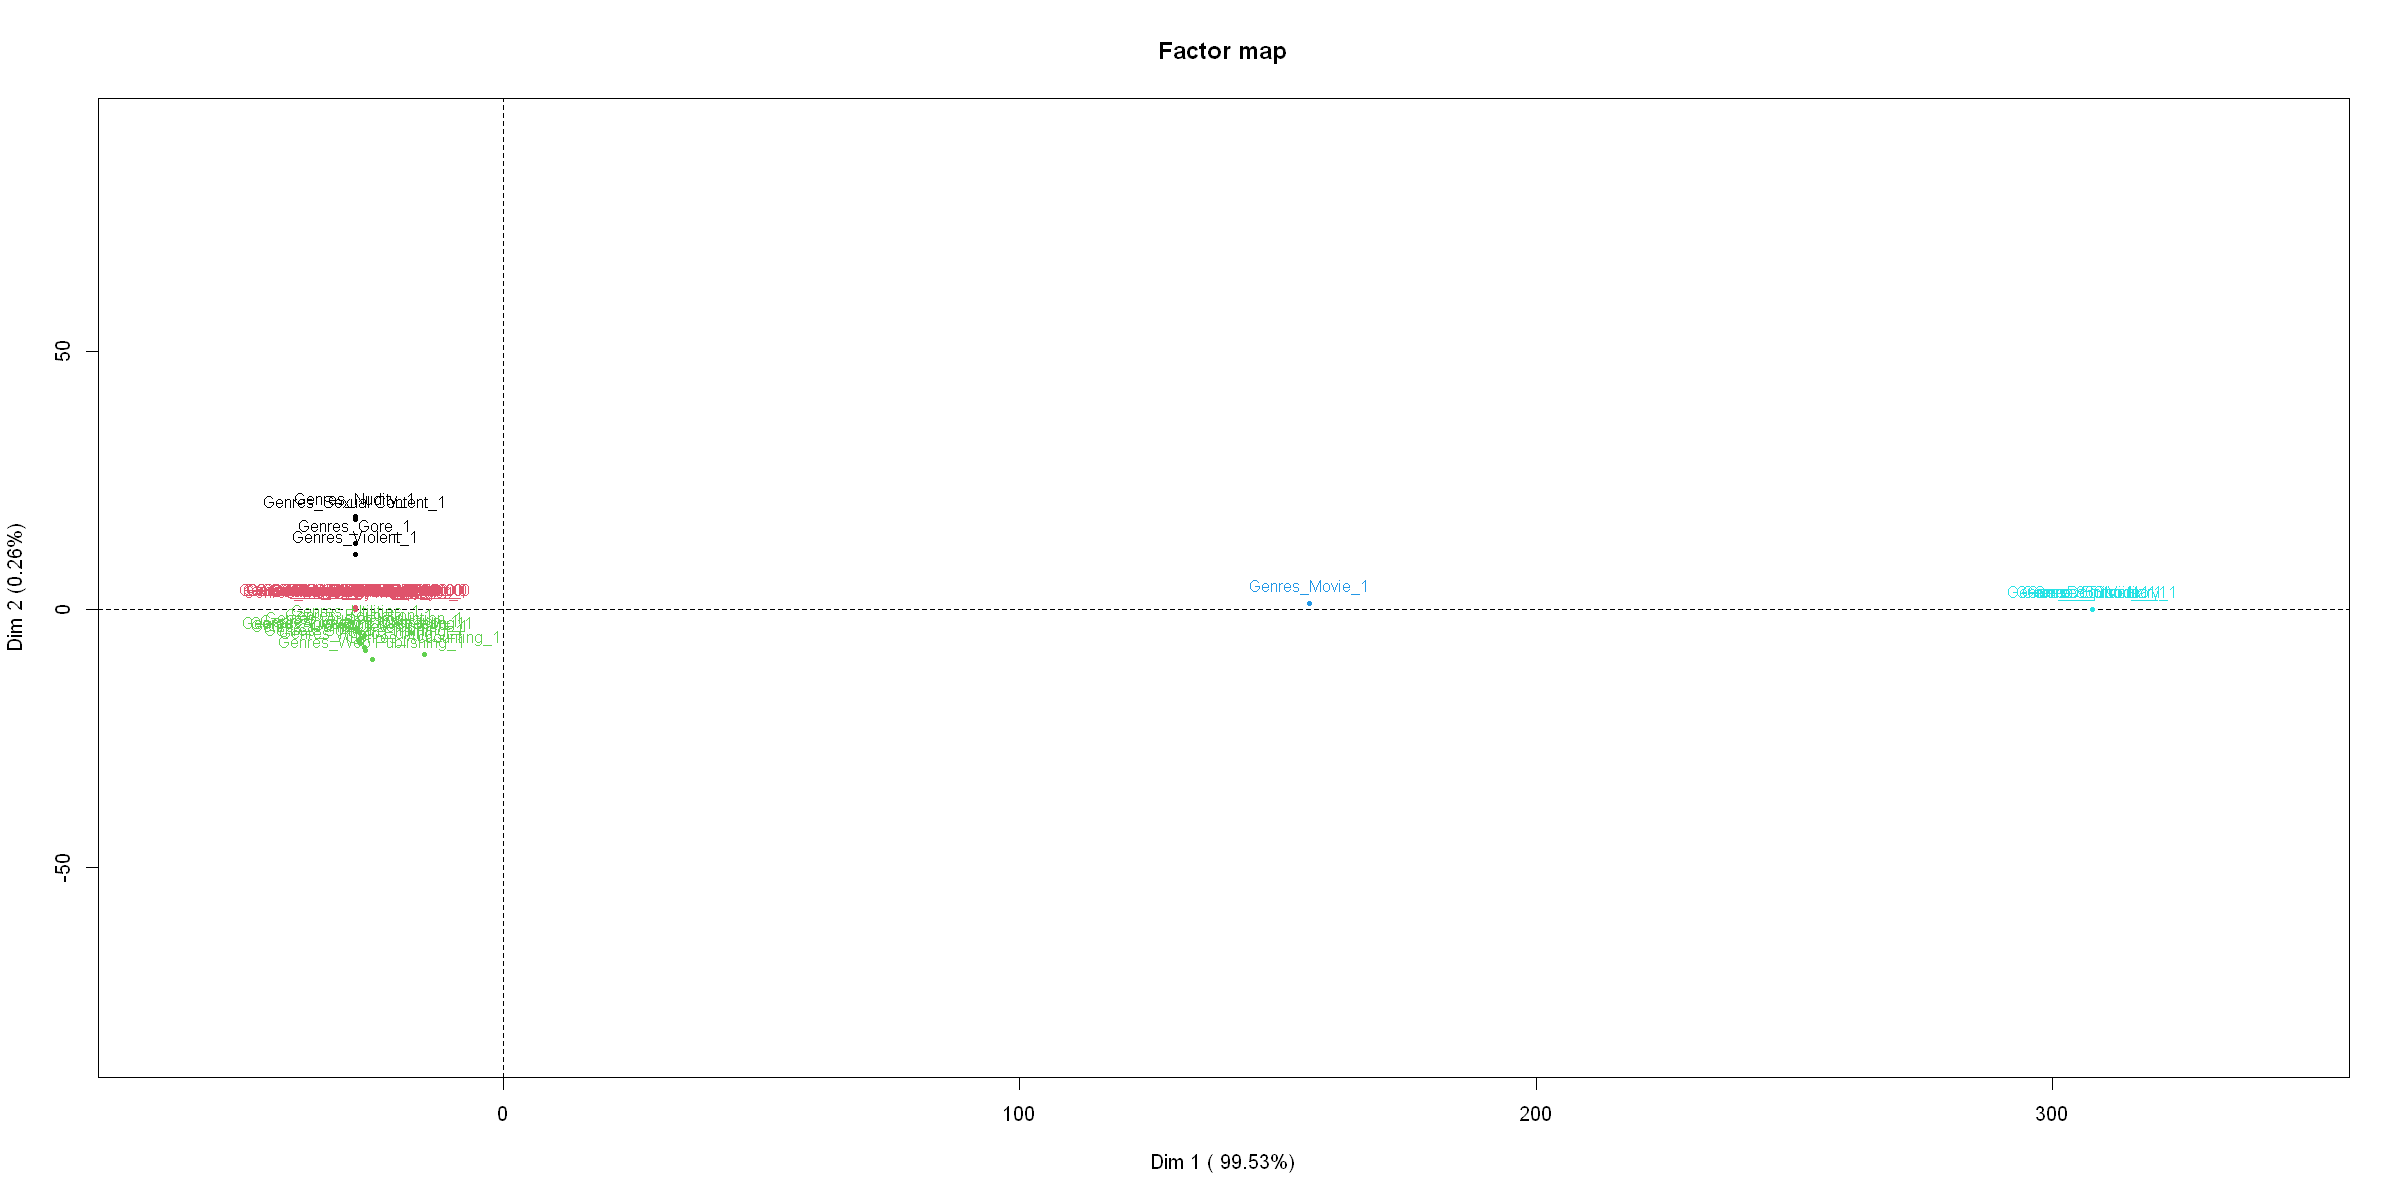

In [196]:
# Affiche les genres sur les deux premiers axes avec les couleurs des clusters
plot(res.hcpc_vars, choice = "map", draw.tree = FALSE)

In [39]:
df_final <- df_one_hot %>%
  mutate(
    # Création du méta-genre "Mature"
    Genre_Mature = if_else(Genres_Gore == "1" |
                           Genres_Nudity == "1"|
                           `Genres_Sexual Content` == "1"|
                           Genres_Violent == "1", "1", "0"),
      
     Genre_Video = if_else(Genres_Episodic == "1" |
                           Genres_Documentary == "1"|
                           Genres_Short == "1"|
                           Genres_Movie == "1"|
                           `Genres_360 Video` == "1"|
                           Genres_Tutorial == "1", "1", "0"),
    
    # Création du méta-genre "Logiciels/Outils" (selon ton cluster de droite)
    Genre_Outils = if_else( `Genres_Video Production` == "1" | 
                           `Genres_Design & Illustration` =="1"|
                           `Genres_Animation & Modeling` == "1" |
                           `Genres_Game Development` == "1"|
                           `Genres_Audio Production` == "1"|
                           `Genres_Photo Editing` == "1"|
                          `Genres_Software Training` == "1"|
                           Genres_Education == "1" |
                           Genres_Utilities == "1" |
                           `Genres_Web Publishing` == "1", "1", "0")
  ) %>%

  mutate(Genre_Mature = as.factor(Genre_Mature),
         Genre_Video = as.factor(Genre_Video),
        Genre_Outils = as.factor(Genre_Outils))

In [40]:
cols_to_remove <- c("Genres_Gore", "Genres_Violent", "Genres_Video Production","Genres_Sexual Content","Genres_Nudity", 
                    "Genres_Design & Illustration", "Genres_Animation & Modeling","Genres_Game Development", 
                    "Genres_Audio Production","Genres_Photo Editing", "Genres_Software Training", 
                    "Genres_Education", "Genres_Utilities", "Genres_Web Publishing","Genres_Episodic",
                   "Genres_Documentary","Genres_Short","Genres_Movie","Genres_360 Video","Genres_Tutorial")

df_mca_new <- df_final %>%
  select(-all_of(cols_to_remove))
summary(df_mca_new)

     Name              Release.date    Estimated.owners  Required.age   
 Length:114513      2025-2026:21812   0-20K    :75337   0      :113288  
 Class :character   2024     :18104   0        :13649   17     :   782  
 Mode  :character   2023     :13337   20K-50K  :11395   13     :   175  
                    2022     :11403   50K-100K : 5349   18     :   164  
                    2021     :10441   100K-200K: 3450   16     :    31  
                    2020     : 8746   200K-500K: 2845   10     :    26  
                    (Other)  :30670   (Other)  : 2488   (Other):    47  
    Discount       Windows          Mac          Linux       Metacritic.score
 Min.   :  0.00   False:    44   False:93260   False:98841   Min.   : 0.000  
 1st Qu.:  0.00   True :114469   True :21253   True :15672   1st Qu.: 0.000  
 Median :  0.00                                              Median : 0.000  
 Mean   : 19.62                                              Mean   : 2.703  
 3rd Qu.: 45.00           

##  MCA avec nouveaux jeux de donnée

In [327]:
df_mca_ready <- df_mca_new
df_mca_ready[,-c(1:28)] <- lapply(df_mca_new[,-c(1:28)], as.factor)

data_quali_new=df_mca_ready%>%
  select(where(is.factor)) 

In [328]:
# data_quali_new<-data_quali_new %>%
#     select(-Genre_Video,-Genres_Accounting)

summary(data_quali_new)

    Release.date    Estimated.owners  Required.age     Windows      
 2025-2026:21812   0-20K    :75337   0      :113288   False:    44  
 2024     :18104   0        :13649   17     :   782   True :114469  
 2023     :13337   20K-50K  :11395   13     :   175                 
 2022     :11403   50K-100K : 5349   18     :   164                 
 2021     :10441   100K-200K: 3450   16     :    31                 
 2020     : 8746   200K-500K: 2845   10     :    26                 
 (Other)  :30670   (Other)  : 2488   (Other):    47                 
    Mac          Linux       Genres_Accounting Genres_Early Access
 False:93260   False:98841   0:114483          0:103422           
 True :21253   True :15672   1:    30          1: 11091           
                                                                  
                                                                  
                                                                  
                                              

In [364]:
res.mca_filtre=MCA(data_quali_new,quali.sup=c(4,7:22), graph = FALSE)
print(res.mca_filtre)

**Results of the Multiple Correspondence Analysis (MCA)**
The analysis was performed on 114513 individuals, described by 22 variables
*The results are available in the following objects:

   name                description                                          
1  "$eig"              "eigenvalues"                                        
2  "$var"              "results for the variables"                          
3  "$var$coord"        "coord. of the categories"                           
4  "$var$cos2"         "cos2 for the categories"                            
5  "$var$contrib"      "contributions of the categories"                    
6  "$var$v.test"       "v-test for the categories"                          
7  "$var$eta2"         "coord. of variables"                                
8  "$ind"              "results for the individuals"                        
9  "$ind$coord"        "coord. for the individuals"                         
10 "$ind$cos2"         "cos2 for the indiv

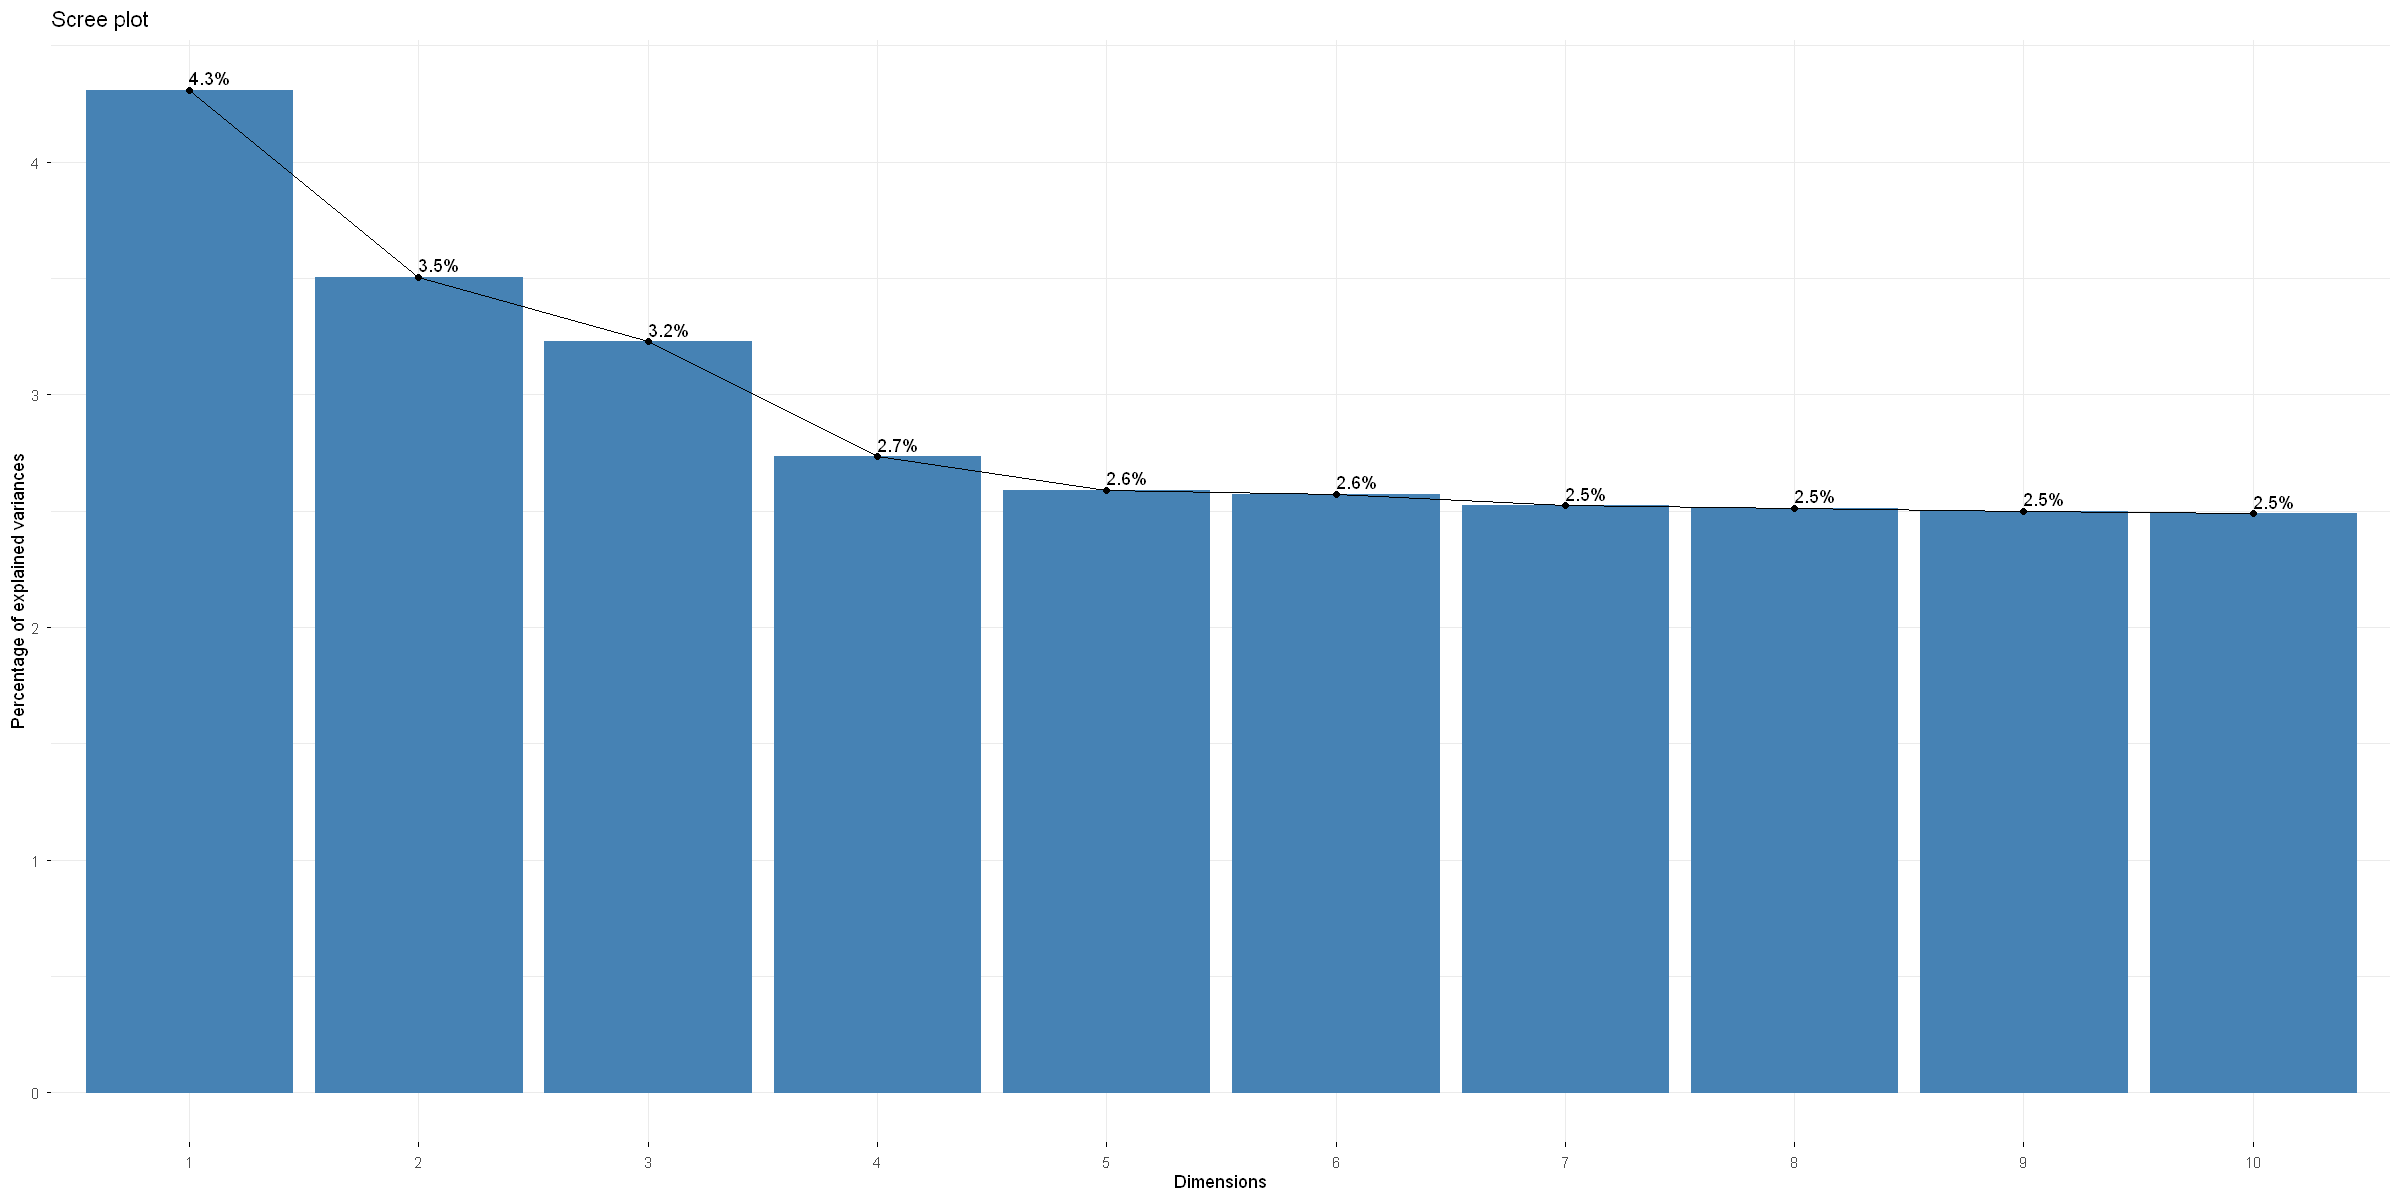

In [365]:
fviz_screeplot(res.mca_filtre, addlabels=TRUE)

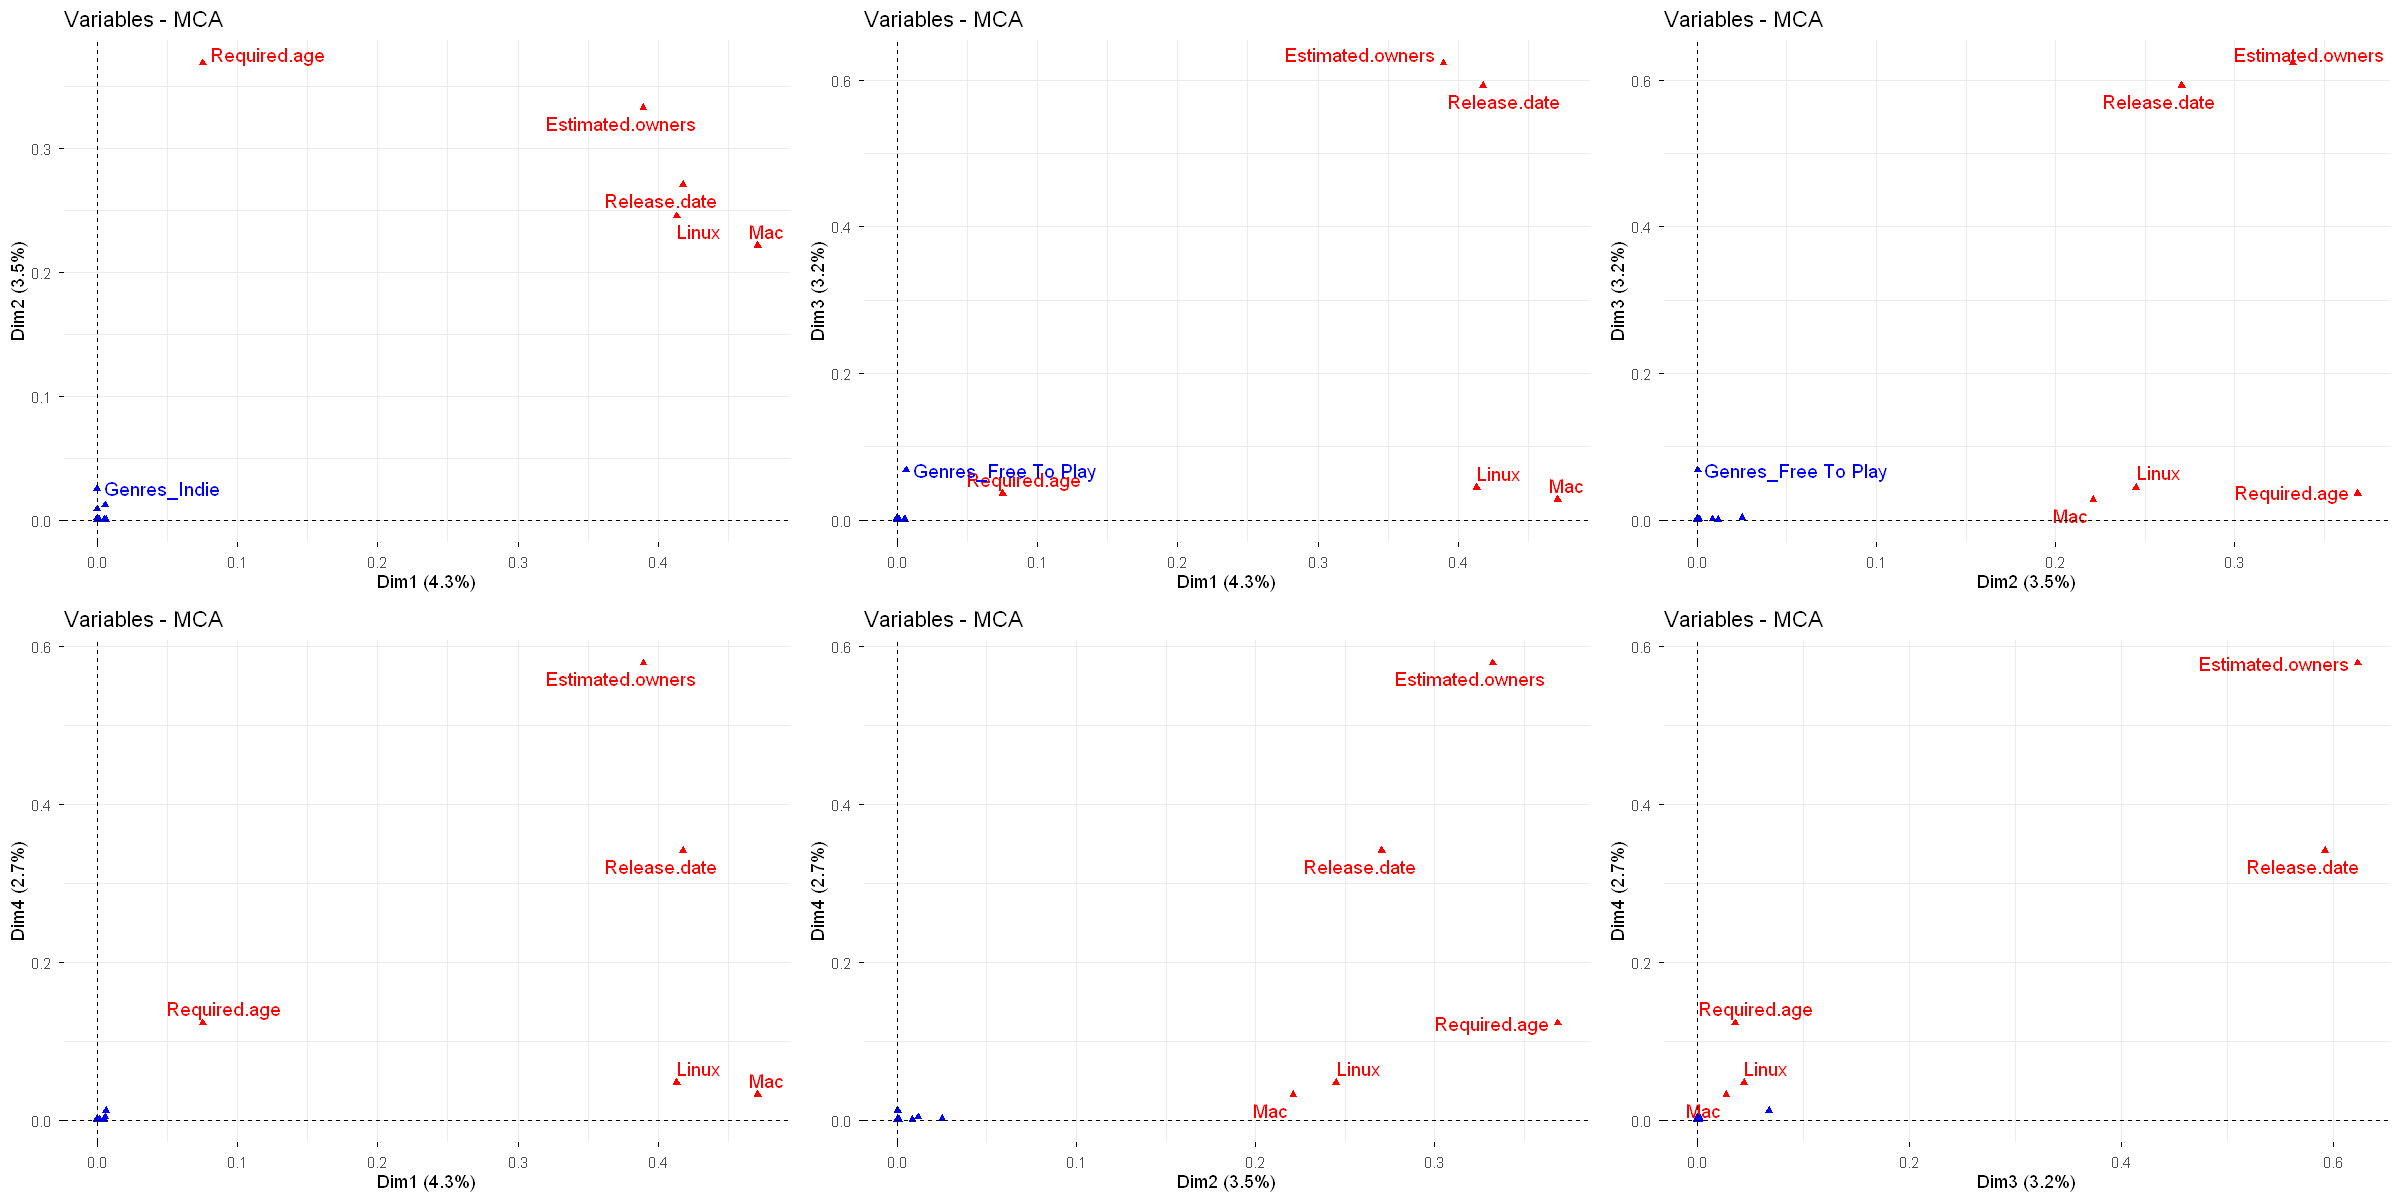

In [366]:
options(repr.plot.width = 20, repr.plot.height = 10)
g1=fviz_mca_var(res.mca_filtre,axes = c(1,2),repel=TRUE,choice = "mca.cor")
g2=fviz_mca_var(res.mca_filtre,axes = c(1,3),repel=TRUE,choice = "mca.cor")
g3=fviz_mca_var(res.mca_filtre,axes = c(2,3),repel=T,choice = "mca.cor")
g4=fviz_mca_var(res.mca_filtre,axes = c(1,4),repel=TRUE,choice = "mca.cor")
g5=fviz_mca_var(res.mca_filtre,axes = c(2,4),repel=TRUE,choice = "mca.cor")
g6=fviz_mca_var(res.mca_filtre,axes = c(3,4),repel=TRUE,choice = "mca.cor")

grid.arrange(g1,g2,g3,g4,g5,g6,ncol=3)

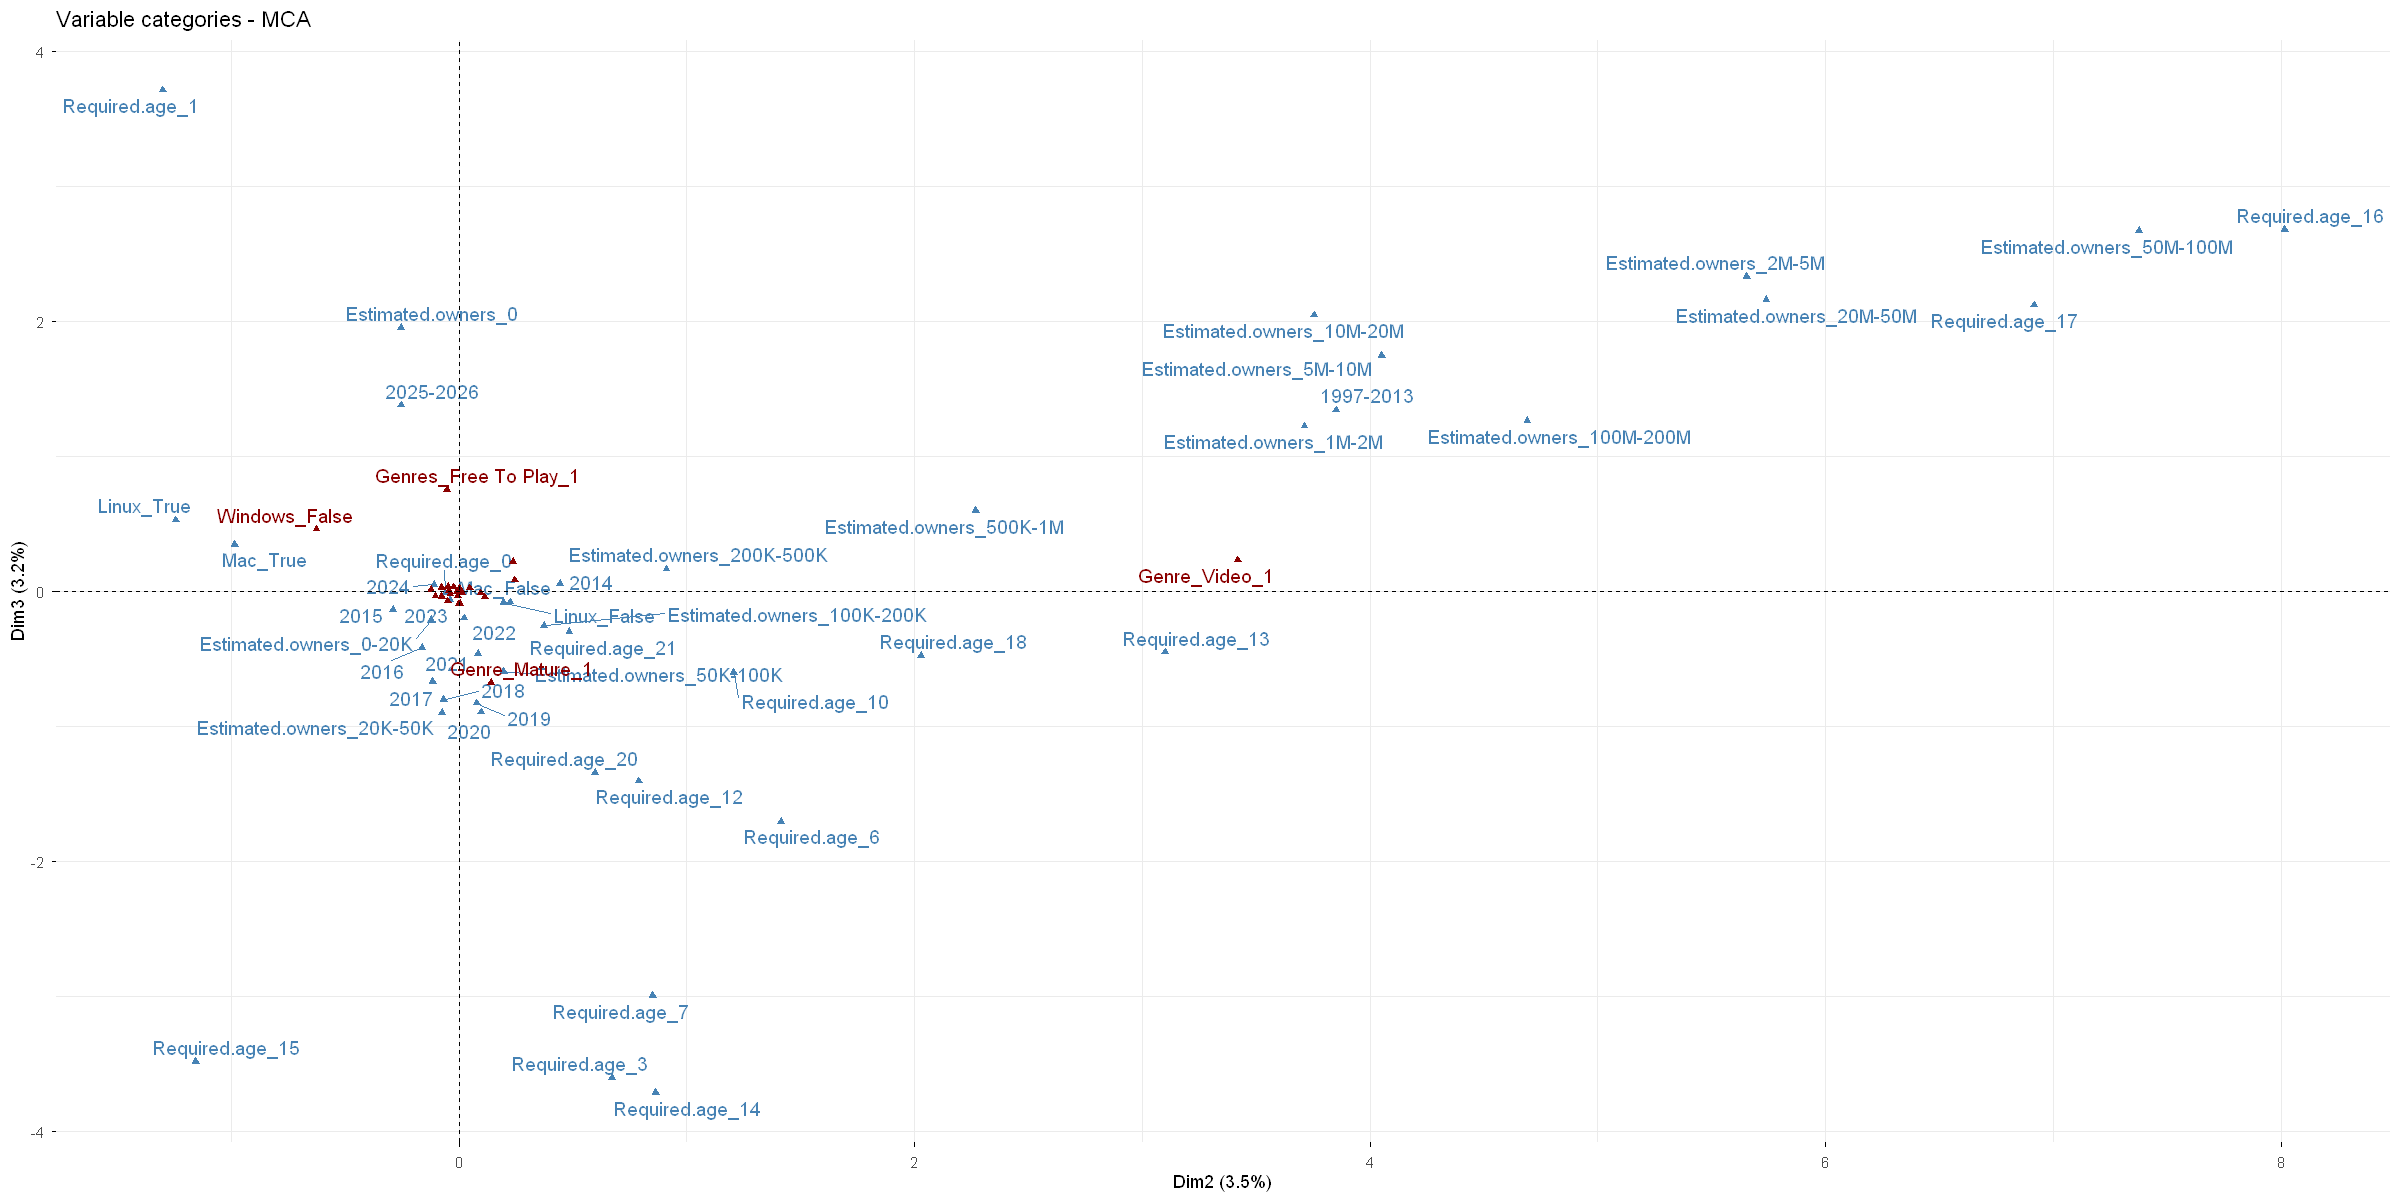

In [371]:
fviz_mca_var(res.mca_filtre,               # <--- C'EST LA CLÉ
             repel = TRUE,
             axes=c(2,3),
             col.var = "steelblue",       # Tes variables de contexte (Age, Owners...)
             col.quali.sup = "darkred")

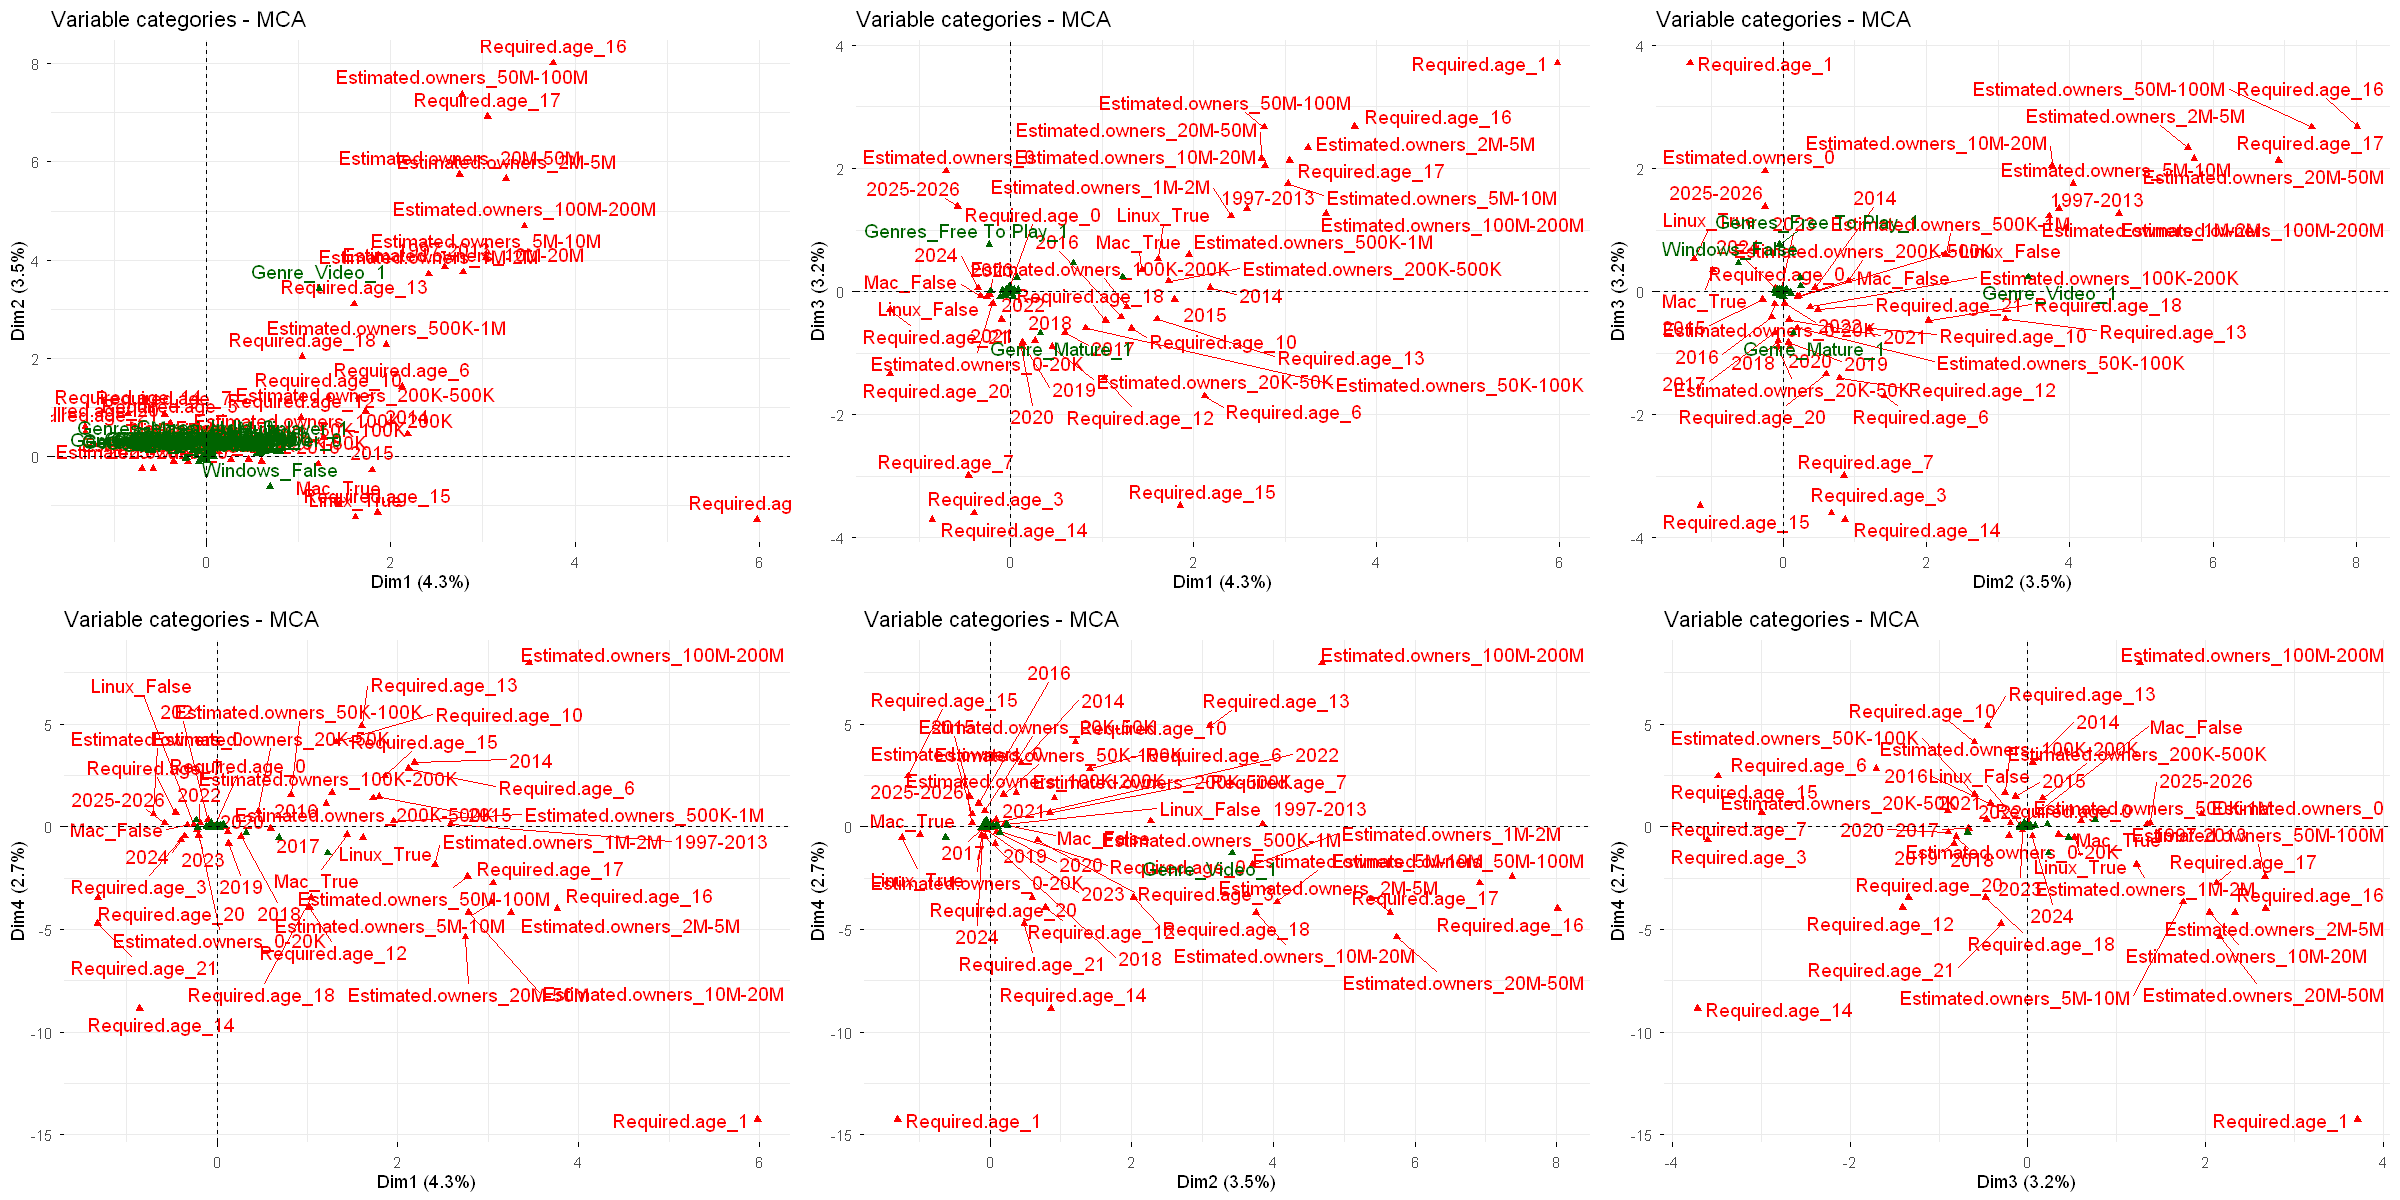

In [368]:
options(repr.plot.width = 20, repr.plot.height = 10)
g1=fviz_mca_var(res.mca_filtre,axes = c(1,2),repel=F)
g2=fviz_mca_var(res.mca_filtre,axes = c(1,3),repel=TRUE)
g3=fviz_mca_var(res.mca_filtre,axes = c(2,3),repel=T)
g4=fviz_mca_var(res.mca_filtre,axes = c(1,4),repel=TRUE)
g5=fviz_mca_var(res.mca_filtre,axes = c(2,4),repel=TRUE)
g6=fviz_mca_var(res.mca_filtre,axes = c(3,4),repel=TRUE)

grid.arrange(g1,g2,g3,g4,g5,g6,ncol=3)

In [342]:
# Description automatique des axes
res.desc <- dimdesc(res.mca_filtre, axes = c(1,2,3,4,5))

# Voir ce qui définit l'axe 1 (le plus fort)
print(res.desc$`Dim 1`$quali)

                                       R2       p.value
Release.date                 4.177193e-01  0.000000e+00
Estimated.owners             3.893805e-01  0.000000e+00
Required.age                 7.521038e-02  0.000000e+00
Mac                          4.708535e-01  0.000000e+00
Linux                        4.131373e-01  0.000000e+00
Genres_Free To Play          6.349486e-03 1.209118e-160
Genres_Casual                5.806871e-03 4.751604e-147
Genres_Early Access          5.000363e-03 7.457323e-127
Genres_Strategy              1.567963e-03  5.666392e-41
Genre_Mature                 4.848226e-04  9.200874e-14
Genres_Simulation            4.614322e-04  3.598302e-13
Genres_RPG                   3.720332e-04  6.682940e-11
Genre_Outils                 2.131813e-04  7.769798e-07
Windows                      1.809664e-04  5.303521e-06
Genres_Sports                1.178759e-04  2.387132e-04
Genres_Massively Multiplayer 1.144568e-04  2.941551e-04
Genres_Adventure             1.054983e-04  5.092

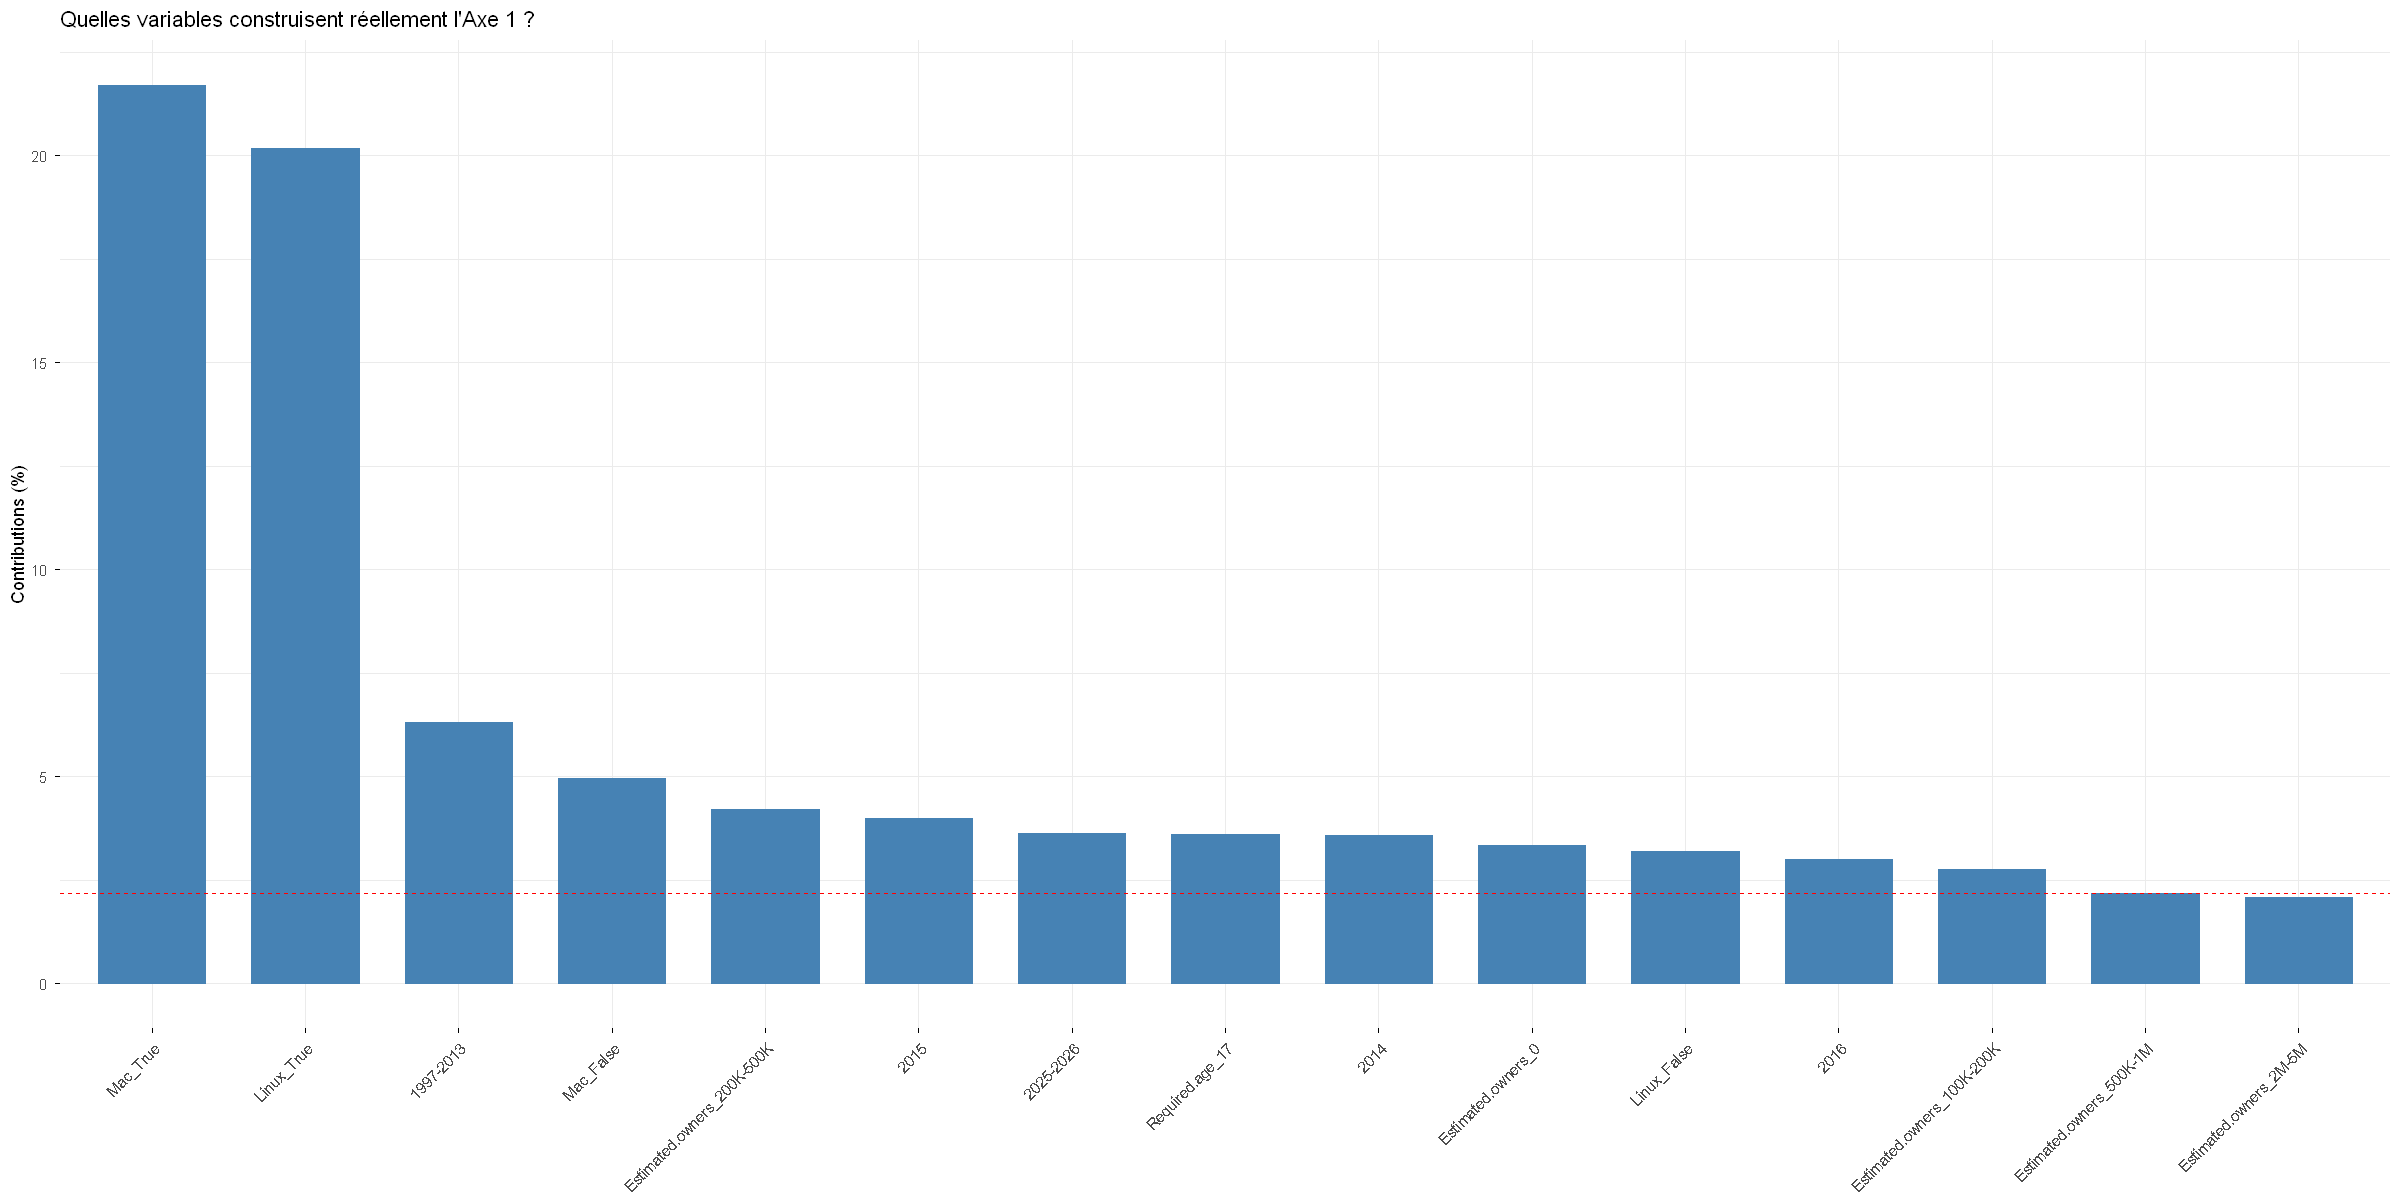

In [343]:

fviz_contrib(res.mca_filtre, 
             choice = "var",  
             axes = 1,
             top=15,
             title = "Quelles variables construisent réellement l'Axe 1 ?")

In [344]:
print(res.desc$`Dim 2`$quali)

                                       R2       p.value
Release.date                 2.702770e-01  0.000000e+00
Estimated.owners             3.323303e-01  0.000000e+00
Required.age                 3.685916e-01  0.000000e+00
Mac                          2.211475e-01  0.000000e+00
Linux                        2.450158e-01  0.000000e+00
Genres_Indie                 2.531401e-02  0.000000e+00
Genres_Casual                1.178158e-02 4.357807e-297
Genres_Action                8.544562e-03 1.062620e-215
Genres_Massively Multiplayer 1.281968e-03  8.281959e-34
Genres_Simulation            5.936374e-04  1.636697e-16
Genres_RPG                   4.968935e-04  4.553698e-14
Genres_Free To Play          3.099819e-04  2.548293e-09
Genre_Video                  2.042389e-04  1.322721e-06
Genres_Early Access          1.982701e-04  1.887524e-06
Windows                      1.505056e-04  3.301613e-05
Genres_Strategy              1.332476e-04  9.371596e-05
Genres_Sports                1.066654e-04  4.740

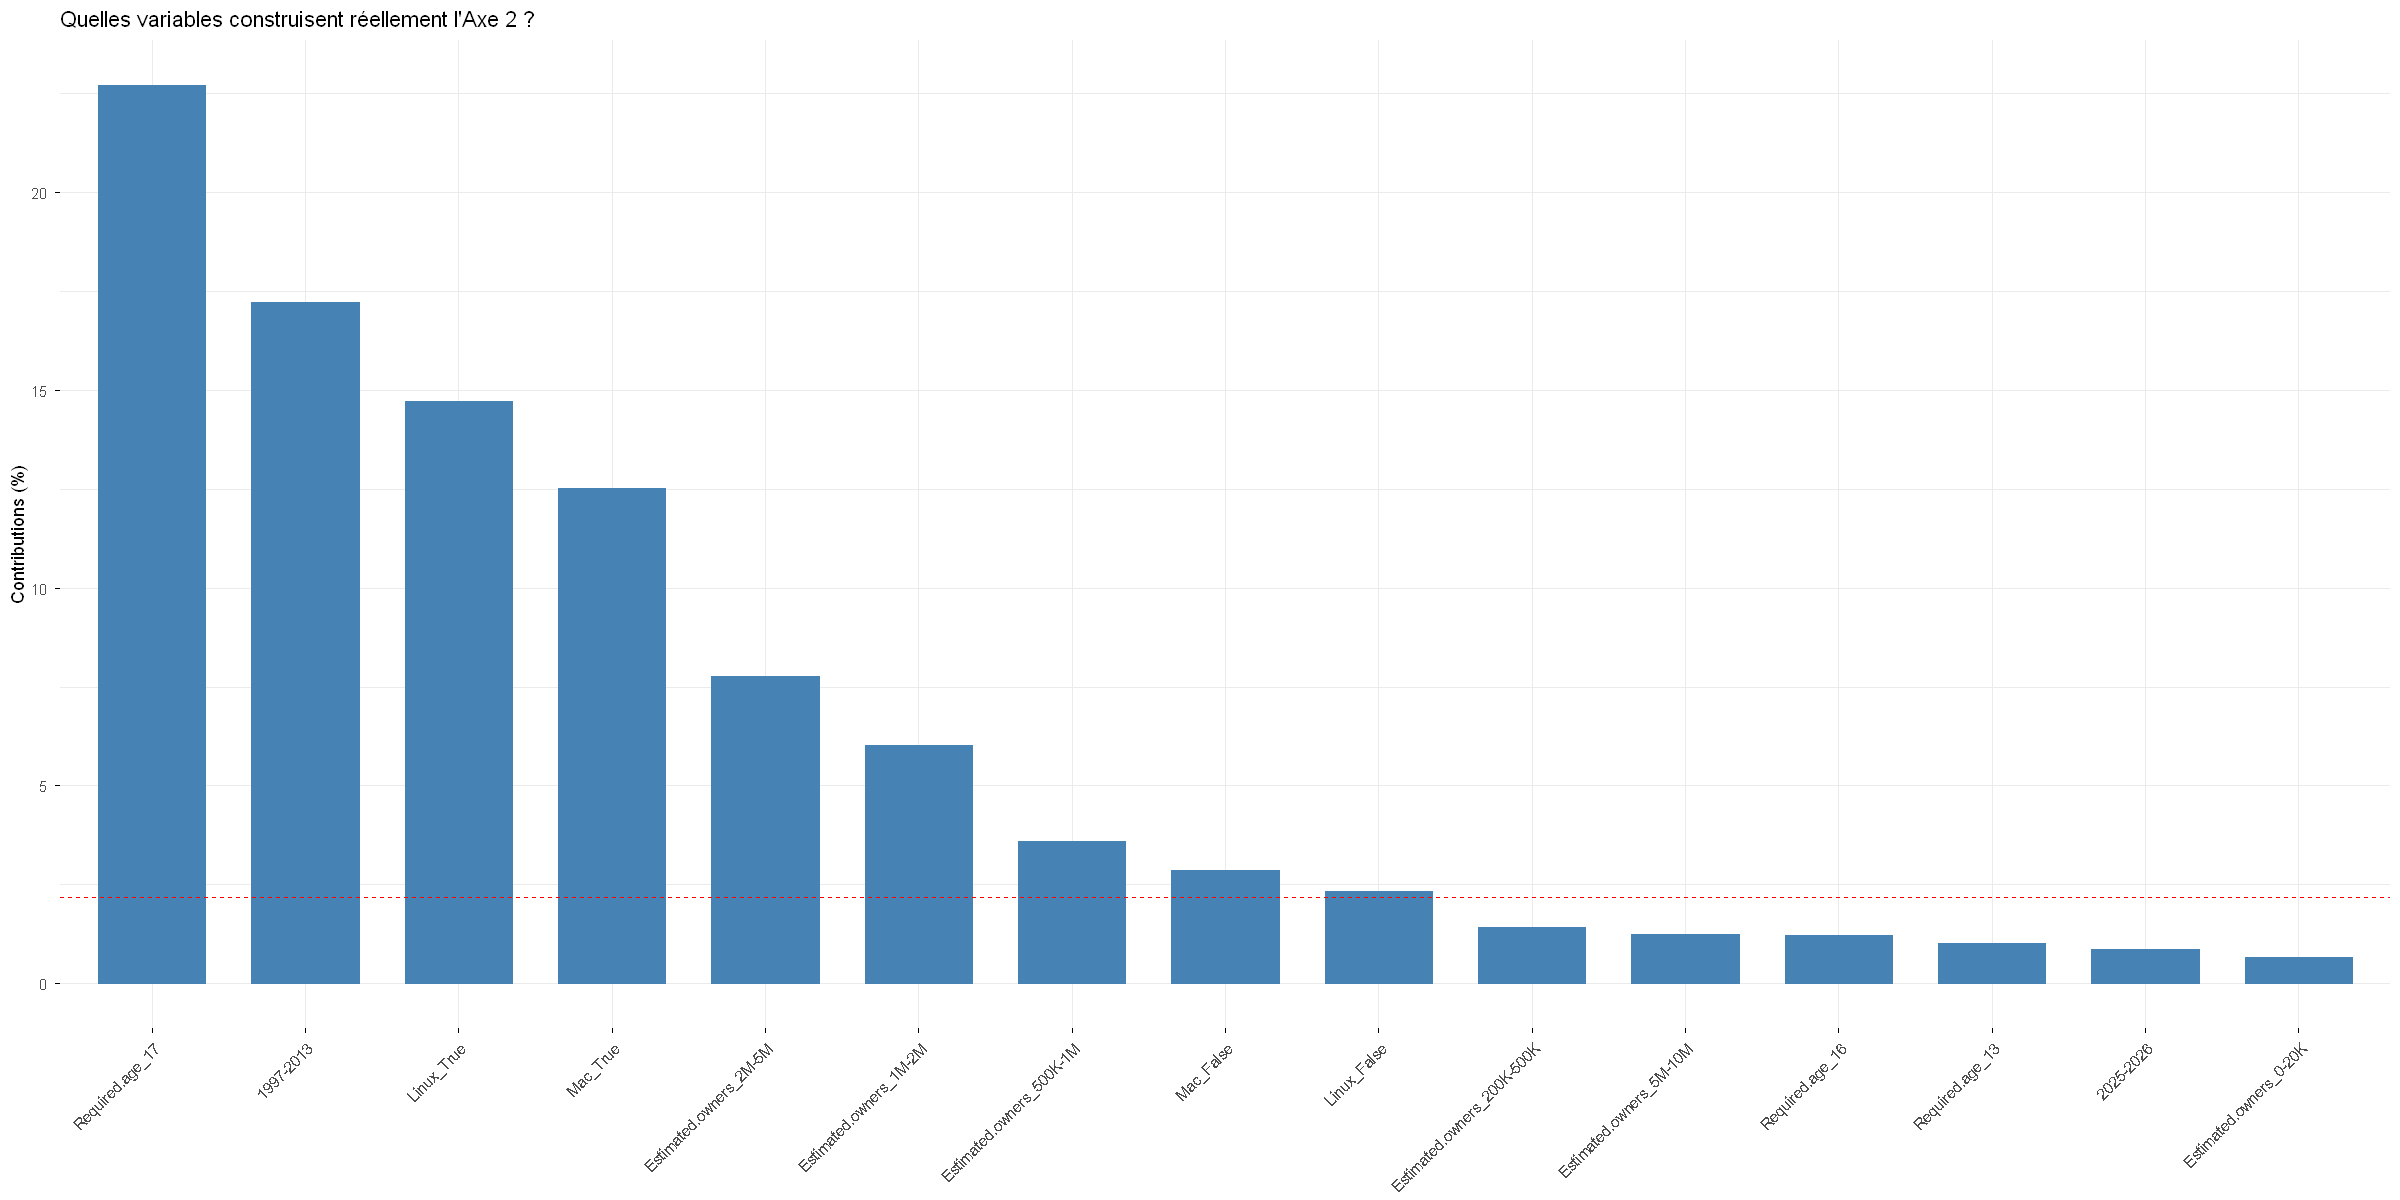

In [345]:

fviz_contrib(res.mca_filtre, 
             choice = "var",  
             axes = 2,
             top=15,
             title = "Quelles variables construisent réellement l'Axe 2 ?")

In [346]:
print(res.desc$`Dim 3`$quali)

                                       R2      p.value
Release.date                 5.926597e-01 0.000000e+00
Estimated.owners             6.233234e-01 0.000000e+00
Required.age                 3.580644e-02 0.000000e+00
Mac                          2.752913e-02 0.000000e+00
Linux                        4.420800e-02 0.000000e+00
Genres_Free To Play          6.782789e-02 0.000000e+00
Genres_Indie                 2.918685e-03 9.061983e-75
Genre_Mature                 2.089439e-03 5.022237e-54
Genres_Action                1.229525e-03 1.708990e-32
Genres_Massively Multiplayer 1.086658e-03 6.543254e-29
Genres_Adventure             7.546150e-04 1.437535e-20
Genres_Simulation            3.145494e-04 1.948145e-09
Genres_Sports                2.369174e-04 1.899535e-07
Genres_Strategy              2.335788e-04 2.315101e-07
Genres_Casual                1.673596e-04 1.198263e-05
Genre_Outils                 1.495186e-04 3.504040e-05
Genres_RPG                   1.351094e-04 8.371463e-05
Windows   

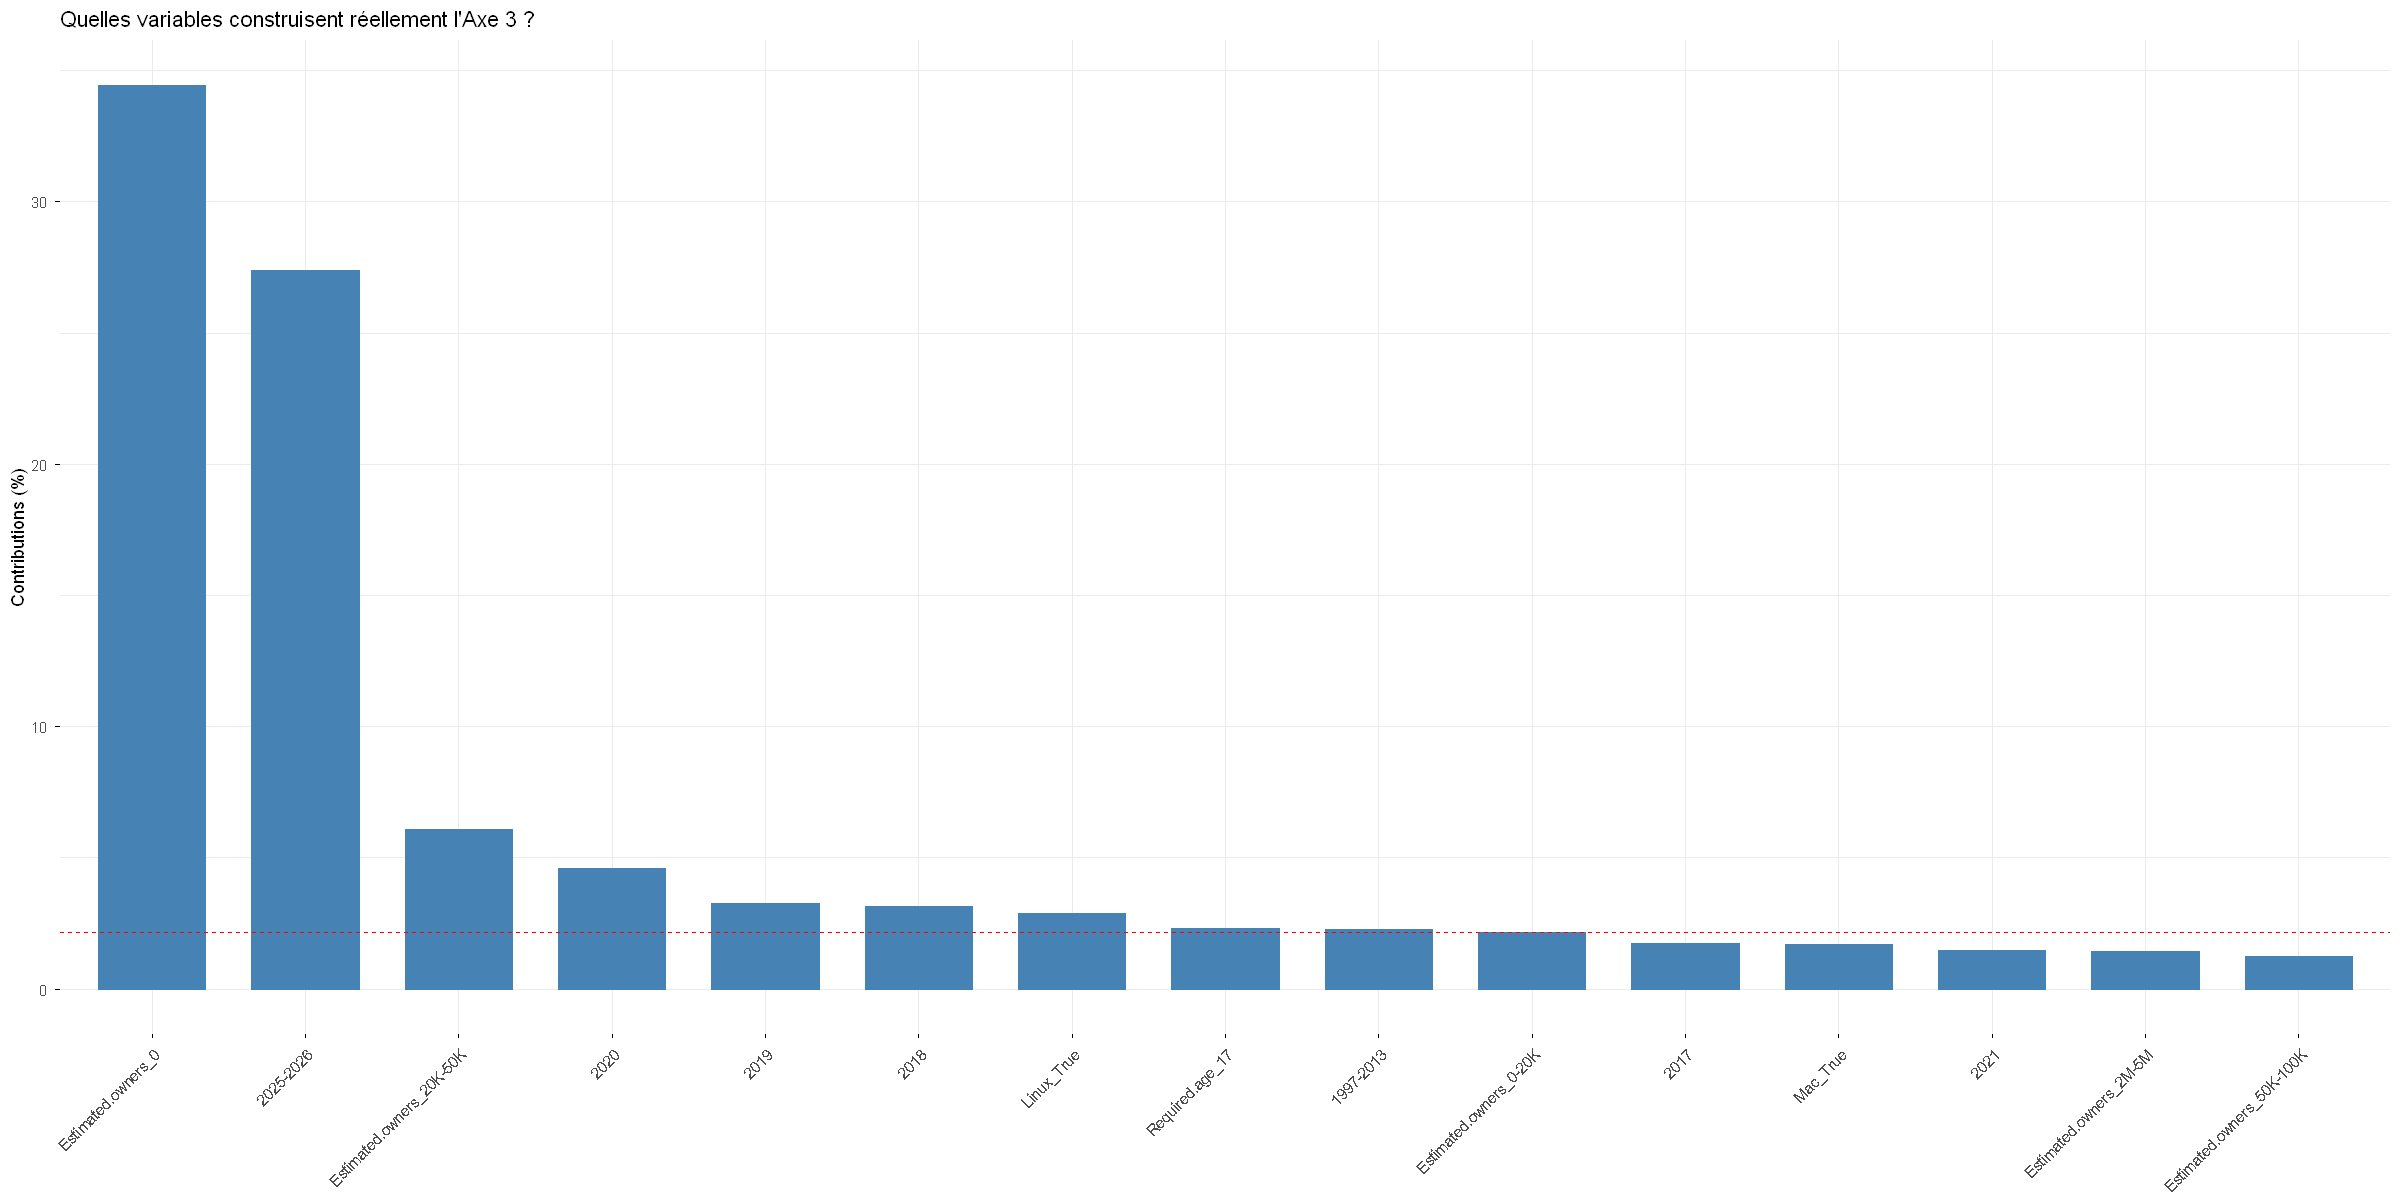

In [347]:

fviz_contrib(res.mca_filtre, 
             choice = "var",  
             axes = 3,
             top=15,
             title = "Quelles variables construisent réellement l'Axe 3 ?")

In [348]:
print(res.desc$`Dim 4`$quali)

                                       R2       p.value
Release.date                 3.405989e-01  0.000000e+00
Estimated.owners             5.785125e-01  0.000000e+00
Required.age                 1.223395e-01  0.000000e+00
Mac                          3.211513e-02  0.000000e+00
Linux                        4.681591e-02  0.000000e+00
Genres_Free To Play          1.205157e-02 6.917237e-304
Genres_Casual                3.337607e-03  3.011346e-85
Genres_Indie                 1.389117e-03  1.710087e-36
Genres_RPG                   8.202302e-04  3.213939e-22
Genres_Strategy              7.676171e-04  6.767613e-21
Genre_Mature                 3.635687e-04  1.097252e-10
Genres_Massively Multiplayer 3.499866e-04  2.432542e-10
Genres_Early Access          1.969063e-04  2.047376e-06
Windows                      1.067264e-04  4.723067e-04
Genres_Simulation            7.176492e-05  4.147388e-03
Genres_Sports                4.572462e-05  2.212321e-02


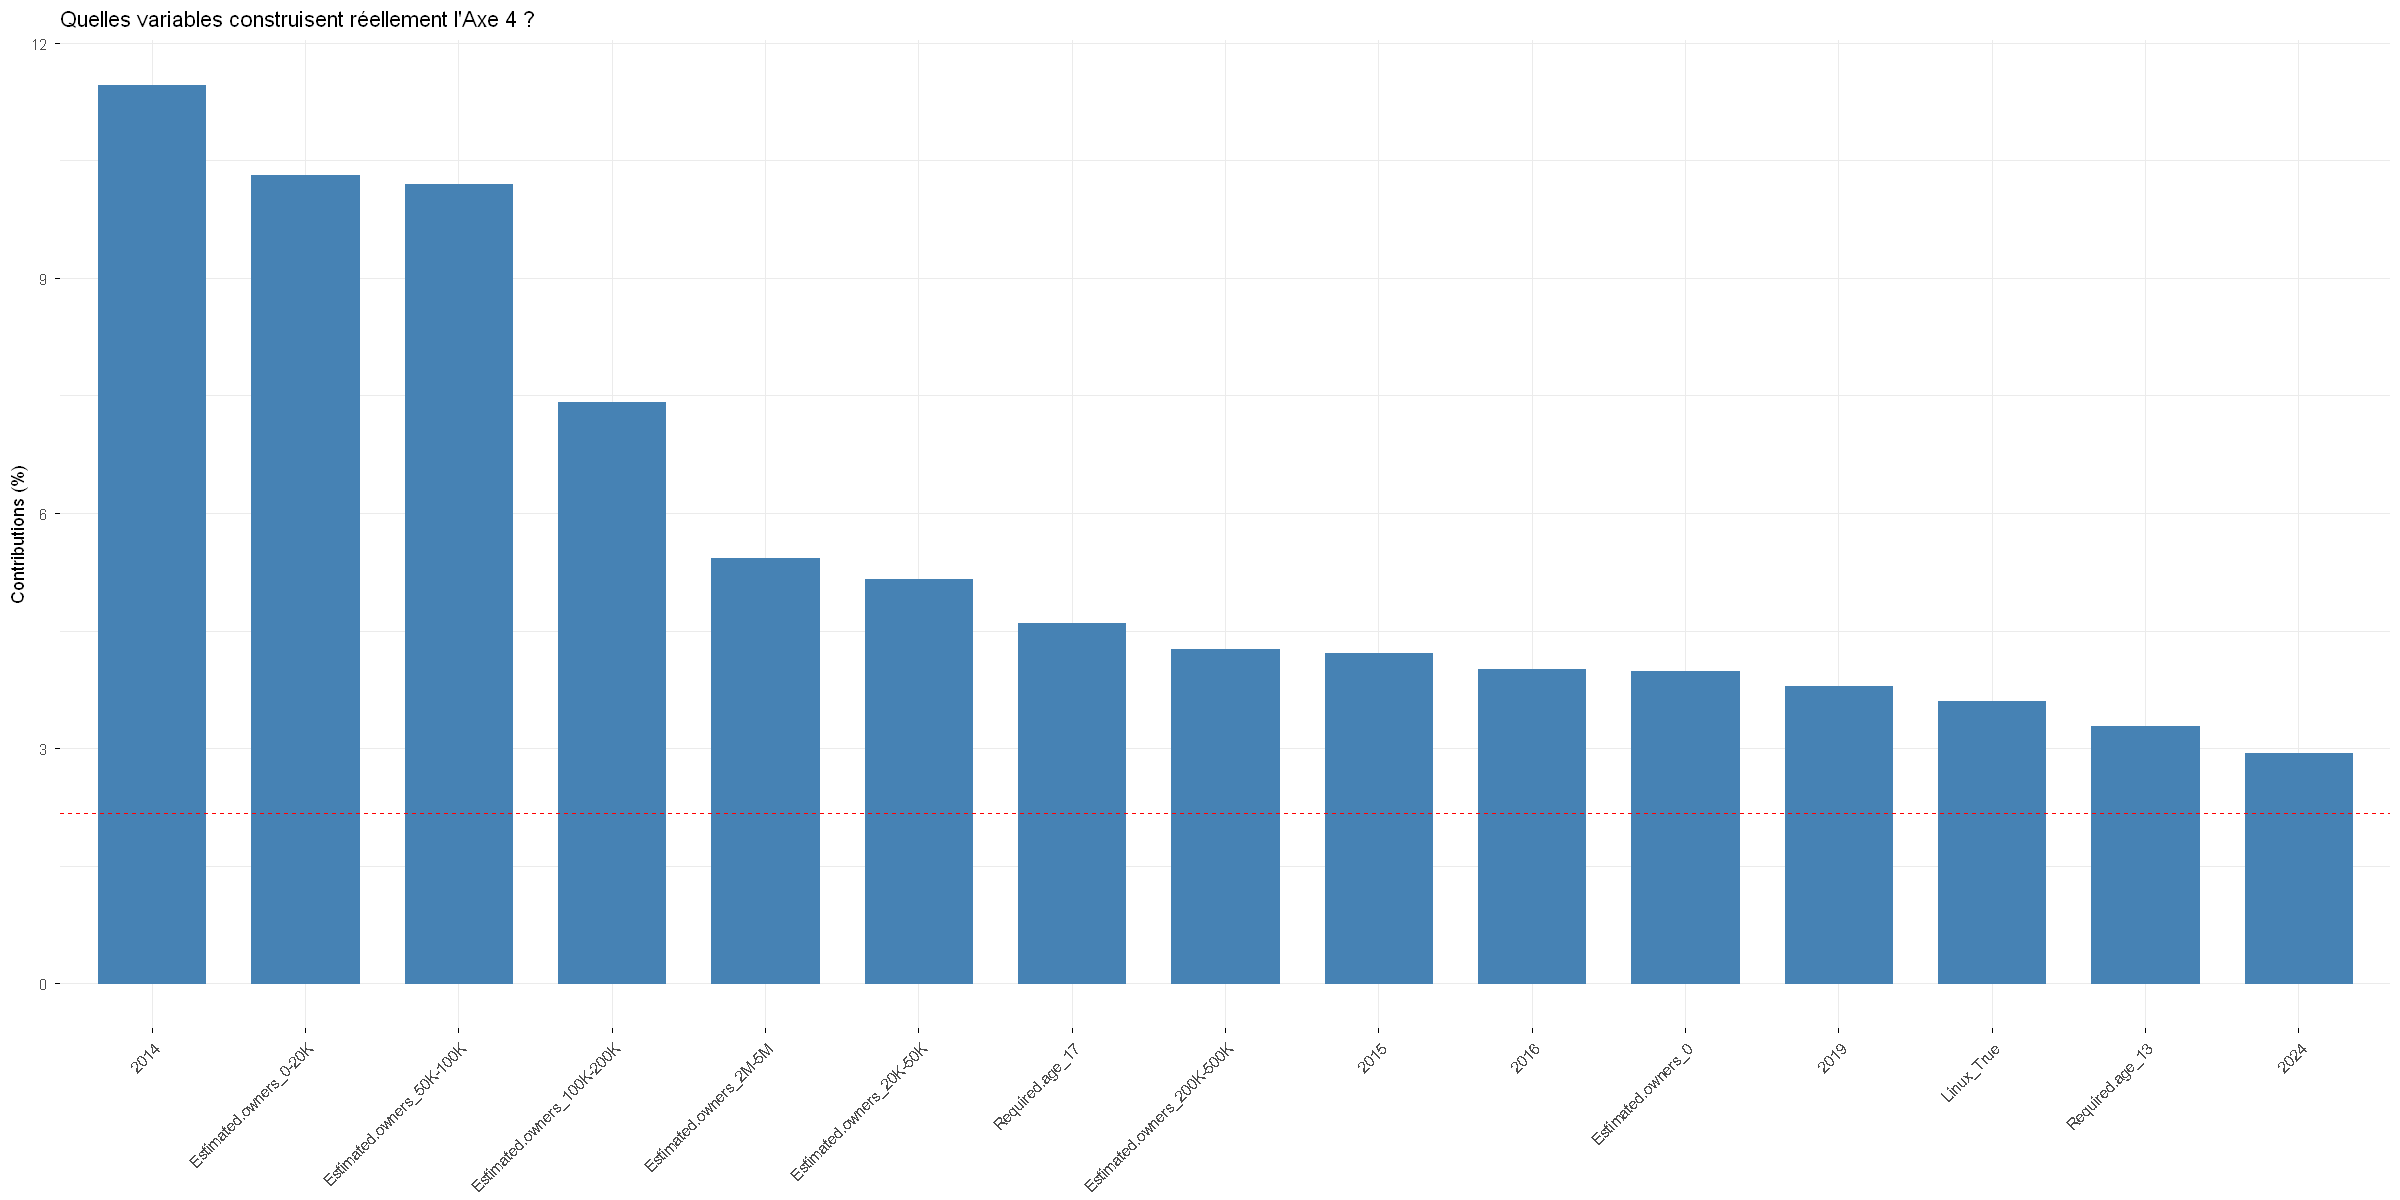

In [349]:

fviz_contrib(res.mca_filtre, 
             choice = "var",  
             axes = 4,
             top=15,
             title = "Quelles variables construisent réellement l'Axe 4 ?")

In [350]:
print(res.desc$`Dim 5`$quali)

                              R2      p.value
Release.date        1.545731e-01 0.0000000000
Estimated.owners    4.533764e-01 0.0000000000
Required.age        4.536726e-01 0.0000000000
Genres_Strategy     1.235979e-04 0.0001684267
Genres_Indie        7.299000e-05 0.0038390283
Linux               7.119409e-05 0.0042995650
Genres_Simulation   6.954327e-05 0.0047724438
Genres_Free To Play 5.644089e-05 0.0110127610
Genres_Adventure    3.474556e-05 0.0460763712


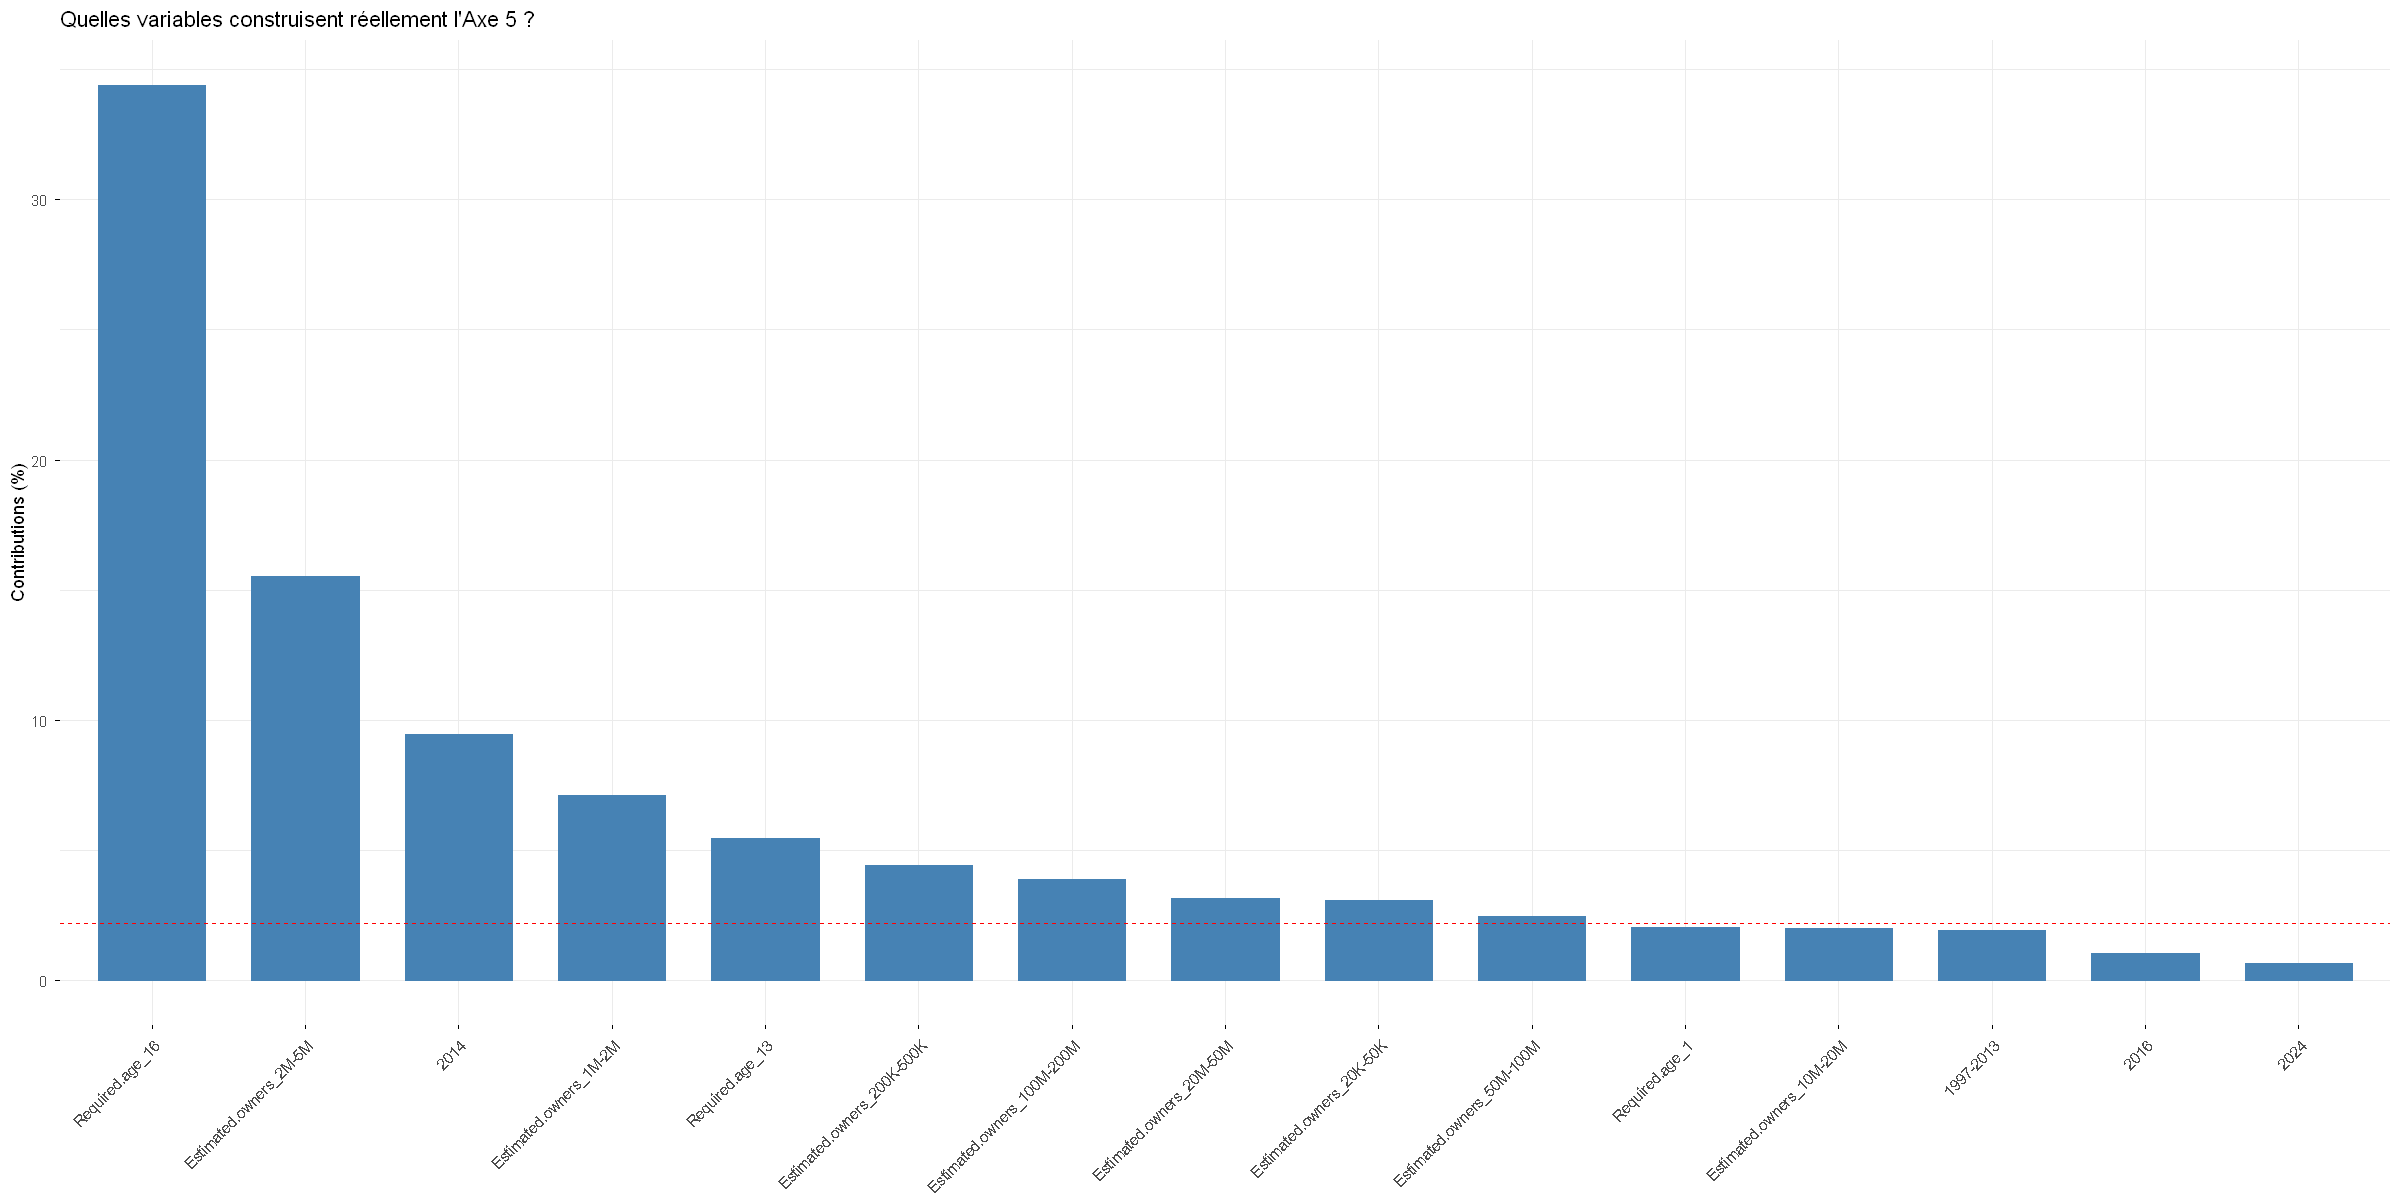

In [351]:

fviz_contrib(res.mca_filtre, 
             choice = "var",  
             axes = 5,
             top=15,
             title = "Quelles variables construisent réellement l'Axe 5 ?")

In [383]:
# On utilise les coordonnées de ta MCA (par exemple les 5 premiers axes)
# car travailler sur les axes réduit le "bruit"
coordonnees <- res.mca_filtre$ind$coord[, 1:5] 

# On lance le K-means pour créer 5 groupes (tu peux changer le nombre)
set.seed(123) # Pour avoir toujours le même résultat
cl <- kmeans(coordonnees, centers = 5, iter.max = 20)


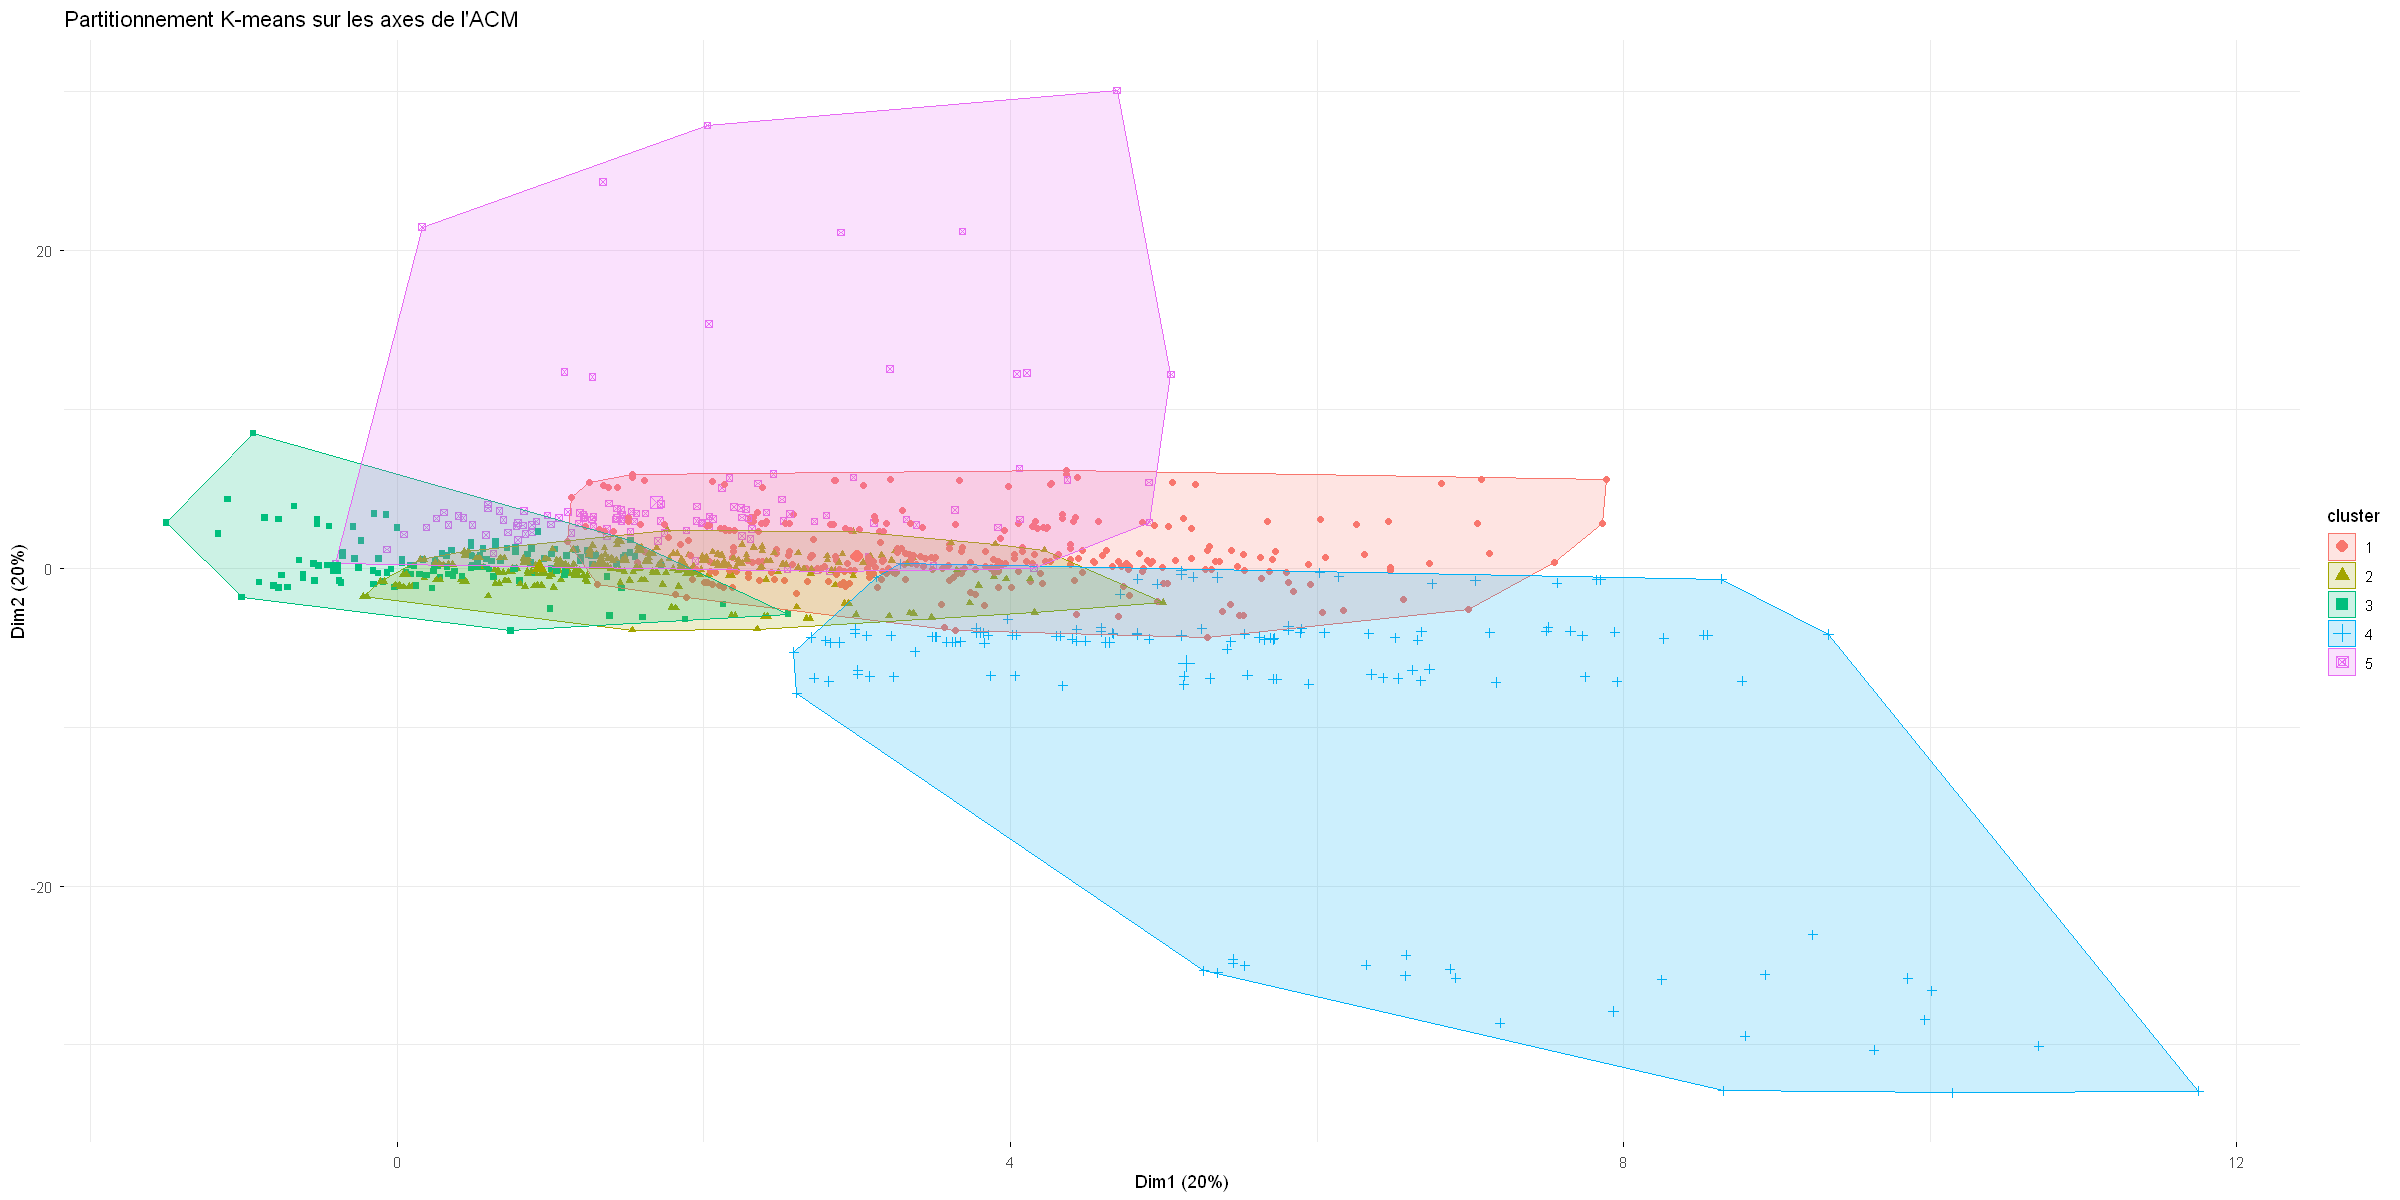

In [384]:
# Visualisation des clusters sur les deux premiers axes de l'ACM
fviz_cluster(cl, data = coordonnees,
             geom = "point",
             ellipse.type = "convex", 
             ggtheme = theme_minimal(),
             main = "Partitionnement K-means sur les axes de l'ACM")

In [389]:
# 1. On ajoute le cluster au dataset original
data_quali_new$cluster <- as.factor(cl$cluster)

# Pour voir ce qui définit le Cluster 1 :
res.cat <- catdes(data_quali_new, ncol(data_quali_new)) # ncol si le cluster est la dernière colonne

# Regarde ce qui définit le Cluster 4 (le grand bleu à droite)
print(res.cat$category$`4`)

# Regarde ce qui définit le Cluster 5 (le violet en haut)
print(res.cat$category$`5`)

                                    Cla/Mod    Mod/Cla      Global
Estimated.owners=2M-5M         9.850000e+01 83.2980973  0.34930532
Required.age=17                1.572890e+01 26.0042283  0.68289190
Release.date=1997-2013         6.272870e+00 25.3699789  1.67055269
Required.age=16                1.000000e+02  6.5539112  0.02707116
Estimated.owners=20M-50M       1.000000e+02  6.5539112  0.02707116
Genres_Casual=0                6.452014e-01 87.7378436 56.16916857
Genres_Indie=0                 8.612807e-01 61.7336152 29.60624558
Estimated.owners=5M-10M        2.177419e+01  5.7082452  0.10828465
Genres_Action=1                6.976492e-01 68.0761099 40.30546750
Release.date=2014              2.636783e+00  8.4566596  1.32474042
Mac=True                       7.998871e-01 35.9408034 18.55946486
Genres_Massively.Multiplayer=1 1.821782e+00  9.7251586  2.20498983
Linux=True                     7.593160e-01 25.1585624 13.68578240
Required.age=18                6.707317e+00  2.3255814  0.1432

In [391]:

tab_age <- table(data_quali_new$cluster, data_quali_new$Required.age)
prop_tab_age <- prop.table(tab_age, 1) * 100 # En pourcentage par ligne

print(round(prop_tab_age, 2))

   
        0     1     3     6     7    10    12    13    14    15    16    17
  1 76.38  0.00  0.00  0.03  0.00  0.00  0.03  0.21  0.00  0.00  0.00 22.49
  2 99.83  0.00  0.00  0.00  0.00  0.00  0.03  0.00  0.00  0.00  0.00  0.00
  3 99.85  0.00  0.01  0.00  0.01  0.00  0.02  0.00  0.00  0.00  0.00  0.00
  4 64.69  0.00  0.00  0.00  0.00  0.00  0.21  0.21  0.00  0.00  6.55 26.00
  5  3.88  0.97  0.00  0.00  0.00 12.14  0.00 81.55  0.00  0.00  0.00  1.46
   
       18    20    21
  1  0.86  0.00  0.00
  2  0.13  0.00  0.00
  3  0.11  0.00  0.00
  4  2.33  0.00  0.00
  5  0.00  0.00  0.00


In [393]:
tab_owner <- table(data_quali_new$cluster, data_quali_new$Estimated.owners)
prop_tab_owner <- prop.table(tab_owner, 1) * 100 # En pourcentage par ligne

print(round(prop_tab_owner, 2))

   
        0 0-20K 20K-50K 50K-100K 100K-200K 200K-500K 500K-1M 1M-2M 2M-5M 5M-10M
  1  1.47 11.93    9.77    11.24     11.21     14.78   10.39 24.20  0.21   3.09
  2 10.27 62.96   11.56     5.71      4.20      4.01    1.27  0.00  0.00   0.03
  3 12.83 68.85    9.56     4.17      2.39      1.61    0.60  0.00  0.00   0.00
  4  0.00  1.90    0.21     0.21      0.42      0.42    0.85  0.42 83.30   5.71
  5  5.34 33.50    7.77     8.25     10.68     16.02    6.31  5.83  0.00   0.00
   
    10M-20M 20M-50M 50M-100M 100M-200M
  1    1.71    0.00     0.00      0.00
  2    0.00    0.00     0.00      0.00
  3    0.00    0.00     0.00      0.00
  4    0.00    6.55     0.00      0.00
  5    0.00    0.00     4.37      1.94


In [394]:
tab_date <- table(data_quali_new$cluster, data_quali_new$Release.date)
prop_tab_date <- prop.table(tab_date, 1) * 100 # En pourcentage par ligne

print(round(prop_tab_date, 2))

   
    1997-2013  2014  2015  2016  2017  2018  2019  2020  2021  2022  2023  2024
  1     60.75  2.57  4.15  3.63  3.74  3.15  3.60  3.87  3.50  3.50  3.60  1.85
  2      0.00  2.53  4.85  5.90  6.82  7.42  6.75  7.86  8.08  8.79 10.69 13.65
  3      0.00  0.89  1.32  2.93  4.72  6.33  6.29  7.70  9.63 10.54 12.24 16.98
  4     25.37  8.46  7.40  7.61  8.46  8.25  5.71  7.19  5.71  4.86  4.02  4.65
  5     10.19  5.34  7.28  8.25  8.74 10.19 10.68  8.25  3.88  6.80  7.77  8.74
   
    2025-2026
  1      2.09
  2     16.67
  3     20.43
  4      2.33
  5      3.88


L'analyse par clustering a permis de diviser les jeux en plusieurs groupes distincts. Le Cluster 4 regroupe les jeux anciens sortis entre 1997 et 2013 ayant atteint des millions de possesseurs (entre 2 et 50 millions) ciblant un public adulte avec des restrictions d'âge de 16 à 18 ans. À l'opposé, le Cluster 5 identifie des jeux "niche" composé de jeux pour adolescents (10-13 ans) et gratuits. Enfin, la grande majorité des jeux se concentre dans des clusters centraux représentant des sorties indépendantes récentes (2023-2026), caractérisée par des volumes de ventes plus faibles (moins de 20 000 possesseurs) et une accessibilité à tout public (âge requis de 0). Ces résultats montrent que les titres les plus populaires sont souvent des jeux d'action anciens, alors que des jeux actuels sont des nouveautés ayant moins de succès commercial et tout en étant accessibles à tout public(pas de restriction d'age).

# FAMD 

In [41]:
df_famd<-df_one_hot %>% mutate(
    # Création du méta-genre "Mature"
    Genre_Mature = if_else(Genres_Gore == "1" |
                           Genres_Nudity == "1"|
                           `Genres_Sexual Content` == "1"|
                           Genres_Violent == "1", "1", "0"),
      
     Genre_Video = if_else(Genres_Episodic == "1" |
                           Genres_Documentary == "1"|
                           Genres_Short == "1"|
                           Genres_Movie == "1"|
                           `Genres_360 Video` == "1"|
                           Genres_Tutorial == "1", "1", "0"),
    
    # Création du méta-genre "Logiciels/Outils" (selon ton cluster de droite)
    Genre_Outils = if_else( `Genres_Video Production` == "1" | 
                           `Genres_Design & Illustration` =="1"|
                           `Genres_Animation & Modeling` == "1" |
                           `Genres_Game Development` == "1"|
                           `Genres_Audio Production` == "1"|
                           `Genres_Photo Editing` == "1"|
                          `Genres_Software Training` == "1"|
                           Genres_Education == "1" |
                           Genres_Utilities == "1" |
                           `Genres_Web Publishing` == "1", "1", "0")
  ) %>%

  mutate(Genre_Mature = as.factor(Genre_Mature),
         Genre_Video = as.factor(Genre_Video),
        Genre_Outils = as.factor(Genre_Outils)) %>%
select(-Name,- Release.date,-Required.age ,- Categories,-Tags,-Language,-TagGenre,- Developers,-Publishers,
      -Windows,-Mac,-Linux)

In [42]:
cols_to_remove <- c("Genres_Gore", "Genres_Violent", "Genres_Video Production","Genres_Sexual Content","Genres_Nudity", 
                    "Genres_Design & Illustration", "Genres_Animation & Modeling","Genres_Game Development", 
                    "Genres_Audio Production","Genres_Photo Editing", "Genres_Software Training", 
                    "Genres_Education", "Genres_Utilities", "Genres_Web Publishing","Genres_Episodic",
                   "Genres_Documentary","Genres_Short","Genres_Movie","Genres_360 Video","Genres_Tutorial")

df_famd_final <- df_famd %>%
  select(-all_of(cols_to_remove))


In [43]:
summary(df_famd_final)

  Estimated.owners    Discount      Metacritic.score   User.score       
 0-20K    :75337   Min.   :  0.00   Min.   : 0.000   Min.   :  0.00000  
 0        :13649   1st Qu.:  0.00   1st Qu.: 0.000   1st Qu.:  0.00000  
 20K-50K  :11395   Median :  0.00   Median : 0.000   Median :  0.00000  
 50K-100K : 5349   Mean   : 19.62   Mean   : 2.703   Mean   :  0.02628  
 100K-200K: 3450   3rd Qu.: 45.00   3rd Qu.: 0.000   3rd Qu.:  0.00000  
 200K-500K: 2845   Max.   :100.00   Max.   :97.000   Max.   :100.00000  
 (Other)  : 2488                                                        
  Achievements     Average.playtime.two.weeks Median.playtime.two.weeks
 Min.   :   0.00   Min.   :    0.00           Min.   :    0.00         
 1st Qu.:   0.00   1st Qu.:    0.00           1st Qu.:    0.00         
 Median :   5.00   Median :    0.00           Median :    0.00         
 Mean   :  19.19   Mean   :   14.74           Mean   :   15.74         
 3rd Qu.:  20.00   3rd Qu.:    0.00           3rd Qu.:  

In [44]:
df_famd_ready <-df_famd_final
df_famd_ready[,-c(1:16)] <- lapply(df_famd_final[,-c(1:16)], as.factor)

In [45]:
summary(df_famd_ready)

  Estimated.owners    Discount      Metacritic.score   User.score       
 0-20K    :75337   Min.   :  0.00   Min.   : 0.000   Min.   :  0.00000  
 0        :13649   1st Qu.:  0.00   1st Qu.: 0.000   1st Qu.:  0.00000  
 20K-50K  :11395   Median :  0.00   Median : 0.000   Median :  0.00000  
 50K-100K : 5349   Mean   : 19.62   Mean   : 2.703   Mean   :  0.02628  
 100K-200K: 3450   3rd Qu.: 45.00   3rd Qu.: 0.000   3rd Qu.:  0.00000  
 200K-500K: 2845   Max.   :100.00   Max.   :97.000   Max.   :100.00000  
 (Other)  : 2488                                                        
  Achievements     Average.playtime.two.weeks Median.playtime.two.weeks
 Min.   :   0.00   Min.   :    0.00           Min.   :    0.00         
 1st Qu.:   0.00   1st Qu.:    0.00           1st Qu.:    0.00         
 Median :   5.00   Median :    0.00           Median :    0.00         
 Mean   :  19.19   Mean   :   14.74           Mean   :   15.74         
 3rd Qu.:  20.00   3rd Qu.:    0.00           3rd Qu.:  

In [48]:
res.famd <- FAMD(df_famd_ready,sup.var=c(1,3:5,30,31), graph = FALSE)


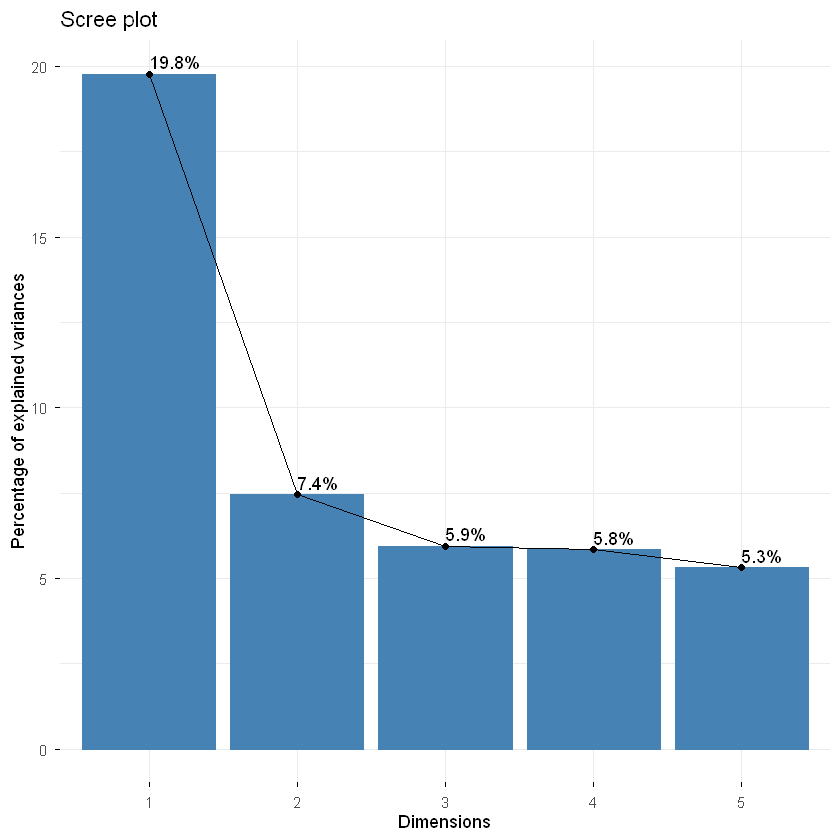

In [49]:
fviz_eig(res.famd,addlabels = T)

on garde deux dimensions

In [50]:
res.famd$quali.sup$coord

,Dim.1,Dim.2,Dim.3,Dim.4,Dim.5
Estimated.owners_0,-1.6507186567,4.777667e-01,-7.189527e-01,7.980623e-01,4.501373e-02
Estimated.owners_0-20K,-0.5833073755,-3.747204e-02,2.529062e-01,-1.762958e-01,-1.451551e-02
Estimated.owners_20K-50K,0.9823449007,-2.342434e-01,-2.211344e-01,-7.179698e-02,1.599942e-02
Estimated.owners_50K-100K,2.2122206857,-2.867882e-01,-3.440763e-01,7.247685e-02,4.114440e-02
Estimated.owners_100K-200K,3.4474475817,-2.511510e-01,-4.514438e-01,2.059280e-01,-4.378218e-03
Estimated.owners_200K-500K,4.6869539795,-2.268880e-01,-5.509622e-01,3.594476e-01,2.076317e-02
Estimated.owners_500K-1M,6.2377415494,6.110112e-01,-5.625827e-01,3.481845e-01,4.622147e-02
Estimated.owners_1M-2M,7.4086874561,5.837060e-01,-7.140917e-01,4.178306e-01,-7.340246e-02
Estimated.owners_2M-5M,8.6005467249,8.149923e-01,-8.775007e-01,4.968617e-01,-6.878882e-02
Estimated.owners_5M-10M,9.7862022583,2.850183e+00,-8.708386e-01,7.106269e-01,1.268816e-01


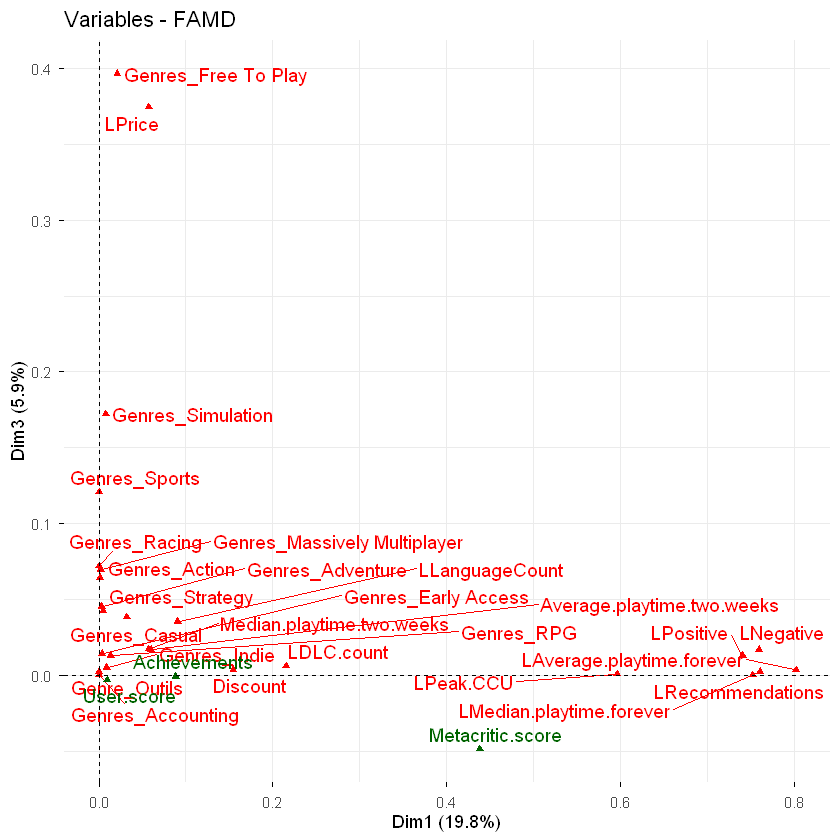

In [51]:
fviz_famd_var(res.famd, repel = TRUE,axes=c(1,3))


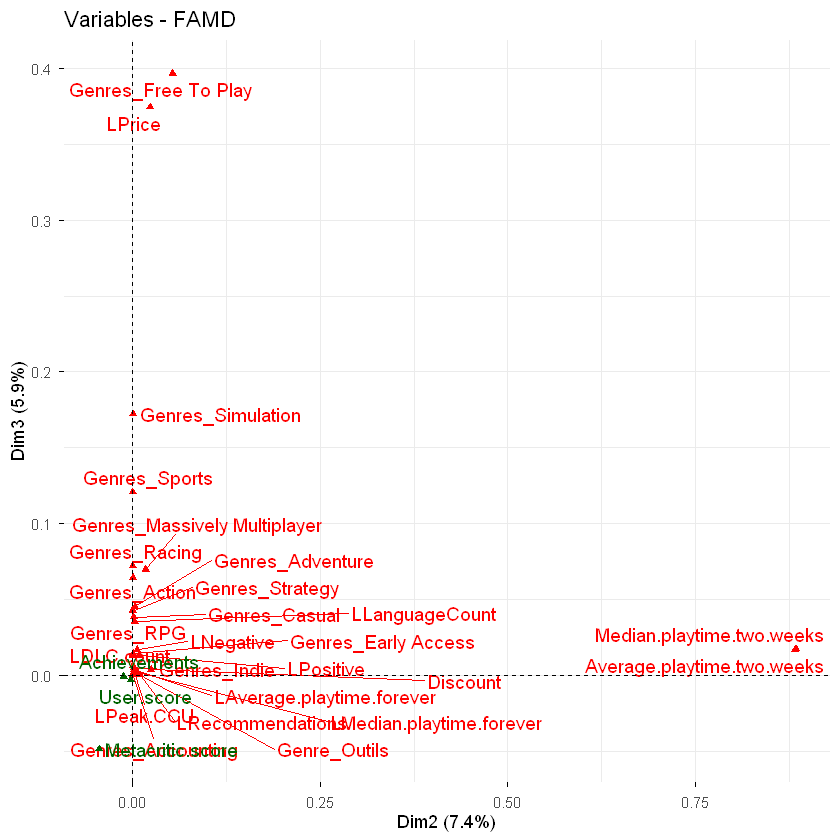

In [52]:
fviz_famd_var(res.famd, repel = TRUE,axes=c(2,3))

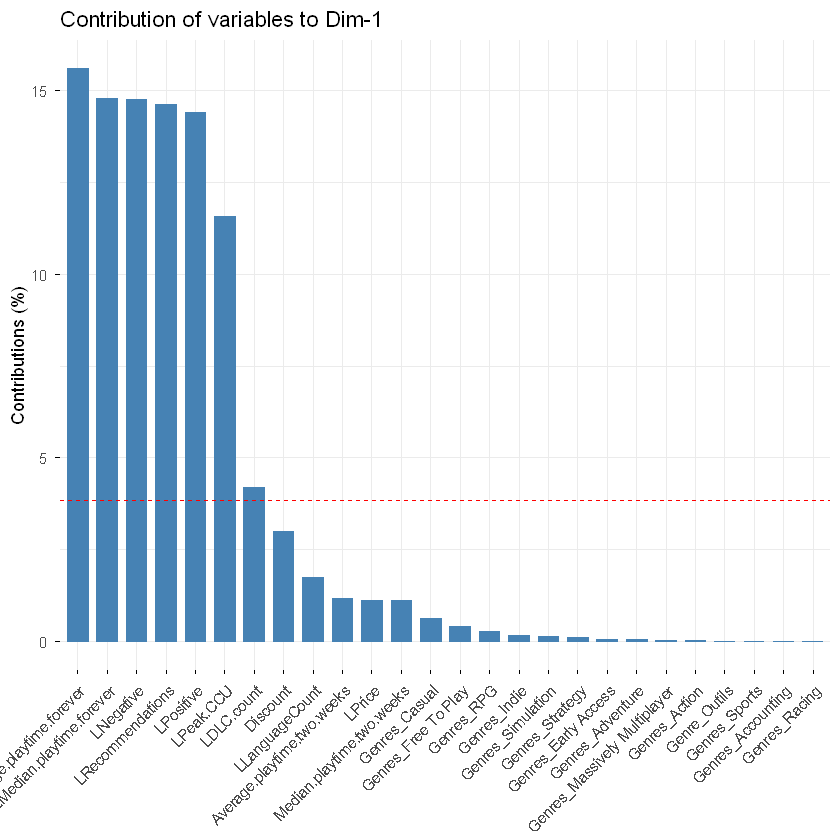

In [53]:
fviz_contrib(res.famd, choice = "var", axes = 1) # Axe 1


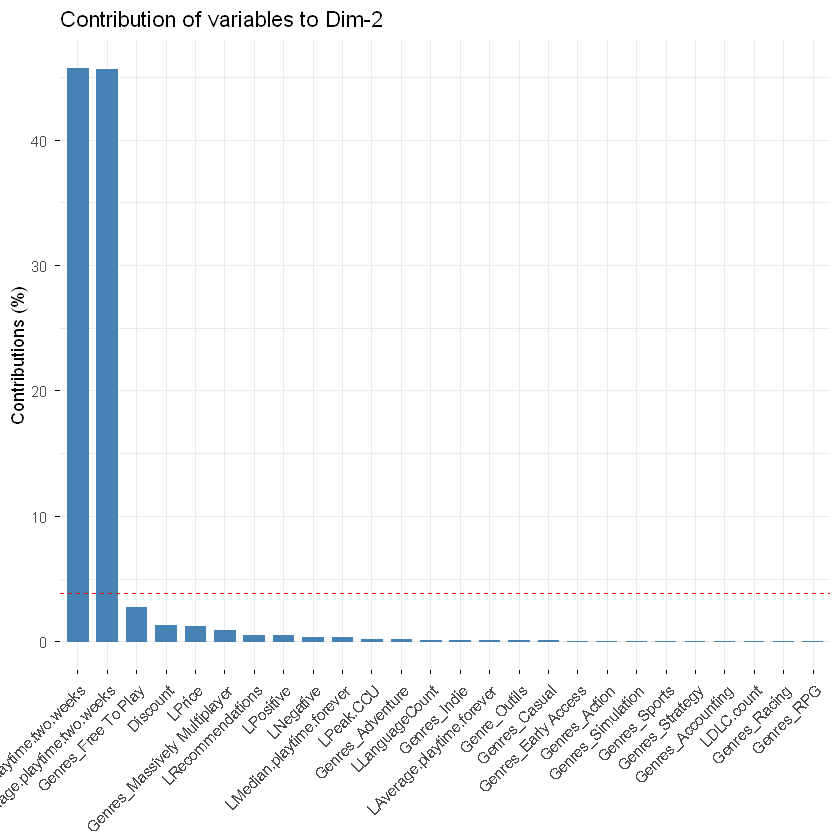

In [55]:
fviz_contrib(res.famd, choice = "var", axes = 2)

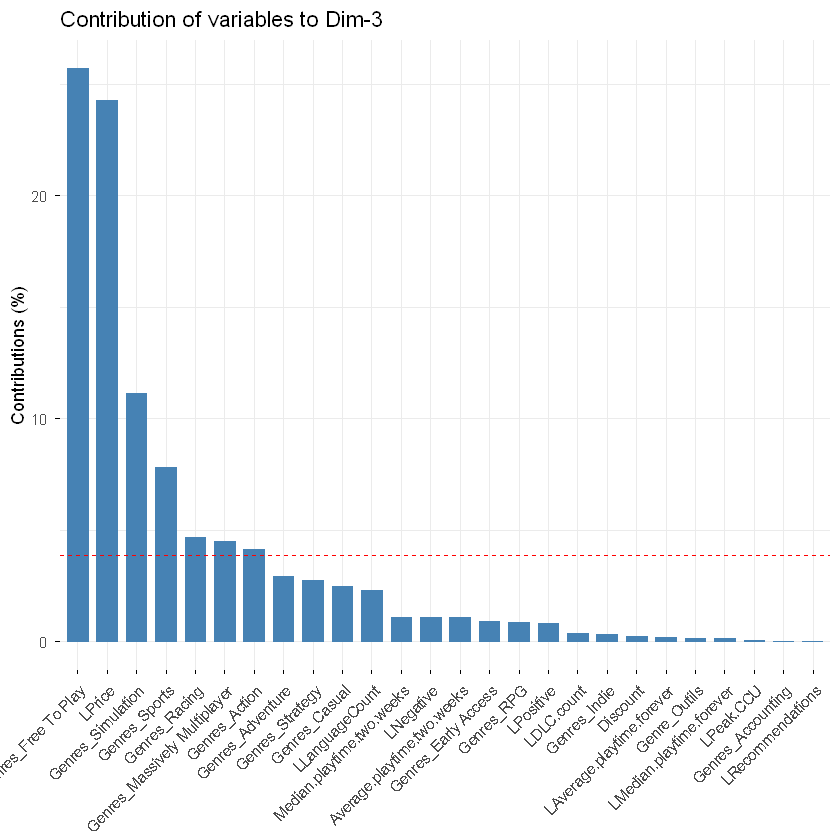

In [56]:
fviz_contrib(res.famd, choice = "var", axes = 3) 


Cette **FAMD** permet d'identifier deux axes principaux qui expliquent l'ensemble des jeux sur Steam :

Axe 1 (19.8%) - La Popularité et le Succès : C'est la dimension la plus forte. Elle regroupe les variables de réussite massive (nombre de recommandations, évaluations positives et temps de jeu total). Cet axe montre que le succès ne dépend pas d'un genre spécifique, car tous les genres restent regroupés au centre de cette dimension.

Axe 2 (7.4%): Cette dimension isole les jeux récemment joués (temps de jeu sur les deux dernières semaines). Elle différencie les titres qui génèrent une activité intense en ce moment de ceux qui ont un succès historique mais sont moins pratiqués ces deux dernières semaines.


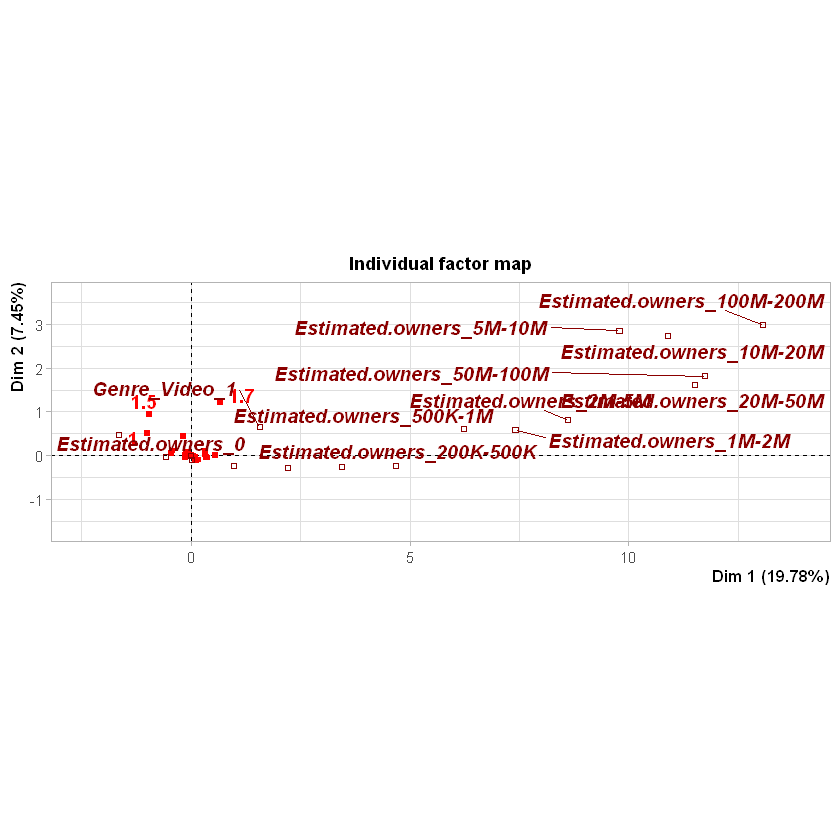

In [54]:
plot(res.famd, choice = "quali", invisible = "ind", habillage = "none")


La projection des variables supplémentaires **Estimated.owners** sur le premier plan factoriel valide la cohérence des axes : elle confirme que l'axe 1 mesure bien la popularité, puisque les tranches de possesseurs s'y étalent de manière croissante de gauche à droite. Sur l'axe 2, cette projection démontre que les plus gros succès commerciaux (les tranches les plus hautes d'owners) sont aussi les jeux qui génèrent une activité intense en ce moment. Cela permet de différencier ces jeux très pratiqués ces deux dernières semaines de ceux qui ont un succès historique mais qui sont aujourd'hui moins joués. Enfin, la position centrale des genres confirme que la réussite commerciale dépend de la performance réelle du jeu plutôt que de son simple genre.

## GMM Clustering

In [473]:
#install.packages("mclust")

Installation du package dans 'C:/Users/fauli/AppData/Local/R/win-library/4.5'
(car 'lib' n'est pas spécifié)



le package 'mclust' a été décompressé et les sommes MD5 ont été vérifiées avec succés

Les packages binaires téléchargés sont dans
	C:\Users\fauli\AppData\Local\Temp\Rtmp8cOS6q\downloaded_packages


In [57]:
library(mclust)

Warning message:
"le package 'mclust' a été compilé avec la version R 4.5.3"
Package 'mclust' version 6.1.2
Type 'citation("mclust")' for citing this R package in publications.


Attachement du package : 'mclust'


L'objet suivant est masqué depuis 'package:dplyr':

    count


L'objet suivant est masqué depuis 'package:purrr':

    map




In [58]:
#on récupère les 3 première dimensions
donnees_gmm <- res.famd$ind$coord[, 1:3]

In [59]:

#selection du nombre de cluster avec BIC
mod_gmm <- Mclust(donnees_gmm)

# Voir le nombre de clusters choisi par l'algorithme
summary(mod_gmm)

---------------------------------------------------- 
Gaussian finite mixture model fitted by EM algorithm 
---------------------------------------------------- 

Mclust VVV (ellipsoidal, varying volume, shape, and orientation) model with 9
components: 

 log-likelihood      n df       BIC       ICL
      -304231.5 114513 89 -609499.8 -672255.5

Clustering table:
    1     2     3     4     5     6     7     8     9 
22244 21268  8370  3952 21711   689 16248  6147 13884 

In [60]:
# Ajouter le numéro de cluster aux données d'origine
donnees_finales <- df_famd_ready
donnees_finales$cluster_gmm <- mod_gmm$classification

# Voir les moyennes par cluster (par exemple pour le prix et les recommandations)


In [62]:
aggregate(donnees_finales[, c("LPrice","LRecommendations" )], 
          by = list(donnees_finales$cluster_gmm), 
          FUN = mean)

Group.1,LPrice,LRecommendations
<dbl>,<dbl>,<dbl>
1,1.62120736,4.354257050
2,1.29022052,0.000000000
3,0.01816545,0.002020214
4,1.49412926,6.270707156
5,1.33335663,0.013659959
6,2.00425192,7.924180885
7,1.43200752,0.063278927
8,0.79147087,0.260678167
9,1.56971346,0.271778270


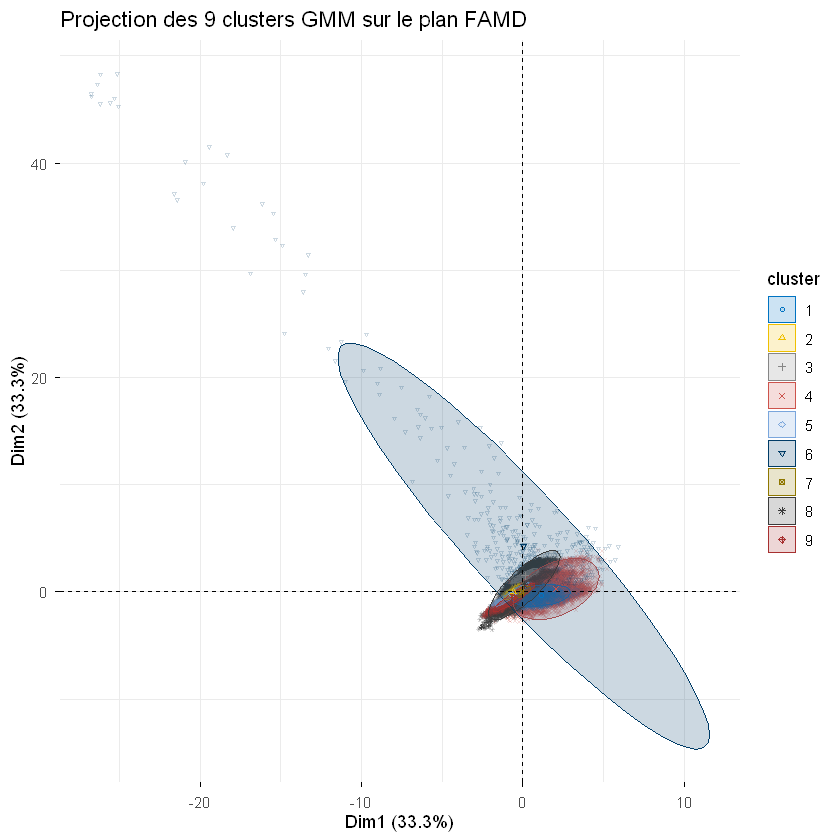

In [63]:
fviz_cluster(list(data = donnees_gmm, cluster = mod_gmm$classification),
             geom = "point",
             pointsize = 0.5,        # On réduit la taille des points pour la lisibilité
             alpha = 0.2,            # On met de la transparence
             ellipse.type = "norm",  # On trace les ellipses de confiance (très utile pour le GMM)
             palette = "jco",        # Une palette de couleurs propre
             ggtheme = theme_minimal(),
             main = "Projection des 9 clusters GMM sur le plan FAMD") +
  # On ajoute des axes clairs pour bien voir la séparation
  geom_hline(yintercept = 0, linetype = "dashed") +
  geom_vline(xintercept = 0, linetype = "dashed")

In [73]:
# On filtre sur le cluster 6
cluster_elite <- donnees_finales[donnees_finales$cluster_gmm == 6, ]

# On regarde la fréquence des genres (si tes genres sont en colonnes 0/1)
colonnes_genres <- c("Genres_Action", "Genres_Adventure", "Genres_RPG", "Genres_Indie","Genres_Casual","Genres_Free To Play","Genres_Early Access",
                    "Genres_Massively Multiplayer", "Genre_Outils")

# On s'assure que ces colonnes sont bien numériques pour le calcul
# (as.character puis as.numeric est la méthode la plus sûre pour les facteurs)
frequences <- colMeans(apply(cluster_elite[, colonnes_genres], 2, function(x) as.numeric(as.character(x))))

# Afficher les résultats proprement
print(frequences)

               Genres_Action             Genres_Adventure 
                  0.38751814                   0.40203193 
                  Genres_RPG                 Genres_Indie 
                  0.38316401                   0.43396226 
               Genres_Casual          Genres_Free To Play 
                  0.24092888                   0.14949202 
         Genres_Early Access Genres_Massively Multiplayer 
                  0.10740203                   0.11175617 
                Genre_Outils 
                  0.04208999 


In [74]:
distribution_succes <- table(donnees_finales$cluster_gmm, donnees_finales$Estimated.owners)

# Convertir en pourcentages pour mieux comparer
prop.table(distribution_succes, margin = 1) * 100

   
               0        0-20K      20K-50K     50K-100K    100K-200K
  1  0.017982377 42.442905952 22.540909908 14.215069232  9.845351555
  2 19.155538838 76.452886966  3.281925898  0.818130525  0.211585481
  3 63.990442055 29.139784946  5.029868578  1.409796894  0.322580645
  4  0.253036437 15.587044534  8.552631579  8.957489879 12.955465587
  5 10.331168532 81.018838377  6.176592511  1.741052922  0.515867533
  6  0.000000000 15.965166909  2.322206096  6.966618287  9.288824383
  7  0.793943870 86.078286558  9.656573117  2.338749385  0.750861645
  8 21.538962095 52.025378233 12.477631365  7.076622743  4.441190825
  9  3.666090464 84.248055315  8.866320945  2.160760588  0.756266206
   
       200K-500K      500K-1M        1M-2M        2M-5M       5M-10M
  1  7.579572019  2.351195828  0.782233411  0.193310556  0.022477972
  2  0.070528494  0.009403799  0.000000000  0.000000000  0.000000000
  3  0.095579450  0.011947431  0.000000000  0.000000000  0.000000000
  4 19.382591093 12.398785

# **Brouillon**:

 **Etude qu'on peut faire**: 
 - quels sont les individus(jeux) qui sont présent sur linux et Mac,peut etre les jeux qui sont les plus connus
 - est- ce que les jeux qui ont des restriction d'age marche mieux ou moins bien que les jeux sans?
 - ...

Plutôt que de garder la variable supported.languages qui ne contient que des chaines de caractère. On peut plutôt étudier le nombre de jeu supporté par chaque langue (première cellule) ou par jeux le nombre de langue supporté et est ce que ça à une influence sur la note du jeu ou autre chose (deuxième cellule).

In [ ]:
stats_langues <- data_filtered %>%
  # 1. On nettoie les symboles parasites [ ] ' "
  mutate(clean_txt = str_remove_all(Supported.languages, "\\[|\\]|'|\"")) %>%
  # 2. On "éclate" les listes : si un jeu a 3 langues, ça crée 3 lignes
  separate_rows(clean_txt, sep = ",\\s*") %>%
  # 3. On compte combien de fois chaque langue apparaît
  count(clean_txt, sort = TRUE) %>%
  # 4. On garde les 50 premières (en enlevant les vides)
  filter(clean_txt != "" & !is.na(clean_txt)) %>%
  head(40)


ggplot(stats_langues, aes(x = reorder(clean_txt, n), y = n)) +
  geom_col(fill = "steelblue") +
  coord_flip() + # Pour mettre les noms à l'horizontale 
  labs(
    title = "Top 40 des langues les plus supportées sur Steam",
    x = "Langue",
    y = "Nombre de jeux"
  ) +
  theme_minimal()

language count variable

In [ ]:
data_filtered <- data_filtered|>
  mutate(nb_language_supported = case_when(          
    TRUE ~ str_count(Supported.languages, ",") + 1  
  ))
head(data_filtered$nb_language_supported)

### Etude des variables developers et publishers

Je propose de faire de même pour les variables developers et publishers: c'est à dire de regarder si la note du jeu a un lien avec sont studio de développement et son publieur. J'ai converti les chaines de caractères en minuscule et envelevé les points car dans un premier temps j'ai vu que certains chaines de caractère étaient la même mais juste en majuscule .

In [ ]:

# 1. On définit la liste des suffixes à nettoyer (le "bruit")
# Tu peux en ajouter d'autres ici si tu en vois de nouveaux dans tes données
bruit_juridique <- c("LTD", "INC", "LLC", "CORP", "CO", "SA", "SAS", "GMBH", "KK", "SL", "AS")

# On crée le "pattern" de recherche (Regex) : 
# Il cherche ces mots uniquement à la fin de la ligne (d'où le $)
pattern_bruit <- paste0("\\s*\\b(", paste(bruit_juridique, collapse = "|"), ")\\b[. ]*$")

# 2. Traitement du dataset
stat_dev_clean <- data_filtered |>
  # Nettoyage des crochets et guillemets de la liste brute
  mutate(Developers = str_remove_all(Developers, "['\\[\\]]")) |>
  
  # On sépare les jeux en multi-développeurs (une ligne par studio)
  separate_rows(Developers, sep = ",\\s*") |>
  
  # Nettoyage et standardisation
  mutate(
    dev_final = Developers |>
      str_to_upper() |>              # Tout en MAJ pour fusionner (ltd = LTD)
      str_remove_all("\\.") |>       # On enlève les points (INC. -> INC)
      str_remove_all(pattern_bruit)|> # On enlève les suffixes définis plus haut
      str_trim()                     # On enlève les espaces restants
  ) |>
  
  # On évite de compter deux fois le même dev sur un même jeu
  distinct() |>
  
  # On compte et on filtre
  count(dev_final, sort = TRUE) |>
  filter(dev_final != "" & !is.na(dev_final)) |>
  head(40)
  

# 3. Création du graphique
ggplot(stat_dev_clean, aes(x = reorder(dev_final, n), y = n)) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  labs(
    title = "Top 40 des développeurs les plus actifs sur Steam",
    subtitle = "Données nettoyées (suffixes juridiques harmonisés)",
    x = "Développeur",
    y = "Nombre de jeux"
  ) +
  theme_minimal()



In [ ]:

# 1. On définit la liste des suffixes à harmoniser (le "bruit")
bruit_juridique <- c("LTD", "INC", "LLC", "CORP", "CO", "SA", "SAS", "GMBH", "KK", "SL", "AS")
pattern_bruit <- paste0("\\s*\\b(", paste(bruit_juridique, collapse = "|"), ")\\b[. ]*$")

# 2. Nettoyage et préparation des données
stat_publisher <-data_filtered |>
  # Nettoyage des symboles de liste et des textes entre parenthèses (ex: (Mac))
  mutate(clean_publ = Publishers |> 
           str_remove_all("['\\[\\]]") |> 
           str_remove_all("\\(.*?\\)")) |> 
  
  # On sépare les co-éditeurs (une ligne par éditeur)
  separate_rows(clean_publ, sep = ",\\s*") |>
  
  # STANDARDISATION POUSSÉE
  mutate(
    clean_publ = clean_publ |>
      str_to_upper() |>              # Tout en MAJUSCULES pour fusionner les variantes
      str_remove_all("\\.") |>       # On enlève les points (INC. -> INC)
      str_remove_all(pattern_bruit) |> # On enlève les suffixes (LTD, LLC...)
      str_trim()                     # On nettoie les espaces restants
  ) |>
  
  # On évite de compter deux fois le même éditeur pour un même jeu (doublons internes)
  distinct() |>
  
  # On compte
  count(clean_publ, sort = TRUE) |>
  filter(clean_publ != "" & !is.na(clean_publ)) |>
  
  # On prend les 30 premiers pour le graphique
  head(30)

# 3. Visualisation moderne
ggplot(stat_publisher, aes(x = reorder(clean_publ, n), y = n)) +
  geom_col(fill = "steelblue") +
  coord_flip() + # On garde coord_flip ou on inverse x et y dans aes()
  labs(
    title = "Top 30 des éditeurs sur Steam",
    subtitle = "Données nettoyées : suffixes supprimés et collaborations séparées",
    x = "Éditeurs",
    y = "Nombre de jeux"
  ) +
  theme_minimal()


### Etude required.age

In [ ]:
ggplot(data_filtered, aes(x = factor(1),fill = Required.age))+ geom_bar(width = 1) +
  coord_polar("y") +
  theme_void() +
  labs(
    title = "Répartition des jeux par limite d'âge",
    fill = "Âge Requis"
  )

On remarque que les jeux qui n'ont pas de limites sont en grande majorité qui rends la lecture du pie chart compliquée. Il faudrait enlevé cette modalité pour réaliser la stat descriptive. C'est ce qui est fait dans la cellule suivante.

In [ ]:


# filtrage de 0
data_age <- data_filtered |> 
  filter(as.character(Required.age) != "0")


ggplot(data_age, aes(x = factor(1), fill = factor(Required.age))) +
  geom_bar(width = 1) +
  coord_polar("y") +
  theme_void() + 
  labs(
    title = "Répartition des restrictions d'âge (Hors 0+)",
    fill = "Âge"
  )

On remarque une majorité de restriction pour les moins de 17 ans.

# Traitement des outliers

In [ ]:

data2 <- data_filtered[data_filtered$Estimated.owners != "0 - 0", ]

dim(data2)


In [ ]:

data2$Positive=data2$Positive+1
data2$Negative=data2$Negative+1


data2[, "LPositive"] <- log(data2[, "Positive"])

data2[, "LNegative"] <- log(data2[, "Negative"])


In [ ]:
g1<-ggplot(data1,aes(x=Positive))+ geom_histogram(alpha=0.6,aes(y=after_stat(density)),bins=100)
g2<-ggplot(data1,aes(x=Negative)) + geom_histogram(alpha=0.6,aes(y=after_stat(density)),bins=100)
 grid.arrange(g1,g2,ncol=2)

In [ ]:



 lg1<-ggplot(data2,aes(x=LPositive))+geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)))
 lg2<-ggplot(data2,aes(x=LNegative))+geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)))  

 grid.arrange(lg1,lg2,ncol=2)

In [ ]:
head(data3)

## Etude variariable métacrique score

C'est une variable très importante qu'il faudra exploiter. C'est une note moyenne donnée par des journalistes, des magazines de jeux vidéo et des sites web experts. Cette note est entre 0 et 100 plus on est proche de 100 mieux c'est. Cependant, beaucoup de jeux n'ont pas de note car peux de journaux ont parlé d'eux assez pour que Steam en prenne compte dans une note, donc qu'il est une note different de 0.

In [ ]:

100-(sum(data4$Metacritic.score == 0)/length(data$Metacritic.score))*100

En effet, il y a que 21% des jeux qui ont une note superieur à 0. La question c'est est ce qu'on garde que c'est jeux là pour une étude pour prédire le score metacritic?  

### Etude temps de jeux

In [ ]:
ggplot(data4, aes(x = Average.playtime.forever)) +
  geom_histogram(fill = "skyblue", color = "white", bins = 30) +
  theme_minimal() +
  labs(title = "Distribution du temps de jeu (Échelle Logarithmique)")

ggplot(data4, aes(x = Median.playtime.forever)) +
  geom_histogram(fill = "skyblue", color = "white", bins = 30) +
  theme_minimal() +
  labs(title = "Distribution du temps de jeu (Échelle Logarithmique)")

In [ ]:
sum(data4$Average.playtime.forever==0)
sum(data4$Median.playtime.forever==0)

On se rend compte que le nombre de jeux qui on un temps de jeux égale à 0 fausse l'étude: on a qu'un seul pic à 0. Aussi, on remarque que l'on a une échelle en x de 1e+06 ce qui veut dire que l'on a aussi des jeux qui ont un temps de jeux énorme donc en plus d'enlever les 0 on va transformer en log les données.

In [ ]:

data5 <- data4 %>%
    filter(
    Average.playtime.forever > 0,         
    Median.playtime.forever > 0
 
  ) %>%
  # 2. On calcule les versions Log
  mutate(
    LAverage_playtime = log(Average.playtime.forever),
    LMedian_playtime = log(Median.playtime.forever)
  ) 

# Visualisation pour vérifier l'effet du Log
ggplot(data5, aes(x = LAverage_playtime)) +
  geom_histogram(fill = "skyblue", color = "white", bins = 30) +
  theme_minimal() +
  labs(title = "Distribution du temps de jeu (Échelle Logarithmique)")

ggplot(data5, aes(x = LMedian_playtime)) +
  geom_histogram(fill = "skyblue", color = "white", bins = 30) +
  theme_minimal() +
  labs(title = "Distribution du temps de jeu (Échelle Logarithmique)")

Ainsi, on peut se satisfaire de ces graphs.**on pourra supprimerAverage.playtime.forever, Median.playtime.forever et garder la version log**

# Etude influence estimated_owners

In [ ]:
head(data5$Estimated.owners)

Pour que ça soit plus clair je vais renommer les variables car on peut se perdre dans la notation

In [ ]:
data_rename <- data5 %>%
  mutate(Estimated.owners = fct_recode(Estimated.owners,
    "0"           = "0 - 0",
    "0-20K"       = "0 - 20000",
    "20K-50K"     = "20000 - 50000",
    "50K-100K"    = "50000 - 100000",
    "100K-200K"   = "100000 - 200000",
    "200K-500K"   = "200000 - 500000",
    "500K-1M"     = "500000 - 1000000",
    "1M-2M"       = "1000000 - 2000000",
    "2M-5M"       = "2000000 - 5000000",
    "5M-10M"      = "5000000 - 10000000",
    "10M-20M"     = "10000000 - 20000000",
    "20M-50M"     = "20000000 - 50000000",
    "50M-100M"    = "50000000 - 100000000",
    "100M-200M"   = "100000000 - 200000000"
  ))

In [ ]:
ggplot(data_rename, aes(x=Estimated.owners)) + 
  geom_bar()+labs(title = "Répartition des ventes (Owners)", x = "Nombre de possesseurs", y = "Nombre de jeux")

On va devoir ordonner les modalités car elle ne permettent pas d'être lu dans l'odre croissant des détenteur des jeux

In [ ]:
ordre_logique <- c(
  "0", "0-20K", "20K-50K", "50K-100K", "100K-200K", 
  "200K-500K", "500K-1M", "1M-2M", "2M-5M", "5M-10M", 
  "10M-20M", "20M-50M", "50M-100M", "100M-200M"
)

data_rename <- data_rename %>%
  mutate(Estimated.owners = fct_relevel(Estimated.owners, ordre_logique))


In [ ]:
ggplot(data_rename, aes(x=Estimated.owners)) + 
  geom_bar()+labs(title = "Répartition des ventes (Owners)", x = "Nombre de possesseurs", y = "Nombre de jeux")

On remarque qu'il y a tres peu de jeux qui sont téléchargés en très grande quantités. La plupart des jeux on entre 0 et 20K utilisateurs.

In [ ]:
nrow(data_rename)

## Etude du prix sur estimated owners

On peut commencer par étudier l'inflence des prix des jeux sur le succés des jeux. Par exemple, qu'elle est la part des jeux gratuits. Pour cela on va créer un nouveau data_frame  sans les jeux gratuit et un DF qui répertorie le nombre de jeux gratuit par tranche et le pourcentage des jeux gratuits par rapport à la totalité des jeux.

In [241]:

df_percent_free <- data_rename %>%
  group_by(Estimated.owners) %>%
  summarise(
    total = n(),
    gratuits = sum(Price == 0, na.rm = TRUE),
    percent_free = (gratuits / total) * 100
  )


df_wo_free <- data_rename %>%
  filter(Price != 0)

In [242]:
tail(df_percent_free)
head(df_wo_free)

Estimated.owners,total,gratuits,percent_free
<fct>,<int>,<int>,<dbl>
2M-5M,400,72,18.00000
20M-50M,31,12,38.70968
50K-100K,5349,825,15.42344
500K-1M,1150,208,18.08696
5M-10M,124,37,29.83871
50M-100M,9,5,55.55556


,Name,Release.date,Estimated.owners,Peak.CCU,Required.age,Price,Discount,DLC.count,Windows,Mac,⋯,Publishers,Categories,Language,TagGenre,LPositive,LNegative,LRecommendations,LanguageCount,LAverage.playtime.forever,LMedian.playtime.forever
,<chr>,<chr>,<fct>,<int>,<fct>,<dbl>,<int>,<int>,<fct>,<fct>,⋯,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,! Shakabula *,"Oct 13, 2023",0-20K,0,0,14.99,0,0,True,False,⋯,Skermunkel,"Single-player,Full controller support,Steam Cloud,Family Sharing",English,"Action, Indie, RPG, EarlyAccess, JRPG, Shooter, BulletHell, Metroidvania, TwinStickShooter, 2D, Abstract, First-Person, FMV, Minimalist, Psychedelic, Realistic, Stylized, Top-Down, Atmospheric, Dark, Demons",0.000000,1.609438,0.00000,1,0.000000,0.000000
2,! That Bastard Is Trying To Steal Our Gold !,"Mar 3, 2016",50K-100K,0,0,2.99,0,0,True,False,⋯,WTFOMGames,"Single-player,Steam Trading Cards,Partial Controller Support,Family Sharing",English,"Action, Adventure, Casual, Indie, Puzzle-Platformer, DarkHumor, DungeonCrawler, Mining, Memes, Destruction, Funny, Comedy, Logic, Puzzle, OldSchool, PrecisionPlatformer, Loot, Platformer, Arcade, 2D",5.105945,4.356709,0.00000,1,5.924256,5.973810
3,! Wild Russia !,"Apr 28, 2020",0-20K,0,0,19.99,0,0,True,False,⋯,Andreev Worlds,"Single-player,Steam Achievements,Partial Controller Support,Family Sharing","English, SimplifiedChinese, Russian","Action, Adventure, Casual, Horror, Post-apocalyptic, Atmospheric",3.828641,3.496508,0.00000,3,0.000000,0.000000
4,!AnyWay!,"Jun 6, 2018",100K-200K,2,0,1.79,10,39,True,False,⋯,EYEFRONT,"Single-player,Multi-player,Steam Achievements,Full controller support,Steam Trading Cards,Steam Workshop,In-App Purchases,Playable without Timed Input,Save Anytime,Steam Cloud,Stats,Steam Leaderboards,Includes level editor,Family Sharing","English, Russian, French, Italian, German, Polish, Ukrainian, Swedish, SimplifiedChinese, Bulgarian, Danish, Finnish, Czech","Adventure, Casual, Indie, SideScroller, PrecisionPlatformer, 2DPlatformer, Sandbox, Arcade, Platformer, Action-Adventure, CharacterCustomization, 2D, Relaxing, Surreal, PixelGraphics, Minimalist, Colorful, FamilyFriendly, ScoreAttack, Atmospheric, Physics",6.023448,5.209486,6.20859,13,5.843544,5.926926
5,!LABrpgUP!,"Jun 13, 2018",20K-50K,0,0,0.99,0,0,True,False,⋯,UPandQ,"Single-player,Family Sharing",English,"Adventure, Casual, Indie, RPG",3.295837,3.496508,0.00000,1,0.000000,0.000000
6,#!/bin/bash,"May 27, 2024",0-20K,0,0,1.99,0,0,True,False,⋯,High on Caffeine,"Single-player,Steam Achievements,Family Sharing",English,"Adventure, Casual, Indie, Point&Click, Clicker, 2D, Text-Based, Relaxing, Retro, StoryRich, Singleplayer",2.302585,2.772589,0.00000,1,0.000000,0.000000


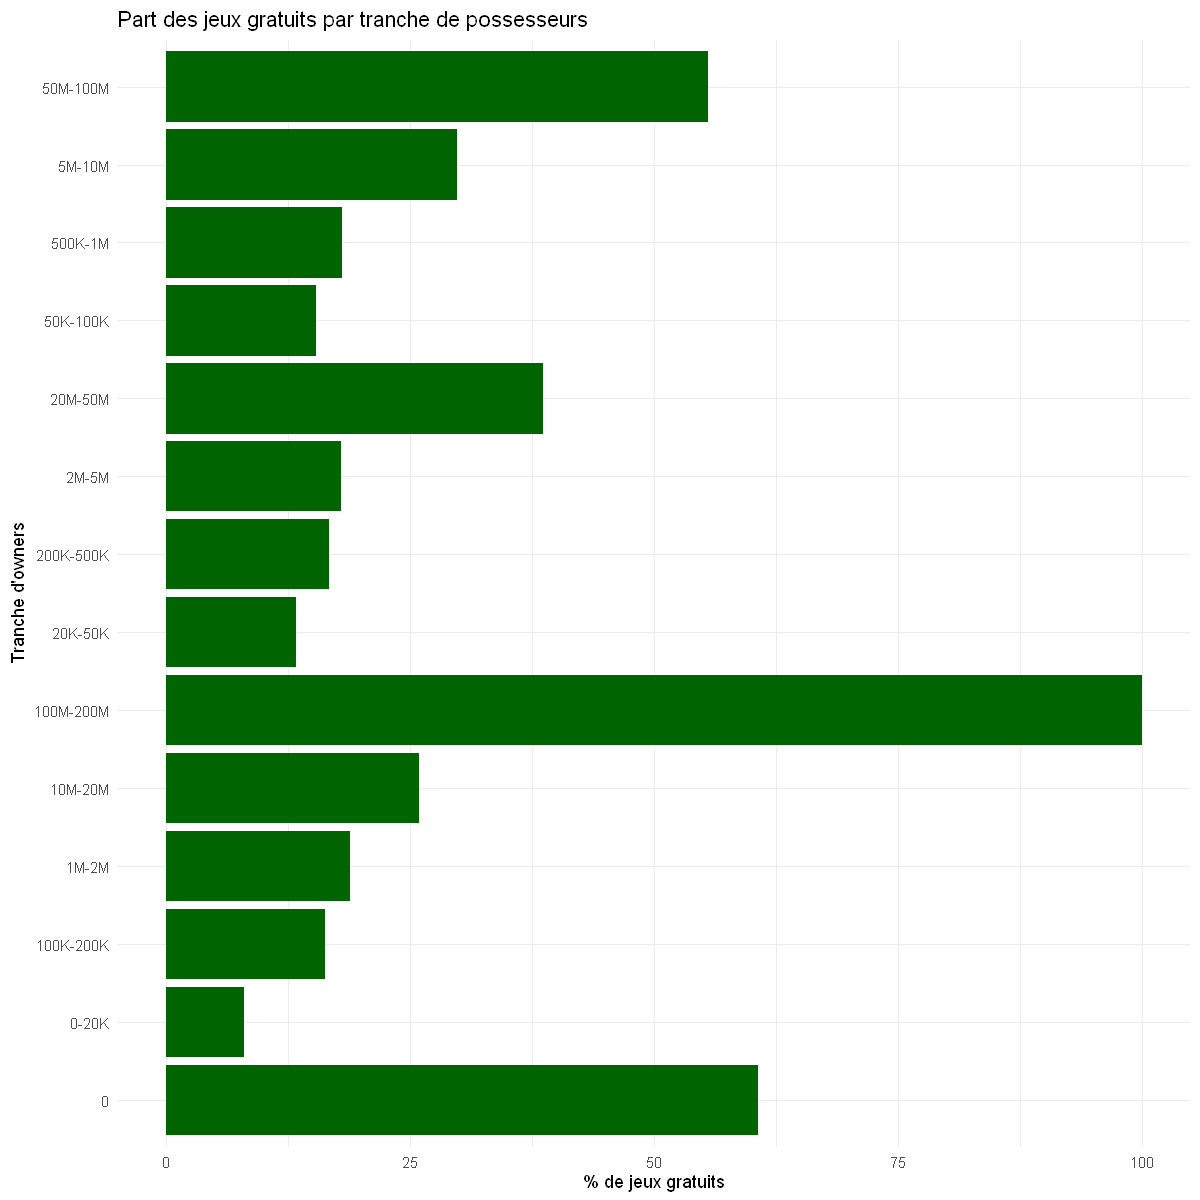

In [243]:
ggplot(df_percent_free, aes(x = Estimated.owners, y = percent_free)) +
  geom_col(fill = "darkgreen") +
  coord_flip() +
  theme_minimal() +
  labs(
    title = "Part des jeux gratuits par tranche de possesseurs",
    x = "Tranche d'owners",
    y = "% de jeux gratuits"
  )

On constate que la plupart des jeux gratuits sont les jeux qui "marchent" le plus en pourcentage.

## Inflence variable L_positive et L_negative

Plutôt que d'utiliser les variables metacritic.score ou user.score qui contiennent enormément de 0 (équivalent à pas de note on va analyser les variables transformée LNegative et LPositive.

In [ ]:
ggplot(data_rename, aes(x = Estimated.owners, y = LPositive, fill = Estimated.owners)) +
  geom_boxplot() +
  coord_flip() +
  theme_minimal() +
  labs(title = "Nombre de Reviews Positives (Log) par tranche de succès")

In [ ]:
ggplot(data_rename, aes(x = Estimated.owners, y = LNegative, fill = Estimated.owners)) +
  geom_boxplot() +
  coord_flip() +
  theme_minimal() +
  labs(title = "Nombre de Reviews Negative (Log) par tranche de détention")

L'analyse des boxplots montre une progression quasi linéaire entre le logarithme des reviews (positives et négatives) et les tranches de détention. Nous pouvons en conclure que le succès commercial (Estimated.owners) est l'un des principals facteur du volume d'expression des joueurs. Bien que les deux courbes ont la même tendance, l'échelle atteinte par les critiques positives est nettement supérieure que les critiques négatives. Avec un plafond à environ $e^{15}$  (environ 3,2 millions) contre $e^{13}$ (~440 000) pour les négatives, on constate que le succès sur Steam reste fortement lié à une satisfaction globale. Plus on augmente en popularité plus le nombre de critique tout court mais aussi positive augmente.

Pour vérifier que les tranches de owners les plus élévés est des critiques positives en plus grand nombre que les critiques négatives on va réaliser une ratio (score) de satisfaction. Pour cela je vais revenir au variables sans le log sinon ça va fausser le résultat.

In [ ]:
df_ratio <- data_rename %>%
  mutate(
    Vraies_Positives = exp(LPositive) - 1, 
    Vraies_Negatives = exp(LNegative) - 1,
    
    Total_Reviews = Vraies_Positives + Vraies_Negatives,
    
    # Calcul du vrai ratio de satisfaction
    Satisfaction_Ratio = ifelse(Total_Reviews > 0, 
                                (Vraies_Positives / Total_Reviews) * 100, 
                                NA)
  ) %>%
  group_by(Estimated.owners) %>%
  summarise(
    Moyenne_Satisfaction = mean(Satisfaction_Ratio, na.rm = TRUE),
    Mediane_Satisfaction = median(Satisfaction_Ratio, na.rm = TRUE),
    Nb_Jeux = n()
  )

print(df_ratio)

In [ ]:
ggplot(df_ratio, aes(x = Estimated.owners, y = Moyenne_Satisfaction)) +

  geom_col(fill = "darkolivegreen", alpha = 0.8) +
  theme_minimal() +
  labs(
    title = "Taux de satisfaction moyen par tranche de ventes",
    subtitle = "Moyenne du ratio (Positives / Total) par catégorie d'owners",
    x = "Tranches de owners",
    y = "Satisfaction moyenne (%)"
  )

L'analyse du taux de satisfaction moyen révèle une dynamique non-linéaire. Si la satisfaction croît mécaniquement avec le volume de ventes jusqu'au palier des 5 millions d'owners (validant l'idée que la qualité perçue booste les ventes), on observe une baisse du ratio pour les jeux dépassant les 100 millions de détenteurs. On peut trouver plusieurs raions à cette décroissance commme: 
- les joueurs postent souvent des reviews négatives après beaucoup d'heures de jeu suite à une mise à jour qu'ils n'ont pas aimé, même s'ils aiment le jeu.
- Ou bien quand un jeu devient un vraiment un succes international, il attire des joueurs qui ne sont pas forcément la cible de base, ce qui augmente les critiques négatives.

## Inflence du genre

## Influence du logiciel (windows , mac, linux)

# ACP 

## Création dataframe avec variable quantitative

In [ ]:
df_pca <- data_rename %>%
  select(where(is.numeric)) %>%
  select(-contains("AppID"), -any_of(c("Release.date", "Required.age","Peak.CCU","Metacritic.score","User.score","Achievements","Median.playtime.forever","Average.playtime.forever"))) 


# Vérification de la taille finale
print(paste("Nombre de lignes pour l'ACP :", nrow(df_pca)))
print(colnames(df_pca))

In [ ]:
res.pca <- PCA(df_pca, scale.unit = TRUE, graph = FALSE)

In [ ]:
res.pca <- PCA(df_pca, scale.unit = TRUE, graph = FALSE)
fviz_eig(res.pca)
res.pca$eig

On regarde quand il y a un coude présent soir garder 4 dimensions cela explique 65% de la variance: c'est un peu bas (inférieur à 80%).On va continuer notre analyse pour voir si on peu en dire plus de choses.

In [ ]:
fviz_pca_var(res.pca,axes = c(1,2),repel=TRUE)
fviz_pca_var(res.pca,axes = c(1,3),repel=TRUE)
fviz_pca_var(res.pca,axes = c(1,4),repel=TRUE)
fviz_pca_var(res.pca,axes = c(2,3),repel=TRUE)
fviz_pca_var(res.pca,axes = c(2,4),repel=TRUE)


Commentaires:

In [ ]:
fviz_pca_biplot(res.pca,axes = c(1,2),repel=TRUE)
fviz_pca_biplot(res.pca,axes = c(1,3),repel=TRUE)
fviz_pca_biplot(res.pca,axes = c(1,4),repel=TRUE)
fviz_pca_biplot(res.pca,axes = c(2,3),repel=TRUE)
fviz_pca_biplot(res.pca,axes = c(2,4),repel=TRUE)


In [ ]:
fviz_pca_biplot(res.pca,axes = c(2,4))